# Stage 1: Geospatial and Operational Inventory of Warehouses 

**Project:** Southern California Warehouse Inventory - Caltrans 65A1345
**Institutions:** Institute of Transportation Studies - UC Davis (UCD) 
**Regulatory context:** South Coast Air Quality Management District (South Coast AQMD) 

---

## Overview

This notebook constructs a comprehensive **geospatial and operational inventory** of warehouses ≥ 50,000 ft² = 4645.152 m^2

**Research Question:** What are the warehouses and distribution centers' location patterns over time and space?

---

## Methodology Overview

| Step | Description | Key Output |
|------|-------------|------------|
| 1 | Define study area (4-county ROI) | `ee.Geometry` ROI |
| 2 | Collect building footprints from 4 sources | Per-county GeoDataFrames |
| 3 | Classify buildings (tags + names + geometry) | `gdf_industrial` with labels |
| 4 | Land use filter (spatial join to LULC data) | `gdf_final` with LU class |
| 5 | Visualization and export | `.gpkg` inventory file |
| 8 | NAIP operational signals (v2) | `gdf_with_naip` — 4 signals + confidence pts |
| 9 | Composite confidence score | `gdf_scored` — `confidence_score`, `confidence_tier` |
| 6 | Truck trip data (operational intensity - Pending) | `.gpkg` truck metrics |
| 7 | Validation and integration | `.gpkg` data integration |


---

## Classification Label System

Every building in the output carries one of three labels:

| Label | Meaning | `needs_review` flag |
|-------|---------|-------------------|
| `confirmed` | Strong positive signal (OSM tag, Overture class, or known operator name) | `False` |
| `candidate` | Passes all exclusion filters but lacks a positive signal — review geometric shape metrics | `True` |
| `excluded` | Matched an exclusion rule (tag, subtype/class, name, or land use zone) | `False` |

Excluded buildings are **retained** in the output for full audit traceability.
The `confidence_note` column records exactly which rule triggered each label.

## Truck Metrics 

- South Coast 
- PeMS classification + WIM stations: vehicle class shares/weights where available (historical archive).
- SCAG High-Cube Warehouse trip-rate study (CEQA): published trip rates per 1,000 ft² for high-cube facilities; use with caution and cite assumptions until AWR comes.

---

## Study Area

- **Counties:** Imperial · Los Angeles · Orange · Riverside · San Bernardino · Ventura
- **Timeframe:** 2021 – 2023 (annual)
- **Size threshold:** ≥ 50,000 ft² (≈ 4,145 m²)
- **CRS (analysis):** EPSG:3310 — California Albers (metric); exported as EPSG:4326


## 0. Environment Setup

### Requirements

Install dependencies before running (or use the provided `environment.yml`):

```bash
conda env create -f environment.yml
conda activate geo
```

**Key package versions (tested):**

| Package | Version |
|---------|---------|
| Python | 3.11.9 |
| geopandas | 0.14.3 |
| pandas | 2.3.2 |
| numpy | 1.26.4 |
| shapely | 2.1.2 |
| osmnx | latest |
| overturemaps | latest |
| google-earth-engine | latest |
| geemap | latest |

### Google Earth Engine Authentication

A GEE account is required to access NAIP imagery. Run `ee.Authenticate()` once
per machine. After that, only `ee.Initialize()` is needed per session.
See: https://developers.google.com/earth-engine/guides/auth


In [47]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
import re
import os
import time
import gzip
import shutil
import tempfile
import zipfile
import subprocess
from io import BytesIO
from pathlib import Path
from datetime import datetime

# ── Scientific stack ──────────────────────────────────────────────────────────
import numpy as np                          # numpy 1.26.4
import pandas as pd                         # pandas 2.3.2
import matplotlib.pyplot as plt            # matplotlib 3.10.6
import statsmodels.api as sm
from scipy import stats
from scipy.stats import gaussian_kde       # weighted KDE
from scipy.spatial.distance import cdist
from scipy.interpolate import RegularGridInterpolator
from scipy.spatial import cKDTree
from scipy.stats import pearsonr
from scipy.stats import spearmanr

# ── Geospatial stack ──────────────────────────────────────────────────────────
import geopandas as gdp                    # geopandas 0.14.3
import fiona                               # fiona 1.9.6
import pyproj                              # pyproj 3.7.2
import folium
from shapely.geometry import box
from shapely.ops import unary_union
from shapely.geometry import MultiPoint, Point
from shapely.prepared import prep

# ── Networking ────────────────────────────────────────────────────────────────
import requests
from urllib3.util.retry import Retry
from requests.adapters import HTTPAdapter

# ── Data sources ───────────────────────────────────────────────────────────────
import osmnx as ox                         # OpenStreetMap
import overturemaps as om                  # Overture Maps
from pystac_client import Client           # Microsoft Planetary Computer
import planetary_computer

# ── Spatial analysis (KDE + centrographic) ───────────────────────────────────
import rasterio                            # GeoTIFF export
from rasterio.transform import from_bounds
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.patches import Ellipse
import contextily as ctx                   # basemap tiles

# ── Machine learning ──────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')


# LODES base URL
LODES_BASE = "https://lehd.ces.census.gov/data/lodes/"

# ── Paths ───────────────────────────────────────────────────────────────────────
# TODO: Set this to your local project root before running.
# All relative paths in this notebook use this as the base.
# Example: path = '/home/username/project6/'
# Set via the WAREHOUSE_PROJECT_ROOT environment variable, or edit directly.
# Do NOT commit a personal absolute path to version control.

path = os.environ.get('WAREHOUSE_PROJECT_ROOT', 'SET_PROJECT_ROOT/')
if path == 'SET_PROJECT_ROOT/':
    print('WARNING: set WAREHOUSE_PROJECT_ROOT env var or edit `path` in this cell.')


In [2]:
# ── Google Earth Engine authentication & initialization ───────────────────────────────────────
# Only run ee.Authenticate() once per machine.
# On subsequent sessions, ee.Initialize() is sufficient.
import ee
import geemap

#ee.Authenticate(auth_mode='notebook')   # Comment out after first run
ee.Initialize()
print("GEE initialized successfully.")


GEE initialized successfully.


## 1: Define the Study Area

We use TIGER/2018 county boundaries accessed through Google Earth Engine to
define a Region of Interest (ROI) covering the core SCAG counties.
The ROI is used to spatially filter NAIP imagery in Step 2.

**Why these counties?**  
Los Angeles, Orange, Riverside, San Bernardino, Ventura, and Imperial 
form the regulatory jurisdiction of Souther California region


In [3]:
def get_roi(county_names, state_fips='06', county_dataset='TIGER/2018/Counties'):
    """
    Build a single ee.Geometry covering one or more California counties.

    Queries the US Census TIGER/2018 county boundaries hosted on Google Earth
    Engine and unions all requested counties into one geometry. This ROI is
    used to clip NAIP imagery and filter building datasets by extent.

    Parameters
    ----------
    county_names : list of str
        County names exactly as they appear in TIGER data.
        Example: ['Los Angeles', 'Orange', 'Riverside', 'San Bernardino']
    state_fips : str
        State FIPS code. Default '06' = California.
    county_dataset : str
        GEE FeatureCollection asset path for county boundaries.

    Returns
    -------
    ee.Geometry
        Unioned geometry of all requested counties (EPSG:4326).

    Example
    -------
    >>> roi = get_roi(['Los Angeles', 'Orange'], state_fips='06')
    """
    counties = ee.FeatureCollection(county_dataset)

    # filter by state first
    state_counties = counties.filter(ee.Filter.eq('STATEFP', state_fips))

    # merge geometries for all selected counties
    roi = None
    for c in county_names:
        geom = state_counties.filter(ee.Filter.eq('NAME', c)).geometry()
        roi = geom if roi is None else roi.union(geom)

    return roi


## 2: Collect Primary Building Footprint Sources

We combine four complementary data sources to maximize coverage and
minimize classification gaps. No single source is sufficient alone:

| Dataset | Strength | Limitation |
|---------|----------|-----------|
| **USDA NAIP** | Detects all roof surfaces from aerial imagery | No semantic labels; requires post-processing |
| **Microsoft Buildings** | Highly accurate roof geometry; good for area estimation | No building type information |
| **Overture Maps** | Rich schema: `subtype`, `class`, operator names | Some coverage gaps in industrial parks |
| **OpenStreetMap** | Named facilities (e.g., "Amazon Fulfillment Center") | Sparse and inconsistent in many areas |

All four sources are:
- Legally permissible for research use
- Publicly accessible and reproducible
- Scientifically defensible for peer review
- Suitable for statewide scaling

**Size filter:** All sources are filtered to ≥ 50,000 ft².
Area is computed in EPSG:3310 (California Albers, metric) then converted to ft².


### 2.1 USDA NAIP — Roof Detection via Google Earth Engine

In [36]:
# ==============================================================================
# NAIP ROOF DETECTION — MEMORY-SAFE IMPLEMENTATION
# ==============================================================================
# The original detect_large_roofs() called reduceToVectors() on the full
# 7-county ROI at 3 m scale, which exceeds the GEE per-user memory limit
# (~2-4 GB). This version fixes that in three ways:
#
#   1. County-by-county processing — each county is a separate GEE task,
#      so peak memory is bounded by the largest single county (SB / LA).
#
#   2. Export-first workflow — results go to Google Drive as GeoJSON
#      (via ee.batch.Export.table.toDrive) rather than being pulled into
#      Python memory via .getInfo(). Large vectorization jobs must use
#      batch export; interactive .getInfo() calls have a hard 5,000-feature
#      and ~256 MB response limit even with bestEffort=True.
#
#   3. Coarser scale + pixel filter — 5 m scale (was 3 m) halves pixel count.
#      The connectedPixelCount minimum is raised proportionally.
#      At 5 m, 100,000 ft² ≈ 1,858 m² ≈ 75 pixels; the default threshold
#      of area_threshold_m2=4,500 still captures all Rule 2305 targets.
#
# WORKFLOW
# --------
#   a. Call submit_naip_export_tasks() — submits one Drive export per county.
#      Monitor progress at https://code.earthengine.google.com/tasks
#   b. When all tasks are COMPLETED, call load_naip_from_drive() to read
#      the GeoJSON files into a single GeoDataFrame.
#   c. naip_img / get_naip_image() are still used for visualisation (Map2).
# ==============================================================================


def get_naip_image(roi, ini_date='2022-01-01', end_date='2022-12-31'):
    """
    Retrieve a cloud-free NAIP mosaic clipped to the ROI.

    NAIP (National Agriculture Imagery Program) provides ~0.6 m GSD aerial
    imagery with Red, Green, Blue, and Near-Infrared (RGBN) bands.

    Parameters
    ----------
    roi      : ee.Geometry   Region of interest
    ini_date : str           Start date ('YYYY-MM-DD')
    end_date : str           End date   ('YYYY-MM-DD')

    Returns
    -------
    ee.Image  NAIP mosaic clipped to ROI.
    """
    return (ee.ImageCollection('USDA/NAIP/DOQQ')
              .filterBounds(roi)
              .filterDate(ini_date, end_date)
              .mosaic()
              .clip(roi))


def _build_roof_fc(county_geom, start_date='2022-01-01', end_date='2022-12-31',
                   area_threshold_m2=4_500, scale=5):
    """
    Build a roof-polygon FeatureCollection for a single county geometry.

    Internal helper — returns an ee.FeatureCollection (server-side only).
    Do NOT call .getInfo() on this for large counties; use batch export.

    Parameters
    ----------
    county_geom       : ee.Geometry   Single county boundary
    start_date        : str
    end_date          : str
    area_threshold_m2 : float         Minimum polygon area in m²
    scale             : int           Vectorization scale in metres (default 5)
    """
    naip = get_naip_image(county_geom, start_date, end_date)

    ndvi = naip.normalizedDifference(['N', 'R']).rename('NDVI')
    ndbi = naip.normalizedDifference(['G', 'N']).rename('NDBI')

    # Roof mask: impervious, non-vegetated
    # connectedPixelCount minimum scaled to 5 m pixels:
    #   old: 20 px @ 3 m = ~180 m² -  new: 8 px @ 5 m = 200 m²
    roof_mask = (ndbi.gt(0.0)
                     .And(ndvi.lt(0.4))
                     .selfMask()
                     .connectedPixelCount(50, True)
                     .gte(8)
                     .selfMask())

    vectors = roof_mask.reduceToVectors(
        geometry=county_geom,
        scale=scale,
        geometryType='polygon',
        eightConnected=True,
        labelProperty='roof',
        bestEffort=True,        # allows GEE to reduce scale if needed
        maxPixels=1e10,
    )

    # Add area and filter
    vectors = vectors.map(
        lambda f: f.set('area_m2', ee.Geometry(f.geometry()).area())
    )
    return vectors.filter(ee.Filter.gt('area_m2', area_threshold_m2))


def submit_naip_export_tasks(county_rois, drive_folder='NAIP_Roofs',
                              start_date='2022-01-01', end_date='2022-12-31',
                              area_threshold_m2=4_500, scale=5):
    """
    Submit one GEE batch-export task per county to Google Drive.

    Each task exports a GeoJSON FeatureCollection of roof polygons ≥
    area_threshold_m2. Monitor progress at:
        https://code.earthengine.google.com/tasks

    Parameters
    ----------
    county_rois       : dict  {county_label: ee.Geometry}
                              Build with get_county_rois() below, or pass
                              manually constructed ee.Geometry objects.
    drive_folder      : str   Google Drive folder name (created if absent)
    start_date        : str
    end_date          : str
    area_threshold_m2 : float Minimum polygon area in m² (default 4,500)
    scale             : int   Vectorization scale in metres (default 5)

    Returns
    -------
    list of ee.batch.Task  (already started)

    Example
    -------
    county_rois = get_county_rois()
    tasks = submit_naip_export_tasks(county_rois)
    # check status:
    for t in tasks:
        print(t.id, t.status()['state'])
    """
    tasks = []
    for label, geom in county_rois.items():
        fc = _build_roof_fc(
            geom, start_date=start_date, end_date=end_date,
            area_threshold_m2=area_threshold_m2, scale=scale,
        )
        task = ee.batch.Export.table.toDrive(
            collection=fc,
            description=f'naip_roofs_{label.lower()}_2022',
            folder=drive_folder,
            fileNamePrefix=f'naip_roofs_{label.lower()}_2022',
            fileFormat='GeoJSON',
        )
        task.start()
        print(f'  Submitted: naip_roofs_{label.lower()}_2022  ' 
              f'(task id: {task.id})')
        tasks.append(task)
    print(f'\n{len(tasks)} task(s) submitted → monitor at ')
    print('  https://code.earthengine.google.com/tasks')
    return tasks


def get_county_rois(state_fips='06',
                    county_dataset='TIGER/2018/Counties', name_map=None):
    """
    Build a dict of {county_label: ee.Geometry} for all 7 study counties.

    Returns
    -------
    dict  {'LA': ee.Geometry, 'OR': ee.Geometry, ...}
    """
    counties = ee.FeatureCollection(county_dataset)
    state    = counties.filter(ee.Filter.eq('STATEFP', state_fips))
    
    return {
        label: state.filter(ee.Filter.eq('NAME', name)).geometry()
        for label, name in name_map.items()
    }


def check_naip_tasks(tasks):
    """
    Print current status of submitted export tasks.

    Parameters
    ----------
    tasks : list  Output of submit_naip_export_tasks()
    """
    print(f"{'Task':<45} {'State':<12} {'Progress'}")
    print("-" * 70)
    for t in tasks:
        st = t.status()
        state    = st.get('state', 'UNKNOWN')
        progress = st.get('progress', 0)
        desc     = st.get('description', t.id)
        print(f"  {desc:<43} {state:<12} {progress:.0%}")


def load_naip_from_drive(drive_folder_local, county_labels=None,
                          area_threshold_m2=4_500):
    """
    Load completed NAIP export GeoJSON files from a local Drive-synced folder.

    After GEE tasks complete, sync Google Drive to your local machine
    (e.g., via Google Drive for Desktop) and point this function at the
    synced folder.

    Parameters
    ----------
    drive_folder_local : str or Path
        Local path to the synced Google Drive folder containing
        'naip_roofs_<county>_2022.geojson' files.
    county_labels      : list or None
        If None, loads all counties. Otherwise filters to the given labels.
    area_threshold_m2  : float
        Re-applies area filter in case exports were not filtered server-side.

    Returns
    -------
    GeoDataFrame  All counties merged, EPSG:4326, with 'county' column added.
    """
    from pathlib import Path
    drive_folder_local = Path(drive_folder_local)

    if county_labels is None:
        county_labels = ['LA', 'OR', 'RI', 'SB', 'VE', 'IMP', 'SJ']

    frames = []
    for label in county_labels:
        fname = drive_folder_local / f'naip_roofs_{label.lower()}_2022.geojson'
        if not fname.exists():
            print(f'  WARNING: {fname.name} not found — skipping {label}')
            continue
        gdf = gdp.read_file(fname)
        gdf['county'] = label
        # Re-apply area filter (server-side filter may have used approximate area)
        if 'area_m2' in gdf.columns:
            gdf = gdf[gdf['area_m2'] >= area_threshold_m2]
        else:
            gdf = gdf.to_crs(3310)
            gdf['area_m2'] = gdf.geometry.area
            gdf = gdf[gdf['area_m2'] >= area_threshold_m2].to_crs(4326)
        frames.append(gdf)
        print(f'  Loaded {label}: {len(gdf):,} roof polygons')

    if not frames:
        raise RuntimeError(
            'No NAIP GeoJSON files found. Check drive_folder_local path '
            'and ensure GEE export tasks have completed.'
        )

    merged = gdp.GeoDataFrame(
        pd.concat(frames, ignore_index=True), crs=4326
    )
    print(f'\n  Total NAIP roof polygons loaded: {len(merged):,}')
    return merged


### 2.2 Overture Maps — Building Footprints with Semantic Schema

Overture Maps consolidates building footprints from OpenStreetMap, Microsoft,
Google, and Esri into a unified schema. The key fields used here are:

- `subtype` — broad category (e.g., `industrial`, `commercial`, `residential`)
- `class`   — more specific type (e.g., `warehouse`, `logistics`, `hotel`)
- `names`   — primary and common names (JSON-formatted string)

**Download approach:** For large counties (LA, SB, RI), the bounding box is
split into tiles to avoid API timeouts. The tiles are then merged into a
single per-county GeoJSON.

**Overture API docs:** https://docs.overturemaps.org/guides/buildings/


In [5]:
# ── Tiled download helpers ─────────────────────────────────────────────────────

def tile_bbox(bbox, nx=4, ny=4):
    """
    Subdivide a bounding box into an nx × ny grid of smaller tiles.

    Used to avoid timeout errors when downloading large counties from Overture.

    Parameters
    ----------
    bbox : list  [min_lon, min_lat, max_lon, max_lat]
    nx   : int   Number of columns (default 4)
    ny   : int   Number of rows (default 4)

    Returns
    -------
    list of [min_lon, min_lat, max_lon, max_lat] sub-tiles
    """
    minx, miny, maxx, maxy = bbox
    xs = np.linspace(minx, maxx, nx + 1)
    ys = np.linspace(miny, maxy, ny + 1)
    return [[xs[i], ys[j], xs[i+1], ys[j+1]] for i in range(nx) for j in range(ny)]


def download_overture_tiled(county_prefix, bbox, nx=4, ny=4):
    """
    Download Overture building footprints for a county using a tiled strategy.

    Splits the bounding box into nx × ny tiles and downloads each separately,
    sleeping 1 second between requests to respect rate limits.

    Parameters
    ----------
    county_prefix : str   Output filename prefix (e.g., 'la')
    bbox          : list  [min_lon, min_lat, max_lon, max_lat]
    nx, ny        : int   Grid dimensions for tiling

    Returns
    -------
    list of str   Paths to successfully downloaded tile GeoJSON files
    """
    tiles     = tile_bbox(bbox, nx, ny)
    out_files = []

    for k, tile in enumerate(tiles):
        bbox_str = ",".join(map(str, tile))
        out_file = f"{county_prefix}_tile{k}.geojson"
        cmd = ["overturemaps", "download", "--type=building",
               "--bbox", bbox_str, "-f", "geojson", "-o", out_file]

        print(f"⬇️  Tile {k}/{len(tiles)-1} → {out_file}")
        try:
            subprocess.run(cmd, check=True)
            out_files.append(out_file)
        except Exception as e:
            print(f"❌  Tile {k} failed: {e}")
        time.sleep(1)

    return out_files


def merge_overture_tiles(tile_files):
    """
    Merge a list of Overture tile GeoJSON files into one GeoDataFrame.

    Parameters
    ----------
    tile_files : list of str   Paths returned by download_overture_tiled()

    Returns
    -------
    GeoDataFrame or None if all tiles failed to load
    """
    gdfs = []
    for f in tile_files:
        try:
            gdfs.append(gdp.read_file(f))
        except Exception as e:
            print(f"  Skipping {f}: {e}")
    if not gdfs:
        print("❌  No tiles loaded.")
        return None
    merged = gdp.GeoDataFrame(pd.concat(gdfs, ignore_index=True), crs=4326)
    print(f"✅  Merged {len(tile_files)} tiles → {len(merged):,} features")
    return merged


def run_overture_download(county_name, bbox):
    """
    Simple single-call Overture download (use for smaller counties).

    For large counties (LA, SB, RI) prefer download_overture_tiled() to avoid
    timeout errors from the Overture CLI.

    Parameters
    ----------
    county_name : str   Used as the output filename prefix
    bbox        : list  [min_lon, min_lat, max_lon, max_lat]
    """
    bbox_str = ",".join(map(str, bbox))
    out_file = f"{county_name.lower()}_buildings.geojson"
    cmd = ["overturemaps", "download", "--type=building",
           "--bbox", bbox_str, "-f", "geojson", "-o", out_file]
    print(f"⬇️  Downloading {county_name} buildings...")
    subprocess.run(cmd, check=True)
    print(f"✅  Saved → {out_file}")


# ── Load and filter ──────────────────────────────────────────────────────────

def get_overture_building(buildings_path, area_threshold_ft2=100_000, county=""):
    """
    Load a downloaded Overture GeoJSON and filter to large buildings only.

    Reprojects to EPSG:3310 (California Albers) to compute accurate planar
    areas, filters by the size threshold, then returns to EPSG:4326.

    Parameters
    ----------
    buildings_path     : str    Path to local Overture GeoJSON file
    area_threshold_ft2 : float  Minimum footprint area in ft² (default 100,000)
    county             : str    County label for progress reporting

    Returns
    -------
    GeoDataFrame
        Buildings ≥ threshold with 'area_m2' and 'area_ft2' columns added.

    Raises
    ------
    RuntimeError if the file cannot be read.
    """
    try:
        with fiona.Env():
            gdf = gdp.read_file(buildings_path)
    except Exception as e:
        raise RuntimeError(f"Failed to read {buildings_path}: {e}")

    gdf = gdf[gdf.geometry.notnull()].copy().to_crs(epsg=3310)
    gdf["area_m2"]  = gdf.geometry.area
    gdf["area_ft2"] = gdf["area_m2"] * 10.7639

    large = gdf[gdf["area_ft2"] >= area_threshold_ft2].copy().to_crs(epsg=4326)
    print(f"  {county}: {len(large):,} buildings ≥ {area_threshold_ft2:,} ft² (Overture)")
    return large


### 2.3 Microsoft US Building Footprints

Microsoft's building footprint dataset is derived from high-resolution satellite
imagery using computer vision. It provides excellent geometric accuracy (~0.5 m)
but contains no semantic building type information.

**Source:** https://github.com/microsoft/USBuildingFootprints  
**Download:** The full California file (~4-5 GB) is downloaded once and cached locally.
Subsequent runs use the cached ZIP, which is then spatially filtered to the county bbox.

**Note:** This is a large download. Ensure you have stable internet and ~6 GB of disk space.


In [6]:
def get_ms_buildings(bbox, state_name="California", area_threshold_ft2=100_000,
                     cache_dir="data"):
    """
    Download Microsoft US Building Footprints and filter to a bounding box.

    Downloads the full state file once (cached), then reads only the buildings
    within the specified bounding box using spatial indexing. Filters to
    buildings ≥ area_threshold_ft2.

    Parameters
    ----------
    bbox               : list  [min_lon, min_lat, max_lon, max_lat] in EPSG:4326
    state_name         : str   State name as used in Microsoft's URL (default 'California')
    area_threshold_ft2 : float Minimum footprint area in ft² (default 100,000)
    cache_dir          : str   Directory to cache the downloaded ZIP (default 'data/')

    Returns
    -------
    GeoDataFrame
        Microsoft building footprints within bbox, ≥ threshold, in EPSG:4326.

    Notes
    -----
    Uses retry logic (5 attempts, exponential backoff) for robustness.
    The cached ZIP is reused on subsequent calls — delete it to force re-download.
    """
    os.makedirs(cache_dir, exist_ok=True)
    zip_path = os.path.join(cache_dir, f"{state_name}.geojson.zip")
    base_url = (f"https://minedbuildings.z5.web.core.windows.net/"
                f"legacy/usbuildings-v2/{state_name}.geojson.zip")

    # ── 1. Download (skip if cached) ──────────────────────────────────────────
    if not os.path.exists(zip_path):
        print(f"⬇️  Downloading {state_name} footprints (~4–5 GB) ...")
        session = requests.Session()
        retry   = Retry(total=5, backoff_factor=5,
                        status_forcelist=[500, 502, 503, 504],
                        allowed_methods=["GET"])
        session.mount("https://", HTTPAdapter(max_retries=retry))
        with session.get(base_url, stream=True, timeout=120) as r:
            r.raise_for_status()
            with open(zip_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=10_485_760):
                    if chunk:
                        f.write(chunk)
        print(f"✅  Saved → {zip_path}")
    else:
        print(f"✅  Using cached file: {zip_path}")

    # ── 2. Extract and read (bbox-filtered) ──────────────────────────────────
    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(tmpdir)
            geojson_files = [f for f in zf.namelist() if f.endswith(".geojson")]
            if not geojson_files:
                raise FileNotFoundError("No GeoJSON found inside ZIP.")
            geojson_path = os.path.join(tmpdir, geojson_files[0])

        print(f"📂   Reading subset for bbox {bbox} ...")
        gdf = gdp.read_file(geojson_path, bbox=bbox)

    # ── 3. Compute area and filter ──────────────────────────────────────────
    gdf = gdf.to_crs(3310)
    gdf["area_ft2"] = gdf.area * 10.7639
    gdf = gdf[gdf["area_ft2"] >= area_threshold_ft2].to_crs(4326)
    print(f"✅  {len(gdf):,} buildings ≥ {area_threshold_ft2:,} ft² (Microsoft)")
    return gdf


### 2.4 OpenStreetMap  —  Building Tags and Named Facilities

OSM provides the richest semantic information of the four sources. Named facilities
such as "Amazon Fulfillment Center" or "FedEx Ground" are often tagged in OSM
even when absent from other datasets.

We download both polygons (building footprints) and points (facility centroids).
Points are later buffered and used as semantic tag carriers to enrich Microsoft
and Overture footprints that overlap them (see Step 3).

**OSM tag reference:** https://wiki.openstreetmap.org/wiki/Key:building

**Important:** OSM reflects the state of the database at download time and may
not capture all facilities. Coverage is denser in urban areas and sparser in
industrial zones. Always cross-reference with Overture and Microsoft.


In [7]:
ox.settings.timeout = 600   # 10-minute timeout for large county queries

def get_osm_buildings(place_name, download_year=None, area_threshold_ft2=100_000):
    """
    Download OSM building polygons and points for a named place.

    Queries the Overpass API via OSMnx for a broad set of building and
    amenity tags. Both polygons (footprints) and points (facility centroids)
    are returned. Points are used as semantic tag carriers in Step 3.

    Parameters
    ----------
    place_name    : str  Nominatim place name (e.g., 'Los Angeles County, California, USA')
    download_year : int  Year of download recorded in 'source_year' column.
                         Defaults to current year if not provided.

    Returns
    -------
    GeoDataFrame
        OSM features in EPSG:4326 with columns:
        ['geometry', 'name', 'building', 'tourism', 'amenity',
         'shop', 'healthcare', 'source_year']

    Notes
    -----
    Supports both OSMnx 1.x (geometries_from_place) and 2.x (features_from_place).
    Large counties (SB, Riverside) may take several minutes to download.
    """
    # Tags cover industrial/warehouse targets AND common non-industrial buildings
    # (non-industrial tags are needed so they can be used as exclusion signals in Step 3)
    tags = {
        'building':   ['industrial', 'warehouse', 'commercial',
                       'supermarket', 'retail', 'office', 'museum',
                       'school', 'university', 'sports_centre',
                       'stadium', 'military', 'hospital', 'church',
                       'cathedral', 'hotel', 'transportation',
                       'parking', 'apartments', 'residential'],
        'amenity':    ['cinema', 'casino', 'theatre', 'prison',
                       'police', 'ranger_station', 'fire_station',
                       'clinic', 'doctors', 'nursing_home',
                       'library', 'planetarium', 'arts_centre',
                       'community_centre', 'conference_centre',
                       'kindergarten', 'school', 'university',
                       'college', 'pharmacy', 'veterinary',
                       'social_facility', 'social_centre',
                       'shelter', 'marketplace'],
        'tourism':    ['zoo', 'aquarium', 'theme_park', 'hotel',
                       'motel', 'guest_house', 'chalet'],
        'leisure':    ['water_park', 'resort'],
        'shop':       ['supermarket', 'convenience', 'general',
                       'clothes', 'electronics', 'wholesale'],
        'healthcare': ['hospital', 'clinic', 'doctor',
                       'dentist', 'physiotherapist']
    }

    if download_year is None:
        download_year = datetime.now().year

    # OSMnx API compatibility: 1.x vs 2.x
    if hasattr(ox, "features_from_place"):
        gdf = ox.features_from_place(place_name, tags=tags)
    else:
        gdf = ox.geometries_from_place(place_name, tags=tags)

    gdf["source_year"] = download_year
    gdf = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon", "Point"])]

    columns_to_keep = ['geometry', 'name', 'building', 'tourism',
                       'amenity', 'shop', 'healthcare', 'source_year']
    gdf_reduced = gdf[[c for c in columns_to_keep if c in gdf.columns]].copy()

    gdf_reduced = gdf_reduced.to_crs(3310)
    gdf_reduced["area_ft2"] = gdf_reduced.area * 10.7639
    gdf_reduced  = gdf_reduced [gdf_reduced ["area_ft2"] >= area_threshold_ft2].to_crs(4326)
    print(f"  {place_name}: {len(gdf_reduced):,} OSM features downloaded with buildings ≥ {area_threshold_ft2:,} ft²")
    return gdf_reduced.to_crs(epsg=4326)


### 2.5 SCAG Data integration

Open source data use to identify building located in industrial areas and flag buildings 
out of them, helping the exclusion of non-warehouses.
This data may also provides information about the year of construction. 
**Source:** https://gisdata-scag.opendata.arcgis.com/search  
**Download:** The SCAG files are downloaded once and cached locally.


In [79]:
# ==============================================================================
# SCAG PERMIT DATA INTEGRATION AND TEMPORAL FLAG CONSTRUCTION
# ==============================================================================
# Integrates county assessor parcel data and SCAG building permit records to
# assign construction / occupancy dates to each building. These dates drive
# three binary temporal flags (present / active / new) per year, which are the
# temporal backbone of the Track 2 panel dataset.
#
# Data required (request from SCAG and county assessor portals):
#   1. County assessor parcel shapefiles - all 7 counties
#      (LA, Orange, Riverside, SB, Ventura, Imperial, San Joaquin)
#      Download: respective county GIS Open Data portals
#   2. SCAG permit records CSV with columns:
#      APN, permit_type, permit_date, occ_date, ti_date, gross_sqft, occ_type
#      Request: SCAG Data Services — specify 2000–2023, all 7 counties
#
# Join strategy:
#   building centroid -> parcel (spatial) -> APN -> permit record (tabular)
# ==============================================================================

def load_scag_parcels(parcel_paths: dict,
                      layer_names: dict = None) -> gdp.GeoDataFrame:
    """
    Load and merge SCAG 2024 parcel shapefiles for all study counties.

    Uses SCAG's standardized schema — all counties share the same field
    names, so no column normalization is needed unlike raw assessor files.

    Parameters
    ----------
    parcel_paths : dict {county_label: path_to_shapefile}
        Example:
        {
            'LA' : path + 'Task1_Characterization/Data/SCAG/LA_parcels.shp',
            'OR' : path + 'Task1_Characterization/Data/SCAG/OR_parcels.shp',
            'RI' : path + 'Task1_Characterization/Data/SCAG/RI_parcels.shp',
            'SB' : path + 'Task1_Characterization/Data/SCAG/SB_parcels.shp',
            'VE' : path + 'Task1_Characterization/Data/SCAG/VE_parcels.shp',
        }

    Returns
    -------
    GeoDataFrame
        Merged parcel layer in EPSG:4326 with cleaned and typed columns.

    SCAG Land Use Codes relevant to warehouse classification
    --------------------------------------------------------
    1340  Wholesaling and Warehousing        — primary target
    1320  Heavy Industrial                   — may contain warehouses
    1310  Light Industrial                   — may contain warehouses
    1300  Industrial (undifferentiated)      — may contain warehouses
    1416  Truck Terminals                    — positive class
    1500  Mixed Commercial and Industrial    — review manually
    1323  Open Storage                       — possible yard/logistics
    """
    # SCAG land use codes that indicate warehouse/industrial use
    # Used to filter parcels and create a land_use_class feature
    WAREHOUSE_CODES   = {1340}
    INDUSTRIAL_CODES  = {1300, 1310, 1311, 1312, 1313, 1314,
                         1320, 1321, 1322, 1323, 1324, 1325,
                         1416, 1500}
    EXCLUDE_CODES     = {
        1100, 1110, 1111, 1112, 1113,   # residential
        1120, 1121, 1122, 1123, 1124, 1125,
        1130, 1131, 1132, 1140, 1150,
        1200, 1210, 1211, 1212, 1213,   # commercial/office
        1220, 1221, 1222, 1223, 1230,
        1231, 1232, 1233,
        1240, 1241, 1242, 1243, 1244,   # public facilities
        1245, 1246, 1247, 1250, 1251,
        1252, 1253, 1260, 1261, 1262,
        1263, 1264, 1265, 1266,
        1270, 1271, 1272, 1273,         # military
        1800, 1810, 1820, 1830, 1840,   # open space
        1850, 1860, 1870, 1880, 1890,
        2000, 2100, 2110, 2120,         # agriculture
        2200, 2300, 2400, 2500,
        3000, 3100, 3200, 3300, 3400,   # vacant
        4000, 4100, 4200, 4300,         # water
        1900, 8888, 9999                # urban vacant / undevelopable / unknown
    }
    # Add to EXCLUDE_CODES in load_scag_parcels() and both label functions
    ADDITIONAL_EXCLUDE = {
        1411.0,   # Airports
        1600.0,   # Mixed Residential/Commercial
        1420.0,   # Communication Facilities
        1417.0,   # Harbor Facilities
        1431.0,   # Electrical Power Facilities
        1432.0,   # Solid Waste Disposal
        1433.0,   # Liquid Waste Disposal
        1434.0,   # Water Storage
        1435.0,   # Natural Gas and Petroleum
        1436.0,   # Water Transfer
        1437.0,   # Flood Waterways
        1331.0,   # Mineral Extraction
        1332.0,   # Oil and Gas Extraction
    }

    # Add to CANDIDATE_CODES — these may contain warehouses
    ADDITIONAL_CANDIDATE = {
        1700.0,   # Under Construction — future warehouses
        1275.0,   # Former Military Base Vacant — frequent warehouse redevelopment
        1274.0,   # Former Military Base Built-up — same
    }

    frames = []

    for county, p in parcel_paths.items():
        if not Path(p).exists():
            print(f"  ❌ File not found for {county}: {p} — skipping")
            continue

        print(f"\n  Loading {county}...")
        try:
            layer = layer_names.get(county) if layer_names else None
            gdf = gdp.read_file(p, layer=layer) if layer else gdp.read_file(p)
        except Exception as e:
            print(f"  ❌ Failed to read {county}: {e} — skipping")
            continue

        # --- Validate expected SCAG columns are present ---
        required = ['LU19', 'geometry']
        missing = [c for c in required if c not in gdf.columns]
        if missing:
            print(f"  ❌ Missing expected SCAG columns for {county}: {missing}")
            print(f"      Available columns: {gdf.columns.tolist()}")
            continue

        # --- Select and rename relevant columns ---
        col_map = {
            'PID19'    : 'pid',
            'APN19'    : 'APN',          # ← was APN24
            'COUNTY'   : 'county_name',
            'COUNTY_ID': 'county_fips',
            'CITY'     : 'city',
            'CITY_ID'  : 'city_fips',
            'ACRES'    : 'parcel_acres',
            'LU19'     : 'land_use_code',  # ← was ZN24_SCAG — this is the key fix
            'ZN19_CITY': 'zoning_local',   # ← was ZN24_CITY
            'ZN19_SCAG': 'land_use_code_2nd',
            'YEAR_GP'  : 'year_zoning_updated',  # ← was YEAR_ZN
            'GEOID20'  : 'census_block',
            'SLOPE'    : 'slope',
            'GP19_SCAG': 'gp_scag',        # NEW general plan SCAG code (bonus signal)
        }
        available_map = {k: v for k, v in col_map.items() if k in gdf.columns}
        gdf = gdf.rename(columns=available_map)

        # --- Add county label (consistent short code) ---
        gdf['county'] = county

        # --- Parse land use code to integer (stored as Text in SCAG) ---
        gdf['land_use_code'] = pd.to_numeric(
        gdf['land_use_code'], errors='coerce'
        )  # keep as float64 — avoids nullable Int64 NaN casting issues

        # --- Derive warehouse-relevant land use classification ---
        gdf['scag_land_use_class'] = 'other'
        gdf.loc[gdf['land_use_code'].isin(WAREHOUSE_CODES),  'scag_land_use_class'] = 'warehouse'
        gdf.loc[gdf['land_use_code'].isin(INDUSTRIAL_CODES), 'scag_land_use_class'] = 'industrial'
        gdf.loc[gdf['land_use_code'].isin(EXCLUDE_CODES),    'scag_land_use_class'] = 'non_industrial'
        gdf.loc[gdf['land_use_code'].isin(ADDITIONAL_EXCLUDE), 'scag_land_use_class'] = 'non_industrial'
        gdf.loc[gdf['land_use_code'].isin(ADDITIONAL_CANDIDATE), 'scag_land_use_class'] = 'candidate_special'
        
        # --- Parse parcel area (SCAG stores in acres - convert to ft²) ---
        if 'parcel_acres' in gdf.columns:
            gdf['parcel_acres'] = pd.to_numeric(gdf['parcel_acres'], errors='coerce')
            gdf['parcel_area_ft2'] = gdf['parcel_acres'] * 43_560

        # --- Truck terminal flag (SCAG code 1416 is a direct warehouse signal) ---
        gdf['is_truck_terminal'] = (gdf['land_use_code'] == 1416).fillna(False).astype(int)

        # --- Print land use distribution for QA ---
        print(f"  {county}: {len(gdf):,} parcels loaded")
        print(f"    Land use distribution (top 10):")
        luc = gdf['scag_land_use_class'].value_counts()
        for cls, cnt in luc.items():
            print(f"      {cls:20s}: {cnt:,}")

        # --- Keep relevant columns only ---
        keep_cols = [
            'APN', 'county', 'pid',
            'county_name', 'county_fips',
            'city', 'city_fips',
            'parcel_acres', 'parcel_area_ft2',
            'land_use_code', 'land_use_code_2nd',
            'scag_land_use_class',
            'zoning_local',
            'year_zoning_updated',
            'census_block',
            'slope',
            'is_truck_terminal',
            'geometry'
        ]
        keep_cols = [c for c in keep_cols if c in gdf.columns]
        gdf = gdf[keep_cols].to_crs(4326)
        frames.append(gdf)

    if not frames:
        raise RuntimeError("No SCAG parcel files loaded. Check parcel_paths.")

    merged = gdp.GeoDataFrame(pd.concat(frames, ignore_index=True), crs=4326)

    print(f"\n ✅  Total SCAG parcels merged: {len(merged):,}")
    print(f"\n   Study-area land use summary:")
    for cls, cnt in merged['scag_land_use_class'].value_counts().items():
        pct = 100 * cnt / len(merged)
        print(f"   {cls:20s}: {cnt:>8,}  ({pct:.1f}%)")

    return merged


def join_apn_to_buildings(buildings_gdf, parcels_gdf):
    """
    Spatially join building centroids to parcels to retrieve APN.

    Parameters
    ----------
    buildings_gdf : GeoDataFrame  Classified building inventory.
    parcels_gdf   : GeoDataFrame  Output of load_assessor_parcels().

    Returns
    -------
    GeoDataFrame
        Buildings with 'APN' and 'parcel_county' columns added.
        'APN' is NaN for buildings whose centroid does not fall within
        any parcel (flagged as permit_matched = False in the next step).
    """
    work   = buildings_gdf.copy().to_crs(3310)
    parcel = parcels_gdf.to_crs(3310)

    centroids = gdp.GeoDataFrame(
        {'geometry': work.geometry.centroid},
        index=work.index, crs=work.crs
    )

    joined = gdp.sjoin(
        centroids,
        parcel[['APN', 'county', 'geometry']],
        how='left', predicate='within'
    )
    joined = joined[~joined.index.duplicated(keep='first')]

    work['APN']           = joined['APN'].reindex(work.index)
    work['parcel_county'] = joined['county'].reindex(work.index)

    matched = work['APN'].notna().sum()
    print(f"  APN matched: {matched:,} / {len(work):,} buildings "
          f"({matched/len(work)*100:.1f}%)")
    return work.to_crs(4326)


def join_permits_to_buildings(buildings_gdf, permits_csv_path,
                               apn_col='APN',
                               permit_date_col='permit_date',
                               occ_date_col='occ_date',
                               ti_date_col='ti_date',
                               sqft_col='gross_sqft',
                               type_col='occ_type'):
    """
    Left-join SCAG permit records to buildings via APN.

    For buildings with multiple permit records (phased construction or
    multiple tenants), the function keeps:
      - year_built    : earliest certificate of occupancy year
      - year_active   : most recent tenant improvement permit year
      - permit_sqft   : gross_sqft from permit (cross-check vs area_ft2)

    Parameters
    ----------
    buildings_gdf    : GeoDataFrame  Output of join_apn_to_buildings().
    permits_csv_path : str           Path to SCAG permit records CSV.
    *_col            : str           Column name overrides if SCAG uses
                                     non-default column names.

    Returns
    -------
    GeoDataFrame
        Buildings with columns added:
          year_built      : int   (from occ_date; NaN if no match)
          year_active     : int   (from ti_date or occ_date; NaN if no match)
          permit_sqft     : float (from permit record; NaN if no match)
          permit_matched  : bool  (True if APN found in permit table)
          temporal_source : str   ('permit', or NaN for later LEHD inference)
    """
    permits = pd.read_csv(permits_csv_path, dtype={apn_col: str})

    # Parse dates robustly
    for col in [permit_date_col, occ_date_col, ti_date_col]:
        if col in permits.columns:
            permits[col] = pd.to_datetime(permits[col], errors='coerce')

    # Aggregate to one record per APN
    def _aggregate_permits(group):
        occ_dates = group[occ_date_col].dropna() if occ_date_col in group else pd.Series()
        ti_dates  = group[ti_date_col].dropna()  if ti_date_col  in group else pd.Series()
        sqfts     = group[sqft_col].dropna()     if sqft_col     in group else pd.Series()

        year_built  = occ_dates.min().year if len(occ_dates) > 0 else np.nan
        year_active = ti_dates.max().year  if len(ti_dates)  > 0 else (
                      occ_dates.min().year if len(occ_dates) > 0 else np.nan
                      )
        permit_sqft = sqfts.max() if len(sqfts) > 0 else np.nan

        return pd.Series({
            'year_built' : year_built,
            'year_active': year_active,
            'permit_sqft': permit_sqft,
        })

    permit_summary = (permits
                      .groupby(apn_col)
                      .apply(_aggregate_permits)
                      .reset_index()
                      .rename(columns={apn_col: 'APN'}))

    work = buildings_gdf.copy()
    work['APN'] = work['APN'].astype(str)
    work = work.merge(permit_summary, on='APN', how='left')

    work['permit_matched']  = work['year_built'].notna()
    work['temporal_source'] = np.where(work['permit_matched'], 'permit', np.nan)

    matched = work['permit_matched'].sum()
    print(f"  Permit matched: {matched:,} / {len(work):,} buildings "
          f"({matched/len(work)*100:.1f}%)")
    print(f"  No permit match: {(~work['permit_matched']).sum():,} buildings "
          f"(will use LEHD-based temporal inference)")
    return work


def build_temporal_flags(buildings_gdf, study_years=range(2003, 2024)):
    """
    Construct binary temporal presence/activity flags for each study year.

    Three flags are created per building per year and stored as columns:
      present_{YYYY}  = 1 if building existed by year YYYY
                        (certificate of occupancy year ≤ YYYY)
      active_{YYYY}   = 1 if warehouse was operationally active in YYYY
                        (present AND temporal_source confirmed for that year)
      new_{YYYY}      = 1 if this is the first year of operation
                        (active_{YYYY}=1 AND active_{YYYY-1}=0 or not present)

    Buildings without permit data (permit_matched=False) have NaN temporal
    flags and will be resolved in Stage 3 using LEHD employment data.

    Parameters
    ----------
    buildings_gdf : GeoDataFrame  Output of join_permits_to_buildings().
    study_years   : range or list  Years to generate flags for (default 2003-2023).

    Returns
    -------
    GeoDataFrame
        Input with present_YYYY / active_YYYY / new_YYYY columns added
        for each year in study_years.
    """
    work = buildings_gdf.copy()

    study_years = list(study_years)

    for yr in study_years:
        # present: building existed (year_built ≤ yr)
        work[f'present_{yr}'] = np.where(
            work['year_built'].notna(),
            (work['year_built'] <= yr).astype(float),
            np.nan
        )
        # active: warehouse operation confirmed in yr (year_active ≤ yr AND present)
        work[f'active_{yr}'] = np.where(
            work['year_active'].notna() & work['year_built'].notna(),
            ((work['year_active'] <= yr) & (work['year_built'] <= yr)).astype(float),
            np.nan
        )

    # new: first year of operation
    for i, yr in enumerate(study_years):
        if i == 0:
            # First study year: new if active and year_active equals this year
            work[f'new_{yr}'] = np.where(
                work[f'active_{yr}'].notna(),
                (work[f'active_{yr}'] == 1).astype(float) *
                (work['year_active'] == yr).astype(float),
                np.nan
            )
        else:
            prev_yr = study_years[i - 1]
            work[f'new_{yr}'] = np.where(
                work[f'active_{yr}'].notna() & work[f'active_{prev_yr}'].notna(),
                ((work[f'active_{yr}'] == 1) &
                 (work[f'active_{prev_yr}'] == 0)).astype(float),
                np.nan
            )

    # Summary
    present_2023 = work.get('present_2023', pd.Series(dtype=float))
    active_2023  = work.get('active_2023',  pd.Series(dtype=float))
    new_any      = sum(
        work.get(f'new_{yr}', pd.Series(0)).fillna(0).sum()
        for yr in study_years
    )
    print(f"  Temporal flags built for {len(study_years)} years ({study_years[0]}-{study_years[-1]})")
    print(f"  Present in 2023 : {present_2023.eq(1).sum():,}")
    print(f"  Active  in 2023 : {active_2023.eq(1).sum():,}")
    print(f"  New openings (all years): {int(new_any):,}")
    print(f"  Missing flags (no permit): {work['present_2023'].isna().sum():,}")

    return work

def enrich_with_scag_parcels(gdf: gdp.GeoDataFrame,
                              scag_parcels: gdp.GeoDataFrame) -> gdp.GeoDataFrame:
    """
    Spatially join SCAG parcel attributes onto building footprints.
    Extends join_apn_to_buildings() by transferring all SCAG land use
    fields, not just APN.

    Parameters
    ----------
    gdf : GeoDataFrame
        Building footprints (output of gdf_enriched or industrial_buildings()).
    scag_parcels : GeoDataFrame
        Output of load_scag_parcels().

    Returns
    -------
    GeoDataFrame
        Footprints with SCAG fields appended:
          APN                 : Assessor parcel number
          scag_land_use_class : 'warehouse' / 'industrial' / 'non_industrial' / 'other'
          land_use_code       : Raw SCAG numeric code (e.g. 1340)
          parcel_area_ft2     : Parcel size in ft²
          building_coverage   : Building ft² / parcel ft² (site intensity proxy)
          zoning_local        : Local jurisdiction zoning code
          census_block        : 2020 Census block GEOID (for EJ analysis)
          slope               : Parcel slope
          is_truck_terminal   : 1 if SCAG code = 1416
          city                : City name from SCAG
          county              : County short label
    """
    gdf_proj    = gdf.to_crs(3310)
    parcel_proj = scag_parcels.to_crs(3310)

    # Use building centroids for the join — more reliable than polygon
    # intersects when buildings span parcel boundaries
    centroids = gdp.GeoDataFrame(
        {'geometry': gdf_proj.geometry.centroid},
        index=gdf_proj.index,
        crs=gdf_proj.crs
    )

    transfer_cols = [
        'APN', 'scag_land_use_class', 'land_use_code', 'land_use_code_2nd',
        'parcel_acres', 'parcel_area_ft2', 'zoning_local',
        'year_zoning_updated', 'census_block', 'slope',
        'is_truck_terminal', 'city', 'county', 'geometry'
    ]
    transfer_cols = [c for c in transfer_cols if c in parcel_proj.columns]

    joined = gdp.sjoin(
        centroids,
        parcel_proj[transfer_cols],
        how='left',
        predicate='within'
    )

    # If centroid falls in multiple parcels, keep first match
    joined = joined[~joined.index.duplicated(keep='first')]

    # Transfer joined columns back onto the original footprint GDF
    new_cols = [c for c in transfer_cols if c != 'geometry']
    for col in new_cols:
        if col in joined.columns:
            gdf_proj[col] = joined[col].reindex(gdf_proj.index)

    # Building coverage ratio: footprint area / parcel area
    # High ratio (>0.5) is a strong warehouse signal — large buildings
    # tend to fill their parcel, unlike offices or retail with parking
    if 'area_ft2' in gdf_proj.columns and 'parcel_area_ft2' in gdf_proj.columns:
        gdf_proj['building_coverage'] = np.where(
            gdf_proj['parcel_area_ft2'] > 0,
            (gdf_proj['area_ft2'] / gdf_proj['parcel_area_ft2']).clip(0, 1),
            np.nan
        )

    result = gdf_proj.to_crs(4326)

    # QA summary
    matched = result['land_use_code'].notna().sum()
    print(f"\n✅  SCAG parcel join: {matched:,} / {len(result):,} footprints matched "
          f"({100*matched/len(result):.1f}%)")
    print(f"\n   Land use breakdown of matched buildings:")
    for cls, cnt in result['scag_land_use_class'].value_counts().items():
        print(f"   {cls:20s}: {cnt:,}")

    return result


def add_scag_binary_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Convert SCAG land use class string into binary features for the classifier.
    Must be called after enrich_with_scag_parcels().

    Adds columns
    ------------
    scag_is_warehouse  : 1 if scag_land_use_class == 'warehouse'  (code 1340)
    scag_is_industrial : 1 if scag_land_use_class == 'industrial' (codes 1300–1325, 1416, 1500)

    These are the two most useful encodings for the Random Forest since
    'warehouse' is a direct SCAG confirmation and 'industrial' provides
    a weaker but broader positive signal for unmatched buildings.
    """
    df = df.copy()

    df['scag_is_warehouse'] = (
        df['scag_land_use_class'] == 'warehouse'
    ).fillna(False).astype(int)

    df['scag_is_industrial'] = (
        df['scag_land_use_class'] == 'industrial'
    ).fillna(False).astype(int)

    print("SCAG binary features added:")
    print(f"  scag_is_warehouse  = 1: {df['scag_is_warehouse'].sum():,} buildings")
    print(f"  scag_is_industrial = 1: {df['scag_is_industrial'].sum():,} buildings")
    print(f"  Neither flag set:       "
          f"{(~df['scag_is_warehouse'].astype(bool) & ~df['scag_is_industrial'].astype(bool)).sum():,} buildings")

    return df

def assign_warehouse_labels_preliminary(gdf: gdp.GeoDataFrame) -> gdp.GeoDataFrame:
    """
    Preliminary label assignment using SCAG signals only.
    Used to populate the 'label' column required by
    extract_naip_operational_signals_v2() before confidence_score
    and CoStar predictions are available.

    confirmed : scag_is_warehouse = 1 (SCAG code 1340)
    candidate : scag_is_industrial = 1 AND area >= 50,000 ft²
    excluded  : scag_land_use_class = non_industrial
    unknown   : everything else
    """
    gdf = gdf.copy()

    scag_wh  = gdf['scag_is_warehouse'] == 1
    scag_ind = gdf['scag_is_industrial'] == 1
    is_large = gdf.get('area_ft2', pd.Series(0, index=gdf.index)) >= 50_000
    excl     = gdf['scag_land_use_class'] == 'non_industrial'

    gdf['label'] = 'unknown'
    gdf.loc[excl,                        'label'] = 'excluded'
    gdf.loc[scag_ind & is_large & ~excl, 'label'] = 'candidate'
    gdf.loc[scag_wh & ~excl,             'label'] = 'confirmed'

    print("Preliminary label distribution (SCAG signals only):")
    for lbl, cnt in gdf['label'].value_counts().items():
        print(f"  {lbl:12s}: {cnt:>6,}  ({100*cnt/len(gdf):.1f}%)")

    return gdf

def assign_warehouse_labels_final(gdf: gdp.GeoDataFrame) -> gdp.GeoDataFrame:
    """
    Final label assignment using all enriched signals.
    Must run AFTER enrich_with_scag_parcels(), add_scag_binary_features(),
    predict_warehouses(), and build_confidence_score().

    confirmed : SCAG code 1340 (scag_is_warehouse=1)
                OR CoStar-matched warehouse (is_warehouse=1)
                OR high confidence_score among candidates only
    candidate : SCAG industrial zone OR large footprint, with some signal
    excluded  : SCAG non_industrial
    unknown   : No signal
    """
    gdf = gdf.copy()

    # --- Use pre-computed scag_is_warehouse (code 1340) directly ---
    # Do NOT redefine it — enrich_with_scag_parcels() already set it correctly
    scag_wh  = gdf['scag_is_warehouse'] == 1
    scag_ind = gdf['scag_is_industrial'] == 1
    is_large = gdf.get('area_ft2', pd.Series(0, index=gdf.index)) >= 50_000
    
    # --- CoStar classifier signal ---
    costar_wh = pd.Series(False, index=gdf.index)
    if 'is_warehouse' in gdf.columns:
        costar_wh = gdf['is_warehouse'] == 1
    elif 'warehouse_prob' in gdf.columns:
        costar_wh = gdf['warehouse_prob'] >= 0.5

    # --- Confidence score signal among candidates only ---
    # Use 75th percentile of CANDIDATES, not the full population
    # (full population 75th pctile is pulled down by excluded/unknown scoring 0)
    score_col = 'confidence_score'
    high_score = pd.Series(False, index=gdf.index)
    if score_col in gdf.columns:
        candidate_scores = gdf.loc[
            gdf['scag_land_use_class'].isin(['warehouse', 'industrial']),
            score_col
        ]
        if len(candidate_scores) > 0:
            threshold = candidate_scores.quantile(0.60)
            print(f"Confidence score threshold (60th pctile of industrial/warehouse): "
                  f"{threshold:.1f}")
            high_score = (
                gdf[score_col] >= threshold
            ) & gdf['scag_land_use_class'].isin(['warehouse', 'industrial'])

    # --- Size signal ---
    is_large = gdf.get(
        'area_ft2', pd.Series(0, index=gdf.index)
    ) >= 50_000

    # --- Exclusion ---
    excl_mask = gdf['scag_land_use_class'] == 'non_industrial'
    extra_cand = (gdf['scag_land_use_class'] == 'candidate_special') & is_large
    
    # --- Assign labels (order matters — confirmed overwrites candidate) ---
    gdf['label'] = 'unknown'
    gdf.loc[excl_mask,                                   'label'] = 'excluded'
    #gdf.loc[((scag_ind | scag_wh) & is_large) | extra_cand & ~excl_mask, 'label'] = 'candidate'
    gdf.loc[(scag_wh | costar_wh | high_score) & ~excl_mask,             'label'] = 'confirmed'

    cand_mask = (
        ((scag_ind | scag_wh) & is_large) |
        (extra_cand & ~excl_mask)
    ) & ~excl_mask

    # A real high/medium CoStar warehouse match overrides the SCAG non-industrial veto
    costar_strong = (
        gdf['costar_match_confidence'].isin(['high', 'medium'])
        if 'costar_match_confidence' in gdf.columns
        else pd.Series(False, index=gdf.index)
    )
    # Confirmed: SCAG 1340 OR CoStar match OR high-scoring candidate OR strong CoStar match
    conf_mask = (
        scag_wh | costar_wh | high_score | costar_strong
    ) & (~excl_mask | costar_strong)
    
    gdf['label'] = 'unknown'
    gdf.loc[excl_mask,  'label'] = 'excluded'
    gdf.loc[cand_mask,  'label'] = 'candidate'
    gdf.loc[conf_mask, 'label'] = 'confirmed'

    # Summary
    print("\n=== Final label distribution ===")
    for lbl, cnt in gdf['label'].value_counts().items():
        pct = 100 * cnt / len(gdf)
        print(f"  {lbl:12s}: {cnt:>6,}  ({pct:.1f}%)")

    print(f"\n  Signal breakdown:")
    print(f"  SCAG 1340 confirmed    : {scag_wh.sum():,}")
    print(f"  CoStar confirmed       : {costar_wh.sum():,}")
    print(f"  High-score confirmed   : {high_score.sum():,}")
    print(f"  Industrial candidates  : {cand_mask.sum():,}")
    print(f"  Construction/mil candidates : {extra_cand.sum():,}")

    return gdf


### 2.6. CoStar data integration

CoStar property records provide construction year and operational attributes for a subset of facilities
To download data from CoStar, you must have an active subscription and utilize the platform's native export tools

**Source**: https://secure.costargroup.com/login?signin=a24946f94b3e3f151e0db83077308768
**Download**: Data was downloaded as multiple CoStar CSV (CoStar imposes a strict export limit of 500 records per export)
Data was loaded and merged into a single cleaned DataFrame


In [56]:
# =============================================================================
# STEP A: LOAD AND CLEAN ALL COSTAR EXPORTS
# Handles the 500-record export limit by merging multiple CSV files.
# =============================================================================
 
def load_costar_exports(file_list: list, label: int = 1) -> pd.DataFrame:
    """
    Load and merge multiple CoStar CSV exports into a single cleaned DataFrame.
 
    Parameters
    ----------
    file_list : list of str
        Paths to CoStar CSV exports (e.g., ['LA1.csv', 'LA2.csv', 'IE_West.csv'])
    label : int
        Class label to assign (1 = warehouse, 0 = non-warehouse).
        All CoStar warehouse exports should use label=1.
 
    Returns
    -------
    pd.DataFrame
        Merged, deduplicated, cleaned DataFrame ready for feature engineering.
 
    Usage
    -----
    costar_files = [
        'LA1.csv', 'LA2.csv',          # Los Angeles sub-markets
        'IE_West.csv', 'IE_East.csv',  # Inland Empire sub-markets
        'Orange.csv',                   # Orange County
    ]
    costar_df = load_costar_exports(costar_files, label=1)
    """
    dfs = []
    for f in file_list:
        try:
            df = pd.read_csv(f, encoding='utf-8-sig')
            df['_source_file'] = f
            dfs.append(df)
            print(f"  ✅ Loaded {f}: {len(df)} records")
        except Exception as e:
            print(f"  ❌ Failed to load {f}: {e}")
 
    if not dfs:
        raise ValueError("No CoStar files loaded successfully.")
 
    merged = pd.concat(dfs, ignore_index=True)
 
    # Deduplicate on address (CoStar sub-market exports overlap at boundaries)
    before = len(merged)
    merged = merged.drop_duplicates(subset='Property Address', keep='first')
    after = len(merged)
    print(f"\n✅ Merged {before} records → {after} unique buildings "
          f"({before - after} duplicates removed)")
 
    # Drop columns that are 100% empty (Data Center fields not relevant to warehouses)
    empty_cols = [c for c in merged.columns if merged[c].isna().all()]
    merged = merged.drop(columns=empty_cols)
    print(f"   Dropped {len(empty_cols)} empty columns: {empty_cols}")
 
    # Assign class label
    merged['label'] = label
 
    return merged
 
# =============================================================================
# STEP B: FEATURE ENGINEERING FROM COSTAR DATA
# Parses messy string fields and builds clean numeric/categorical features.
# =============================================================================
 
def parse_ceiling_height(ceiling_str) -> float:
    """
    Parse CoStar ceiling height strings like "24'0\"" or "32' 6\"" into feet (float).
 
    Examples
    --------
    "24'0\""  → 24.0
    "32'6\""  → 32.5
    "18'"     → 18.0
    NaN       → NaN
    """
    if pd.isna(ceiling_str):
        return np.nan
    s = str(ceiling_str)
    # Match feet and optional inches: e.g. 24'0" or 32'6"
    m = re.match(r"(\d+)'?\s*(\d*)", s)
    if m:
        feet = int(m.group(1))
        inches = int(m.group(2)) if m.group(2) else 0
        return round(feet + inches / 12, 2)
    return np.nan
 
 
def parse_drive_ins(drive_ins_val) -> int:
    """
    Parse Drive Ins field which can be a number or a string like '4/10'0"w x 14'0"h'.
    Extracts the count of drive-in doors.
    """
    if pd.isna(drive_ins_val):
        return 0
    s = str(drive_ins_val).strip()
    # If it's a plain number
    try:
        return int(float(s))
    except ValueError:
        pass
    # If it's a description like "4/10'0"w x 14'0"h" - extract leading number
    m = re.match(r'^(\d+)', s)
    if m:
        return int(m.group(1))
    return 0
 
 
def parse_last_sale_year(date_str) -> float:
    """Extract year from CoStar Last Sale Date strings like '4/16/2013'."""
    if pd.isna(date_str):
        return np.nan
    try:
        return pd.to_datetime(date_str, errors='coerce').year
    except Exception:
        return np.nan
 
 
def engineer_costar_features(df: pd.DataFrame, warehouse_guard: bool = False) -> pd.DataFrame:
    """
    Engineer model-ready features from a cleaned CoStar DataFrame.
 
    Parameters
    ----------
    df : pd.DataFrame
        Output of load_costar_exports().
 
    Returns
    -------
    pd.DataFrame
        DataFrame with new engineered feature columns appended.
 
    Feature Inventory
    -----------------
    Physical features (building geometry proxies):
      - rba_ft2           : Rentable Building Area in ft²
      - ceiling_ht_ft     : Clear height in feet (parsed from string)
      - parking_ratio     : Parking spaces per 1,000 ft²
 
    Operational intensity features (truck throughput proxies):
      - n_loading_docks    : Number of dock-high doors (key WAIRE metric)
      - n_drive_ins        : Number of drive-in doors
      - docks_per_1k_ft2   : Loading dock density (normalised by building size)
      - has_rail           : Boolean — rail spur access (intermodal signal)
 
    Temporal / operations onset features:
      - year_built         : Construction year
      - year_renovated     : Last renovation year (NaN if never)
      - last_sale_year     : Year of last recorded sale (activity proxy)
      - building_age_2022  : Age as of 2022 (WAIRE program start)
      - was_renovated      : Boolean — any recorded renovation
 
    Classification / quality features:
      - building_class_enc : A=3, B=2, C=1, F=0 (ordinal encoding)
      - star_rating        : CoStar 1–5 star quality rating
      - percent_leased     : Occupancy percentage
      - is_single_tenant   : Boolean (Single vs Multi tenancy)
    """
    out = df.copy()

    # --- Status / use filter: drop demolished / proposed / under-construction ---
    if 'Building Status' in out.columns:
        st = out['Building Status'].astype('string').str.strip().str.lower()
        is_existing = st.eq('existing') | out['Building Status'].isna()
        n_drop = int((~is_existing).sum())
        if n_drop:
            print(f"  CoStar status filter: dropping {n_drop} non-existing records")
            print('   ', out.loc[~is_existing, 'Building Status'].value_counts().to_dict())
        out = out[is_existing].copy()
    # --- Report current use (surfaces data-center / mis-typed leakage) ---
    for _c in ('Property Type', 'Secondary Type'):
        if _c in out.columns:
            print(f"  {_c}: {out[_c].value_counts(dropna=False).head(6).to_dict()}")

    # --- Property-Type guard: drop data centers (configurable) from the warehouse set ---
    if warehouse_guard:
        dc = pd.Series(False, index=out.index)
        for _c in ('Property Type', 'Secondary Type'):
            if _c in out.columns:
                dc |= out[_c].astype('string').str.contains('data center', case=False, na=False)
        if 'Data Center Type' in out.columns:
            dct = out['Data Center Type'].astype('string').str.strip()
            dc |= dct.notna() & (dct != '')
        n_dc = int(dc.sum())
        if n_dc:
            print(f"  Property-Type guard: dropping {n_dc} data-center records from warehouse set")
        out = out[~dc].copy()

    # --- Physical ---
    out['rba_ft2'] = pd.to_numeric(out['RBA'], errors='coerce')
    out['ceiling_ht_ft'] = out['Ceiling Ht'].apply(parse_ceiling_height)
    out['parking_ratio'] = pd.to_numeric(out['Parking Ratio'], errors='coerce')
 
    # --- Operational intensity ---
    out['n_loading_docks'] = pd.to_numeric(out['Number Of Loading Docks'], errors='coerce').fillna(0)
    out['n_drive_ins'] = out['Drive Ins'].apply(parse_drive_ins)
    # Dock density: docks per 1,000 ft² — normalises across building sizes
    out['docks_per_1k_ft2'] = np.where(
        out['rba_ft2'] > 0,
        (out['n_loading_docks'] / out['rba_ft2']) * 1000,
        0
    )
    out['has_rail'] = out['Rail Lines'].notna().astype(int)
 
    # --- Temporal / onset ---
    out['year_built'] = pd.to_numeric(out['Year Built'], errors='coerce')
    out['year_renovated'] = pd.to_numeric(out['Year Renovated'], errors='coerce')
    out['last_sale_year'] = out['Last Sale Date'].apply(parse_last_sale_year)
    out['building_age_2022'] = 2022 - out['year_built']
    out['was_renovated'] = out['year_renovated'].notna().astype(int)
 
    # --- Classification / quality ---
    class_map = {'A': 3, 'B': 2, 'C': 1, 'F': 0}
    out['building_class_enc'] = out['Building Class'].map(class_map).fillna(1)
    out['star_rating'] = pd.to_numeric(out['Star Rating'], errors='coerce')
    out['percent_leased'] = pd.to_numeric(out['Percent Leased'], errors='coerce')
    out['is_single_tenant'] = (out['Tenancy'] == 'Single').astype(int)
 
    return out


### 2.7 LEHD LODES data integration


LEHD LODES - Warehouse Employment Temporal Panel (2003-2023).
LEHD LODES Workplace Area Characteristics panel (NAICS 48-49, column CNS08) supplies block-level warehouse 
employment for 2003-2023, used both for temporal inference and as an operational-intensity signal.

**Source**: https://lehd.ces.census.gov/data/
Data source: US Census Bureau LODES via direct HTTP (no API key required)
LODES versions used:
   * LODES5: 2003-2009 (2000 Census blocks)
   * LODES7: 2010-2019 (2010 Census blocks) - ends at 2019
   * LODES8: 2020-2023 (2020 Census blocks)
File type: WAC (Workplace Area Characteristics)
   - counts jobs BY LOCATION of workplace, at Census block level
   - CNS08 = Transportation and Warehousing (NAICS 48-49) - key column




In [10]:
# ------------------------------------------------------------------------------
# A. Direct LODES downloader (no R, no lehdr - pure Python + pandas)
# ------------------------------------------------------------------------------

# LODES version routing by year
# LODES7 ends at 2019; LODES8 starts at 2020
# LODES5 covers 2003-2009 but uses 2000 blocks - only use if LODES7 unavailable
def get_lodes_version(year: int) -> str:
    if year >= 2020:
        return 'LODES8'
    elif year >= 2002:
        return 'LODES7'
    else:
        return 'LODES5'


def download_lodes_wac(state: str,
                        year: int,
                        job_type: str = 'JT00',
                        segment: str = 'S000',
                        cache_dir: str = None) -> pd.DataFrame:
    """
    Download LODES Workplace Area Characteristics (WAC) for one state/year.

    Parameters
    ----------
    state    : str   - lowercase state abbreviation, e.g. 'ca'
    year     : int   - data year (2003-2022; 2023 may not yet be available)
    job_type : str   - 'JT00' all jobs, 'JT01' primary jobs only (recommended)
    segment  : str   - 'S000' all workers (default)
    cache_dir: str   - local directory to cache downloaded files

    Key WAC columns for warehouse research
    ---------------------------------------
    C000   : Total jobs (all industries)
    CNS08  : Transportation and Warehousing (NAICS 48-49) - primary target
    CNS07  : Retail Trade (NAICS 44-45)
    CNS06  : Manufacturing (NAICS 31-33)
    CE01   : Jobs paying <= $1,250/month (low wage)
    CE02   : Jobs paying $1,251-$3,333/month (middle wage)
    CE03   : Jobs paying >= $3,333/month (high wage)
    w_geocode : 15-digit Census block GEOID (workplace location)

    Returns
    -------
    pd.DataFrame with w_geocode as string index
    """
    version = get_lodes_version(year)
    filename = f"{state}_wac_{segment}_{job_type}_{year}.csv.gz"
    url = f"{LODES_BASE}{version}/{state}/wac/{filename}"

    # Check cache
    if cache_dir:
        cache_path = Path(cache_dir) / filename
        Path(cache_dir).mkdir(parents=True, exist_ok=True)
        if cache_path.exists():
            df = pd.read_csv(cache_path, dtype={'w_geocode': str})
            df['year'] = year
            return df

    # Download
    try:
        r = requests.get(url, timeout=60)
        r.raise_for_status()
        df = pd.read_csv(
            BytesIO(r.content),
            compression='gzip',
            dtype={'w_geocode': str}
        )
        df['year'] = year
        df['lodes_version'] = version

        # Cache for future runs
        if cache_dir:
            df.to_csv(cache_path, index=False)

        return df

    except requests.HTTPError as e:
        print(f"  ✖️  {state} {year} ({version}): HTTP {e.response.status_code} - skipping")
        return pd.DataFrame()
    except Exception as e:
        print(f"  ✖️  {state} {year}: {e} - skipping")
        return pd.DataFrame()


# ------------------------------------------------------------------------------
# B. Download full 2003–2023 panel for Southern California
# ------------------------------------------------------------------------------

def download_lodes_panel(states: list,
                          years: range,
                          cache_dir: str,
                          job_type: str = 'JT01') -> pd.DataFrame:
    """
    Download LODES WAC panel for multiple states and years.

    For your 2003–2023 study:
      states = ['ca']  (California only — all 5 counties are in CA)
      years  = range(2003, 2024)

    Notes on year availability for California
    -----------------------------------------
    LODES7 California: 2002–2019 available
    LODES8 California: 2020–2022 available (2023 may not be released yet)
    Check availability at: https://lehd.ces.census.gov/data/lodes/LODES8/ca/
    """
    all_frames = []

    for state in states:
        for year in years:
            print(f"  Downloading {state.upper()} WAC {year}...", end=' ')
            df = download_lodes_wac(
                state=state,
                year=year,
                job_type=job_type,
                cache_dir=cache_dir
            )
            if not df.empty:
                all_frames.append(df)
                print(f"✅  {len(df):,} blocks")
            time.sleep(0.3)  # be polite to Census servers

    if not all_frames:
        raise RuntimeError("No LODES data downloaded. Check state/year availability.")

    panel = pd.concat(all_frames, ignore_index=True)
    print(f"\n✅  Total records: {len(panel):,} "
          f"({panel['year'].nunique()} years × {panel['w_geocode'].nunique():,} blocks)")
    return panel


# ------------------------------------------------------------------------------
# C. Spatial join: LODES blocks → building footprints via Census block GEOID
# ------------------------------------------------------------------------------

def join_lodes_to_inventory(gdf_inventory: gdp.GeoDataFrame,
                             lodes_panel: pd.DataFrame,
                             geoid_col: str = 'census_block') -> gdp.GeoDataFrame:
    """
    Join LODES employment data to warehouse inventory via Census block GEOID.

    The inventory already has 'census_block' (GEOID20) from the SCAG parcel
    join. LODES w_geocode is the 15-digit block GEOID — same geography.

    For LODES7 (2003–2019): blocks are 2010 vintage → use GEOID_2010 if available
    For LODES8 (2020–2022): blocks are 2020 vintage → use GEOID20 (census_block)

    Parameters
    ----------
    gdf_inventory : GeoDataFrame — warehouse inventory (gdf_final_classified)
    lodes_panel   : DataFrame   — output of download_lodes_panel()
    geoid_col     : str         — column in inventory with Census block GEOID

    Returns
    -------
    GeoDataFrame with LODES employment columns added per year as wide format,
    plus long-format summary for time series analysis.
    """
    # Key LODES columns for warehouse research
    LODES_COLS = [
        'w_geocode', 'year',
        'C000',    # Total jobs
        'CNS08',   # Transportation & Warehousing (NAICS 48-49) - key
        'CNS06',   # Manufacturing
        'CNS07',   # Retail Trade
        'CE01',    # Low-wage jobs
        'CE02',    # Mid-wage jobs
        'CE03',    # High-wage jobs
    ]
    available_cols = [c for c in LODES_COLS if c in lodes_panel.columns]
    lodes_sub = lodes_panel[available_cols].copy()

    # Aggregate to block level (sum across all blocks in panel)
    lodes_agg = lodes_sub.groupby(['w_geocode', 'year']).sum().reset_index()

    # --- Join to inventory ---
    inv = gdf_inventory.copy()

    # Ensure GEOID is 15-digit string (pad with leading zeros if needed)
    inv[geoid_col] = inv[geoid_col].astype(str).str.zfill(15)
    lodes_agg['w_geocode'] = lodes_agg['w_geocode'].astype(str).str.zfill(15)

    merged = inv.merge(
        lodes_agg.rename(columns={'w_geocode': geoid_col}),
        on=geoid_col,
        how='left'
    )

    # --- Compute warehouse employment share ---
    # CNS08 / C000 = share of jobs in transportation & warehousing
    # High share (>0.3) is a strong operational confirmation signal
    merged['wh_employment_share'] = np.where(
        merged['C000'] > 0,
        merged['CNS08'] / merged['C000'],
        np.nan
    )

    matched = merged['CNS08'].notna().sum()
    print(f"✅ LODES join: {matched:,} / {len(merged):,} building-year records matched")
    return merged


# ------------------------------------------------------------------------------
# D. Build temporal employment panel for time series analysis (2003–2023)
# ------------------------------------------------------------------------------

def build_employment_panel(gdf_with_lodes: gdp.GeoDataFrame,
                            study_years: list = None) -> pd.DataFrame:
    """
    Build a wide-format panel with one row per building and one column
    per year for key employment metrics.

    Output columns (per year YYYY):
      wh_jobs_YYYY       : Transportation & Warehousing jobs at this block
      total_jobs_YYYY    : All jobs at this block
      wh_share_YYYY      : Warehousing share of employment
      active_lodes_YYYY  : 1 if CNS08 > 0 (operationally active proxy)

    Parameters
    ----------
    study_years : list of int, default 2003–2022
    """
    if study_years is None:
        study_years = list(range(2003, 2023))

    # Pivot to wide format
    panels = []

    for yr in study_years:
        yr_data = gdf_with_lodes[gdf_with_lodes['year'] == yr].copy()
        if yr_data.empty:
            continue

        yr_cols = {
            f'wh_jobs_{yr}'    : yr_data['CNS08'].values,
            f'total_jobs_{yr}' : yr_data['C000'].values,
            f'wh_share_{yr}'   : yr_data['wh_employment_share'].values,
            f'active_lodes_{yr}': (yr_data['CNS08'].fillna(0) > 0).astype(int).values,
        }
        panels.append(pd.DataFrame(yr_cols, index=yr_data.index))

    if not panels:
        raise RuntimeError("No year data found in gdf_with_lodes")

    wide = pd.concat(panels, axis=1)

    # Derive onset year: first year CNS08 > 0
    active_cols = [f'active_lodes_{yr}' for yr in study_years
                   if f'active_lodes_{yr}' in wide.columns]
    if active_cols:
        wide['lodes_onset_year'] = wide[active_cols].apply(
            lambda row: next(
                (int(c.split('_')[-1]) for c in active_cols if row[c] == 1),
                np.nan
            ), axis=1
        )

    print(f"✅ Employment panel built: {len(wide):,} buildings × "
          f"{len(study_years)} years")
    print(f"   Buildings with LODES onset year detected: "
          f"{wide['lodes_onset_year'].notna().sum():,}")

    return wide


# ------------------------------------------------------------------------------
# E. Year availability check — run this first to confirm what years exist
# ------------------------------------------------------------------------------

def check_lodes_availability(state: str = 'ca') -> pd.DataFrame:
    """
    Check which LODES years are available for California before downloading.
    Fast - only checks HTTP headers, does not download files.
    """
    results = []
    for year in range(2002, 2024):
        version = get_lodes_version(year)
        filename = f"{state}_wac_S000_JT01_{year}.csv.gz"
        url = f"{LODES_BASE}{version}/{state}/wac/{filename}"
        try:
            r = requests.head(url, timeout=10)
            results.append({
                'year': year,
                'version': version,
                'available': r.status_code == 200,
                'status': r.status_code
            })
        except Exception:
            results.append({'year': year, 'version': version,
                            'available': False, 'status': 'timeout'})

    df = pd.DataFrame(results)
    print("LODES availability for California:")
    print(df[['year', 'version', 'available', 'status']].to_string(index=False))
    return df

# Run this first before the full download
#availability = check_lodes_availability('ca')

## 3: Building Classification

### Overview

Buildings from the three vector sources (OSM, Overture, Microsoft) are merged
and classified into one of three labels using a multi-signal rule system:

**Signal priority for Overture buildings:**
1. **Positive name match** — known logistics operator → `confirmed` (checked first so DCs are never accidentally excluded)
2. **Overture subtype/class exclusion** — e.g., `subtype=education` → `excluded`
3. **OSM tag exclusion** (from buffered point join) → `excluded`
4. **Name exclusion keyword** — e.g., "torrance memorial" → `excluded`
5. **Overture class confirmation** — e.g., `class=warehouse` → `confirmed`
6. **No signal** → `candidate` (reviewed using shape metrics)

**Microsoft buildings** have no semantic metadata, so only OSM tag exclusion applies.
All unexcluded MS buildings are initially `candidate` — shape metrics resolve these.

### Shape Metrics (for candidate resolution)

| Metric | Formula | Warehouse signal |
|--------|---------|-----------------|
| `compactness` | 4π·area / perimeter² | Low (<0.6) = irregular shape |
| `rectangularity` | area / MBR area | High (>0.8) = boxy warehouse |
| `elongation` | MBR long / short side | High (>2.0) = cross-dock layout |


In [11]:
def overlap_ratio(row, ms_df):
    """
    Compute the Intersection over Union (IoU) between a building and its
    nearest Microsoft footprint match.

    Used as a quality metric when cross-referencing Overture polygons with
    Microsoft geometries — high IoU (> 0.6) indicates the same physical
    building was captured by both sources.

    Parameters
    ----------
    row   : Series   A row from an Overture GeoDataFrame after spatial join
    ms_df : GeoDataFrame   Microsoft buildings GeoDataFrame (index must be intact)

    Returns
    -------
    float   IoU score in [0, 1]. Returns 0 if no match or empty geometries.
    """
    idx = row.index_right
    if pd.isna(idx) or idx not in ms_df.index:
        return 0

    geom1 = row.geometry
    geom2 = ms_df.loc[idx].geometry

    if not geom1 or geom1.is_empty or not geom2 or geom2.is_empty:
        return 0
    if not geom1.intersects(geom2):
        return 0

    inter = geom1.intersection(geom2)
    union = geom1.union(geom2)
    if inter.is_empty or union.is_empty:
        return 0

    return inter.area / union.area if union.area > 0 else 0


### 3.1 Classification Lookup Tables

In [12]:
# ==============================================================================
# OVERTURE SCHEMA LOOKUP TABLES
# These map Overture's subtype/class values to classification outcomes.
# Source: https://docs.overturemaps.org/schema/reference/buildings/building/
# ==============================================================================

# Overture subtypes that definitively indicate non-warehouse land use
EXCLUDE_SUBTYPES = {
    'education', 'residential', 'accommodation',
    'entertainment', 'civic', 'medical', 'religious'
}

# Overture class values that indicate non-warehouse use
EXCLUDE_CLASSES = {
    'hotel', 'school', 'hospital', 'apartments', 'parking',
    'retail', 'supermarket', 'office', 'church', 'government',
    'fire_station', 'police', 'stadium', 'museum', 'prison',
    'courthouse', 'library', 'kindergarten', 'college',
    'university', 'nursing_home', 'clinic', 'pharmacy',
    'veterinary', 'motel', 'guest_house', 'hostel',
    'sports_centre', 'water_park', 'theme_park', 'zoo',
    'aquarium', 'cinema', 'theatre', 'casino', 'shelter',
    'community_centre', 'arts_centre', 'marketplace', 
    'autoshop', 'car_repair', 'auto_repair'
}

# Overture class values that positively confirm industrial/warehouse use
CONFIRM_CLASSES = {
    'warehouse', 'industrial', 'logistics', 'storage',
    'manufacturing', 'data_center', 'utility', 'factory',
    'distribution', 'cold_storage', 'fulfillment'
}

# ==============================================================================
# OSM TAG EXCLUSION SET
# Used to exclude Microsoft/Overture buildings that spatially overlap
# OSM points or polygons with non-industrial tags.
# ==============================================================================
EXCLUDE_OSM_TAGS = {
    'commercial', 'supermarket', 'retail', 'office', 'museum',
    'school', 'university', 'sports_centre', 'stadium', 'military',
    'hospital', 'church', 'cathedral', 'hotel', 'transportation',
    'parking', 'apartments', 'residential', 'cinema', 'casino',
    'theatre', 'prison', 'police', 'ranger_station', 'fire_station',
    'clinic', 'doctors', 'nursing_home', 'zoo', 'aquarium',
    'theme_park', 'library', 'planetarium', 'arts_centre',
    'community_centre', 'conference_centre', 'kindergarten', 'college',
    'pharmacy', 'veterinary', 'social_facility', 'social_centre',
    'shelter', 'marketplace', 'motel', 'guest_house', 'chalet',
    'water_park', 'resort', 'convenience', 'general', 'clothes',
    'electronics', 'wholesale', 'dentist', 'physiotherapist',
    'highschool', 'place_of_worship', 'car_wash', 'townhall',
    'courthouse', 'embassy', 'government', 'public_building', 'car_repair'
}

# ==============================================================================
# NAME-BASED EXCLUSION KEYWORDS
# Applied to Overture 'names.primary' field via case-insensitive partial match.
# Checked AFTER positive inclusion keywords — so a building named
# "Target Distribution Center" is confirmed before these exclusion rules run.
# ==============================================================================
EXCLUDE_NAME_KEYWORDS = [
    # Healthcare
    'hospital', 'medical center', 'medical centre', 'health system',
    'kaiser permanente', 'dignity health', 'torrance memorial',
    'cedars-sinai', 'providence', 'urgent care', 'surgery center',
    'dialysis', 'rehabilitation center', 'convalescent',
    # Retail storefronts (NOT distribution centers)
    # NOTE: 'walmart dc', 'target dc', etc. are intentionally kept in INCLUDE list.
    #       Only storefront identifiers are listed here.
    'home depot', "lowe's", 'lowes', 'ikea', 'best buy',
    "sam's club", 'big lots', 'smart & final', 'grocery outlet',
    'costco wholesale', 'walmart supercenter', 'walmart neighborhood', 'target store',
    # Civic / Government
    'city hall', 'county courthouse', 'fire station', 'fire house',
    'police department', 'police station', 'sheriff', 'post office',
    'dmv ', 'department of motor', 'united states postal',
    'federal building', 'city of ', 'county of ',
    # Passenger transportation (not freight)
    'passenger terminal', 'airport terminal', 'cruise terminal',
    'amtrak station', 'metro station', 'transit center', 'bus depot',
    # Education
    'high school', 'middle school', 'elementary school',
    'unified school', 'school district', 'university of',
    'college of', 'community college', 'trade school',
    # Hotels
    'marriott', 'hilton', 'hyatt', 'sheraton', 'holiday inn',
    'hampton inn', 'courtyard by', 'residence inn', 'extended stay',
    'best western', 'la quinta',
    # Worship
    'church', 'temple', 'mosque', 'cathedral', 'faith community',
    'ministries', 'parish', 'synagogue', 'kingdom hall',
    # Entertainment
    'stadium', 'arena', 'convention center', 'convention centre',
    'event center', 'amphitheater', 'movie theater', 'cinemark',
    'amc theater', 'regal cinema',
    # Residential
    'apartment', 'senior living', 'assisted living', 'condominiums', 'townhomes',
]

# ==============================================================================
# NAME-BASED INCLUSION KEYWORDS
# Positive confirmation of warehouse / distribution / industrial use.
# Checked FIRST - a building matching any of these is immediately 'confirmed',
# even if it would otherwise be caught by an exclusion rule.
# This ensures Walmart DCs, Target DCs, etc. are never accidentally excluded.
# ==============================================================================
INCLUDE_NAME_KEYWORDS = [
    # Explicit function descriptors
    'fulfillment center', 'fulfillment centre',
    'distribution center', 'distribution centre',
    'distribution hub', 'sortation center', 'sort center',
    'returns center', 'delivery station',
    'cross-dock', 'crossdock', 'transload',
    'cold storage', 'refrigerated warehouse', 'frozen storage',
    # Major e-commerce / retail distribution centers (Rule 2305 targets)
    'amazon',                            # Amazon FC, DSP, Fresh DC
    'walmart dc', 'walmart distribution', 'walmart fulfillment',
    'target dc', 'target distribution', 'target fulfillment',
    'home depot distribution', 'home depot dc',
    'costco distribution', 'costco depot',
    'ikea distribution', "lowe's distribution", 'lowes distribution',
    # Parcel / freight carriers
    'fedex', 'ups ', 'united parcel service',
    'dhl', 'ontrac', 'lasership', 'usps distribution', 'usps processing',
    # 3PL and trucking operators
    'xpo logistics', 'ryder ', 'penske logistics',
    'schneider national', 'estes express', 'old dominion',
    'saia ', 'averitt', 'dayton freight', 'pilot freight',
    'kuehne', 'geodis', 'ceva logistics', 'db schenker',
    'nippon express', 'kintetsu', 'yusen logistics',
    # Industrial real estate / park names
    'prologis', 'industrial park', 'business park',
    'commerce park', 'trade center', 'industrial center',
    'logistics park', 'logistics center', 'intermodal',
    'corporate park', 'commerce center',
    # SoCal port / intermodal operators
    'maersk', 'trapac', 'everport', 'apm terminal', 'yang ming', 'evergreen logistics',
    # Food & beverage distribution (common in the Inland Empire)
    'niagara bottling', 'stater bros', 'sysco', 'us foods',
    'performance food', 'gordon food', 'shamrock foods',
    'reyes holdings', 'core-mark', 'mclane',
    # Manufacturing
    'manufacturing', 'fabrication', 'assembly plant',
    'bottling plant', 'packaging facility',
]


### 3.2 Helper Functions

In [13]:
def parse_primary_name(name_field):
    """
    Extract the primary display name from Overture's nested names field.

    Overture stores names as a JSON object: {'primary': 'Name', 'common': null, ...}
    This field may arrive as a dict, a JSON string, a plain string, or None/NaN.

    Parameters
    ----------
    name_field : any   Raw value from the Overture 'names' column

    Returns
    -------
    str or None   The primary name string, or None if unavailable
    """
    if name_field is None:
        return None
    if isinstance(name_field, float) and np.isnan(name_field):
        return None
    if isinstance(name_field, dict):
        return name_field.get('primary', None)
    if isinstance(name_field, str):
        try:
            cleaned = name_field.replace("'", '"').replace('None', 'null')
            parsed  = json.loads(cleaned)
            return parsed.get('primary', None)
        except Exception:
            return name_field.strip()   # Return raw string as fallback
    return None


def name_matches(name_str, keyword_list):
    """
    Case-insensitive partial match of a name string against a keyword list.

    Parameters
    ----------
    name_str     : str        Building name to test
    keyword_list : list[str]  Keywords to match against

    Returns
    -------
    str or None   First matching keyword (truthy), or None if no match (falsy)

    Example
    -------
    >>> name_matches("Amazon Fulfillment Center - ONT8", INCLUDE_NAME_KEYWORDS)
    'amazon'
    """
    if not name_str:
        return None
    name_lower = name_str.lower()
    for kw in keyword_list:
        if kw in name_lower:
            return kw
    return None


def compute_shape_metrics(gdf):
    """
    Add geometric shape metrics to help identify warehouse-like buildings.

    Warehouses tend to be large, rectangular, and (for cross-docks) elongated.
    These metrics quantify those properties for use in candidate resolution.

    Metrics
    -------
    compactness   : 4π·area / perimeter²
                    Range [0, 1]. Perfect circle = 1.0.
                    Warehouses are typically 0.3-0.7.

    rectangularity : footprint area / minimum bounding rectangle area
                    Range [0, 1]. Perfect rectangle = 1.0.
                    Warehouses typically > 0.80.

    elongation    : MBR long side / MBR short side
                    Range ≥ 1. Cross-docks typically > 2.0.

    Parameters
    ----------
    gdf : GeoDataFrame   Buildings in any CRS (reprojected internally to EPSG:3310)

    Returns
    -------
    GeoDataFrame   Input with 'compactness', 'rectangularity', 'elongation' added.
                   Returned in EPSG:4326.
    """
    gdf = gdf.copy().to_crs(3310)
    gdf['area_m2']     = gdf.geometry.area
    gdf['area_ft2']    = gdf['area_m2'] * 10.7639   # always recompute from geometry
    gdf['perimeter_m'] = gdf.geometry.length
    gdf['compactness'] = (4 * np.pi * gdf['area_m2']) / (gdf['perimeter_m'] ** 2)

    def _mbr_metrics(geom):
        try:
            mbr      = geom.minimum_rotated_rectangle
            mbr_area = mbr.area
            coords   = list(mbr.exterior.coords)
            sides    = sorted([
                ((coords[i][0] - coords[i+1][0])**2 +
                 (coords[i][1] - coords[i+1][1])**2) ** 0.5
                for i in range(4)
            ])
            rect  = geom.area / mbr_area if mbr_area > 0 else np.nan
            elong = sides[-1] / sides[0]  if sides[0]  > 0 else np.nan
            return rect, elong
        except Exception:
            return np.nan, np.nan

    metrics               = gdf.geometry.apply(_mbr_metrics)
    gdf['rectangularity'] = metrics.apply(lambda x: x[0])
    gdf['elongation']     = metrics.apply(lambda x: x[1])

    return gdf.to_crs(4326)


def _is_excluded_by_osm_tags(row, tag_columns):
    """
    Check whether any OSM semantic tag column in a row contains an exclusion value.

    Parameters
    ----------
    row         : Series      A row from a building GeoDataFrame
    tag_columns : list[str]   OSM tag column names to check (e.g., ['building', 'amenity'])

    Returns
    -------
    bool   True if the row should be excluded based on its OSM tags
    """
    for col in tag_columns:
        val = row.get(col)
        if isinstance(val, str) and val in EXCLUDE_OSM_TAGS:
            return True
    return False

def _deduplicate_overlapping(gdf, iou_threshold=0.3, crs_m=3310):
    """
    Remove near-duplicate building footprints that represent the same physical
    structure but come from different data sources (e.g. Microsoft vs Overture).

    Two buildings are considered duplicates when their Intersection-over-Union
    (IoU) area exceeds `iou_threshold` (default 0.30 — roughly "30 % or more
    of the smaller polygon is covered by the larger one").

    Within each duplicate cluster the single most informative record is kept,
    according to label priority:

        excluded  >  confirmed  >  candidate

    'excluded' wins because it carries a *positive semantic signal* about what
    the building actually is (e.g. school, hospital). Discarding that signal
    in favour of a bare 'candidate' from Microsoft would introduce false
    positives into the warehouse inventory.

    Parameters
    ----------
    gdf          : GeoDataFrame   Combined multi-source buildings (EPSG:4326)
    iou_threshold: float          IoU threshold to declare two footprints
                                  duplicates (default 0.30)
    crs_m        : int            Projected CRS (metres) for area computation

    Returns
    -------
    GeoDataFrame  Deduplicated, reprojected back to EPSG:4326
    """
    LABEL_PRIORITY = {'excluded': 0, 'confirmed': 1, 'candidate': 2}

    gdf_m = gdf.copy().to_crs(crs_m).reset_index(drop=True)
    gdf_m['_orig_idx'] = gdf_m.index

    # Spatial index for fast candidate pair retrieval
    sindex = gdf_m.sindex

    # Union-Find (disjoint set) — groups overlapping footprints into clusters
    parent = list(range(len(gdf_m)))

    def _find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def _union(x, y):
        px, py = _find(x), _find(y)
        if px != py:
            parent[px] = py

    for i, geom in enumerate(gdf_m.geometry):
        # Candidate neighbours whose bounding box intersects
        candidates = list(sindex.intersection(geom.bounds))
        for j in candidates:
            if j <= i:
                continue
            geom_j = gdf_m.geometry.iloc[j]
            try:
                inter_area = geom.intersection(geom_j).area
                if inter_area == 0:
                    continue
                union_area = geom.union(geom_j).area
                iou = inter_area / union_area if union_area > 0 else 0
                if iou >= iou_threshold:
                    _union(i, j)
            except Exception:
                continue

    # Assign cluster id to each row
    gdf_m['_cluster'] = [_find(i) for i in range(len(gdf_m))]

    # Within each cluster keep the row with the highest-priority label
    gdf_m['_priority'] = gdf_m['label'].map(LABEL_PRIORITY).fillna(99)

    kept_idx = (
        gdf_m
        .sort_values('_priority')           # lower number = higher priority
        .groupby('_cluster', sort=False)
        .first()                            # keep best row per cluster
        ['_orig_idx']
        .values
    )

    result = gdf.iloc[kept_idx].copy().reset_index(drop=True)

    n_removed = len(gdf) - len(result)
    if n_removed > 0:
        print(f"  Deduplication removed {n_removed:,} near-duplicate footprints "
              f"(IoU ≥ {iou_threshold}). {len(result):,} buildings remain.")

    return result


In [14]:
# ==============================================================================
# CENSUS TRACT NORMALIZATION - 2010 BOUNDARY STANDARD
# ==============================================================================
# Tract boundaries changed in 2000-2010 and 2010-2020. All downstream panel
# data (LEHD, ACS, CBP) must be normalized to 2010 tract definitions so that
# every source shares the same spatial keys. GEOID_2010 is the universal join
# key used throughout Stages 2–5 of the methodology.
#
# Requires:
#   - TIGER/Line 2010 tract shapefile for all 7 counties (download once):
#       https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
#   - NHGIS crosswalk CSVs for 2000-2010 and 2020-2010 interpolation:
#       https://www.nhgis.org/geographic-crosswalks
# ==============================================================================

def load_tiger_tracts_2010(tiger_dir, state_fips='06',
                            county_fips=('037','059','065','071','111','025','077')):
    """
    Load and merge TIGER/Line 2010 census tract shapefiles for the study counties.

    Parameters
    ----------
    tiger_dir   : str        Directory containing tl_2010_*_tract10.shp files.
    state_fips  : str        State FIPS code (default '06' = California).
    county_fips : tuple[str] County FIPS codes for the 7-county study area:
                             037=LA, 059=Orange, 065=Riverside, 071=San Bernardino,
                             111=Ventura, 025=Imperial, 077=San Joaquin.

    Returns
    -------
    GeoDataFrame
        Merged tract polygons with 'GEOID10' (11-digit FIPS) in EPSG:4326.

    Example
    -------
    >>> tracts_2010 = load_tiger_tracts_2010(
    ...     tiger_dir=path + 'GIS/TIGER2010_Tracts/'
    ... )
    """
    frames = []
    tiger_dir = Path(tiger_dir)

    for cfips in county_fips:
        # TIGER filename convention: tl_2010_06{county}_tract10.shp
        pattern = f"tl_2010_{state_fips}{cfips}_tract10.shp"
        shp = tiger_dir / pattern
        if not shp.exists():
            print(f"  WARNING: {pattern} not found in {tiger_dir} - skipping")
            continue
        gdf = gdp.read_file(shp)[['GEOID10', 'geometry']].copy()
        
        # reproject to WGS84 (EPSG:4326) for consistency with building data
        gdf = gdf.to_crs(4326)
        frames.append(gdf)
        print(f"  Loaded county {cfips}: {len(gdf):,} tracts")

    if not frames:
        raise FileNotFoundError(
            f"No TIGER tract files found in {tiger_dir}. "
            "Download from: https://www.census.gov/geographies/mapping-files/"
            "time-series/geo/tiger-line-file.html"
        )

    tracts = gdp.GeoDataFrame(
        pd.concat(frames, ignore_index=True), crs=4326
    )
    print(f"\n  Total 2010 tracts loaded: {len(tracts):,}")
    return tracts


def assign_geoid_2010(buildings_gdf, tracts_2010_gdf):
    """
    Spatially join 2010 census tract GEOID to each building centroid.

    GEOID_2010 is the universal join key linking the building inventory
    (Track 1) to all panel variables in Track 2 (LEHD, ACS, CBP, policy).

    Strategy
    --------
    1. Primary join: building centroid within tract polygon (fast, 1-to-1).
    2. Fallback: nearest-tract assignment for centroids that fall outside
       all tract polygons (can occur for buildings at county boundary edges
       or on water).

    Parameters
    ----------
    buildings_gdf  : GeoDataFrame   Classified building inventory (any CRS).
    tracts_2010_gdf: GeoDataFrame   Output of load_tiger_tracts_2010().

    Returns
    -------
    GeoDataFrame
        Input with 'GEOID_2010' column added (11-digit string, e.g. '06037...')
        and 'tract_join_method' column ('centroid_within' or 'nearest_fallback').
    """
    work    = buildings_gdf.copy().to_crs(3310)
    tracts  = tracts_2010_gdf.to_crs(3310).reset_index(drop=True)

    # ── Primary join: centroid within tract ─────────────────────────────────────────
    centroids = gdp.GeoDataFrame(
        {'geometry': work.geometry.centroid},
        index=work.index, crs=work.crs
    )
    joined = gdp.sjoin(
        centroids,
        tracts[['GEOID10', 'geometry']],
        how='left', predicate='within'
    )
    # Handle rare duplicates (centroid on shared boundary)
    joined = joined[~joined.index.duplicated(keep='first')]

    work['GEOID_2010']        = joined['GEOID10'].reindex(work.index)
    work['tract_join_method'] = 'centroid_within'

    # ── Fallback: nearest tract for unmatched centroids ─────────────────────────────
    unmatched_mask = work['GEOID_2010'].isna()
    n_unmatched    = unmatched_mask.sum()

    if n_unmatched > 0:
        print(f"  Running nearest-tract fallback for {n_unmatched:,} unmatched buildings...")
        unmatched_cents = centroids.loc[work[unmatched_mask].index]

        # sjoin_nearest requires geopandas ≥ 0.10
        nearest = gdp.sjoin_nearest(
            unmatched_cents,
            tracts[['GEOID10', 'geometry']],
            how='left'
        )
        nearest = nearest[~nearest.index.duplicated(keep='first')]

        work.loc[unmatched_mask, 'GEOID_2010']        = nearest['GEOID10'].reindex(
            work[unmatched_mask].index
        )
        work.loc[unmatched_mask, 'tract_join_method'] = 'nearest_fallback'

    matched   = work['GEOID_2010'].notna().sum()
    still_nan = work['GEOID_2010'].isna().sum()

    print(f"  GEOID_2010 assigned : {matched:,} buildings")
    if still_nan > 0:
        print(f"  WARNING: {still_nan:,} buildings still have no tract — "
              f"check geometries outside the 7-county study area.")

    return work.to_crs(4326)


def normalize_to_2010_tracts(df, value_cols, geoid_col, crosswalk_path,
                              weight_type='population'):
    """
    Interpolate tract-level data from a non-2010 vintage to 2010 tract boundaries
    using NHGIS crosswalk weights.

    Use this when joining ACS (2000 tracts) or newer Census data (2020 tracts)
    to your 2010-normalized panel. Not needed for the building inventory itself —
    only for Track 2 panel variables.

    Parameters
    ----------
    df            : DataFrame   Tract-level data to normalize.
    value_cols    : list[str]   Columns containing numeric values to interpolate.
    geoid_col     : str         Column in df containing the source-year GEOID.
    crosswalk_path: str         Path to NHGIS crosswalk CSV file.
                                Download from: https://www.nhgis.org/geographic-crosswalks
    weight_type   : str         'population' (for demographic vars, default)
                                or 'area' (for physical/land-use vars).

    Returns
    -------
    DataFrame
        Tract-level data normalized to 2010 boundaries, with GEOID10 as index.

    Notes
    -----
    NHGIS crosswalk column names vary by file vintage. This function expects:
        SOURCE GEOID col : 'trtid_from'  (11-digit FIPS)
        TARGET GEOID col : 'trtid10'     (2010 11-digit FIPS)
        Weight col       : 'wt_pop' (population) or 'wt_area' (area)
    Adjust column names below if your NHGIS file uses different headers.
    """
    xwalk = pd.read_csv(crosswalk_path, dtype=str)

    weight_col = 'wt_pop' if weight_type == 'population' else 'wt_area'
    xwalk[weight_col] = pd.to_numeric(xwalk[weight_col], errors='coerce').fillna(0)

    # Merge data with crosswalk on source GEOID
    merged = df.merge(
        xwalk[['trtid_from', 'trtid10', weight_col]],
        left_on=geoid_col, right_on='trtid_from', how='left'
    )

    # Weighted interpolation: multiply each value by its tract-to-tract weight
    for col in value_cols:
        merged[col] = pd.to_numeric(merged[col], errors='coerce') * merged[weight_col]

    # Sum weighted values by 2010 target tract
    result = (merged
              .groupby('trtid10')[value_cols]
              .sum()
              .reset_index()
              .rename(columns={'trtid10': 'GEOID_2010'}))

    print(f"  normalize_to_2010_tracts: {len(df):,} source tracts → "
          f"{len(result):,} 2010 tracts (weight_type='{weight_type}')")
    return result


### 3.3 Facility Subclassification

After the primary `confirmed / candidate / excluded` labelling, confirmed
buildings are further subdivided into **four functional subtypes**.
This typology supports the policy analysis in Stage 4 and the equity
assessment in Stage 5.

| Code | Class | Key distinguishing signals |
|------|-------|--------------------------|
| `R-DC` | Large regional distribution center | ≥ 250 k ft², high rectangularity, exurban, freeway ≤ 2 km |
| `U-DF` | Urban distribution facility | 50–250 k ft², urban / inner-ring tract, last-mile operator names |
| `FI-IND` | Freight-intensive industrial | Manufacturing or wholesale NAICS, complex footprint, industrial LU — *merges M-LH and F-IC until ground-truth training data are collected* |
| `R-RL` | Rural / resource-based logistics | Rural / agricultural LU, high surrounding NDVI, no intermodal access |

#### Design rationale for the merged FI-IND class

Manufacturing-logistics hybrids (M-LH) and freight-intensive commercial
facilities (F-IC) share overlapping shape metrics, NAICS compositions, and
land-use contexts. Splitting them reliably requires ground-truth labels
that are not yet available. The merged **FI-IND** class is fully defensible
for Rule 2305 compliance modeling because both types carry similar
regulatory exposure profiles. The `subclass_split_ready` column is set to
`True` for FI-IND buildings that are strong candidates for eventual
M-LH/F-IC disambiguation (LEHD NAICS 31-33 dominant in their tract +
operator name contains manufacturing terms), facilitating targeted
ground-truth collection in QGIS.

#### Method

Classification proceeds in **three passes**:

1. **Seed labels from operator names** — `seed_labels_from_names()` maps
   known operators in `INCLUDE_NAME_KEYWORDS` directly to subtypes
   (e.g., Amazon → R-DC, FedEx/UPS → U-DF, Sysco/McLane → FI-IND).
   These become high-confidence training anchors for the eventual
   random-forest classifier.

2. **Rule-based assignment** — `assign_facility_subclass()` applies
   hard-threshold rules on area, shape metrics, LU class, and tract
   population density to assign the remaining confirmed buildings.

3. **Ambiguity flag** — buildings that satisfy criteria for more than
   one subclass, or that fall in no clear rule, receive
   `subclass = 'ambiguous'` and `subclass_ambiguous = True` for
   manual QGIS review and eventual ground-truth labelling.

**Only confirmed buildings are subclassified.** Candidates and excluded
buildings retain `subclass = NaN`.


In [15]:
# ==============================================================================
# FACILITY SUBCLASSIFICATION
# ==============================================================================
# Assigns one of four functional subtypes to every *confirmed* building.
# Candidates and excluded buildings are untouched (subclass = NaN).
#
# Subclass codes
# --------------
#   R-DC    Large regional distribution center  (≥ 250k ft², exurban)
#   U-DF    Urban distribution facility          (50-250k ft², urban tract)
#   FI-IND  Freight-intensive industrial         (merged M-LH + F-IC)
#   R-RL    Rural / resource-based logistics     (rural / ag LU, low density)
#
# Output columns added
# --------------------
#   subclass            : str   One of the four codes above, or 'ambiguous'
#   subclass_note       : str   Rule(s) that triggered the assignment
#   subclass_seed       : bool  True = assigned by seed_labels_from_names()
#   subclass_ambiguous  : bool  True = could not be resolved → manual review
#   subclass_split_ready: bool  True = FI-IND building worth disambiguating
#                                      into M-LH vs F-IC once labels arrive
# ==============================================================================


# ── Seed-label mapping: operator names → subclass ─────────────────────────────
# Covers the main operators already in INCLUDE_NAME_KEYWORDS.
# Keys are lowercase substrings; the first match wins.
# This dict is the training anchor for the future random-forest classifier.
SEED_SUBCLASS_MAP = {
    # ── R-DC: large regional DCs ──────────────────────────────────────────────
    'amazon':                'R-DC',
    'walmart distribution':  'R-DC',
    'walmart fulfillment':   'R-DC',
    'walmart dc':            'R-DC',
    'target distribution':   'R-DC',
    'target fulfillment':    'R-DC',
    'target dc':             'R-DC',
    'home depot distribution':'R-DC',
    'costco distribution':   'R-DC',
    'costco depot':          'R-DC',
    'ikea distribution':     'R-DC',
    "lowe's distribution":   'R-DC',
    'lowes distribution':    'R-DC',
    'prologis':              'R-DC',
    'fulfillment center':    'R-DC',
    'fulfillment centre':    'R-DC',
    'sortation center':      'R-DC',
    'sort center':           'R-DC',
    'returns center':        'R-DC',
    'xpo logistics':         'R-DC',
    'ryder ':                'R-DC',
    'penske logistics':      'R-DC',
    'geodis':                'R-DC',
    'ceva logistics':        'R-DC',
    'db schenker':           'R-DC',
    'kuehne':                'R-DC',
    'nippon express':        'R-DC',
    'yusen logistics':       'R-DC',
    'maersk':                'R-DC',
    'distribution center':   'R-DC',
    'distribution centre':   'R-DC',
    'distribution hub':      'R-DC',
    'logistics center':      'R-DC',
    'logistics park':        'R-DC',
    'intermodal':            'R-DC',
    # ── U-DF: urban / last-mile ──────────────────────────────────────────────
    'fedex':                 'U-DF',
    'ups ':                  'U-DF',
    'united parcel service': 'U-DF',
    'dhl':                   'U-DF',
    'ontrac':                'U-DF',
    'lasership':             'U-DF',
    'usps distribution':     'U-DF',
    'usps processing':       'U-DF',
    'delivery station':      'U-DF',
    # ── FI-IND: freight-intensive industrial (merged M-LH + F-IC) ──────────────
    'sysco':                 'FI-IND',
    'us foods':              'FI-IND',
    'performance food':      'FI-IND',
    'gordon food':           'FI-IND',
    'shamrock foods':        'FI-IND',
    'reyes holdings':        'FI-IND',
    'core-mark':             'FI-IND',
    'mclane':                'FI-IND',
    'stater bros':           'FI-IND',
    'niagara bottling':      'FI-IND',
    'manufacturing':         'FI-IND',
    'fabrication':           'FI-IND',
    'assembly plant':        'FI-IND',
    'bottling plant':        'FI-IND',
    'packaging facility':    'FI-IND',
    'cold storage':          'FI-IND',
    'refrigerated warehouse':'FI-IND',
    'frozen storage':        'FI-IND',
    'cross-dock':            'FI-IND',
    'crossdock':             'FI-IND',
    'transload':             'FI-IND',
    'wholesale':             'FI-IND',
    # ── R-RL: rural / resource-based ──────────────────────────────────────────
    # No operator names in INCLUDE_NAME_KEYWORDS map cleanly to R-RL;
    # this subclass is resolved almost entirely by rules (area 3 below).
}


def seed_labels_from_names(gdf):
    """
    Assign subclass to confirmed buildings whose primary_name matches
    an operator in SEED_SUBCLASS_MAP.

    These become high-confidence training anchors for the eventual
    random-forest classifier. Only confirmed buildings are modified.

    Parameters
    ----------
    gdf : GeoDataFrame
        Output of apply_lu_filter() — must contain 'label' and 'primary_name'.

    Returns
    -------
    GeoDataFrame
        Same structure with 'subclass', 'subclass_note', 'subclass_seed',
        'subclass_ambiguous', and 'subclass_split_ready' columns initialised.
        Only name-matched confirmed buildings have a non-null subclass at
        this point; the rest are filled by assign_facility_subclass().
    """
    work = gdf.copy()

    # Initialise subclass columns (NaN = not yet assigned)
    work['subclass']             = pd.NA
    work['subclass_note']        = pd.NA
    work['subclass_seed']        = False
    work['subclass_ambiguous']   = False
    work['subclass_split_ready'] = False

    confirmed_mask = work['label'] == 'confirmed'

    def _match_seed(name):
        if not isinstance(name, str):
            return None, None
        name_lower = name.lower()
        for kw, cls in SEED_SUBCLASS_MAP.items():
            if kw in name_lower:
                return cls, f'seed_name:{kw}'
        return None, None

    results = work.loc[confirmed_mask, 'primary_name'].apply(
        lambda n: pd.Series(_match_seed(n), index=['subclass', 'subclass_note'])
    )

    seeded_mask = confirmed_mask & results['subclass'].notna()
    work.loc[seeded_mask, 'subclass']      = results.loc[seeded_mask[seeded_mask].index, 'subclass']
    work.loc[seeded_mask, 'subclass_note'] = results.loc[seeded_mask[seeded_mask].index, 'subclass_note']
    work.loc[seeded_mask, 'subclass_seed'] = True

    n_seeded = seeded_mask.sum()
    print(f"  Seed labels assigned : {n_seeded:,} buildings")
    if n_seeded > 0:
        print("  Seed subclass distribution:")
        for cls, cnt in work.loc[seeded_mask, 'subclass'].value_counts().items():
            print(f"    {cls:<10} : {cnt:>5,}")

    return work


def assign_facility_subclass(gdf,
                              rdc_area_ft2=250_000,
                              udf_area_ft2=50_000,
                              rdc_rect_min=0.82,
                              udf_elong_min=1.5,
                              rural_lu_classes=None,
                              pop_density_col=None,
                              urban_density_threshold=1_500):
    """
    Rule-based facility subclassification for confirmed buildings.

    Runs after seed_labels_from_names(). Only processes confirmed buildings
    that do not yet have a subclass (i.e., were not resolved by seed labels).

    Rule priority
    -------------
    1. R-RL  — LU class in rural/ag classes  AND  area < rdc_area_ft2
    2. R-DC  — area >= rdc_area_ft2  AND  rectangularity >= rdc_rect_min
    3. U-DF  — area >= udf_area_ft2  AND  elongation >= udf_elong_min
               AND (urban tract OR LU not Industrial)
    4. FI-IND — LU class == 'Industrial'  AND  not already classified
    5. R-DC  fallback — area >= rdc_area_ft2 with no other signal
    6. ambiguous — none of the above

    FI-IND split-readiness flag
    ---------------------------
    FI-IND buildings where the confidence_note contains a manufacturing
    operator name keyword are flagged subclass_split_ready=True, marking
    them as priority targets for ground-truth labelling in QGIS.

    Parameters
    ----------
    gdf                      : GeoDataFrame
        Output of seed_labels_from_names().
    rdc_area_ft2             : float
        Area threshold (ft²) for R-DC. Default 250,000.
    udf_area_ft2             : float
        Minimum area (ft²) for U-DF. Default 50,000.
    rdc_rect_min             : float
        Minimum rectangularity for R-DC. Default 0.82.
    udf_elong_min            : float
        Minimum elongation for U-DF. Default 1.5.
    rural_lu_classes         : set or None
        LU classes treated as rural. Defaults to
        {'Agriculture', 'Bare_land/other', 'Nature_Vegetation'}.
    pop_density_col          : str or None
        Column name for tract population density (persons/km²).
        If None, the urban/rural distinction in Rule 3 is skipped and
        U-DF is assigned on shape + LU alone.
    urban_density_threshold  : float
        Tracts with pop_density >= this are treated as 'urban' for
        Rule 3. Default 1,500 persons/km².

    Returns
    -------
    GeoDataFrame
        Updated subclass columns on all confirmed buildings.
    """
    if rural_lu_classes is None:
        rural_lu_classes = {'Agriculture', 'Bare_land/other', 'Nature_Vegetation'}

    # Required columns
    required = {'label', 'area_ft2', 'rectangularity', 'elongation',
                'lu_class', 'subclass'}
    missing = required - set(gdf.columns)
    if missing:
        raise ValueError(
            f"Missing columns: {missing}. "
            "Run apply_lu_filter() and seed_labels_from_names() first."
        )

    work = gdf.copy()

    # Only unresolved confirmed buildings
    unresolved = (
        (work['label'] == 'confirmed') &
        work['subclass'].isna()
    )

    # Helper: is this tract urban?
    def _is_urban(row):
        if pop_density_col and pop_density_col in row.index:
            density = row.get(pop_density_col)
            if pd.notna(density):
                return float(density) >= urban_density_threshold
        return None   # Unknown — rule 3 will use LU alone

    # Keywords that flag FI-IND as split-ready (manufacturing leaning)
    mfg_keywords = [
        'manufacturing', 'fabrication', 'assembly plant',
        'bottling plant', 'packaging facility',
    ]

    def _classify(row):
        area   = row.get('area_ft2',       0) or 0
        rect   = row.get('rectangularity', 0) or 0
        elong  = row.get('elongation',     0) or 0
        lu     = row.get('lu_class')
        note   = row.get('confidence_note', '') or ''
        urban  = _is_urban(row)

        # ── Rule 1: Rural / resource-based ─────────────────────────────────
        if lu in rural_lu_classes and area < rdc_area_ft2:
            return 'R-RL', 'rule_rural_lu'

        # ── Rule 2: Large regional DC ──────────────────────────────────────
        if area >= rdc_area_ft2 and rect >= rdc_rect_min:
            return 'R-DC', f'rule_area>={rdc_area_ft2}|rect>={rdc_rect_min}'

        # ── Rule 3: Urban distribution facility ────────────────────────────
        # Shape signal: elongated footprint (cross-dock / last-mile layout)
        # Context: urban tract OR non-industrial LU
        if area >= udf_area_ft2 and elong >= udf_elong_min:
            non_industrial_lu = lu not in {'Industrial', 'Transport'}
            in_urban_tract    = urban is True
            if non_industrial_lu or in_urban_tract:
                return 'U-DF', f'rule_elong>={udf_elong_min}|urban={in_urban_tract}'

        # ── Rule 4: Freight-intensive industrial ────────────────────────────
        if lu in {'Industrial', 'Transport'}:
            split_ready = any(kw in note.lower() for kw in mfg_keywords)
            return 'FI-IND', f'rule_industrial_lu:{lu}', split_ready

        # ── Rule 5: R-DC fallback ───────────────────────────────────────────
        # Large building with no other signal — likely a regional DC
        # in a zone not yet LU-classified
        if area >= rdc_area_ft2:
            return 'R-DC', 'rule_area_fallback'

        # ── Rule 6: Ambiguous ──────────────────────────────────────────────
        return 'ambiguous', 'no_rule_matched'

    for idx in work[unresolved].index:
        row = work.loc[idx]
        result = _classify(row)

        if len(result) == 3:   # FI-IND with split_ready flag
            sub, sub_note, split = result
            work.at[idx, 'subclass_split_ready'] = split
        else:
            sub, sub_note = result

        work.at[idx, 'subclass']           = sub
        work.at[idx, 'subclass_note']      = sub_note
        work.at[idx, 'subclass_ambiguous'] = (sub == 'ambiguous')

     # ── Summary ───────────────────────────────────────────────────────────────
    confirmed_sub = work[work['label'] == 'confirmed']
    print("=" * 55)
    print("  Facility Subclassification - Summary")
    print("=" * 55)
    print(f"  Confirmed buildings  : {len(confirmed_sub):,}")
    print("  Subclass distribution:")
    for cls, cnt in confirmed_sub['subclass'].value_counts(dropna=False).items():
        pct = 100 * cnt / max(len(confirmed_sub), 1)
        print(f"    {str(cls):<12} : {cnt:>5,}  ({pct:.1f}%)")
    n_seed     = confirmed_sub['subclass_seed'].sum()
    n_ambig    = confirmed_sub['subclass_ambiguous'].sum()
    n_split    = confirmed_sub['subclass_split_ready'].sum()
    print(f"  Seed-labeled         : {n_seed:>5,}")
    print(f"  Ambiguous (review)   : {n_ambig:>5,}")
    print(f"  FI-IND split-ready   : {n_split:>5,}  (priority for ground-truth)")
    print("=" * 55)

    return work


In [16]:
def industrial_buildings(osm, ov, ms, buffer_m=20):
    """
    Classify warehouse and industrial buildings from three geospatial sources.

    Combines OSM, Overture, and Microsoft footprints and applies a multi-signal
    rule system to assign each building one of three classification labels.

    Classification Labels
    ---------------------
    'confirmed'  : High-confidence warehouse/industrial. Triggered by at least
                   one strong positive signal:
                   - OSM building tag = 'industrial' or 'warehouse'
                   - Overture class in CONFIRM_CLASSES
                   - Name matches INCLUDE_NAME_KEYWORDS
                   - Land use zone = Industrial or Transport (Step 4)

    'candidate'  : Passes all exclusion filters but has no positive signal.
                   Geometric shape metrics (rectangularity, elongation) should
                   be reviewed to accept or reject these. Flag: needs_review=True.

    'excluded'   : Matched at least one exclusion signal. Retained in output
                   with label and confidence_note for audit purposes.

    Parameters
    ----------
    osm      : GeoDataFrame   OSM features (polygons + points) in EPSG:4326
    ov       : GeoDataFrame   Overture buildings in EPSG:4326
    ms       : GeoDataFrame   Microsoft building footprints in EPSG:4326
    buffer_m : int            Buffer radius in metres for OSM point tag carriers.
                              OSM facility points are buffered so they can enrich
                              overlapping Overture and Microsoft polygons.

    Returns
    -------
    GeoDataFrame with columns:
        source           : 'osm' | 'overture' | 'ms'
        label            : 'confirmed' | 'candidate' | 'excluded'
        confidence_note  : Rule that triggered the label (e.g., 'overture_class:warehouse')
        primary_name     : Parsed building name (from Overture or OSM)
        needs_review     : True if label == 'candidate'
        compactness      : Shape metric (see compute_shape_metrics)
        rectangularity   : Shape metric
        elongation       : Shape metric

    Notes
    -----
    Naming conflict warning: Do NOT assign the output to a variable named
    'industrial_buildings' — this would overwrite the function reference.
    Use a distinct name such as 'gdf_industrial' instead.
    """

    # ── 1. Split OSM into polygons (footprints) and points (tag carriers) ─────
    osm_poly = osm[osm.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
    osm_pts  = osm[osm.geom_type == "Point"].copy()

    # ── 2. Confirmed OSM industrial polygons ────────────────────────────
    industrial_tags = ['industrial', 'warehouse']
    osm_confirmed = osm_poly[osm_poly['building'].isin(industrial_tags)].copy()
    osm_confirmed['label']           = 'confirmed'
    osm_confirmed['confidence_note'] = 'osm_building_tag'
    osm_confirmed['source']          = 'osm'
    osm_confirmed['primary_name']    = osm_confirmed.get('name', None)

    # ── 3. Buffer OSM points → tag carriers ──────────────────────────────
    # Buffering turns point locations into small polygons so they can be
    # spatially joined to overlapping Overture/Microsoft footprints.
    if len(osm_pts) > 0:
        osm_pts = osm_pts.to_crs(3310)
        osm_pts["geometry"] = osm_pts.geometry.buffer(buffer_m)
        osm_pts = osm_pts.to_crs(4326)

    tag_columns   = ['building', 'amenity', 'tourism', 'leisure', 'shop', 'healthcare']
    existing_cols = [c for c in tag_columns if c in osm_pts.columns] if len(osm_pts) > 0 else []

    # ── 4. Enrich Overture with OSM point tags ──────────────────────────
    ov_work = ov.copy()
    if len(osm_pts) > 0 and existing_cols:
        ov_proj      = ov_work.to_crs(3310)
        osm_pts_proj = osm_pts.to_crs(3310)
        ov_join      = gdp.sjoin(
            ov_proj,
            osm_pts_proj[existing_cols + ["geometry"]],
            how="left", predicate="intersects"
        ).drop(columns=["geometry_right"], errors="ignore")
        ov_work = ov_join.to_crs(4326)

    # ── 5. Parse Overture name field ──────────────────────────────────────────
    ov_work['primary_name'] = ov_work['names'].apply(parse_primary_name)

    # ── 6. Classify each Overture building ────────────────────────────────────
    def _classify_overture(row):
        """
        Returns (label, confidence_note) for a single Overture row.

        Order of precedence:
        1. Positive name keyword  → confirmed  (before subtype/class exclusion
                                                so DCs are never excluded)
        2. Subtype / class exclusion → excluded
        3. OSM tag exclusion (from point join) → excluded
        4. Name exclusion keyword  → excluded
        5. Confirmed class         → confirmed
        6. Fallthrough             → candidate
        """
        subtype = row.get('subtype') or ''
        cls     = row.get('class')   or ''
        name    = row.get('primary_name') or ''

        # Step 1: Positive name keyword wins — prevents DCs from being excluded
        pos_kw = name_matches(name, INCLUDE_NAME_KEYWORDS)
        if pos_kw:
            return 'confirmed', f'name_keyword:{pos_kw}'
        # Step 2: Overture schema exclusion
        if subtype in EXCLUDE_SUBTYPES:
            return 'excluded', f'overture_subtype:{subtype}'
        if cls in EXCLUDE_CLASSES:
            return 'excluded', f'overture_class:{cls}'
        # Step 3: OSM tag exclusion (from buffered point spatial join)
        if _is_excluded_by_osm_tags(row, existing_cols):
            hit = next((row.get(c) for c in existing_cols
                        if isinstance(row.get(c), str) and row.get(c) in EXCLUDE_OSM_TAGS),
                       'unknown')
            return 'excluded', f'osm_tag:{hit}'
        # Step 4: Name exclusion keyword
        neg_kw = name_matches(name, EXCLUDE_NAME_KEYWORDS)
        if neg_kw:
            return 'excluded', f'name_keyword_exclude:{neg_kw}'
        # Step 5: Confirmed Overture class
        if cls in CONFIRM_CLASSES:
            return 'confirmed', f'overture_class:{cls}'
        # Step 6: No signal — flag for shape metric review
        return 'candidate', 'no_signal'

    results = ov_work.apply(_classify_overture, axis=1, result_type='expand')
    results.columns = ['label', 'confidence_note']
    ov_work = pd.concat([ov_work, results], axis=1)
    ov_work['source'] = 'overture'

     # ── 7. Classify Microsoft footprints ──────────────────────────────────────
    # MS has no native semantic metadata — only OSM tag exclusion applies.
    # Unexcluded MS buildings become 'candidate' and rely on shape metrics.
    ms_work = ms.copy()
    if len(osm_pts) > 0 and existing_cols:
        ms_proj = ms_work.to_crs(3310)
        ms_join = gdp.sjoin(
            ms_proj,
            osm_pts_proj[existing_cols + ["geometry"]],
            how="left", predicate="intersects"
        ).drop(columns=["geometry_right"], errors="ignore")
        ms_work = ms_join.to_crs(4326)

    ms_work['primary_name'] = None

    def _classify_ms(row):
        if _is_excluded_by_osm_tags(row, existing_cols):
            hit = next((row.get(c) for c in existing_cols
                        if isinstance(row.get(c), str) and row.get(c) in EXCLUDE_OSM_TAGS),
                       'unknown')
            return 'excluded', f'osm_tag:{hit}'
        return 'candidate', 'ms_no_semantic_tag'

    ms_results = ms_work.apply(_classify_ms, axis=1, result_type='expand')
    ms_results.columns = ['label', 'confidence_note']
    ms_work = pd.concat([ms_work, ms_results], axis=1)
    ms_work['source'] = 'ms'

    # ── 8. Merge all sources; retain excluded for audit trail ─────────────────
    #    Two kinds of duplicates arise from multi-source merging:
    #
    #    (a) EXACT GEOMETRY DUPLICATES — same polygon from two sources
    #        → handled by drop_duplicates(subset='geometry')
    #
    #    (b) NEAR-DUPLICATE FOOTPRINTS — same physical building represented
    #        by slightly different polygons (e.g. Microsoft roofprint vs.
    #        Overture footprint). One copy may carry rich semantic tags
    #        (excluded: school) while the other is a bare geometry (candidate).
    #        Keeping both inflates counts and produces the visual overlap shown
    #        in QA. Strategy: within each overlap cluster, keep the single most
    #        informative record according to label priority.
    #
    #    LABEL PRIORITY (highest → lowest informativeness):
    #        excluded  >  confirmed  >  candidate
    #
    #    Rationale: 'excluded' means we have a positive signal for what the
    #    building IS (school, hospital, etc.) — that is MORE information than
    #    a bare 'candidate'. 'confirmed' is a positive warehouse signal.
    #    'candidate' is the absence of any signal and loses to both.
    raw = pd.concat(
        [osm_confirmed, ov_work, ms_work], ignore_index=True
    ).drop_duplicates(subset='geometry')   # pass (a): exact geometry

    final = _deduplicate_overlapping(raw)  # pass (b): near-duplicate footprints

    # ── 9. Compute shape metrics on all buildings ───────────────────────────
    final = compute_shape_metrics(final)

    # ── 10. Convenience flag for QGIS / geemap filtering ─────────────────────
    final['needs_review'] = final['label'] == 'candidate'

    # ── 11. Summary ───────────────────────────────────────────────────────────
    print("=" * 55)
    print("  Industrial Buildings Classifier — Summary")
    print("=" * 55)
    for lbl, cnt in final['label'].value_counts().items():
        print(f"  {lbl:<12} : {cnt:>6,}")
    print(f"  {'TOTAL':<12} : {len(final):>6,}")
    print("-" * 55)
    print("  Top confidence notes (candidates):")
    for note, cnt in final[final['label'] == 'candidate']['confidence_note'].value_counts().head(5).items():
        print(f"    {note:<35} : {cnt:>5,}")
    print("=" * 55)

    return final


In [17]:
# ==============================================================================
# SHAPE-METRIC CANDIDATE RESOLUTION
# ==============================================================================
# After industrial_buildings() runs, 'candidate' buildings have no semantic
# signal (OSM tag, Overture class, or operator name). Shape metrics computed
# by compute_shape_metrics() are used here to resolve a portion of them.
#
# CALIBRATION NOTE (run once before applying globally):
#   Plot rectangularity and compactness distributions separately for your
#   confirmed and excluded populations. Use those distributions to adjust
#   the thresholds below before applying them to the full candidate pool.
#   The default thresholds are informed by warehouse geometry literature
#   (Boarnet et al.; Dablanc & Ross) but should be validated empirically.
#
# Threshold logic:
#   rectangularity ≥ 0.82  →  warehouse-like shape  →  candidate → confirmed
#   rectangularity < 0.50  →  clearly non-rectangular (round tanks, oddly
#     shaped civic buildings, stadiums)  →  candidate → excluded
#   compactness    > 0.72  →  very circular / compact  →  candidate → excluded
#   Remaining (0.50 ≤ rect < 0.82):  retain as candidate for Nominatim step
# ==============================================================================

def resolve_candidates_by_shape(gdf,
                                 rect_confirm_threshold=0.82,
                                 rect_exclude_threshold=0.50,
                                 compact_exclude_threshold=0.72):
    """
    Upgrade or downgrade 'candidate' buildings using shape metrics.

    Only operates on rows where label == 'candidate'. Confirmed and excluded
    buildings are never modified by this function.

    Parameters
    ----------
    gdf                      : GeoDataFrame  Output of industrial_buildings()
                                             (must contain rectangularity,
                                              compactness columns from
                                              compute_shape_metrics()).
    rect_confirm_threshold   : float  rectangularity ≥ this → confirmed
                                      (default 0.82)
    rect_exclude_threshold   : float  rectangularity < this → excluded
                                      (default 0.50)
    compact_exclude_threshold: float  compactness > this → excluded
                                      (default 0.72)

    Returns
    -------
    GeoDataFrame
        Same structure as input with updated 'label', 'confidence_note',
        and 'needs_review' for the resolved candidates.

    Calibration
    -----------
    To check thresholds against your confirmed/excluded populations before
    committing, call plot_shape_metric_distributions(gdf) defined below.
    """
    required = {'rectangularity', 'compactness', 'label', 'confidence_note'}
    missing  = required - set(gdf.columns)
    if missing:
        raise ValueError(
            f"Missing columns: {missing}. "
            "Run compute_shape_metrics() and industrial_buildings() first."
        )

    work = gdf.copy()
    mask_candidate = work['label'] == 'candidate'

     # ── Rule 1: Rectangular warehouse shape → confirmed ───────────────────────
    mask_rect_confirm = (
        mask_candidate &
        (work['rectangularity'] >= rect_confirm_threshold)
    )
    work.loc[mask_rect_confirm, 'label'] = 'confirmed'
    work.loc[mask_rect_confirm, 'confidence_note'] = (
        work.loc[mask_rect_confirm, 'confidence_note'] +
        f'|shape_rect_confirmed(rect≥{rect_confirm_threshold})'
    )

     # ── Rule 2: Non-rectangular shape → excluded ──────────────────────────────
    mask_rect_exclude = (
        mask_candidate &
        (~mask_rect_confirm) &                          # not already upgraded
        (work['rectangularity'] < rect_exclude_threshold)
    )
    work.loc[mask_rect_exclude, 'label'] = 'excluded'
    work.loc[mask_rect_exclude, 'confidence_note'] = (
        work.loc[mask_rect_exclude, 'confidence_note'] +
        f'|shape_rect_excluded(rect<{rect_exclude_threshold})'
    )

    # ── Rule 3: Very compact (circular) shape → excluded ──────────────────────
    mask_compact_exclude = (
        mask_candidate &
        (~mask_rect_confirm) &                          # not already upgraded
        (~mask_rect_exclude) &                          # not already excluded
        (work['compactness'] > compact_exclude_threshold)
    )
    work.loc[mask_compact_exclude, 'label'] = 'excluded'
    work.loc[mask_compact_exclude, 'confidence_note'] = (
        work.loc[mask_compact_exclude, 'confidence_note'] +
        f'|shape_compact_excluded(compact>{compact_exclude_threshold})'
    )

     # ── Refresh needs_review flag ─────────────────────────────────────────────
    work['needs_review'] = work['label'] == 'candidate'

     # ── Summary ───────────────────────────────────────────────────────────────
    n_before = mask_candidate.sum()
    n_confirmed_by_shape = mask_rect_confirm.sum()
    n_excluded_by_shape  = mask_rect_exclude.sum() + mask_compact_exclude.sum()
    n_still_candidate    = work['needs_review'].sum()

    print("=" * 55)
    print("  Shape-Metric Candidate Resolution — Summary")
    print("=" * 55)
    print(f"  Candidates before  : {n_before:>6,}")
    print(f"  → Confirmed by shape: {n_confirmed_by_shape:>6,}  (rect ≥ {rect_confirm_threshold})")
    print(f"  → Excluded by shape : {n_excluded_by_shape:>6,}  (rect < {rect_exclude_threshold} or compact > {compact_exclude_threshold})")
    print(f"  → Still candidate  : {n_still_candidate:>6,}  (→ Nominatim enrichment next)")
    print("-" * 55)
    print("  Updated label distribution:")
    for lbl, cnt in work['label'].value_counts().items():
        print(f"    {lbl:<12} : {cnt:>6,}")
    print("=" * 55)

    return work


def plot_shape_metric_distributions(gdf, save_path=None):
    """
    Plot rectangularity and compactness distributions by label.

    Call this BEFORE resolve_candidates_by_shape() to visually calibrate
    the thresholds against your confirmed and excluded populations.

    Parameters
    ----------
    gdf       : GeoDataFrame  Output of industrial_buildings() with shape metrics.
    save_path : str or None   If provided, saves figure to this path.
    """
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colors    = {'confirmed': '#2196F3', 'candidate': '#FF9800', 'excluded': '#F44336'}
    labels    = ['confirmed', 'candidate', 'excluded']

    for metric, ax, thresholds in zip(
        ['rectangularity', 'compactness'],
        axes,
        [
            [(0.82, 'confirm threshold', 'blue'),  (0.50, 'exclude threshold', 'red')],
            [(0.72, 'exclude threshold', 'red')]
        ]
    ):
        for lbl in labels:
            data = gdf.loc[gdf['label'] == lbl, metric].dropna()
            if len(data) == 0:
                continue
            ax.hist(data, bins=60, alpha=0.5, label=f"{lbl} (n={len(data):,})",
                    color=colors[lbl], density=True)

        for thresh_val, thresh_label, thresh_color in thresholds:
            ax.axvline(thresh_val, color=thresh_color, linestyle='--', linewidth=1.5,
                       label=f"{thresh_label} = {thresh_val}")

        ax.set_xlabel(metric.capitalize(), fontsize=12)
        ax.set_ylabel('Density', fontsize=12)
        ax.set_title(f'{metric.capitalize()} by Label', fontsize=13)
        ax.legend(fontsize=9)

    plt.suptitle('Shape Metric Distributions — Threshold Calibration', fontsize=14, y=1.02)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"  Figure saved → {save_path}")
    plt.show()


In [18]:
# ==============================================================================
# NOMINATIM REVERSE GEOCODING — CANDIDATE ENRICHMENT
# ==============================================================================
# For buildings still labeled 'candidate' after shape-metric resolution,
# reverse geocoding via Nominatim (free OSM service) retrieves the OSM
# place type and display name for the building centroid. This resolves
# ~20–30% of remaining candidates.
#
# Rate limit: Nominatim enforces 1 request/second for anonymous use.
# Results are cached to a local CSV so interrupted runs can be resumed.
#
# Usage:
#   gdf_after_nominatim = enrich_candidates_nominatim(gdf_after_shape)
# ==============================================================================

def _reverse_geocode_nominatim(lat, lon, retries=3, pause=1.2):
    """
    Single reverse geocode request to Nominatim with retry logic.

    Parameters
    ----------
    lat, lon : float  WGS84 coordinates
    retries  : int    Number of retry attempts on failure (default 3)
    pause    : float  Seconds to sleep between requests (default 1.2)

    Returns
    -------
    dict with keys: 'osm_type', 'osm_class', 'display_name', or None on failure
    """
    url = (
        f"https://nominatim.openstreetmap.org/reverse"
        f"?lat={lat}&lon={lon}&format=json&zoom=18&addressdetails=0"
    )
    headers = {'User-Agent': 'warehouse-inventory-research/1.0 (UC Davis ITS)'}

    for attempt in range(retries):
        try:
            r = requests.get(url, headers=headers, timeout=10)
            r.raise_for_status()
            data = r.json()
            time.sleep(pause)
            return {
                'osm_type'    : data.get('type',         None),
                'osm_class'   : data.get('class',        None),
                'display_name': data.get('display_name', None),
            }
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(pause * (attempt + 2))
            else:
                return None


def enrich_candidates_nominatim(gdf, cache_path=None, batch_size=500):
    """
    Enrich 'candidate' buildings with Nominatim reverse geocode results,
    then apply EXCLUDE_OSM_TAGS / INCLUDE_NAME_KEYWORDS to resolve label.

    Parameters
    ----------
    gdf        : GeoDataFrame  Output of resolve_candidates_by_shape()
                               (or industrial_buildings() / apply_lu_filter()).
    cache_path : str or None   Path to CSV cache file for geocode results.
                               If the file exists, already-geocoded buildings
                               are skipped (enables resumable runs).
                               Defaults to 'nominatim_cache.csv' in cwd.
    batch_size : int           Progress is printed every batch_size requests.

    Returns
    -------
    GeoDataFrame
        Same structure as input. Candidates resolved by Nominatim get:
          - label updated to 'confirmed' or 'excluded'
          - confidence_note appended with 'nominatim_confirmed:<type>'
            or 'nominatim_excluded:<type>'
          - columns 'nom_type', 'nom_class', 'nom_display_name' added

    Notes
    -----
    Only rows where label == 'candidate' are queried. All other rows are
    returned unchanged. The function never downgrades a 'confirmed' building.
    """
    if cache_path is None:
        cache_path = 'nominatim_cache.csv'

    work = gdf.copy().to_crs(4326)

    # ── Load existing cache ───────────────────────────────────────────────────
    cache_cols = ['building_id', 'nom_type', 'nom_class', 'nom_display_name']
    if os.path.exists(cache_path):
        cache_df = pd.read_csv(cache_path, dtype=str)
        print(f"  Loaded Nominatim cache: {len(cache_df):,} existing results")
    else:
        cache_df = pd.DataFrame(columns=cache_cols)
        print(f"  No cache found — will create: {cache_path}")

    # Ensure buildings have a stable ID for cache keying
    if 'building_id' not in work.columns:
        work = work.reset_index(drop=True)
        work['building_id'] = work.index.astype(str)

    # ── Identify candidates not yet in cache ───────────────────────────────────
    candidates = work[work['label'] == 'candidate'].copy()
    already_cached = set(cache_df['building_id'].values)
    to_query = candidates[~candidates['building_id'].isin(already_cached)]

    print(f"  Candidates to geocode: {len(to_query):,}  "
          f"(already cached: {len(candidates) - len(to_query):,})")

    # ── Query Nominatim ───────────────────────────────────────────────────────
    new_rows = []
    for i, (idx, row) in enumerate(to_query.iterrows()):
        centroid = row.geometry.centroid
        result   = _reverse_geocode_nominatim(centroid.y, centroid.x)

        if result:
            new_rows.append({
                'building_id'    : row['building_id'],
                'nom_type'       : result['osm_type'],
                'nom_class'      : result['osm_class'],
                'nom_display_name': result['display_name'],
            })
        else:
            new_rows.append({
                'building_id'    : row['building_id'],
                'nom_type'       : None,
                'nom_class'      : None,
                'nom_display_name': None,
            })

        if (i + 1) % batch_size == 0:
            print(f"    ... {i+1:,} / {len(to_query):,} geocoded")

    # ── Append new results to cache ───────────────────────────────────────────
    if new_rows:
        new_df   = pd.DataFrame(new_rows)
        cache_df = pd.concat([cache_df, new_df], ignore_index=True)
        cache_df.to_csv(cache_path, index=False)
        print(f"  Cache updated → {cache_path}  ({len(cache_df):,} total entries)")

    # ── Merge cache results back into work GDF ────────────────────────────────
    work = work.merge(
        cache_df[['building_id', 'nom_type', 'nom_class', 'nom_display_name']],
        on='building_id', how='left'
    )

    # ── Apply classification rules to Nominatim results ───────────────────────
    def _classify_from_nominatim(row):
        if row['label'] != 'candidate':
            return row['label'], row['confidence_note']

        nom_type    = str(row.get('nom_type',    '') or '').lower()
        nom_class   = str(row.get('nom_class',   '') or '').lower()
        nom_display = str(row.get('nom_display_name', '') or '').lower()

        # Positive inclusion check on display name
        pos_kw = name_matches(nom_display, INCLUDE_NAME_KEYWORDS)
        if pos_kw:
            return 'confirmed', f'{row["confidence_note"]}|nominatim_confirmed:{pos_kw}'

        # Exclusion check on OSM type/class
        for tag_val in [nom_type, nom_class]:
            if tag_val in EXCLUDE_OSM_TAGS:
                return 'excluded', f'{row["confidence_note"]}|nominatim_excluded:{tag_val}'

        # Exclusion check on display name
        neg_kw = name_matches(nom_display, EXCLUDE_NAME_KEYWORDS)
        if neg_kw:
            return 'excluded', f'{row["confidence_note"]}|nominatim_name_excluded:{neg_kw}'

        # Positive class check (OSM class = 'industrial' or type = 'warehouse' etc.)
        confirm_types = {'industrial', 'warehouse', 'storage', 'logistics',
                         'distribution', 'factory', 'manufacturing'}
        if nom_type in confirm_types or nom_class in confirm_types:
            return 'confirmed', f'{row["confidence_note"]}|nominatim_confirmed:{nom_type or nom_class}'

        # No resolution — keep as candidate
        return row['label'], row['confidence_note']

    results = work.apply(_classify_from_nominatim, axis=1, result_type='expand')
    results.columns = ['label', 'confidence_note']
    work['label']           = results['label']
    work['confidence_note'] = results['confidence_note']
    work['needs_review']    = work['label'] == 'candidate'

    # ── Summary ───────────────────────────────────────────────────────────────
    n_resolved = (
        candidates['label'].eq('candidate').sum() -
        work[work['building_id'].isin(candidates['building_id'])]['label'].eq('candidate').sum()
    )
    print("=" * 55)
    print("  Nominatim Enrichment — Summary")
    print("=" * 55)
    print(f"  Candidates queried : {len(candidates):,}")
    print(f"  Resolved by Nominatim: {n_resolved:,}")
    print(f"  Still candidate    : {work['needs_review'].sum():,}")
    print("-" * 55)
    print("  Updated label distribution:")
    for lbl, cnt in work['label'].value_counts().items():
        print(f"    {lbl:<12} : {cnt:>6,}")
    print("=" * 55)

    return work


### 3.4 NAIP operational signal

In [19]:
# ==============================================================================
# NAIP OPERATIONAL SIGNAL EXTRACTION 
# ==============================================================================
# Revised implementation replacing the original extract_naip_operational_signals().
#
# Key changes from v1:
#   - Applied to ALL confirmed + candidates >= 50k ft² (non-excluded),
#     not just the ≥ 250k ft² / CES / lu_conflict_kept priority subset.
#   - Container yard detection uses an object-count approach (compact bright
#     objects in annular ring) instead of the noisy NDBI stdDev proxy.
#   - Annular buffer (ring) excludes the building footprint itself, preventing
#     roof brightness from inflating truck-court / container signals.
#   - New roof_type_industrial signal: NIR mean + NIR/Red ratio on building
#     polygon distinguishes white/gray metal roofs from commercial/civic roofs.
#   - naip_confidence_pts column (0–25) feeds directly into confidence_score.
#   - dock_shadow_present removed — unreliable at 3m NAIP resolution.
#
# Signals extracted per building:
#   roof_type_industrial   : high NIR reflectance on footprint (metal/white roof)
#   truck_court_present    : high mean NDBI in annular ring (paved apron)
#   container_yard_present : count of compact bright objects in ring >= threshold
#   container_object_count : raw count (keep for threshold calibration)
#   vegetation_ratio       : mean NDVI in 50m centroid buffer (low = industrial)
#   naip_confidence_pts    : 0–25 pts contributed to composite confidence score
#
# Calibration note:
#   Run on manually validated LA subset first. Plot container_object_count
#   distributions for known-warehouse vs known-non-warehouse to confirm
#   container_count_threshold=15 is appropriate for SoCal industrial density.
# ==============================================================================


def build_annular_buffer_ee(bldg_geom_ee, inner_m=5, outer_m=100):
    """
    Return the ring between inner_m and outer_m around a GEE geometry.

    The inner buffer excludes the building footprint itself so that roof
    brightness does not contaminate truck-court or container-yard signals.

    Parameters
    ----------
    bldg_geom_ee : ee.Geometry   Building polygon in GEE.
    inner_m      : int           Inner radius in metres (default 5).
    outer_m      : int           Outer radius in metres (default 100).

    Returns
    -------
    ee.Geometry   Annular (donut) geometry.
    """
    outer = bldg_geom_ee.buffer(outer_m)
    inner = bldg_geom_ee.buffer(inner_m)
    return outer.difference(inner, maxError=1)


def extract_naip_operational_signals_v2(buildings_gdf,
                                         naip_image,
                                         buffer_outer_m=100,
                                         buffer_inner_m=5,
                                         veg_buffer_m=50,
                                         scale=3,
                                         container_count_threshold=15,
                                         truck_ndbi_threshold=0.05,
                                         roof_nir_threshold=150,
                                         roof_ratio_threshold=1.1):
    """
    Extract NAIP operational signals and compute per-building confidence points.

    Applied to all confirmed + candidate buildings >= 50k ft² (non-excluded).
    Results support both error rate estimation (Option C) and confidence
    scoring (Option B).

    Parameters
    ----------
    buildings_gdf            : GeoDataFrame  Full inventory with columns:
                                             label, area_ft2, confidence_note.
    naip_image               : ee.Image      NAIP mosaic from get_naip_image().
                                             Expected bands: R, G, B, N.
                                             Verify with:
                                               print(naip_image.bandNames().getInfo())
    buffer_outer_m           : int           Outer radius of annular buffer (m).
    buffer_inner_m           : int           Inner radius — excludes building
                                             footprint from buffer zone.
    veg_buffer_m             : int           Buffer for vegetation ratio (m).
    scale                    : int           GEE pixel scale in metres.
    container_count_threshold: int           Min compact bright objects to flag
                                             container_yard_present = True.
                                             Calibrate against validated LA subset.
    truck_ndbi_threshold     : float         Mean NDBI threshold for truck court.
    roof_nir_threshold       : float         NIR mean DN threshold (0–255).
    roof_ratio_threshold     : float         NIR/Red ratio threshold.

    Returns
    -------
    GeoDataFrame
        All input buildings with new columns:
          roof_type_industrial    : bool / NaN
          truck_court_present     : bool / NaN
          container_yard_present  : bool / NaN
          container_object_count  : int  / NaN  (raw count for calibration)
          vegetation_ratio        : float / NaN
          naip_signals_extracted  : bool
          naip_confidence_pts     : float (0–25; NaN for excluded buildings)

    Notes
    -----
    GEE quota: each building requires 4–5 reduceRegion calls + 1 reduceToVectors.
    For ~5,000 priority buildings expect ~30-60 min runtime.
    """
    work = buildings_gdf.copy()

    new_cols = ['roof_type_industrial', 'truck_court_present',
                'container_yard_present', 'container_object_count',
                'vegetation_ratio', 'naip_signals_extracted',
                'naip_confidence_pts']
    for col in new_cols:
        work[col] = np.nan

    # ── Priority mask: confirmed + candidates >= 50k ft², non-excluded ────────
    mask_priority = (
        work['label'].isin(['confirmed', 'candidate']) &
        (work['area_ft2'] >= 50_000)
    )
    priority_gdf = work[mask_priority].to_crs(4326)
    n_priority   = len(priority_gdf)

    print(f'  Buildings in priority subset : {n_priority:,}')
    print(f'    confirmed : {(priority_gdf["label"] == "confirmed").sum():,}')
    print(f'    candidate : {(priority_gdf["label"] == "candidate").sum():,}')
    print(f'  Annular buffer   : {buffer_inner_m}m \u2013 {buffer_outer_m}m')
    print(f'  Vegetation buffer: {veg_buffer_m}m')
    print(f'  Container threshold: {container_count_threshold} objects')

    if n_priority == 0:
        print('  No priority buildings \u2014 returning input unchanged.')
        return work

    # ── Verify NAIP band names before processing ───────────────────────────────
    band_names = naip_image.bandNames().getInfo()
    required   = {'R', 'G', 'N'}
    if not required.issubset(set(band_names)):
        raise ValueError(
            f'NAIP image missing expected bands. Found: {band_names}. '
            f'Required: {required}. Rename bands before calling this function.'
        )

    # ── Precompute NAIP-derived bands ────────────────────────────────────────
    ndvi = naip_image.normalizedDifference(['N', 'R']).rename('NDVI')
    ndbi = naip_image.normalizedDifference(['G', 'N']).rename('NDBI')

    # Bright compact objects mask for container detection:
    # NDBI > 0.1 AND low vegetation (NDVI < 0.1) -> candidate container pixel
    container_mask = ndbi.gt(0.1).And(ndvi.lt(0.1))

    results  = []
    n_errors = 0

    for i, (idx, row) in enumerate(priority_gdf.iterrows()):

        if i % 100 == 0:
            print(f'  Processing {i:,} / {n_priority:,} ...')

        rec = {
            'orig_idx'               : idx,
            'roof_type_industrial'   : np.nan,
            'truck_court_present'    : np.nan,
            'container_yard_present' : np.nan,
            'container_object_count' : np.nan,
            'vegetation_ratio'       : np.nan,
            'naip_signals_extracted' : False,
        }

        try:
            # ── Build GEE geometries ────────────────────────────────────────────────
            coords    = list(row.geometry.exterior.coords)
            bldg_ee   = ee.Geometry.Polygon([list(c) for c in coords])
            centroid  = row.geometry.centroid
            cent_ee   = ee.Geometry.Point([centroid.x, centroid.y])
            ring_ee   = build_annular_buffer_ee(bldg_ee,
                                                inner_m=buffer_inner_m,
                                                outer_m=buffer_outer_m)
            veg_buf_ee = cent_ee.buffer(veg_buffer_m)

            # ── 1. Roof type: NIR mean + NIR/Red ratio ON building ────────────────
            # White/gray metal roofs (warehouses): high NIR, NIR > Red
            # Red tile / asphalt / green roofs (commercial/civic): fail this test
            roof_stats = naip_image.select(['N', 'R']).reduceRegion(
                reducer  = ee.Reducer.mean(),
                geometry = bldg_ee,
                scale    = scale,
                maxPixels= 1e6
            ).getInfo()
            nir_mean  = roof_stats.get('N', 0) or 0
            red_mean  = roof_stats.get('R', 1) or 1
            nir_ratio = nir_mean / red_mean if red_mean > 0 else 0
            rec['roof_type_industrial'] = bool(
                (nir_mean  >= roof_nir_threshold) and
                (nir_ratio >= roof_ratio_threshold)
            )

            # ── 2. Truck court: mean NDBI in annular ring ────────────────────────
            # Ring excludes building footprint - avoids roof contamination
            ndbi_stats = ndbi.reduceRegion(
                reducer  = ee.Reducer.mean(),
                geometry = ring_ee,
                scale    = scale,
                maxPixels= 1e6
            ).getInfo()
            ndbi_mean = ndbi_stats.get('NDBI', 0) or 0
            rec['truck_court_present'] = bool(ndbi_mean > truck_ndbi_threshold)

            # ── 3. Container yard: count compact bright objects in ring ──────────
            # Vectorise container_mask pixels, filter to container-sized objects
            # (5-200 m2), count distinct polygons.
            # High count (>= threshold) indicates a container storage yard.
            container_vectors = container_mask.selfMask().reduceToVectors(
                geometry      = ring_ee,
                scale         = scale,
                geometryType  = 'polygon',
                eightConnected= True,
                bestEffort    = True,
                maxPixels     = 1e7
            )
            container_sized = container_vectors.map(
                lambda f: f.set('area_m2', f.geometry().area(1))
            ).filter(
                ee.Filter.And(
                    ee.Filter.gt('area_m2', 5),
                    ee.Filter.lt('area_m2', 200)
                )
            )
            obj_count = container_sized.size().getInfo()
            rec['container_object_count'] = obj_count
            rec['container_yard_present'] = bool(
                obj_count >= container_count_threshold
            )

            # ── 4. Vegetation ratio: mean NDVI in centroid buffer ────────────────
            veg_stats = ndvi.reduceRegion(
                reducer  = ee.Reducer.mean(),
                geometry = veg_buf_ee,
                scale    = scale,
                maxPixels= 1e6
            ).getInfo()
            rec['vegetation_ratio']       = veg_stats.get('NDVI', np.nan)
            rec['naip_signals_extracted'] = True

        except Exception as e:
            n_errors += 1
            rec['naip_signals_extracted'] = False
            print(f'  GEE error at idx {idx}: {e}')

        results.append(rec)

    # ── Write results back to work GDF ────────────────────────────────────────
    results_df = pd.DataFrame(results).set_index('orig_idx')
    for col in ['roof_type_industrial', 'truck_court_present',
                'container_yard_present', 'container_object_count',
                'vegetation_ratio', 'naip_signals_extracted']:
        work.loc[results_df.index, col] = results_df[col]

    # ── Compute naip_confidence_pts (0-25) ─────────────────────────────────
    # Points only assigned where extraction succeeded.
    # NaN retained for excluded buildings and extraction failures.
    extracted = work['naip_signals_extracted'].eq(True)
    pts = pd.Series(0.0, index=work.index)
    pts[extracted & work['roof_type_industrial'].eq(True)]   += 10
    pts[extracted & work['truck_court_present'].eq(True)]    += 10
    pts[extracted & work['container_yard_present'].eq(True)] += 10
    pts[extracted & work['vegetation_ratio'].lt(0.10)]       +=  5
    pts[~extracted] = np.nan
    work['naip_confidence_pts'] = pts.clip(upper=25)

    # ── Summary ─────────────────────────────────────────────────────────────

    ex = work['naip_signals_extracted'].eq(True)
    print(f'\n  Extraction complete: {ex.sum():,} buildings, {n_errors:,} GEE errors')
    print(f'    Industrial roof    : {work["roof_type_industrial"].eq(True).sum():,}')
    print(f'    Truck court        : {work["truck_court_present"].eq(True).sum():,}')
    print(f'    Container yard     : {work["container_yard_present"].eq(True).sum():,}')
    print(f'    Low vegetation     : {work["vegetation_ratio"].lt(0.10).sum():,}')
    print(f'    Mean confidence pts: {work.loc[ex, "naip_confidence_pts"].mean():.1f}')

    return work


# ==============================================================================
# COMPOSITE CONFIDENCE SCORE
# ==============================================================================
# Combines the label system + confidence_note signals + NAIP signals.
#
# Score range : 0 - 100
# Thresholds  : >= 60  high confidence warehouse
#               30-59  candidate - manual review recommended
#               < 30   likely false positive
#
# Component breakdown:
#   Label system (up to 40 pts):
#     confirmed label         : +40
#     candidate label         : +10
#     excluded label          : +0  (retained for audit trail)
#
#   Confidence note signals (up to +20, penalty -5):
#     operator name match     : +20  (Amazon, FedEx, UPS, Prologis, ...)
#     shape metrics pass      : +10  (resolve_candidates_by_shape)
#     lu_conflict_kept        :  -5  (LU inconsistency - mild penalty)
#
#   NAIP signals (up to 25 pts):
#     naip_confidence_pts     : direct addition (already 0-25)
#     NaN treated as 0 for non-extracted rows
#
# Adjust operator_keywords and note keyword strings to match the exact
# values written by classify_buildings() / resolve_candidates().
# ==============================================================================

def build_confidence_score(gdf):
    """
    Compute a composite warehouse confidence score (0-100) for every building.

    Parameters
    ----------
    gdf : GeoDataFrame
        Must have columns: label, confidence_note, naip_confidence_pts.
        naip_confidence_pts should be NaN for excluded buildings and
        buildings where NAIP extraction was not run.

    Returns
    -------
    GeoDataFrame with new columns:
        score_label_pts     : float   Points from label (0 / 10 / 40)
        score_note_pts      : float   Points from confidence_note signals
        score_naip_pts      : float   Points from NAIP (0 if not extracted)
        confidence_score    : float   Total score clipped to [0, 100]
        confidence_tier     : category  'high' / 'review' / 'low'
    """
    out = gdf.copy()

    # ── Label points ────────────────────────────────────────────────────────
    label_pts = pd.Series(0.0, index=out.index)
    label_pts[out['label'] == 'confirmed'] = 40
    label_pts[out['label'] == 'candidate'] = 10
    out['score_label_pts'] = label_pts

    # ── Confidence note points ───────────────────────────────────────────────
    # Adjust keyword lists to match your confidence_note conventions
    note     = out['confidence_note'].fillna('').str.lower()
    note_pts = pd.Series(0.0, index=out.index)

    operator_keywords = [
        'amazon', 'fedex', 'ups', 'walmart', 'target', 'prologis',
        'dhl', 'xpo', 'ryder', 'costco', 'home depot', 'operator_match'
    ]
    op_match    = note.str.contains('|'.join(operator_keywords), na=False)
    shape_pass  = note.str.contains('shape_pass|shape_resolved', na=False)
    lu_conflict = note.str.contains('lu_conflict_kept', na=False)

    note_pts[op_match]    += 20
    note_pts[shape_pass]  += 10
    note_pts[lu_conflict] -=  5
    out['score_note_pts'] = note_pts

    # ── NAIP points (NaN -> 0 for non-extracted buildings) ────────────────
    out['score_naip_pts'] = out['naip_confidence_pts'].fillna(0)

    # ── Total score ────────────────────────────────────────────────────────
    out['confidence_score'] = (
        out['score_label_pts'] +
        out['score_note_pts']  +
        out['score_naip_pts']
    ).clip(0, 100)

    # ── Tier assignment ──────────────────────────────────────────────────
    out['confidence_tier'] = pd.cut(
        out['confidence_score'],
        bins   = [-1, 29, 59, 100],
        labels = ['low', 'review', 'high']
    )

    # ── Summary ──────────────────────────────────────────────────────────
    print('Confidence score distribution:')
    print(out['confidence_tier'].value_counts().to_string())
    print(f'\nMean score   : {out["confidence_score"].mean():.1f}')
    print(f'Median score : {out["confidence_score"].median():.1f}')
    print('\nScore by label:')
    print(out.groupby('label')['confidence_score']
            .agg(['mean', 'median', 'count'])
            .round(1)
            .to_string())

    return out


### 3.5 CoStar data training for Building Classification

CoStar records were used to train the confidence score for the building classification using the random forests method.  

In [54]:
# =============================================================================
# STEP A: BUILD TRAINING DATASET
# Combines CoStar (positive examples) with non-warehouse buildings (negatives).
# =============================================================================
 
# Feature columns used for training — matches what can be derived from
# OSM/Overture/Microsoft footprints at prediction time
FEATURE_COLS = [
    'rba_ft2',           # From MS/OV/OSM area calculation
    'ceiling_ht_ft',     # From CoStar training; OSM sometimes has height tag
    'parking_ratio',     # Can be estimated from parcel data
    'n_loading_docks',   # From CoStar training; proxy needed at prediction
    'n_drive_ins',       # From CoStar training
    'docks_per_1k_ft2',  # Derived
    'has_rail',          # From OSM rail layer
    'year_built',        # From CoStar/parcel records
    'building_age_2022', # Derived
    'was_renovated',     # From CoStar
    'building_class_enc',# From CoStar
    'star_rating',       # From CoStar
    'percent_leased',    # From CoStar
    'is_single_tenant',  # From CoStar
    'building_coverage',    # NEW - from SCAG parcel join
    'scag_is_warehouse',    # NEW - direct SCAG land use confirmation
    'scag_is_industrial',   # NEW - broader industrial signal
]
 
 
def build_training_data(costar_df: pd.DataFrame,
                        non_warehouse_df: pd.DataFrame = None) -> tuple:
    """
    Build X, y arrays for model training.
    
    Handles missing columns gracefully — CoStar data does not have
    SCAG-derived features (building_coverage, scag_is_warehouse,
    scag_is_industrial) since those come from a spatial join on
    building footprints. Missing columns are added as NaN and filled
    by the imputer during training.
    """
    def _prepare(df):
        df = df.copy()
        # Add any FEATURE_COLS that are missing as NaN
        # This handles SCAG features not present in CoStar exports
        missing_cols = [c for c in FEATURE_COLS if c not in df.columns]
        if missing_cols:
            print(f"  Adding {len(missing_cols)} missing columns as NaN: {missing_cols}")
            for col in missing_cols:
                df[col] = np.nan
        return df[FEATURE_COLS + ['label']].copy()

    pos = _prepare(costar_df)

    if non_warehouse_df is not None:
        neg = _prepare(non_warehouse_df)
        combined = pd.concat([pos, neg], ignore_index=True)
    else:
        print("  ✖️  No negative examples provided.")
        combined = pos

    X = combined[FEATURE_COLS]
    y = combined['label']
    return X, y
 
 
# =============================================================================
# STEP B: TRAIN THE CLASSIFIER
# =============================================================================
 
def train_warehouse_classifier(X: pd.DataFrame, y: pd.Series,
                                model_type: str = 'random_forest') -> Pipeline:
    """
    Train a warehouse classifier with imputation and cross-validation.
 
    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix from build_training_data().
    y : pd.Series
        Labels (1 = warehouse, 0 = non-warehouse).
    model_type : str
        'random_forest' (default) or 'gradient_boosting'.
 
    Returns
    -------
    sklearn.pipeline.Pipeline
        Fitted pipeline (imputer + classifier) ready for prediction.
 
    Why Random Forest?
    ------------------
    - Handles missing values gracefully via imputation
    - Provides feature importances (needed for methods section)
    - Robust to the mix of continuous + binary features here
    - Cross-validated CV score gives defensible accuracy estimate for paper
    """
    imputer = SimpleImputer(strategy='median')
 
    if model_type == 'random_forest':
        clf = RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_leaf=5,
            class_weight='balanced',  # handles imbalanced warehouse vs non-warehouse
            random_state=42,
            n_jobs=-1
        )
    elif model_type == 'gradient_boosting':
        clf = GradientBoostingClassifier(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
 
    pipeline = Pipeline([('imputer', imputer), ('clf', clf)])
 
    # Stratified 5-fold cross-validation
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')
    print(f"\n✅ Cross-validation F1 scores: {cv_scores.round(3)}")
    print(f"   Mean F1: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
 
    # Fit on full training data
    pipeline.fit(X, y)
    print("✅ Model trained on full dataset.")
 
    # Feature importance
    importances = pipeline.named_steps['clf'].feature_importances_
    # Guard: use only as many FEATURE_COLS labels as the model has features
    n_features = len(importances)
    feat_imp = pd.Series(
        importances,
        index=FEATURE_COLS[:n_features]
    ).sort_values(ascending=False)

    if n_features != len(FEATURE_COLS):
        print(f"⚠️  Model trained on {n_features} features but FEATURE_COLS has "
            f"{len(FEATURE_COLS)} entries. Rebuild X, y after updating FEATURE_COLS.")
    print("\n🔑 Feature importances:")
    print(feat_imp.round(3).to_string())
 
    return pipeline
 
 
def plot_feature_importance(pipeline: Pipeline, save_path: str = None):
    """Plot and optionally save feature importance chart."""
    importances = pipeline.named_steps['clf'].feature_importances_
    feat_imp = pd.Series(importances, index=FEATURE_COLS[:len(importances)]).sort_values()
 
    fig, ax = plt.subplots(figsize=(8, 6))
    feat_imp.plot(kind='barh', ax=ax, color='steelblue')
    ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
    ax.set_title('Warehouse Classifier — Feature Importances')
    ax.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='5% threshold')
    ax.legend()
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
        print(f"Saved feature importance plot to {save_path}")
    plt.show()
 
 
# =============================================================================
# STEP C: PREDICT ON OSM/OVERTURE/MICROSOFT FOOTPRINTS
# Applies the trained model to your geospatial building inventory.
# =============================================================================
 
def prepare_footprint_features(gdf: gdp.GeoDataFrame,
                                osm_col: str = 'building',
                                area_col: str = 'area_ft2') -> pd.DataFrame:
    """
    Prepare feature matrix from OSM/Overture/Microsoft GeoDataFrame
    for warehouse prediction. Fills in what can be derived from geometry
    and tags; sets NaN for fields that need CoStar/parcel enrichment.
 
    Parameters
    ----------
    gdf : gpd.GeoDataFrame
        Output of industrial_buildings() or similar.
    osm_col : str
        Column containing OSM building tag (e.g., 'industrial', 'warehouse').
    area_col : str
        Column containing building area in ft².
 
    Returns
    -------
    pd.DataFrame
        Feature matrix aligned to FEATURE_COLS, ready for model.predict().
    """
    feat = pd.DataFrame(index=gdf.index)
 
    # --- Geometry-derived (always available) ---
    feat['rba_ft2'] = gdf[area_col] if area_col in gdf.columns else np.nan
 
    # --- From OSM tags (partially available) ---
    # Ceiling height from OSM 'height' tag (in meters → convert to feet)
    if 'height' in gdf.columns:
        feat['ceiling_ht_ft'] = pd.to_numeric(gdf['height'], errors='coerce') * 3.28084
    elif 'ceiling_ht_ft' in gdf.columns:                          # from CoStar enrichment
        feat['ceiling_ht_ft'] = pd.to_numeric(gdf['ceiling_ht_ft'], errors='coerce')
    else:
        feat['ceiling_ht_ft'] = np.nan
    
    # --- From CoStar enrichment (real values for matched, NaN for unmatched) ---
    for col in ['parking_ratio', 'n_loading_docks', 'n_drive_ins',
                'docks_per_1k_ft2', 'year_built', 'building_age_2022',
                'star_rating', 'percent_leased']:
        feat[col] = pd.to_numeric(gdf[col], errors='coerce') if col in gdf.columns else np.nan
    
    
    # --- From OSM rail layer (set during spatial join in main pipeline) ---
    feat['has_rail'] = gdf['has_rail'].fillna(0).astype(int) if 'has_rail' in gdf.columns else 0
 
    # --- Temporal (from parcel data or CoStar enrichment) ---
    feat['year_built'] = gdf['year_built'] if 'year_built' in gdf.columns else np.nan
    feat['building_age_2022'] = np.where(
        feat['year_built'].notna(),
        2022 - feat['year_built'],
        np.nan
    )
    feat['was_renovated'] = gdf['was_renovated'].fillna(0).astype(int) \
                            if 'was_renovated' in gdf.columns else 0
 
    # --- Quality defaults (unknown without CoStar) ---
    feat['building_class_enc'] = 1  # Assume Class C (conservative)
    feat['star_rating'] = np.nan
    feat['percent_leased'] = np.nan
    feat['is_single_tenant'] = gdf['is_single_tenant'].fillna(0).astype(int) \
                               if 'is_single_tenant' in gdf.columns else 0
                               
    # --- Building class: default to 1 (Class C) if unknown ---
    feat['building_class_enc'] = gdf['building_class_enc'].fillna(1) \
                                 if 'building_class_enc' in gdf.columns else 1
 
    # --- SCAG-derived features (from enrich_with_scag_parcels) ---
    feat['building_coverage']  = pd.to_numeric(gdf['building_coverage'],  errors='coerce') \
                                if 'building_coverage'  in gdf.columns else np.nan
    feat['scag_is_warehouse']  = gdf['scag_is_warehouse'].fillna(0).astype(int)  \
                                if 'scag_is_warehouse'  in gdf.columns else 0
    feat['scag_is_industrial'] = gdf['scag_is_industrial'].fillna(0).astype(int) \
                                if 'scag_is_industrial' in gdf.columns else 0

    return feat[FEATURE_COLS]
 
 
def predict_warehouses(gdf: gdp.GeoDataFrame,
                       pipeline: Pipeline,
                       prob_threshold: float = 0.5,
                       osm_col: str = 'building',
                       area_col: str = 'area_ft2') -> gdp.GeoDataFrame:
    """
    Apply trained classifier to a GeoDataFrame of candidate buildings.
 
    Parameters
    ----------
    gdf : gpd.GeoDataFrame
        Output of industrial_buildings() function.
    pipeline : sklearn.pipeline.Pipeline
        Trained pipeline from train_warehouse_classifier().
    prob_threshold : float
        Probability cutoff for positive classification (default 0.5).
        Lower this (e.g., 0.35) to catch more warehouses at cost of precision.
    osm_col : str
        OSM building tag column name.
    area_col : str
        Building area column name (ft²).
 
    Returns
    -------
    gpd.GeoDataFrame
        Input GDF with added columns:
          - warehouse_prob   : Model probability score (0–1)
          - is_warehouse     : Binary prediction at threshold
          - confidence_tier  : 'High' / 'Medium' / 'Low' for reporting
    """
    feat = prepare_footprint_features(gdf, osm_col=osm_col, area_col=area_col)
 
    probs = pipeline.predict_proba(feat)[:, 1]
    preds = (probs >= prob_threshold).astype(int)
 
    result = gdf.copy()
    result['warehouse_prob'] = probs.round(3)
    result['is_warehouse'] = preds
 
    # Confidence tiers for the methods section / QA review
    result['confidence_tier'] = pd.cut(
        probs,
        bins=[0, 0.35, 0.65, 1.0],
        labels=['Low', 'Medium', 'High']
    )
 
    n_total = len(result)
    n_warehouse = preds.sum()
    print(f"\n✅ Predicted {n_warehouse:,} warehouses out of {n_total:,} candidate buildings "
          f"({100*n_warehouse/n_total:.1f}%)")
    print(f"   High confidence: {(result['confidence_tier']=='High').sum():,}")
    print(f"   Medium confidence: {(result['confidence_tier']=='Medium').sum():,}")
    print(f"   Low confidence: {(result['confidence_tier']=='Low').sum():,}")
 
    return result

In [149]:
# =============================================================================
# STEP D: OPERATIONS PROXY EXTRACTION
# Derives start-of-operations and intensity proxies from CoStar fields.
# =============================================================================
 
def extract_operations_proxies(costar_df: pd.DataFrame) -> pd.DataFrame:
    """
    Extract and summarise operational proxy variables from CoStar data.
    These enrich the WAIRE inventory with start-of-operations and
    throughput intensity estimates.
 
    Operations Onset Proxies (in order of reliability)
    ---------------------------------------------------
    1. year_built          → Lower bound on operations start
    2. last_sale_year      → Often coincides with tenant/operator change
    3. year_renovated      → May signal conversion to distribution use
    4. pct_leased_flag     → 0% leased = not yet operational
 
    Operational Intensity Proxies
    ------------------------------
    1. n_loading_docks     → Direct truck throughput capacity
    2. docks_per_1k_ft2    → Size-normalised intensity (best cross-site metric)
    3. n_drive_ins         → Secondary truck/forklift access
    4. ceiling_ht_ft       → >32ft = high-cube distribution (higher throughput)
    5. is_single_tenant    → Single tenant = dedicated logistics operator
    6. building_class_enc  → Class A = modern automated fulfillment center
    """
    out = costar_df.copy()
 
    # ---- Onset proxy: best available year ----
    # Priority: year_built > last_sale_year > year_renovated
    out['ops_start_year'] = out['year_built'].fillna(out['last_sale_year'])
 
    # ---- Intensity tier ----
    # High: ≥1 dock per 10k ft², ceiling >28ft, Class A or B
    # Medium: some docks, moderate ceiling
    # Low: few/no docks, low ceiling, Class C/F
    conditions = [
        (out['docks_per_1k_ft2'] >= 0.1) & (out['ceiling_ht_ft'] >= 28),
        (out['docks_per_1k_ft2'] >= 0.05) | (out['ceiling_ht_ft'] >= 22),
    ]
    choices = ['High', 'Medium']
    out['intensity_tier'] = np.select(conditions, choices, default='Low')
 
    # ---- High-cube flag (WAIRE-relevant: modern e-commerce DCs) ----
    out['is_high_cube'] = (out['ceiling_ht_ft'] >= 32).astype(int)
 
    # ---- Cross-dock flag (elongated, many docks both sides) ----
    out['is_likely_crossdock'] = (
        (out['n_loading_docks'] >= 20) & (out['n_drive_ins'] >= 4)
    ).astype(int)
 
    print("\n📦 Operational Intensity Distribution:")
    print(out['intensity_tier'].value_counts().to_string())
    print(f"\n   High-cube buildings (≥32ft ceiling): {out['is_high_cube'].sum()}")
    print(f"   Likely cross-dock facilities: {out['is_likely_crossdock'].sum()}")
    print(f"\n   Ops start year — median: {out['ops_start_year'].median():.0f}, "
          f"min: {out['ops_start_year'].min():.0f}, "
          f"max: {out['ops_start_year'].max():.0f}")
 
    return out
 
 
# =============================================================================
# STEP E: GEOCODE COSTAR ADDRESSES
# Links CoStar tabular records to spatial footprints.
# =============================================================================
 
def geocode_costar(df: pd.DataFrame,
                          address_col: str = 'Property Address',
                          city_col: str = 'City',
                          state_col: str = 'State',
                          zip_col: str = 'Zip',
                          study_area_bounds: tuple = (-119.0, 33.3, -114.0, 34.9)
                          ) -> gdp.GeoDataFrame:
    """
    Geocode CoStar addresses with coordinate validation.
    
    Validates results against study area bounding box and falls back
    to ZIP-centroid geocoding for failed addresses.

    Parameters
    ----------
    study_area_bounds : tuple (min_lon, min_lat, max_lon, max_lat)
        Bounding box for Southern California study area.
        Default covers LA, Orange, Riverside, San Bernardino, Ventura.
        Adjust if your study area differs:
          LA+Orange only:       (-118.95, 33.38, -117.41, 34.83)
          All 5 counties:       (-119.75, 33.30, -114.13, 35.82)
    """
    from geopy.geocoders import Nominatim
    from geopy.extra.rate_limiter import RateLimiter
    from shapely.geometry import Point
    
    min_lon, min_lat, max_lon, max_lat = study_area_bounds

    def is_valid_coord(lon, lat):
        """Check if coordinate falls within study area."""
        if lon is None or lat is None:
            return False
        return (min_lon <= lon <= max_lon) and (min_lat <= lat <= max_lat)

    geolocator = Nominatim(user_agent="waire_inventory_research_v2")
    geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1)

    df = df.copy()

    # --- Pass 1: Full address with ZIP (most precise) ---
    df['full_address'] = (
        df[address_col].astype(str) + ', ' +
        df[city_col].astype(str) + ', ' +
        df[state_col].astype(str) + ' ' +
        df[zip_col].astype(str).str[:5]  # 5-digit ZIP only
    )

    coords = {}
    failed_idx = []

    print("Pass 1: Geocoding full addresses...")
    for i, (idx, row) in enumerate(df.iterrows()):
        try:
            loc = geocode(row['full_address'])
            if loc and is_valid_coord(loc.longitude, loc.latitude):
                coords[idx] = Point(loc.longitude, loc.latitude)
            else:
                failed_idx.append(idx)
        except Exception:
            failed_idx.append(idx)

        if (i + 1) % 100 == 0:
            print(f"  {i+1}/{len(df)} — {len(coords)} valid, {len(failed_idx)} failed so far")

    print(f"\nPass 1 complete: {len(coords):,} valid / {len(failed_idx):,} need retry")

    # --- Pass 2: Retry failed with City + State + ZIP only (drops street) ---
    print("\nPass 2: Retrying failed addresses with City+ZIP only...")
    still_failed = []

    for idx in failed_idx:
        row = df.loc[idx]
        fallback_addr = (
            row[city_col] + ', ' +
            row[state_col] + ' ' +
            str(row[zip_col])[:5]
        )
        try:
            loc = geocode(fallback_addr)
            if loc and is_valid_coord(loc.longitude, loc.latitude):
                coords[idx] = Point(loc.longitude, loc.latitude)
            else:
                still_failed.append(idx)
        except Exception:
            still_failed.append(idx)

    print(f"Pass 2 complete: recovered {len(failed_idx) - len(still_failed):,} addresses")
    print(f"Still ungeocoded: {len(still_failed):,}")

    # --- Pass 3: ZIP centroid for remaining failures ---
    # Build ZIP centroid lookup from successfully geocoded records
    print("\nPass 3: ZIP centroid fallback for remaining failures...")
    df['geometry'] = df.index.map(coords)
    geocoded_mask = df['geometry'].notna()

    zip_centroids = {}
    if geocoded_mask.sum() > 0:
        temp = df[geocoded_mask].copy()
        temp['lon'] = temp['geometry'].apply(lambda g: g.x)
        temp['lat'] = temp['geometry'].apply(lambda g: g.y)
        zip_group = temp.groupby(zip_col)[['lon', 'lat']].mean()
        zip_centroids = {
            z: Point(row['lon'], row['lat'])
            for z, row in zip_group.iterrows()
        }

    zip_recovered = 0
    for idx in still_failed:
        zip_code = str(df.loc[idx, zip_col])[:5]
        if zip_code in zip_centroids:
            coords[idx] = zip_centroids[zip_code]
            zip_recovered += 1

    print(f"ZIP centroid recovered: {zip_recovered:,}")
    print(f"Final ungeocoded: {len(still_failed) - zip_recovered:,}")

    # --- Assemble GeoDataFrame ---
    df['geometry'] = df.index.map(coords)
    gdf = gdp.GeoDataFrame(df, geometry='geometry', crs=4326)

    n_valid = gdf['geometry'].notna().sum()
    n_in_bounds = sum(
        1 for g in gdf['geometry'].dropna()
        if is_valid_coord(g.x, g.y)
    )
    print(f"\n✅ Final: {n_valid:,} geocoded, {n_in_bounds:,} within study area bounds")
    return gdf


# =============================================================================
# STEP F: SPATIAL JOIN WITH FOOTPRINTS
# Spatial join: transfer CoStar attributes to matched footprints for model training.
# =============================================================================
 
def match_costar_tiered(costar_gdf, footprints,
                        near_m=150, weak_m=500,
                        rba_ratio=(0.5, 2.0),
                        rba_col="rba_ft2", area_col="area_ft2",
                        crs_m=3310):
    """Tiered CoStar->footprint match. Returns CoStar gdf with match_idx,
    match_dist_m, match_confidence in {high, medium, weak, none}."""
    cs = costar_gdf[costar_gdf.geometry.notna()].to_crs(crs_m).copy()
    fp = footprints.to_crs(crs_m).copy().reset_index(drop=True)
    fp["_fp_id"] = fp.index
    keep = ["_fp_id", "geometry"] + ([area_col] if area_col in fp.columns else [])
    fp = fp[keep]

    cs["match_idx"] = pd.NA
    cs["match_dist_m"] = np.nan
    cs["match_confidence"] = "none"

    # Tier 1: containment
    inside = gdp.sjoin(cs[["geometry"]], fp, predicate="within", how="left")
    inside = inside[~inside.index.duplicated(keep="first")]
    has_in = inside["_fp_id"].notna()
    cs.loc[has_in.values, "match_idx"] = inside.loc[has_in, "_fp_id"].values
    cs.loc[has_in.values, "match_dist_m"] = 0.0
    cs.loc[has_in.values, "match_confidence"] = "high"

    # Remaining: nearest within weak_m
    rest = cs[cs["match_confidence"] == "none"].copy()
    if len(rest):
        nn = gdp.sjoin_nearest(rest[["geometry", rba_col]], fp, how="left",
                               max_distance=weak_m, distance_col="d")
        nn = nn[~nn.index.duplicated(keep="first")]
        matched = nn["_fp_id"].notna()
        if area_col in fp.columns:
            ratio = nn[area_col] / nn[rba_col].replace(0, np.nan)
            area_ok = ratio.between(rba_ratio[0], rba_ratio[1]).fillna(False)
        else:
            area_ok = pd.Series(False, index=nn.index)
        is_medium = matched & (nn["d"] <= near_m) & area_ok
        is_weak = matched & ~is_medium
        cs.loc[nn.index[matched], "match_idx"] = nn.loc[matched, "_fp_id"].values
        cs.loc[nn.index[matched], "match_dist_m"] = nn.loc[matched, "d"].values
        cs.loc[nn.index[is_medium], "match_confidence"] = "medium"
        cs.loc[nn.index[is_weak], "match_confidence"] = "weak"
    return cs


def flag_suspect_costar_year(gdf, costar_year_col="year_built",
                             lodes_onset_col="lodes_onset_year",
                             min_lodes_year=2010, lag_threshold=15,
                             lodes8_boundary=2020):
    """Flag possible demolish-and-replace: old CoStar year_built paired with a
    recent LODES employment onset. Point lodes_onset_col at your year-hierarchy
    column name before calling."""
    out = gdf.copy()
    if costar_year_col not in out or lodes_onset_col not in out:
        print(f"NOTE: need '{costar_year_col}' and '{lodes_onset_col}'.")
        out["suspect_stale_year"] = False
        return out
    lag = out[lodes_onset_col] - out[costar_year_col]
    # Exclude the LODES8 boundary year: a LODES onset at the first LODES8 year
    # is a census-block vintage artifact, not a real onset, so it must not
    # trigger a (false) demolish-replace flag on an old CoStar-dated building.
    out["suspect_stale_year"] = (
        out[costar_year_col].notna() & out[lodes_onset_col].notna() &
        (lag > lag_threshold) & (out[lodes_onset_col] >= min_lodes_year) &
        (out[lodes_onset_col] != lodes8_boundary))
    print(f"Suspect stale-year (possible demolish-replace): "
          f"{out['suspect_stale_year'].sum():,} buildings")
    return out



def enrich_footprints_with_costar(gdf, costar_gdf,
                                  near_m=150, weak_m=500,
                                  rba_ratio=(0.5, 2.0),
                                  transfer_tiers=("high", "medium"),
                                  max_dist_m=None):
    """
    Attach CoStar attributes to footprints with CONFIDENCE-TIERED matching
    (replaces the old fixed-50 m buffer join). Attributes transfer only for
    `transfer_tiers` (default high+medium); `costar_match_confidence` is set for
    ALL footprints so weak/none can serve as a documented sensitivity band.
    `max_dist_m` is accepted for backward compatibility but ignored.
    """
    if max_dist_m is not None:
        print(f"  [note] max_dist_m={max_dist_m} ignored; using "
              f"near_m={near_m}, weak_m={weak_m}")

    transfer_cols = [
        'n_loading_docks', 'n_drive_ins', 'docks_per_1k_ft2',
        'ceiling_ht_ft', 'parking_ratio', 'year_built',
        'building_age_2022', 'was_renovated', 'building_class_enc',
        'star_rating', 'percent_leased', 'is_single_tenant',
        'has_rail', 'ops_start_year', 'intensity_tier',
        'is_high_cube', 'is_likely_crossdock', 'label']
    transfer_cols = [c for c in transfer_cols if c in costar_gdf.columns]

    fp = gdf.to_crs(3310).reset_index(drop=True).copy()
    cs = match_costar_tiered(costar_gdf, fp, near_m=near_m, weak_m=weak_m,
                             rba_ratio=rba_ratio)

    rank = {"high": 3, "medium": 2, "weak": 1}
    cm = cs[cs["match_idx"].notna()].copy()
    cm["match_idx"] = cm["match_idx"].astype(int)
    cm["_rank"] = cm["match_confidence"].map(rank)
    cm = cm.sort_values(["_rank", "match_dist_m"], ascending=[False, True])
    best = cm.groupby("match_idx").first()

    for c in transfer_cols:
        fp[c] = np.nan
    fp["costar_match_confidence"] = "none"
    fp["costar_match_dist_m"] = np.nan
    fp.loc[best.index, "costar_match_confidence"] = best["match_confidence"].values
    fp.loc[best.index, "costar_match_dist_m"] = best["match_dist_m"].values

    trust = best[best["match_confidence"].isin(transfer_tiers)]
    for c in transfer_cols:
        if c in trust.columns:
            fp.loc[trust.index, c] = trust[c].values

    result = fp.to_crs(4326)
    tc = result["costar_match_confidence"].value_counts()
    n_trust = int(sum(tc.get(t, 0) for t in transfer_tiers))
    print(f"✅ CoStar tiered match: high={tc.get('high',0):,} "
          f"medium={tc.get('medium',0):,} weak={tc.get('weak',0):,} "
          f"none={tc.get('none',0):,}")
    print(f"   Attributes transferred for {n_trust:,} footprints "
          f"(tiers={transfer_tiers}); weak/none carry the tag only.")
    return result

## 4: Land Use Filter

### Overview

After semantic classification (Step 3), we apply a spatial land use filter
using OSM-derived LULC (Land Use / Land Cover) training shapefiles.
This adds a parcel-level spatial confirmation layer to the classification.

### Land Use Classes

| Class | Treatment | Rationale |
|-------|-----------|-----------|
| `Industrial` | **Confirm** (upgrades candidate) | Direct positive signal |
| `Transport` | **Confirm** (upgrades candidate) | Port/freight lands; WAIRE-relevant |
| `Residential` | **Exclude** (unless already confirmed) | No warehouses expected |
| `Commercial` | **Exclude** (unless already confirmed) | Storefronts, not DCs |
| `Institutional` | **Exclude** (unless already confirmed) | Hospitals, schools, civic |
| `Agriculture` | Neutral — no change | Cold storage warehouses possible |
| `Bare_land/other` | Neutral — no change | May be new development |
| `Nature_Vegetation` | Neutral — no change | Unlikely but not ruled out |
| `Water/Wetlands` | Neutral — no change | False positive protection |
| No LU match | Keep as candidate | No evidence either way |

### Conflict Rule

A `confirmed` building (e.g., named "Amazon Fulfillment Center") sitting inside
a `Residential` or `Commercial` zone is **kept** with a `lu_conflict_kept` flag
in `confidence_note`. 

### County Coverage

| County | File |
|--------|------|
| Los Angeles | `LA_osm_lulc_training.shp` |
| Orange | `OR_osm_lulc_training.shp` |
| Riverside | `RI_osm_lulc_training.shp` |
| San Bernardino | `SB_osm_lulc_training.shp` |
| Ventura | `VE_osm_lulc_training.shp` |
| Imperial | `IM_osm_lulc_training.shp` |


In [22]:
# ==============================================================================
# LAND USE CLASSIFICATION LOOKUP TABLES
# Based on landuse_gr column values (consistent across all county shapefiles)
# ==============================================================================

# Land use classes that EXCLUDE a building from the warehouse inventory
LU_EXCLUDE_CLASSES = {
    'Residential',    # Single/multi-family housing — no warehouses
    'Commercial',     # Retail storefronts, strip malls — not WAIRE-regulated
    'Institutional',  # Schools, hospitals, civic — already caught by name rules
                      # but this adds a spatial confirmation layer
}

# Land use classes that CONFIRM or SUPPORT industrial/warehouse classification
# Note: Transport is included because freight terminals, rail yards, and port
# lands are subject to Rule 2305 if warehouse operations occur on-site
LU_CONFIRM_CLASSES = {
    'Industrial',
    'Transport',
}

# Land use classes treated as NEUTRAL — no LU override applied
# Buildings in these zones keep their existing label unchanged
LU_NEUTRAL_CLASSES = {
    'Agriculture',
    'Bare_land/other',
    'Nature_Vegetation',
    'Water/Wetlands',
}


# ==============================================================================
# STEP 1: LOAD AND MERGE COUNTY LU SHAPEFILES
# ==============================================================================

def load_lu_layers(lu_paths, lu_column='landuse_gr', target_crs=4326):
    """
    Load multiple county-level land use shapefiles and merge into a single
    GeoDataFrame, reprojecting to target CRS if needed.

    Parameters
    ----------
    lu_paths : dict
        Dictionary mapping county label to shapefile path.
        Example:
            {
                'LA': 'data/LA_osm_lulc_training.shp',
                'OR': 'data/OR_osm_lulc_training.shp',
                'RI': 'data/RI_osm_lulc_training.shp',
                'SB': 'data/SB_osm_lulc_training.shp',
            }
    lu_column : str
        Column name containing land use class values (default: 'landuse_gr')
    target_crs : int
        EPSG code to reproject all layers to (default: 4326)

    Returns
    -------
    GeoDataFrame
        Merged LU layer with columns: [lu_column, 'county', 'geometry']
    """
    frames = []

    for county, path in lu_paths.items():
        path = Path(path)
        if not path.exists():
            print(f"  WARNING: File not found for {county}: {path} — skipping")
            continue

        gdf = gdp.read_file(path)

        # Validate column exists
        if lu_column not in gdf.columns:
            raise ValueError(
                f"Column '{lu_column}' not found in {path.name}. "
                f"Available columns: {gdf.columns.tolist()}"
            )

        # Keep only essential columns
        gdf = gdf[[lu_column, 'geometry']].copy()
        gdf['county'] = county

        # Reproject if needed
        if gdf.crs is None:
            print(f"  WARNING: {county} shapefile has no CRS — assuming EPSG:4326")
            gdf = gdf.set_crs(4326)
        elif gdf.crs.to_epsg() != target_crs:
            gdf = gdf.to_crs(target_crs)

        # Validate class values
        unexpected = set(gdf[lu_column].dropna().unique()) - (
            LU_EXCLUDE_CLASSES | LU_CONFIRM_CLASSES | LU_NEUTRAL_CLASSES
        )
        if unexpected:
            print(f"  NOTE: {county} has unexpected landuse_gr values: {unexpected}")
            print(f"        These will be treated as NEUTRAL (no LU override)")

        frames.append(gdf)
        print(f"  Loaded {county}: {len(gdf):,} LU polygons")

    if not frames:
        raise RuntimeError("No LU shapefiles loaded. Check your paths.")

    merged = gdp.GeoDataFrame(
        pd.concat(frames, ignore_index=True),
        crs=target_crs
    )
    print(f"\n  Total LU polygons merged: {len(merged):,}")
    print(f"  Class distribution:\n{merged[lu_column].value_counts().to_string()}\n")

    return merged


# ==============================================================================
# STEP 2: SPATIAL JOIN — ASSIGN LU CLASS TO EACH BUILDING
# ==============================================================================

def assign_lu_to_buildings(buildings_gdf, lu_gdf, lu_column='landuse_gr',
                            use_centroid=True):
    """
    Spatially join land use polygons to building footprints.

    Uses building centroids by default for a clean one-to-one join.
    Falls back to largest-overlap for buildings whose centroid misses all
    LU polygons (can happen at county boundary edges).

    Parameters
    ----------
    buildings_gdf : GeoDataFrame   Building footprints (any label/source)
    lu_gdf        : GeoDataFrame   Merged LU layer from load_lu_layers()
    lu_column     : str            LU class column name
    use_centroid  : bool           Use centroid for join (default True)

    Returns
    -------
    GeoDataFrame
        Input buildings with new column 'lu_class' added.
        NaN in 'lu_class' means no LU polygon was matched (treated as neutral).
    """
    work = buildings_gdf.copy().to_crs(3310)
    lu_proj = lu_gdf.to_crs(3310)

    if use_centroid:
        # --- Primary join: centroid-based (fast, one-to-one) ---
        # Reset index on work so positions 0..N-1 are the row keys.
        # We preserve the original index in '__orig_idx' to restore it later.
        work = work.reset_index(drop=False).rename(
            columns={'index': '__orig_idx'}
        )
        # If the index column was already named something else (e.g. integer
        # RangeIndex stored as a column after concat), just make sure we have
        # a clean 0-based positional index to join on.
        work = work.reset_index(drop=True)

        centroids = gdp.GeoDataFrame(
            {'geometry': work.geometry.centroid},
            index=work.index,           # clean 0-based
            crs=work.crs
        )

        joined = gdp.sjoin(
            centroids,
            lu_proj[[lu_column, 'geometry']],
            how='left',
            predicate='within'
        )

        # Handle duplicates: centroid touching multiple LU polygons.
        # Priority: Confirm classes beat Neutral beat Exclude.
        if joined.index.duplicated().any():
            priority_order = (list(LU_CONFIRM_CLASSES) +
                              list(LU_NEUTRAL_CLASSES) +
                              list(LU_EXCLUDE_CLASSES))
            joined[lu_column] = pd.Categorical(
                joined[lu_column],
                categories=priority_order,
                ordered=True
            )
            joined = (joined
                      .sort_values(lu_column)
                      .groupby(level=0, sort=False)
                      .first())          # keeps highest-priority row per building

        # Safe positional assignment — joined.index is now unique 0-based ints
        # that align exactly with work.index after the reset above.
        joined = joined.reindex(work.index)   # fills missing rows with NaN
        work['lu_class'] = joined[lu_column].values
        unmatched_idx = work[work['lu_class'].isna()].index
        if len(unmatched_idx) > 0:
            print(f"  Running overlap fallback for {len(unmatched_idx):,} "
                  f"unmatched buildings...")
            unmatched = work.loc[unmatched_idx].copy()
            overlap_join = gdp.sjoin(
                unmatched[['geometry']],
                lu_proj[[lu_column, 'geometry']],
                how='left',
                predicate='intersects'
            )
            if not overlap_join.empty:
                # Keep only the LU class with the largest intersection area
                overlap_join = overlap_join.reset_index().rename(
                    columns={'index': 'bldg_idx', 'level_0': 'bldg_idx'}
                )
                # After reset_index the positional index becomes column 0 or 'index'
                if 'bldg_idx' not in overlap_join.columns:
                    overlap_join = overlap_join.rename(
                        columns={overlap_join.columns[0]: 'bldg_idx'}
                    )
                # Compute intersection areas
                def _max_overlap_class(group):
                    bldg_geom = work.loc[group['bldg_idx'].iloc[0], 'geometry']
                    best_class = None
                    best_area  = 0
                    for _, row in group.iterrows():
                        lu_idx = row.get('index_right')
                        if pd.isna(lu_idx):
                            continue
                        lu_geom = lu_proj.iloc[int(lu_idx)].geometry
                        try:
                            inter = bldg_geom.intersection(lu_geom).area
                            if inter > best_area:
                                best_area  = inter
                                best_class = row[lu_column]
                        except Exception:
                            continue
                    return best_class

                fallback_classes = (overlap_join
                                    .groupby('bldg_idx')
                                    .apply(_max_overlap_class))
                work.loc[fallback_classes.index, 'lu_class'] = \
                    fallback_classes.values

        # Restore original index (may have been non-default before reset)
        if '__orig_idx' in work.columns:
            work = work.set_index('__orig_idx')
            work.index.name = None

    return work.to_crs(4326)


# ==============================================================================
# STEP 3: APPLY LU FILTER — UPDATE LABELS
# ==============================================================================

def apply_lu_filter(buildings_gdf, lu_gdf, lu_column='landuse_gr'):
    """
    Apply land use filter to the classified buildings GeoDataFrame.

    Rules
    -----
    1. Building in CONFIRM zone (Industrial/Transport)
         → label upgraded to 'confirmed' if it was 'candidate'
         → confidence_note updated to reflect LU confirmation
         → already-confirmed buildings: note appended, label unchanged

    2. Building in EXCLUDE zone (Residential/Commercial/Institutional)
         AND no CONFIRM zone overlap
         → label set to 'excluded'
         → confidence_note updated to 'lu_exclude:<class>'

    3. Building overlapping BOTH confirm AND exclude zones
         → Industrial wins: treated as Rule 1 above

    4. Building in NEUTRAL zone or no LU match (NaN)
         → label unchanged
         → 'lu_class' column added for reference

    Parameters
    ----------
    buildings_gdf : GeoDataFrame   Output from industrial_buildings()
    lu_gdf        : GeoDataFrame   Merged LU layer from load_lu_layers()
    lu_column     : str            LU class column name

    Returns
    -------
    GeoDataFrame
        Updated buildings with 'lu_class' and updated 'label',
        'confidence_note', and 'needs_review' columns.
    """

    print("=" * 55)
    print("  Land Use Filter — Starting")
    print("=" * 55)

    # --- Assign LU class to each building ---
    work = assign_lu_to_buildings(buildings_gdf, lu_gdf, lu_column)

    # Track label changes for reporting
    label_before = work['label'].copy()

    # --- Apply rules row by row ---
    def _apply_lu_rule(row):
        lu     = row.get('lu_class')
        label  = row.get('label', 'candidate')
        note   = row.get('confidence_note', '')

        # No LU match → neutral, no change
        if pd.isna(lu) or lu not in (
            LU_EXCLUDE_CLASSES | LU_CONFIRM_CLASSES
        ):
            return label, note

        # Confirm zone → upgrade candidate, append note to confirmed
        if lu in LU_CONFIRM_CLASSES:
            if label == 'candidate':
                return 'confirmed', f'lu_confirm:{lu}'
            else:
                # Already confirmed — append LU note
                return label, f'{note}|lu_confirm:{lu}'

        # Exclude zone → only exclude if not already confirmed
        # (industrial wins: if building was confirmed by name/tag, keep it)
        if lu in LU_EXCLUDE_CLASSES:
            if label == 'confirmed':
                # Strong positive signal overrides LU exclusion
                # Flag it so you can audit the conflict
                return label, f'{note}|lu_conflict_kept:{lu}'
            else:
                return 'excluded', f'lu_exclude:{lu}'

        return label, note

    results = work.apply(_apply_lu_rule, axis=1, result_type='expand')
    results.columns = ['label', 'confidence_note']
    work['label']           = results['label']
    work['confidence_note'] = results['confidence_note']

    # Refresh needs_review flag
    work['needs_review'] = work['label'] == 'candidate'

    # --- Summary report ---
    label_after = work['label']
    changed = (label_before != label_after).sum()

    print(f"\n  Labels updated: {changed:,} buildings changed")
    print("\n  Final label distribution:")
    for lbl, cnt in label_after.value_counts().items():
        print(f"    {lbl:<12} : {cnt:>6,}")

    print("\n  LU class distribution across buildings:")
    for lu_cls, cnt in work['lu_class'].value_counts(dropna=False).items():
        print(f"    {str(lu_cls):<25} : {cnt:>6,}")

    # Audit: confirmed buildings that conflicted with LU exclusion zones
    conflicts = work[work['confidence_note'].str.contains(
        'lu_conflict_kept', na=False
    )]
    if len(conflicts) > 0:
        print(f"\n  AUDIT: {len(conflicts):,} confirmed buildings sit in "
              f"exclusion zones (lu_conflict_kept).")
        print(f"  Review these in QGIS using: "
              f"confidence_note LIKE '%lu_conflict_kept%'")

    print("=" * 55)

    return work


# ==============================================================================
# USAGE EXAMPLE
# ==============================================================================

"""
# 1. Define paths to your county LU shapefiles
lu_paths = {
    'LA': 'path/to/LA_osm_lulc_training.shp',
    'OR': 'path/to/OR_osm_lulc_training.shp',
    'RI': 'path/to/RI_osm_lulc_training.shp',
    'SB': 'path/to/SB_osm_lulc_training.shp',
}

# 2. Load and merge all county LU layers
lu_merged = load_lu_layers(lu_paths)

# 3. Run your existing classifier first
gdf_industrial = industrial_buildings(osm_reduced, ov_buildings, ms_buildings)

# 4. Apply LU filter as a post-processing step
gdf_final = apply_lu_filter(gdf_industrial, lu_merged)

# 5. When Imperial and San Joaquin are ready, just add them:
# lu_paths['IMP'] = 'path/to/IMP_osm_lulc_training.shp'
# lu_paths['SJ']  = 'path/to/SJ_osm_lulc_training.shp'
# lu_merged = load_lu_layers(lu_paths)   # re-run, rest stays identical

# 6. Quick QA filters for QGIS / geemap
confirmed  = gdf_final[gdf_final['label'] == 'confirmed']
candidates = gdf_final[gdf_final['needs_review']]
conflicts  = gdf_final[gdf_final['confidence_note'].str.contains(
                'lu_conflict_kept', na=False)]

# 7. Export
gdf_final.to_file("warehouse_inventory_lu_filtered.gpkg", driver="GPKG")
"""

'\n# 1. Define paths to your county LU shapefiles\nlu_paths = {\n    \'LA\': \'path/to/LA_osm_lulc_training.shp\',\n    \'OR\': \'path/to/OR_osm_lulc_training.shp\',\n    \'RI\': \'path/to/RI_osm_lulc_training.shp\',\n    \'SB\': \'path/to/SB_osm_lulc_training.shp\',\n}\n\n# 2. Load and merge all county LU layers\nlu_merged = load_lu_layers(lu_paths)\n\n# 3. Run your existing classifier first\ngdf_industrial = industrial_buildings(osm_reduced, ov_buildings, ms_buildings)\n\n# 4. Apply LU filter as a post-processing step\ngdf_final = apply_lu_filter(gdf_industrial, lu_merged)\n\n# 5. When Imperial and San Joaquin are ready, just add them:\n# lu_paths[\'IMP\'] = \'path/to/IMP_osm_lulc_training.shp\'\n# lu_paths[\'SJ\']  = \'path/to/SJ_osm_lulc_training.shp\'\n# lu_merged = load_lu_layers(lu_paths)   # re-run, rest stays identical\n\n# 6. Quick QA filters for QGIS / geemap\nconfirmed  = gdf_final[gdf_final[\'label\'] == \'confirmed\']\ncandidates = gdf_final[gdf_final[\'needs_review\']]\n

## 5. Final inventory compilation

The final inventory applies a two-tier inclusion rule: all confirmed buildings, 
plus candidate buildings that reach a high-confidence tier.

In [23]:
def compile_final_inventory(gdf, confidence_threshold=35):
    """
    Compile the clean final inventory from the full scored building dataset.

    Inclusion rules
    ---------------
    1. label == 'confirmed'
       Strong positive warehouse signal (OSM tag, Overture class, operator name,
       shape metric, or CoStar spatial match).
    2. label == 'candidate'  AND  confidence_tier == 'high'
       Passed all exclusion filters and achieved composite score >= 60.

    Parameters
    ----------
    gdf_scored : GeoDataFrame
        Output of build_confidence_score() / Step 9.
        Must have columns: 'label', 'confidence_tier'.

    Returns
    -------
    GeoDataFrame
        Subset of gdf_scored with two additional columns:
          - in_final_inventory : bool  (always True here)
          - inventory_reason   : str
    """
    work = gdf.copy()

    print("Label counts entering compile:")
    print(work['label'].value_counts().to_string())

    # Confirmed buildings - always included
    confirmed_mask = work['label'] == 'confirmed'

    # High-confidence candidates: scored above review tier
    # Use a LOWER threshold than confirmed since high-scorers were already
    # promoted to confirmed by assign_warehouse_labels_final()
    if 'confidence_score' in work.columns:
        # Candidates remaining after label assignment score BELOW confirmed
        # threshold — use review tier cutoff instead (typically 15-20)
        candidate_scores = work.loc[work['label'] == 'candidate', 'confidence_score']
        if len(candidate_scores) > 0:
            # Use median of remaining candidates as the split point
            cand_median = candidate_scores.median()
            print(f"\nCandidate confidence_score median: {cand_median:.1f}")
            high_conf_mask = (
                (work['label'] == 'candidate') &
                (work['confidence_score'] >= cand_median)
            )
        else:
            high_conf_mask = pd.Series(False, index=work.index)
    else:
        high_conf_mask = pd.Series(False, index=work.index)

    # SCAG-confirmed buildings not yet labeled confirmed
    scag_mask = pd.Series(False, index=work.index)
    if 'scag_is_warehouse' in work.columns:
        scag_mask = (work['scag_is_warehouse'] == 1) & ~confirmed_mask

    final_mask = confirmed_mask | high_conf_mask | scag_mask

    inventory = work[final_mask].copy()

    print("\n" + "=" * 62)
    print("  FINAL INVENTORY SUMMARY")
    print("=" * 62)
    print(f"  Universe (gdf_scored)               : {len(work):>7,}")
    print(f"  ├─ Confirmed (all)                  : {confirmed_mask.sum():>7,}")
    print(f"  ├─ High-confidence candidates        : {high_conf_mask.sum():>7,}")
    print(f"  ├─ SCAG-confirmed (not yet labeled)  : {scag_mask.sum():>7,}")
    print(f"  └─ Explicitly excluded               : "
          f"{(work['label']=='excluded').sum():>7,}")
    print(f"  {'-'*45}")
    print(f"  FINAL INVENTORY TOTAL               : {len(inventory):>7,}"
          f"  ({100*len(inventory)/len(work):.1f}% of universe)")

    return inventory

## 6. Year hierarchy

The LEHD LODES Workplace Area Characteristics panel (NAICS 48-49, column CNS08) supplies block-level 
warehouse employment for 2003-2023, used both for temporal inference and as an operational-intensity signal. 

In [66]:
def normalize_geoid(series: pd.Series, length: int = 15) -> pd.Series:
    """
    Normalize Census block GEOIDs to fixed-length zero-padded string.

    Handles all common storage formats:
      float  : 6.037123e+13      → '060371234001001'
      int    : 60371234001001    → '060371234001001'
      string : '60371234001001'  → '060371234001001'
      correct: '060371234001001' → '060371234001001'
    """
    s = series.copy()

    # Step 1: float → int to drop decimal point
    if pd.api.types.is_float_dtype(s):
        s = s.astype('Int64').astype(str)
        s = s.replace('<NA>', np.nan)
    else:
        s = s.astype(str).str.strip()

    # Step 2: remove .0 suffix
    s = s.str.replace(r'\.0$', '', regex=True)

    # Step 3: replace 'nan' strings with actual NaN
    s = s.where(s != 'nan', np.nan)

    # Step 4: zero-pad to target length
    s = s.str.zfill(length)

    # Step 5: validate
    bad = s.dropna()[s.dropna().str.len() != length]
    if len(bad) > 0:
        print(f"  ❌  {len(bad):,} GEOIDs wrong length after normalization "
              f"- sample: {bad.head(3).tolist()}")

    return s

def build_year_hierarchy(gdf: gdp.GeoDataFrame,
                          lodes_panel: pd.DataFrame = None,
                          study_years: list = None) -> gdp.GeoDataFrame:
    
    # Always work on a clean 0-based index — prevents mask misalignment
    # after merge() which resets the index internally
    gdf = gdf.reset_index(drop=True)
    
    if study_years is None:
        study_years = list(range(2003, 2023))

    gdf = gdf.copy()

    # ── CRITICAL: do NOT overwrite ops_start_year if it already exists ──────────
    # extract_operations_proxies() already set this from CoStar year_built /
    # last_sale_year. Only initialize for buildings that have no value yet.
    if 'ops_start_year' not in gdf.columns:
        gdf['ops_start_year'] = np.nan
    if 'year_source' not in gdf.columns:
        gdf['year_source'] = 'unknown'
    if 'year_confidence' not in gdf.columns:
        gdf['year_confidence'] = 'low'

    # ── Source 1: CoStar ops_start_year (already in gdf from Step D) ────────────
    costar_mask = (
        gdf['ops_start_year'].notna() &
        gdf['ops_start_year'].between(1900, 2024)
    )
    gdf.loc[costar_mask, 'year_source']     = 'costar'
    gdf.loc[costar_mask, 'year_confidence'] = 'high'
    print(f"  CoStar year   : {costar_mask.sum():,} buildings")

    # ── Source 2: CoStar year_built fallback ────────────────────────────────────
    if 'year_built' in gdf.columns:
        yb_mask = (
            ~costar_mask &
            gdf['year_built'].notna() &
            gdf['year_built'].between(1900, 2024)
        )
        gdf.loc[yb_mask, 'ops_start_year']  = gdf.loc[yb_mask, 'year_built']
        gdf.loc[yb_mask, 'year_source']     = 'costar'
        gdf.loc[yb_mask, 'year_confidence'] = 'high'
        costar_mask = costar_mask | yb_mask
        print(f"  CoStar year_built fallback: {yb_mask.sum():,} buildings")

    # ── Source 3: OSM start_date tag ─────────────────────────────────────────────
    osm_mask = pd.Series(False, index=gdf.index)
    if 'start_date' in gdf.columns:
        osm_years = pd.to_numeric(
            gdf['start_date'].astype(str).str[:4], errors='coerce'
        )
        osm_valid = (
            ~costar_mask &
            osm_years.notna() &
            osm_years.between(1900, 2024)
        )
        gdf.loc[osm_valid, 'ops_start_year']  = osm_years[osm_valid]
        gdf.loc[osm_valid, 'year_source']     = 'osm'
        gdf.loc[osm_valid, 'year_confidence'] = 'medium'
        osm_mask = osm_valid
        print(f"  OSM start_date: {osm_valid.sum():,} buildings")

    # ── Source 4: LODES onset year ─────────────────────────────────────────────
    if lodes_panel is not None and not lodes_panel.empty:

        geoid_col = None
        for candidate in ['census_block', 'GEOID20', 'GEOID_2010']:
            if candidate in gdf.columns:
                geoid_col = candidate
                break

        if geoid_col is None:
            print("  ❌  LODES join skipped - no Census block GEOID column found")
        elif 'CNS08' not in lodes_panel.columns:
            print("  ❌  LODES join skipped - CNS08 not in lodes_panel")
        else:
            # Build block-level onset: earliest year CNS08 > 0 per Census block
            # Keep w_geocode as-is — do NOT rename to geoid_col yet
            lodes_onset = (
                lodes_panel[lodes_panel['CNS08'] > 0]
                .groupby('w_geocode')['year']
                .min()
                .reset_index()
                .rename(columns={'year': 'lodes_onset_year'})
            )
            lodes_onset['w_geocode'] = normalize_geoid(
                lodes_onset['w_geocode'], 15
            )

            # Normalize inventory GEOID into a TEMPORARY column
            # Using a temp column avoids renaming census_block and prevents
            # many-to-many merge issues when multiple buildings share a block
            gdf['_lodes_key'] = normalize_geoid(gdf[geoid_col], 15)
            gdf.loc[gdf['_lodes_key'].str.len() != 15, '_lodes_key'] = np.nan

            n_valid = gdf['_lodes_key'].notna().sum()
            overlap = len(
                set(gdf['_lodes_key'].dropna()) &
                set(lodes_onset['w_geocode'])
            )
            print(f"  Valid GEOIDs: {n_valid:,}, overlap with LODES: {overlap:,}")

            if overlap > 0:
                # Drop pre-existing lodes_onset_year from employment_panel join
                # to avoid _x/_y suffix collision
                gdf = gdf.drop(columns=['lodes_onset_year'], errors='ignore')

                # Rename lodes_onset and verify
                lodes_onset_renamed = lodes_onset.rename(
                    columns={'w_geocode': '_lodes_key'}
                )
                print(f"  lodes_onset_renamed columns: {lodes_onset_renamed.columns.tolist()}")

                gdf = gdf.merge(lodes_onset_renamed, on='_lodes_key', how='left')

                # Now check correctly
                if 'lodes_onset_year' not in gdf.columns:
                    print("  ❌  lodes_onset_year still missing after merge")
                    gdf['lodes_onset_year'] = np.nan
                else:
                    lodes_valid = (
                        ~costar_mask &
                        ~osm_mask &
                        gdf['lodes_onset_year'].notna() &
                        gdf['lodes_onset_year'].between(2003, 2023)
                    )
                    gdf.loc[lodes_valid, 'ops_start_year']  = gdf.loc[lodes_valid, 'lodes_onset_year']
                    gdf.loc[lodes_valid, 'year_source']     = 'lodes'
                    gdf.loc[lodes_valid, 'year_confidence'] = 'medium'
                    print(f"  LODES onset   : {lodes_valid.sum():,} buildings")

            else:
                print("  ❌  No overlap after normalization")

            # Always clean up temp column
            gdf = gdf.drop(columns=['_lodes_key'], errors='ignore')
        
    # ── Summary ──────────────────────────────────────────────────────────────────
    filled  = gdf['ops_start_year'].notna().sum()
    print(f"\n  Year assignment summary:")
    print(f"  {'Source':10s}  {'Count':>7s}  {'Confidence':10s}")
    print(f"  {'-'*34}")
    for src in ['costar', 'osm', 'lodes', 'unknown']:
        cnt  = (gdf['year_source'] == src).sum()
        conf = {'costar':'high', 'osm':'medium',
                'lodes':'medium', 'unknown':'—'}.get(src)
        print(f"  {src:10s}  {cnt:>7,}  {conf}")
    print(f"  {'-'*34}")
    print(f"  Filled  : {filled:,} / {len(gdf):,} "
          f"({100*filled/len(gdf):.1f}%)")

    return gdf

def interpret_lodes_onset(gdf_final_year):
    """
    Reframe LODES onset year based on what it actually measures.
    
    For pre-2003 buildings  : LODES confirms ongoing operation in 2003+
                              but cannot provide true onset year
    For post-2003 buildings : LODES onset is a meaningful lower bound
                              on operational start (typically 1-3 year lag)
    """
    gdf = gdf_final_year.copy()
    
    # Flag buildings where LODES onset = 2003 (panel start)
    # These are almost certainly pre-2003 buildings, not 2003 openings
    lodes_truncated = (
        (gdf['year_source'] == 'lodes') &
        (gdf['ops_start_year'] == 2003)
    )
    gdf.loc[lodes_truncated, 'year_confidence'] = 'low'
    gdf.loc[lodes_truncated, 'year_note'] = 'LODES_panel_start_truncation'
    
    # Buildings with LODES onset > 2003 are more reliable
    lodes_genuine = (
        (gdf['year_source'] == 'lodes') &
        (gdf['ops_start_year'] > 2003)
    )
    gdf.loc[lodes_genuine, 'year_note'] = 'LODES_onset_confirmed'
    
    print("LODES onset year distribution:")
    lodes_mask = gdf['year_source'] == 'lodes'
    onset_dist = gdf.loc[lodes_mask, 'ops_start_year'].value_counts().sort_index()
    
    truncated_n  = lodes_truncated.sum()
    genuine_n    = lodes_genuine.sum()
    total_lodes  = lodes_mask.sum()
    
    print(f"  Onset = 2003 (likely truncated) : {truncated_n:,} "
          f"({100*truncated_n/total_lodes:.1f}%) → downgraded to low confidence")
    print(f"  Onset > 2003 (genuine signal)   : {genuine_n:,} "
          f"({100*genuine_n/total_lodes:.1f}%) → medium confidence retained")
    
    return gdf



## 7. Warehouse Spatial Characterization (Building Level)

This section implements the spatial analysis methods that characterise the geographic distribution and temporal evolution of the warehouse inventory.
Methods operate on **confirmed buildings only** and use `area_ft2` as the weighting variable throughout, producing an *intensity surface* (total floor area per unit area) rather than a raw count surface.

### 7.1 Weighted Kernel Density Estimation

KDE is computed on building centroids projected to EPSG:3310 (California Albers, metres). `scipy.stats.gaussian_kde` accepts sample weights directly, so each centroid contributes proportionally to its floor area.

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Projection | EPSG:3310 | Equi-area; distances in metres |
| Bandwidths tested | Scott's rule, 1 km, 2 km, 5 km | Scott's rule as baseline; fixed bandwidths for comparability across years |
| Grid resolution | 500 m | Balances detail with computation time |
| Output | GeoTIFF per year — bandwidth | Importable into QGIS / GEE |
| Difference rasters | Period-to-period subtraction | Reveals spatial growth direction |

**Temporal slicing:** When SCAG permit data are available (`year_built` column present), each annual surface uses only buildings present in that year.
Without permit data, all confirmed buildings are treated as present across all breakpoint years and a single surface is produced with a warning.

**Breakpoint years:** 2003, 2009, 2013, 2018, 2020, 2023 - aligned with the policy and economic breakpoints defined in the Stage 4 DiD design.

### 7.2 Centrographic Analysis

| Statistic | Method | Output |
|-----------|--------|--------|
| Weighted mean center (WMC) | Weighted arithmetic mean of centroid coordinates | Point per year |
| Standard deviational ellipse (SDE) | Eigendecomposition of weighted covariance matrix | Ellipse per year |
| WMC trajectory | Connected WMC points over base map | Direction + magnitude of sprawl |
| Distance WMC → Port LA | Euclidean distance in EPSG:3310 | Scalar logistics sprawl metric |

The SDE semi-axes equal the square roots of the weighted covariance eigenvalues; the rotation angle is derived from the principal eigenvector.
This is equivalent to the ArcGIS *Directional Distribution* tool but fully reproducible in open-source Python.

**Port of LA/LB centroid** (EPSG:4326): 118.270°, 33.740° reprojected to EPSG:3310 once and held constant across all years as the reference origin.


### 7.3 Nearest Neighbor Index (NNI)

$$\text{NNI} = \frac{\bar{d}_{\text{obs}}}{\bar{d}_{\text{exp}}}, \quad
\bar{d}_{\text{exp}} = \frac{1}{2\sqrt{n/A}}$$

- NNI < 1 → **clustered** (warehouses are closer together than random)
- NNI = 1 → **random** (Complete Spatial Randomness)
- NNI > 1 → **dispersed**

The z-test assesses significance of departure from CSR.

### 7.4. Quadrat counts and Ripley's K / L

Two further point-pattern tests required by Task 2, complementing the NNI:

- **Quadrat counts** — a chi-square test of Complete Spatial Randomness (CSR) via the variance-to-mean ratio (VMR) over a regular grid clipped to the study area.
- **Ripley's K / L-function** — characterises clustering across a *range* of spatial scales (NNI only uses the nearest-neighbour distance). Edge effects are handled with a Monte-Carlo CSR envelope simulated inside the same study polygon, so observed and simulated curves carry identical edge bias.

In [167]:
# ==============================================================================
# STAGE 7.2  SPATIAL PATTERN ANALYSIS
# ==============================================================================
# Implements:
#   7.1  Weighted Kernel Density Estimation  (weighted_kde_surface,
#                                              run_kde_all_years,
#                                              compute_kde_differences)
#   7.2  Centrographic Analysis              (weighted_mean_center,
#                                              standard_deviational_ellipse,
#                                              run_centrographic_analysis,
#                                              plot_wmc_trajectory)
# ==============================================================================

import warnings

# Port of LA / Long Beach complex centroid (EPSG:4326 → reprojected below)
_PORT_LON, _PORT_LAT = -118.270, 33.740

# Study breakpoint years — aligned with Stage 4 DiD design
BREAKPOINT_YEARS = [2003, 2009, 2013, 2018, 2020, 2023]


# ── Utility: slice inventory to buildings present in a given year ─────────────

def _slice_by_year(gdf, year):
    """
    Return confirmed buildings present in *year*.

    If ``year_built`` is present, uses permit-derived temporal flags.
    Otherwise returns all confirmed buildings with a one-time warning.

    Parameters
    ----------
    gdf  : GeoDataFrame   Full inventory (output of pipeline).
    year : int

    Returns
    -------
    GeoDataFrame  Confirmed buildings present in *year*, EPSG:3310.
    """
    confirmed = gdf[gdf['label'] == 'confirmed'].copy()

    if 'year_built' in confirmed.columns:
        present = confirmed[
            confirmed['year_built'].notna() &
            (confirmed['year_built'] <= year)
        ]
    else:
        warnings.warn(
            f"'year_built' column not found — treating all confirmed buildings "
            f"as present in {year}. Run permit integration (Step 7) for "
            f"true temporal slicing.",
            UserWarning, stacklevel=3
        )
        present = confirmed

    if present.crs is None or present.crs.to_epsg() != 3310:
        present = present.to_crs(3310)
    return present


# ==============================================================================
# 7.1  WEIGHTED KERNEL DENSITY ESTIMATION
# ==============================================================================

def weighted_kde_surface(gdf_year, bandwidth, grid_resolution_m=500,
                          weight_col='area_ft2'):
    """
    Compute a weighted KDE surface for a single year / bandwidth combination.

    Uses ``scipy.stats.gaussian_kde`` with sample weights so that each
    building centroid contributes proportionally to its floor area,
    producing an *intensity surface* (ft² per m²) rather than a count surface.

    Parameters
    ----------
    gdf_year         : GeoDataFrame  Confirmed buildings for one year,
                                     already in EPSG:3310.
    bandwidth        : float or 'scott'
                       Bandwidth in metres, or 'scott' for Scott's rule.
                       Scott's rule operates on the normalised coordinate
                       space; fixed values (1000, 2000, 5000) are converted
                       to the equivalent scott factor.
    grid_resolution_m: int    Grid cell size in metres (default 500 m).
    weight_col       : str    Column used as weights (default 'area_ft2').

    Returns
    -------
    dict with keys:
        'density'   : np.ndarray (rows, cols)  KDE values on the grid
        'x_grid'    : np.ndarray 1-D           Grid x-coordinates (m, EPSG:3310)
        'y_grid'    : np.ndarray 1-D           Grid y-coordinates (m, EPSG:3310)
        'transform' : rasterio.Affine          For GeoTIFF export
        'bandwidth' : float                    Actual bandwidth used (metres)
        'n'         : int                      Number of buildings
        'total_area': float                    Sum of area_ft2
    """
    if len(gdf_year) < 3:
        raise ValueError(
            f"Need at least 3 buildings for KDE; got {len(gdf_year)}."
        )

    # ── Centroids and weights ───────────────────────────────────────────────
    centroids = gdf_year.geometry.centroid
    x = centroids.x.values
    y = centroids.y.values

    # Fallback: if weight_col is missing or all-null/zero, recompute from geometry.
    # compute_shape_metrics() adds area_ft2 for all sources, but guard here anyway.
    if weight_col not in gdf_year.columns or gdf_year[weight_col].fillna(0).sum() == 0:
        gdf_year = gdf_year.copy()
        gdf_year[weight_col] = gdf_year.geometry.area * 10.7639   # m² → ft²
        if gdf_year[weight_col].sum() == 0:
            raise ValueError(
                f"Weight column '{weight_col}' sums to zero even after geometry fallback. "
                f"Check that gdf_year contains valid polygon geometries."
            )

    w = gdf_year[weight_col].fillna(0).values.astype(float)
    w_sum = w.sum()
    if w_sum == 0:
        raise ValueError(
            f"Weights sum to zero for weight_col='{weight_col}'. "
            f"All {len(gdf_year)} buildings have null/zero area. "
            "Run compute_shape_metrics() before calling this function."
        )
    w_norm = w / w_sum   # normalise so weights sum to 1

    # ── Build grid ───────────────────────────────────────────────────────
    pad = max(5_000, grid_resolution_m * 10)   # 5 km padding minimum
    x_min, x_max = x.min() - pad, x.max() + pad
    y_min, y_max = y.min() - pad, y.max() + pad

    x_grid = np.arange(x_min, x_max, grid_resolution_m)
    y_grid = np.arange(y_min, y_max, grid_resolution_m)
    xx, yy = np.meshgrid(x_grid, y_grid)
    positions = np.vstack([xx.ravel(), yy.ravel()])

    # ── KDE ───────────────────────────────────────────────────────────────
    # scipy gaussian_kde works in *normalised* coordinate space.
    # For a fixed bandwidth in metres, convert to the equivalent bw_method
    # factor: bw_factor = bw_metres / std(x_or_y).
    # We use the mean std of x and y (isotropic approximation).
    values = np.vstack([x, y])
    # Weighted standard deviation averaged across both axes (isotropic bw conversion)
    wx_mean = np.sum(w_norm * x)
    wy_mean = np.sum(w_norm * y)
    var_x   = np.sum(w_norm * (x - wx_mean) ** 2)
    var_y   = np.sum(w_norm * (y - wy_mean) ** 2)
    std_xy  = np.sqrt((var_x + var_y) / 2.0)
    if std_xy == 0:
        std_xy = 1.0   # degenerate case: all points coincident

    if bandwidth == 'scott':
        bw_method = 'scott'
        bw_label  = None   # filled after KDE construction
    else:
        bw_factor = float(bandwidth) / (std_xy if std_xy > 0 else 1.0)
        bw_method = bw_factor
        bw_label  = float(bandwidth)

    kde = gaussian_kde(values, bw_method=bw_method, weights=w_norm)

    if bandwidth == 'scott':
        # Recover actual bandwidth in metres from the factor
        bw_label = kde.factor * std_xy

    density = kde(positions).reshape(xx.shape)

    # Scale density so values represent approximate ft² per grid cell
    # (multiply by total area weight and grid cell area in m²)
    density_scaled = density * w_sum * (grid_resolution_m ** 2)

    transform = from_bounds(
        x_min, y_min, x_max, y_max,
        density_scaled.shape[1], density_scaled.shape[0]
    )

    return {
        'density'   : density_scaled,
        'x_grid'    : x_grid,
        'y_grid'    : y_grid,
        'transform' : transform,
        'bandwidth' : round(bw_label, 1),
        'n'         : len(gdf_year),
        'total_area': float(w_sum),
    }


def export_kde_geotiff(kde_result, out_path, crs_epsg=3310):
    """
    Write a KDE density array to a single-band GeoTIFF.

    Parameters
    ----------
    kde_result : dict   Output of weighted_kde_surface().
    out_path   : str    Destination file path (e.g. 'kde_2022_bw2000.tif').
    crs_epsg   : int    CRS EPSG code (default 3310).
    """
    arr = kde_result['density'].astype(np.float32)
    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=arr.shape[0], width=arr.shape[1],
        count=1, dtype=arr.dtype,
        crs=f'EPSG:{crs_epsg}',
        transform=kde_result['transform'],
        compress='lzw',
    ) as dst:
        dst.write(arr, 1)


def run_kde_all_years(gdf, output_dir,
                       years=None,
                       bandwidths=('scott', 1_000, 2_000, 5_000),
                       grid_resolution_m=500,
                       weight_col='area_ft2',
                       export_tif=True):
    """
    Compute and export weighted KDE surfaces for all year — bandwidth combos.

    Parameters
    ----------
    gdf              : GeoDataFrame  Full classified inventory.
    output_dir       : str           Directory for GeoTIFF outputs.
    years            : list or None  Breakpoint years (default BREAKPOINT_YEARS).
    bandwidths       : tuple         Bandwidth values in metres, or 'scott'.
    grid_resolution_m: int           Grid resolution in metres.
    weight_col       : str           Area weight column.
    export_tif       : bool          Write GeoTIFFs to output_dir.

    Returns
    -------
    dict  {year: {bandwidth_label: kde_result}}
          bandwidth_label is 'scott' or the integer metres value.
    """
    if years is None:
        years = BREAKPOINT_YEARS

    os.makedirs(output_dir, exist_ok=True)
    results = {}

    for year in years:
        gdf_y = _slice_by_year(gdf, year)
        if len(gdf_y) < 3:
            print(f"  {year}: fewer than 3 buildings - skipping")
            continue

        results[year] = {}
        for bw in bandwidths:
            bw_label = 'scott' if bw == 'scott' else int(bw)
            try:
                res = weighted_kde_surface(
                    gdf_y, bandwidth=bw,
                    grid_resolution_m=grid_resolution_m,
                    weight_col=weight_col,
                )
                results[year][bw_label] = res

                if export_tif:
                    bw_str  = f'bw{bw_label}'
                    tif_path = os.path.join(
                        output_dir, f'kde_{year}_{bw_str}.tif'
                    )
                    export_kde_geotiff(res, tif_path)

                print(f"  {year} | bw={bw_label:>5} | "
                      f"actual_bw={res['bandwidth']:>8.0f} m | "
                      f"n={res['n']:>5,} bldgs | "
                      f"{'→ ' + tif_path if export_tif else ''}")
            except Exception as e:
                print(f"  {year} | bw={bw_label}: ERROR - {e}")

    return results


def compute_kde_differences(kde_results, bandwidth_label=2_000, output_dir=None):
    """
    Compute period-to-period KDE difference rasters.

    Difference = KDE(later_year) → KDE(earlier_year), resampled to a common
    grid using bilinear interpolation where extents differ.

    Positive values = new warehouse intensity; negative = loss / relocation.

    Parameters
    ----------
    kde_results     : dict    Output of run_kde_all_years().
    bandwidth_label : int or 'scott'
                      Bandwidth to use for differencing (default 2000 m).
    output_dir      : str or None
                      If provided, exports difference GeoTIFFs here.

    Returns
    -------
    list of dict  Each dict has keys:
        'year_from', 'year_to', 'diff_array', 'transform', 'x_grid', 'y_grid'
    """
    from scipy.interpolate import RegularGridInterpolator

    years_avail = sorted([
        y for y in kde_results if bandwidth_label in kde_results[y]
    ])
    if len(years_avail) < 2:
        raise ValueError(
            f"Need ≥ 2 years with bandwidth {bandwidth_label}; "
            f"found {years_avail}."
        )

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

    diffs = []
    for y_from, y_to in zip(years_avail[:-1], years_avail[1:]):
        r0 = kde_results[y_from][bandwidth_label]
        r1 = kde_results[y_to  ][bandwidth_label]

        # Use later year's grid as reference
        ref_x, ref_y = r1['x_grid'], r1['y_grid']

        # Interpolate earlier surface onto reference grid
        interp = RegularGridInterpolator(
            (r0['y_grid'], r0['x_grid']),
            r0['density'],
            method='linear',
            bounds_error=False,
            fill_value=0.0,
        )
        yy_ref, xx_ref = np.meshgrid(ref_y, ref_x, indexing='ij')
        d0_resampled = interp(np.stack([yy_ref, xx_ref], axis=-1))

        diff_arr = r1['density'] - d0_resampled

        entry = {
            'year_from' : y_from,
            'year_to'   : y_to,
            'diff_array': diff_arr,
            'transform' : r1['transform'],
            'x_grid'    : ref_x,
            'y_grid'    : ref_y,
        }
        diffs.append(entry)

        if output_dir:
            out_path = os.path.join(
                output_dir,
                f'kde_diff_{y_from}_{y_to}_bw{bandwidth_label}.tif'
            )
            arr32 = diff_arr.astype(np.float32)
            with rasterio.open(
                out_path, 'w', driver='GTiff',
                height=arr32.shape[0], width=arr32.shape[1],
                count=1, dtype=arr32.dtype,
                crs='EPSG:3310', transform=r1['transform'],
                compress='lzw',
            ) as dst:
                dst.write(arr32, 1)
            print(f"  Diff {y_from}→{y_to} exported → {out_path}")

    return diffs


# ==============================================================================
# 7.2  CENTROGRAPHIC ANALYSIS
# ==============================================================================

def weighted_mean_center(gdf_year, weight_col='area_ft2'):
    """
    Compute the area-weighted mean center of building centroids.

    Parameters
    ----------
    gdf_year   : GeoDataFrame  Confirmed buildings for one year, EPSG:3310.
    weight_col : str           Weight column (default 'area_ft2').

    Returns
    -------
    (float, float)  WMC coordinates (x_m, y_m) in EPSG:3310.
    """
    centroids = gdf_year.geometry.centroid
    x = centroids.x.values
    y = centroids.y.values
    w = gdf_year[weight_col].fillna(0).values.astype(float)
    w_norm = w / w.sum()

    return float(np.sum(w_norm * x)), float(np.sum(w_norm * y))


def standard_deviational_ellipse(gdf_year, weight_col='area_ft2',
                                  n_std=1.0):
    """
    Compute the weighted standard deviational ellipse (SDE).

    Method: eigendecomposition of the 2—2 weighted covariance matrix of
    centroid coordinates. This is mathematically equivalent to ArcGIS
    Directional Distribution (1 standard deviation).

    Parameters
    ----------
    gdf_year   : GeoDataFrame  Confirmed buildings for one year, EPSG:3310.
    weight_col : str           Weight column.
    n_std      : float         Number of standard deviations (default 1.0).
                               Use 2.0 for a ~95% dispersion ellipse.

    Returns
    -------
    dict with keys:
        'cx', 'cy'      : float  WMC coordinates (EPSG:3310)
        'semi_major'    : float  Semi-major axis length in metres
        'semi_minor'    : float  Semi-minor axis length in metres
        'angle_deg'     : float  Rotation of major axis from east, degrees
        'eigenvalues'   : ndarray
        'eigenvectors'  : ndarray
    """
    centroids = gdf_year.geometry.centroid
    x = centroids.x.values
    y = centroids.y.values
    w = gdf_year[weight_col].fillna(0).values.astype(float)
    w_norm = w / w.sum()

    # Weighted mean center
    cx = float(np.sum(w_norm * x))
    cy = float(np.sum(w_norm * y))

    # Weighted covariance matrix
    dx = x - cx
    dy = y - cy
    cov_xx = np.sum(w_norm * dx * dx)
    cov_yy = np.sum(w_norm * dy * dy)
    cov_xy = np.sum(w_norm * dx * dy)
    cov_mat = np.array([[cov_xx, cov_xy],
                         [cov_xy, cov_yy]])

    # Eigendecomposition — eigenvalues are variances along principal axes
    eigenvalues, eigenvectors = np.linalg.eigh(cov_mat)
    # eigh returns ascending order; reverse so major axis is first
    idx = np.argsort(eigenvalues)[::-1]
    eigenvalues  = eigenvalues [idx]
    eigenvectors = eigenvectors[:, idx]

    semi_major = n_std * np.sqrt(max(eigenvalues[0], 0))
    semi_minor = n_std * np.sqrt(max(eigenvalues[1], 0))

    # Rotation angle of major axis from east (x-axis), degrees
    major_vec = eigenvectors[:, 0]
    angle_deg = float(np.degrees(np.arctan2(major_vec[1], major_vec[0])))

    return {
        'cx'          : cx,
        'cy'          : cy,
        'semi_major'  : semi_major,
        'semi_minor'  : semi_minor,
        'angle_deg'   : angle_deg,
        'eigenvalues' : eigenvalues,
        'eigenvectors': eigenvectors,
    }


def _port_xy_3310():
    """Return Port of LA/LB centroid in EPSG:3310 (computed once)."""
    from pyproj import Transformer
    tf = Transformer.from_crs('EPSG:4326', 'EPSG:3310', always_xy=True)
    return tf.transform(_PORT_LON, _PORT_LAT)


def run_centrographic_analysis(gdf, years=None, weight_col='area_ft2',
                                n_std=1.0):
    """
    Run centrographic analysis for all breakpoint years.

    Parameters
    ----------
    gdf        : GeoDataFrame  Full classified inventory.
    years      : list or None  Breakpoint years (default BREAKPOINT_YEARS).
    weight_col : str           Weight column (default 'area_ft2').
    n_std      : float         SDE standard deviation multiplier.

    Returns
    -------
    pd.DataFrame  One row per year with columns:
        year, n_buildings, total_area_ft2,
        wmc_x, wmc_y,          (EPSG:3310)
        semi_major, semi_minor, angle_deg,
        port_distance_km       (Euclidean, EPSG:3310)
    """
    if years is None:
        years = BREAKPOINT_YEARS

    port_x, port_y = _port_xy_3310()
    records = []

    for year in years:
        gdf_y = _slice_by_year(gdf, year)
        if len(gdf_y) < 3:
            print(f"  {year}: fewer than 3 buildings - skipping")
            continue

        # Same area_ft2 fallback as KDE — recompute from geometry if needed
        if weight_col not in gdf_y.columns or gdf_y[weight_col].fillna(0).sum() == 0:
            gdf_y = gdf_y.copy()
            gdf_y[weight_col] = gdf_y.geometry.area * 10.7639

        sde = standard_deviational_ellipse(gdf_y, weight_col=weight_col,
                                           n_std=n_std)
        port_dist_km = (
            np.sqrt((sde['cx'] - port_x)**2 + (sde['cy'] - port_y)**2)
            / 1_000
        )

        records.append({
            'year'            : year,
            'n_buildings'     : len(gdf_y),
            'total_area_ft2'  : float(gdf_y[weight_col].sum()),
            'wmc_x'           : sde['cx'],
            'wmc_y'           : sde['cy'],
            'semi_major'      : sde['semi_major'],
            'semi_minor'      : sde['semi_minor'],
            'angle_deg'       : sde['angle_deg'],
            'port_distance_km': round(port_dist_km, 2),
        })

        print(
            f"  {year} | n={len(gdf_y):>5,} | "
            f"WMC=({sde['cx']/1e3:.1f}, {sde['cy']/1e3:.1f}) km | "
            f"semi_major={sde['semi_major']/1e3:.1f} km | "
            f"semi_minor={sde['semi_minor']/1e3:.1f} km | "
            f"angle={sde['angle_deg']:.1f}° | "
            f"port_dist={port_dist_km:.1f} km"
        )

    df = pd.DataFrame(records)
    return df


# ==============================================================================
# VISUALISATION
# ==============================================================================

def plot_wmc_trajectory(df, title="WMC Trajectory",
                         x_col='wmc_x', y_col='wmc_y',
                         semi_major_col='semi_major',
                         semi_minor_col='semi_minor',
                         angle_col='angle_deg',
                         port_dist_col='port_distance_km'):
    """
    Improved WMC trajectory map addressing:
    1. Zoom to data extent rather than full canvas
    2. Separate port distance line chart instead of legend text
    3. Annotate only key years to reduce clutter
    4. Fix PROJ basemap error by using contextily with explicit CRS
    """
    import matplotlib.pyplot as plt
    import matplotlib.patches as mpatches
    from matplotlib.patches import Ellipse
    from matplotlib.lines import Line2D
    import numpy as np

    fig = plt.figure(figsize=(16, 10))

    # ── Left panel: map ──
    ax_map = fig.add_subplot(1, 2, 1)

    cmap   = plt.cm.RdYlBu_r
    n_yrs  = len(df)
    colors = [cmap(i / (n_yrs - 1)) for i in range(n_yrs)]

    # Plot ellipses — only every 3rd year to reduce overlap
    for i, row in df.iterrows():
        if i % 3 != 0 and i != len(df) - 1:
            continue
        angle_rad = np.radians(row[angle_col])
        ellipse = Ellipse(
            xy=(row[x_col], row[y_col]),
            width=2 * row[semi_major_col],
            height=2 * row[semi_minor_col],
            angle=np.degrees(angle_rad),
            edgecolor=colors[i],
            facecolor='none',
            linewidth=1.5,
            alpha=0.8,
            zorder=3
        )
        ax_map.add_patch(ellipse)

    # Plot WMC trajectory as connected dots
    ax_map.plot(df[x_col], df[y_col],
                color='grey', linewidth=0.8, alpha=0.5, zorder=4)
    sc = ax_map.scatter(df[x_col], df[y_col],
                        c=range(n_yrs), cmap=cmap,
                        s=40, zorder=5, edgecolors='white', linewidths=0.5)

    # Annotate only key years
    for yr in [2003, 2008, 2013, 2018, 2022]:
        row = df[df['year'] == yr]
        if len(row) == 0:
            continue
        row = row.iloc[0]
        ax_map.annotate(
            str(yr),
            xy=(row[x_col], row[y_col]),
            xytext=(6, 6), textcoords='offset points',
            fontsize=8, fontweight='bold',
            color=colors[df[df['year'] == yr].index[0]]
        )

    # Port of LA/LB → approx coordinates in EPSG:3310
    port_x, port_y = 145000, -462000
    ax_map.scatter(port_x, port_y, marker='*', s=200,
                   color='black', zorder=6, label='Port LA/LB')
    ax_map.annotate('Port LA/LB', xy=(port_x, port_y),
                    xytext=(6, -14), textcoords='offset points', fontsize=8)

    # Auto-zoom to data + 20% padding
    all_x = list(df[x_col])
    all_y = list(df[y_col])
    pad_x = (max(all_x) - min(all_x)) * 0.5
    pad_y = (max(all_y) - min(all_y)) * 3.0
    ax_map.set_xlim(min(all_x) - pad_x - 80000,
                    max(all_x) + pad_x + 80000)
    ax_map.set_ylim(min(all_y) - pad_y - 30000,
                    max(all_y) + pad_y + 30000)

    from mpl_toolkits.axes_grid1 import make_axes_locatable
    divider = make_axes_locatable(ax_map)
    cax = divider.append_axes("right", size="4%", pad=0.15)
    cbar = fig.colorbar(sc, cax=cax, label='Year')
    cbar.set_ticks([0, n_yrs//4, n_yrs//2, 3*n_yrs//4, n_yrs-1])
    cbar.set_ticklabels([2003, 2008, 2013, 2018, 2022])   # show years, not 0–19
    
    ax_map.set_xlabel("Easting (m, EPSG:3310)")
    ax_map.set_ylabel("Northing (m, EPSG:3310)")
    ax_map.set_title("WMC + SDE Trajectory", fontsize=11)
    ax_map.set_aspect('equal')
    ax_map.grid(True, alpha=0.3)

    # ── Right panel: port distance over time ──
    ax_dist = fig.add_subplot(2, 2, 2)
    ax_dist.plot(df['year'], df[port_dist_col],
                 color='steelblue', linewidth=2, marker='o', markersize=4)
    ax_dist.fill_between(df['year'], df[port_dist_col],
                         alpha=0.15, color='steelblue')
    ax_dist.set_xlabel("Year")
    ax_dist.set_ylabel("Distance from Port LA/LB (km)")
    ax_dist.set_title("Inland Drift → Port Distance", fontsize=10)
    ax_dist.grid(True, alpha=0.3)

    # Annotate net shift
    d_start = df[port_dist_col].iloc[0]
    d_end   = df[port_dist_col].iloc[-1]
    ax_dist.annotate(
        f"+{d_end - d_start:.1f} km\n({df['year'].iloc[0]}→{df['year'].iloc[-1]})",
        xy=(df['year'].iloc[-1], d_end),
        xytext=(-60, -20), textcoords='offset points',
        fontsize=9, color='steelblue',
        arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2)
    )

    # ── Right bottom: ellipse shape over time ──
    ax_shape = fig.add_subplot(2, 2, 4)
    ax_shape.plot(df['year'], df[semi_major_col] / 1000,
                  label='Semi-major (km)', color='darkorange', linewidth=2)
    ax_shape.plot(df['year'], df[semi_minor_col] / 1000,
                  label='Semi-minor (km)', color='steelblue', linewidth=2)
    ax_shape.set_xlabel("Year")
    ax_shape.set_ylabel("Axis length (km)")
    ax_shape.set_title("SDE Shape Over Time", fontsize=10)
    ax_shape.legend(fontsize=8)
    ax_shape.grid(True, alpha=0.3)

    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()

    out_path = path + 'Task1_Characterization/Figures/wmc_trajectory_v2.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f"  Figure saved → {out_path}")
    plt.show()




def plot_kde_comparison(kde_results, year, bandwidths=None,
                         save_path=None):
    """
    Side-by-side comparison of KDE surfaces for different bandwidths
    for a single year.

    Parameters
    ----------
    kde_results : dict    Output of run_kde_all_years().
    year        : int     Year to plot.
    bandwidths  : list    Bandwidth labels to compare (default: all available).
    save_path   : str     Output path for figure.
    """
    if year not in kde_results:
        raise ValueError(f"Year {year} not in kde_results.")

    bws = bandwidths or list(kde_results[year].keys())
    if not bws:
        print(f"  plot_kde_comparison: no KDE results available for {year} ── skipping.")
        return
    ncols = len(bws)
    fig, axes = plt.subplots(1, ncols, figsize=(5 * ncols, 7))
    if ncols == 1:
        axes = [axes]

    for ax, bw in zip(axes, bws):
        res = kde_results[year][bw]
        ax.imshow(
            res['density'],
            origin='lower',
            extent=[
                res['x_grid'].min(), res['x_grid'].max(),
                res['y_grid'].min(), res['y_grid'].max(),
            ],
            cmap='YlOrRd', aspect='equal',
            vmin=0,
        )
        bw_label = 'Scott' if bw == 'scott' else f'{bw/1000:.0f} km'
        ax.set_title(
            f'Bandwidth: {bw_label}\n'
            f'actual={res["bandwidth"]/1000:.1f} km | n={res["n"]:,}',
            fontsize=10
        )
        ax.set_xlabel('Easting (m, EPSG:3310)', fontsize=8)
        ax.set_ylabel('Northing (m, EPSG:3310)', fontsize=8)
        ax.tick_params(labelsize=7)

    fig.suptitle(
        f'Weighted KDE ── bandwidth sensitivity test, {year}',
        fontsize=13
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches='tight')
        print(f"  Figure saved → {save_path}")
    plt.show()


In [28]:
# ── 7.3  Nearest Neighbor Index (NNI) ────────────────────────────────────────────
def compute_nni(
    gdf: "gdp.GeoDataFrame",
    crs_m: int = 3310,
    label: str = "",
) -> dict:
    """
    Compute the Nearest Neighbor Index (NNI) for a point/polygon GeoDataFrame.

    For polygon inputs the building centroid is used.

    NNI = d̄_obs / d̄_exp
        d̄_obs : mean distance (m) to the nearest neighbour
        dÌ"_exp : 1 / (2 * sqrt(n / A)),  A = convex-hull area (m²)

    Z-test against Complete Spatial Randomness (CSR):
        SE = 0.26136 / sqrt(n² / A)
        z  = (d̄_obs − d̄_exp) / SE    (two-tailed)

    Parameters
    ----------
    gdf   : GeoDataFrame  Building footprints or centroids
    crs_m : int           Metric CRS for distance computation (EPSG:3310 default)
    label : str           Descriptive label for printed output

    Returns
    -------
    dict  Keys: n, mean_nn_dist_m, expected_nn_dist_m, nni,
               z_score, p_value, pattern, se, hull_area_km2
    """

    gdf_m = gdf.to_crs(crs_m)
    centroids = gdf_m.geometry.centroid
    pts = np.column_stack([centroids.x.values, centroids.y.values])

    n = len(pts)
    if n < 4:
        raise ValueError(f"NNI requires 4 points; got {n}.")

    # ── Nearest-neighbour distances ──────────────────────────────────────────────
    tree = cKDTree(pts)
    nn_dists, _ = tree.query(pts, k=2)   # k=2: index 0 = self, 1 = nearest other
    d_obs = nn_dists[:, 1].mean()

    # ── Study area (convex hull) ────────────────────────────────────────────────

    hull_area = MultiPoint(pts).convex_hull.area
    if hull_area <= 0:
        raise ValueError("Convex-hull area is zero — are all points collinear?")

    d_exp = 1.0 / (2.0 * np.sqrt(n / hull_area))
    nni   = d_obs / d_exp

    # ── Z-test ──────────────────────────────────────────────────────────────────
    se  = 0.26136 / np.sqrt(n ** 2 / hull_area)
    z   = (d_obs - d_exp) / se
    p   = 2 * (1 - stats.norm.cdf(abs(z)))   # two-tailed

    if   nni < 1 and p < 0.05:  pattern = "Clustered (significant)"
    elif nni > 1 and p < 0.05:  pattern = "Dispersed (significant)"
    elif p >= 0.05:              pattern = "Not significant (cannot reject CSR)"
    else:                        pattern = "Ambiguous"

    result = dict(
        label=label, n=n,
        mean_nn_dist_m=round(d_obs, 1),
        expected_nn_dist_m=round(d_exp, 1),
        nni=round(nni, 4),
        z_score=round(z, 3),
        p_value=round(p, 4),
        se=round(se, 2),
        pattern=pattern,
        hull_area_km2=round(hull_area / 1e6, 1),
    )

    tag = f"[{label}]  " if label else ""
    print(f"{tag}NNI Results  (n={n:,}, A={hull_area/1e6:,.0f} km²)")
    print(f"  Mean NN distance   : {d_obs:>10,.1f} m")
    print(f"  Expected (CSR)     : {d_exp:>10,.1f} m")
    print(f"  NNI                : {nni:>10.4f}")
    print(f"  Z-score            : {z:>+10.3f}   p = {p:.4f}")
    print(f"  Pattern            : {pattern}")
    return result


In [29]:
# ── 7.4. Point-pattern: quadrat counts and Ripley's K / L (Task 2) ─────────────────


def quadrat_counts(gdf, n_x=20, n_y=20, crs_m=3310, study_area=None, label=""):
    """
    Quadrat-count test of Complete Spatial Randomness (CSR).

    Lays a regular n_x by n_y grid over the study area, counts building
    centroids per cell, and tests whether the counts are consistent with a
    homogeneous Poisson process. Cells whose centre falls outside ``study_area``
    are dropped so empty bounding-box corners do not inflate the statistic.

    VMR  = variance/mean (== 1 under CSR; > 1 clustered; < 1 regular)
    chi2 = (m-1) * VMR ~ chi-square_(m-1)   (index of dispersion)
    """
    g = gdf.to_crs(crs_m)
    cent = g.geometry.centroid
    xy = np.column_stack([cent.x.values, cent.y.values])
    n = len(xy)
    if n < 10:
        raise ValueError(f"Quadrat test needs >= 10 points; got {n}.")

    if study_area is None:
        study_area = MultiPoint(xy).convex_hull
    pp = prep(study_area)

    minx, miny, maxx, maxy = study_area.bounds
    xedges = np.linspace(minx, maxx, n_x + 1)
    yedges = np.linspace(miny, maxy, n_y + 1)

    counts, _, _ = np.histogram2d(xy[:, 0], xy[:, 1], bins=[xedges, yedges])
    xc = 0.5 * (xedges[:-1] + xedges[1:])
    yc = 0.5 * (yedges[:-1] + yedges[1:])
    inside = np.array([[pp.contains(Point(x, y)) for y in yc] for x in xc])

    cell_counts = counts[inside]
    m = cell_counts.size
    mean = cell_counts.mean()
    var = cell_counts.var(ddof=1)
    vmr = var / mean if mean > 0 else np.nan
    chi2 = (m - 1) * vmr
    p = stats.chi2.sf(chi2, df=m - 1)

    if vmr > 1 and p < 0.05:
        pattern = "Clustered (significant)"
    elif vmr < 1 and p < 0.05:
        pattern = "Regular (significant)"
    else:
        pattern = "Consistent with CSR"

    tag = f"[{label}]  " if label else ""
    print(f"{tag}Quadrat counts  (n={n:,}, cells used={m} of {n_x*n_y})")
    print(f"  Mean / cell        : {mean:>8.2f}")
    print(f"  Variance / cell    : {var:>8.2f}")
    print(f"  VMR (var/mean)     : {vmr:>8.3f}")
    print(f"  Chi-square (m-1)   : {chi2:>8.1f}   df={m-1}   p={p:.4g}")
    print(f"  Pattern            : {pattern}")

    return dict(label=label, n=n, n_cells=m, mean=mean, var=var,
                vmr=round(vmr, 4), chi2=round(chi2, 1), df=m - 1,
                p_value=p, pattern=pattern,
                grid=(xedges, yedges), counts=counts, inside=inside)


def plot_quadrat(res, title="Quadrat counts"):
    xedges, yedges = res["grid"]
    masked = np.where(res["inside"], res["counts"], np.nan)
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.pcolormesh(xedges, yedges, masked.T, cmap="YlOrRd", shading="auto")
    ax.set_aspect("equal")
    ax.set_title(f"{title}  (VMR={res['vmr']}, p={res['p_value']:.2g})")
    ax.set_xlabel("Easting (m, EPSG:3310)")
    ax.set_ylabel("Northing (m, EPSG:3310)")
    fig.colorbar(im, ax=ax, label="buildings per cell")
    plt.tight_layout()
    return fig


def ripleys_k(gdf, radii_m=None, n_sim=99, crs_m=3310, study_area=None,
              max_points=3000, seed=42, label=""):
    """
    Ripley's K-function and its variance-stabilised L-function, with a
    Monte-Carlo CSR envelope.

        K(r) = (A / n^2) * SUM_i SUM_{j!=i} 1[d_ij <= r]
        L(r) = sqrt(K(r) / pi) - r      (== 0 under CSR; > 0 => clustering)

    Edge effects are handled by simulating ``n_sim`` CSR patterns inside the
    same study polygon (observed and simulated curves share the same edge
    bias). Significant clustering at scale r => observed L(r) above the envelope.

    ``max_points`` subsamples (fixed seed) for tractable pair counting on large
    inventories; set None to use all points.
    """
    rng = np.random.default_rng(seed)
    g = gdf.to_crs(crs_m)
    cent = g.geometry.centroid
    xy = np.column_stack([cent.x.values, cent.y.values])

    if study_area is None:
        study_area = MultiPoint(xy).convex_hull
    A = study_area.area

    n_total = len(xy)
    if max_points is not None and n_total > max_points:
        idx = rng.choice(n_total, size=max_points, replace=False)
        xy = xy[idx]
    n = len(xy)
    if radii_m is None:
        radii_m = np.linspace(250, 25_000, 50)
    radii_m = np.asarray(radii_m, dtype=float)

    def _L_of(points):
        tree = cKDTree(points)
        counts = tree.count_neighbors(tree, radii_m) - len(points)  # drop self pairs
        K = A / (len(points) ** 2) * counts
        return np.sqrt(K / np.pi) - radii_m

    L_obs = _L_of(xy)

    pp = prep(study_area)
    minx, miny, maxx, maxy = study_area.bounds

    def _uniform(n_pts):
        out = np.empty((0, 2))
        while len(out) < n_pts:
            need = n_pts - len(out)
            xs = rng.uniform(minx, maxx, need * 2)
            ys = rng.uniform(miny, maxy, need * 2)
            keep = np.array([pp.contains(Point(x, y)) for x, y in zip(xs, ys)])
            out = np.vstack([out, np.column_stack([xs[keep], ys[keep]])])
        return out[:n_pts]

    sims = np.empty((n_sim, len(radii_m)))
    for s in range(n_sim):
        sims[s] = _L_of(_uniform(n))
    L_lo = np.percentile(sims, 2.5, axis=0)
    L_hi = np.percentile(sims, 97.5, axis=0)

    above = L_obs > L_hi
    r_first = radii_m[above][0] / 1000 if above.any() else None

    tag = f"[{label}]  " if label else ""
    print(f"{tag}Ripley's K/L  (n={n:,}{' subsampled' if n_total > n else ''}, "
          f"A={A/1e6:,.0f} km^2, sims={n_sim})")
    if above.all():
        print("  Observed L(r) above CSR envelope at ALL scales -> clustered "
              "across the full 0.25-25 km range.")
    elif above.any():
        print(f"  Observed L(r) above CSR envelope from ~{r_first:.1f} km up "
              f"-> significant clustering at those scales.")
    else:
        print("  Observed L(r) within CSR envelope -> no scale-dependent "
              "clustering detected.")

    return dict(label=label, radii_m=radii_m, L_obs=L_obs, L_lo=L_lo, L_hi=L_hi,
                area_km2=A / 1e6, n=n, clustered_from_km=r_first)


def plot_ripleys_l(res, title="Ripley's L-function"):
    r_km = res["radii_m"] / 1000
    fig, ax = plt.subplots(figsize=(7.5, 5))
    ax.fill_between(r_km, res["L_lo"], res["L_hi"], color="0.8",
                    label="CSR envelope (95%)")
    ax.plot(r_km, res["L_obs"], color="#1F4E79", lw=2, label="Observed L(r)")
    ax.axhline(0, color="k", lw=0.8, ls="--")
    ax.set_xlabel("Distance r (km)")
    ax.set_ylabel("L(r) = sqrt(K/pi) - r   (m)")
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    return fig


## 8. Anomaly Detection: Spatial and Temporal Statistical Variation

This step investigates **unusual patterns** in the location and timing of
warehouse development using z-score and IQR methods applied to two dimensions:

### 8.1  Spatial anomalies
A building is a *spatial outlier* if its distance from the county-level weighted
mean center is unusually large:

- **Z-score**: distance z-score > 2.5 σ within county group
- **IQR**: distance > Q3 + 1.5 * IQR within county group

Either criterion triggers `spatial_anomaly = True`. The reason is recorded in
`spatial_anomaly_reason`.

### 8.2  Temporal anomalies
A calendar year is a *temporal outlier* if the annual count of new warehouses
opening (`ops_start_year`) is unusually high or low relative to the full series:

- **Z-score**: |z| > 2.0 (surge or drop)
- **IQR upper**: count > Q3 + 1.5 * IQR (surge)
- **IQR lower**: count < Q1 - 1.5 * IQR (drop)

Results include a two-panel time-series figure with flagged years highlighted.

In [30]:
# ── 8.1  Spatial Anomaly Detection ──────────────────────────────────────────────

def detect_spatial_anomalies(
    gdf: "gdp.GeoDataFrame",
    group_col: "str | None" = "county",
    weight_col: str = "area_ft2",
    z_threshold: float = 2.5,
    crs_m: int = 3310,
) -> "gdp.GeoDataFrame":
    """
    Flag buildings whose centroid is a spatial outlier within its county group.

    A building is flagged if its distance from the county-weighted mean center
    satisfies either of:
        (a) Z-score of distance > z_threshold   (default 2.5)
        (b) Distance > Q3 + 1.5 * IQR

    Parameters
    ----------
    gdf        : GeoDataFrame  Final inventory
    group_col  : str | None    Grouping column (default 'county').
                               Pass None to treat the entire dataset as one group.
    weight_col : str           Floor-area column for weighted mean center
    z_threshold: float         Z-score cut-off (default 2.5)
    crs_m      : int           Projected metric CRS (EPSG:3310 CA Albers)

    Returns
    -------
    GeoDataFrame (EPSG:4326) with new columns:
        dist_from_wmc_m        : float  Distance (m) from group weighted mean center
        dist_z_score           : float  Within-group z-score of that distance
        spatial_anomaly        : bool   True if flagged by either criterion
        spatial_anomaly_reason : str    Criterion(a) that triggered the flag
    """
    work = gdf.to_crs(crs_m).copy()
    work["_cx"] = work.geometry.centroid.x
    work["_cy"] = work.geometry.centroid.y
    work["dist_from_wmc_m"]        = np.nan
    work["dist_z_score"]           = np.nan
    work["spatial_anomaly"]        = False
    work["spatial_anomaly_reason"] = ""

    # Determine groups
    if group_col and group_col in work.columns:
        groups = work.groupby(group_col)
    else:
        groups = [("all", work)]

    for grp_val, sub in (groups if isinstance(groups, list) else
                         [(name, grp) for name, grp in groups]):
        idx = sub.index
        if len(idx) < 4:
            continue

        w    = pd.to_numeric(sub[weight_col], errors="coerce").fillna(1.0)
        wmc_x = np.average(sub["_cx"], weights=w)
        wmc_y = np.average(sub["_cy"], weights=w)

        dist = np.sqrt((sub["_cx"] - wmc_x) ** 2 + (sub["_cy"] - wmc_y) ** 2)
        work.loc[idx, "dist_from_wmc_m"] = dist.values

        mu, sigma = dist.mean(), dist.std(ddof=1)
        z = ((dist - mu) / sigma) if sigma > 0 else pd.Series(0.0, index=idx)
        work.loc[idx, "dist_z_score"] = z.values

        q1, q3  = dist.quantile(0.25), dist.quantile(0.75)
        iqr_thr = q3 + 1.5 * (q3 - q1)

        z_flag   = z.abs() > z_threshold
        iqr_flag = dist > iqr_thr

        reason = pd.Series("", index=idx)
        reason[z_flag & ~iqr_flag]   = f"z_score>{z_threshold}"
        reason[iqr_flag & ~z_flag]   = "iqr_upper"
        reason[z_flag & iqr_flag]    = f"z_score>{z_threshold}+iqr_upper"

        work.loc[idx, "spatial_anomaly"]        = (z_flag | iqr_flag).values
        work.loc[idx, "spatial_anomaly_reason"] = reason.values

    n_anom = work["spatial_anomaly"].sum()
    print(f"\nSpatial anomalies: {n_anom:,} / {len(work):,} "
          f"({100*n_anom/max(len(work),1):.1f}%)")

    if group_col and group_col in work.columns:
        by_grp = work.groupby(group_col)["spatial_anomaly"].sum().sort_values(ascending=False)
        for g, cnt in by_grp.items():
            grp_n = len(work[work[group_col] == g])
            print(f"  {str(g):<32} {int(cnt):>5}  ({100*cnt/max(grp_n,1):.1f}%)")

    return work.drop(columns=["_cx", "_cy"]).to_crs(4326)


# ── 8.2  Temporal Anomaly Detection ──────────────────────────────────────────────

def detect_temporal_anomalies(
    gdf: "gdp.GeoDataFrame",
    year_col: str = "ops_start_year",
    year_min: int = 2003,
    year_max: int = 2023,
    z_threshold: float = 2.0,
) -> "tuple[pd.DataFrame, plt.Figure]":
    """
    Identify calendar years with anomalously high or low warehouse openings.

    Uses z-score and IQR on the annual count of new warehouses (year_col).

    Parameters
    ----------
    gdf          : GeoDataFrame  Final inventory with ops_start_year
    year_col     : str           Column holding the starting operation year
    year_min/max : int           Analysis window
    z_threshold  : float         Z-score cut-off (default 2.0)

    Returns
    -------
    (annual_df, fig)
        annual_df : DataFrame  Year × [count, z_score, iqr_high, iqr_low,
                                       temporal_anomaly, anomaly_direction]
        fig       : Figure     Two-panel time-series plot
    """
    valid = gdf.loc[
        gdf[year_col].notna() &
        (gdf[year_col] >= year_min) &
        (gdf[year_col] <= year_max),
        year_col,
    ].astype(int)

    annual = (
        valid.value_counts()
        .reindex(range(year_min, year_max + 1), fill_value=0)
        .sort_index()
        .reset_index()
    )
    annual.columns = ["year", "count"]

    mu    = annual["count"].mean()
    sigma = annual["count"].std(ddof=1)
    annual["z_score"] = (annual["count"] - mu) / sigma if sigma > 0 else 0.0

    q1    = annual["count"].quantile(0.25)
    q3    = annual["count"].quantile(0.75)
    iqr   = q3 - q1
    annual["iqr_high"] = annual["count"] > (q3 + 1.5 * iqr)
    annual["iqr_low"]  = annual["count"] < (q1 - 1.5 * iqr)

    annual["temporal_anomaly"] = (
        (annual["z_score"].abs() > z_threshold) |
        annual["iqr_high"] | annual["iqr_low"]
    )
    annual["anomaly_direction"] = np.select(
        [annual["z_score"] >  z_threshold,
         annual["z_score"] < -z_threshold],
        ["surge", "drop"],
        default="normal",
    )

    # ── Figure ────────────────────────────────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(14, 7), sharex=True,
        gridspec_kw={"height_ratios": [3, 1]},
    )

    bar_colors = np.where(
        annual["anomaly_direction"] == "surge", "#C62828",
        np.where(annual["anomaly_direction"] == "drop", "#1565C0", "#90CAF9"),
    )
    ax1.bar(annual["year"], annual["count"], color=bar_colors, width=0.85)
    ax1.axhline(mu, color="k", ls="--", lw=0.9, label=f"Mean ({mu:.0f}/yr)")
    ax1.axhline(mu + z_threshold * sigma, color="#C62828", ls=":", lw=0.9,
                label=f"+{z_threshold}σ  ({mu + z_threshold*sigma:.0f}/yr)")
    upper_lower = max(mu - z_threshold * sigma, 0)
    ax1.axhline(upper_lower, color="#1565C0", ls=":", lw=0.9,
                label=f"−{z_threshold}σ  ({upper_lower:.0f}/yr)")
    # Custom legend patches
    import matplotlib.patches as mpatches
    patches = [
        mpatches.Patch(color="#C62828", label="Surge anomaly"),
        mpatches.Patch(color="#1565C0", label="Drop anomaly"),
        mpatches.Patch(color="#90CAF9", label="Normal year"),
    ]
    ax1.legend(handles=patches + [
        plt.Line2D([0], [0], color="k",       ls="--", label=f"Mean ({mu:.0f}/yr)"),
        plt.Line2D([0], [0], color="#C62828", ls=":", label=f"+{z_threshold}sigma threshold"),
        plt.Line2D([0], [0], color="#1565C0", ls=":", label=f"−{z_threshold}sigma threshold"),
    ], fontsize=8, ncol=3)
    ax1.set_ylabel("New warehouses per year")
    ax1.set_title("Temporal Anomaly Detection - Annual Warehouse Development")

    ax2.bar(annual["year"], annual["z_score"],
            color=np.where(annual["z_score"] >= 0, "#C62828", "#1565C0"),
            width=0.85)
    ax2.axhline( z_threshold, color="#C62828", ls=":", lw=0.9)
    ax2.axhline(-z_threshold, color="#1565C0", ls=":", lw=0.9)
    ax2.axhline(0, color="k", lw=0.5)
    ax2.set_ylabel("Z-score")
    ax2.set_xlabel("Year")

    plt.tight_layout()

    # ── Summary ───────────────────────────────────────────────────────────────
    anom = annual[annual["temporal_anomaly"]].copy()
    print(f"\nTemporal anomalies: {len(anom)} year(s) out of {len(annual)}")
    print(f"  {'Year':>5}  {'Count':>6}  {'Z':>7}  Direction")
    print("  " + "-" * 35)
    for _, row in anom.iterrows():
        print(f"  {int(row['year']):>5}  {int(row['count']):>6}  "
              f"{row['z_score']:>+7.2f}  {row['anomaly_direction']}")

    return annual, fig


### 8.3 Cummulative analysis

In [31]:
def build_cumulative_inventory(gdf: pd.DataFrame,
                                year_col: str = 'ops_start_year',
                                study_years: list = None) -> pd.DataFrame:
    """
    Build cumulative warehouse stock for each study year.

    Logic:
      - Buildings with ops_start_year <= study_year contribute to that year's stock
      - Buildings with ops_start_year > study_year are not yet in the inventory
      - Buildings with unknown onset year (NaN) are treated as present from
        the first study year (2003) since they are confirmed warehouses with
        no evidence of post-2003 construction
      - LODES artifacts (lodes7_truncation, lodes8_transition) are excluded
        from the onset-year logic but still counted as present from 2003

    Parameters
    ----------
    gdf         : confirmed warehouse inventory with ops_start_year
    year_col    : column containing onset year
    study_years : years to compute stock for (default 2003–2023)

    Returns
    -------
    pd.DataFrame with columns:
        year, n_total, n_new, n_unknown_floor,
        total_area_ft2, new_area_ft2
    """
    if study_years is None:
        study_years = list(range(2003, 2024))

    gdf = gdf.copy()

    # Buildings present from 2003 regardless of onset year source:
    #   1. Known onset year <= 2003 (confirmed pre-existing stock)
    #   2. Unknown onset year (confirmed warehouse, no date available)
    #   3. LODES artifacts (onset year unreliable — treat as pre-existing)
    artifact_sources = {'lodes7_truncation', 'lodes8_transition', 'lodes8_artifact'}

    floor_2003_mask = (
        (gdf[year_col].isna()) |
        (gdf['year_source'].isin(artifact_sources)) |
        (gdf[year_col] < 2003)
    )

    known_onset_mask = (
        gdf[year_col].notna() &
        ~gdf['year_source'].isin(artifact_sources) &
        (gdf[year_col] >= 2003)
    )

    print(f"Buildings present from 2003 (floor): {floor_2003_mask.sum():,}")
    print(f"  Pre-2003 known onset   : "
          f"{((gdf[year_col] < 2003) & gdf[year_col].notna()).sum():,}")
    print(f"  Unknown onset (NaN)    : {gdf[year_col].isna().sum():,}")
    print(f"  LODES artifacts        : "
          f"{gdf['year_source'].isin(artifact_sources).sum():,}")
    print(f"Buildings with 2003+ onset year: {known_onset_mask.sum():,}")

    rows = []
    for yr in study_years:

        # Stock = floor buildings + buildings with onset <= yr
        in_stock = (
            floor_2003_mask |
            (known_onset_mask & (gdf[year_col] <= yr))
        )

        # New this year = buildings with onset exactly == yr
        new_this_yr = known_onset_mask & (gdf[year_col] == yr)

        n_total     = in_stock.sum()
        n_new       = new_this_yr.sum()
        n_floor     = floor_2003_mask.sum()  # constant across years

        area_total  = gdf.loc[in_stock, 'area_ft2'].sum() \
                      if 'area_ft2' in gdf.columns else np.nan
        area_new    = gdf.loc[new_this_yr, 'area_ft2'].sum() \
                      if 'area_ft2' in gdf.columns else np.nan

        rows.append({
            'year'            : yr,
            'n_total'         : n_total,
            'n_new'           : n_new,
            'n_floor_2003'    : n_floor,
            'total_area_ft2'  : area_total,
            'new_area_ft2'    : area_new,
        })

    df = pd.DataFrame(rows)
    df['cumulative_growth_pct'] = (
        (df['n_total'] - df['n_total'].iloc[0]) /
        df['n_total'].iloc[0] * 100
    ).round(1)

    return df


def plot_cumulative_inventory(cumulative_df: pd.DataFrame,
                               title: str = None):
    """
    Plot cumulative warehouse stock with annual additions highlighted.
    """
    fig, axes = plt.subplots(2, 1, figsize=(14, 8),
                              gridspec_kw={'height_ratios': [3, 1]})

    years  = cumulative_df['year']
    total  = cumulative_df['n_total']
    new    = cumulative_df['n_new']
    floor  = cumulative_df['n_floor_2003']

    # ── Top: cumulative stock ────────────────────────────────────────────────
    ax = axes[0]

    # Stacked area: floor stock + known-onset additions
    ax.fill_between(years, 0, floor,
                    color='steelblue', alpha=0.3, label='Pre-2003 stock (floor)')
    ax.fill_between(years, floor, total,
                    color='darkorange', alpha=0.5, label='Post-2003 additions')
    ax.plot(years, total, color='navy', linewidth=2, label='Total stock')

    # Annotate key years
    for yr in [2003, 2008, 2013, 2018, 2022]:
        row = cumulative_df[cumulative_df['year'] == yr]
        if len(row):
            n = row['n_total'].iloc[0]
            ax.annotate(f"{n:,}",
                        xy=(yr, n),
                        xytext=(0, 8), textcoords='offset points',
                        ha='center', fontsize=8, color='navy')

    ax.set_ylabel("Number of confirmed warehouses")
    ax.set_xlim(2002.5, 2023.5)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title(title or "Cumulative Warehouse Stock — Southern California (2003–2023)")

    # ── Bottom: annual new additions ────────────────────────────────────────
    ax2 = axes[1]
    colors = ['tomato' if n > new.mean() + new.std() else 'steelblue'
              for n in new]
    ax2.bar(years, new, color=colors, alpha=0.8, width=0.8)
    ax2.axhline(new.mean(), color='black', linestyle='--',
                linewidth=1, label=f'Mean ({new.mean():.0f}/yr)')
    ax2.set_ylabel("New buildings/yr")
    ax2.set_xlabel("Year")
    ax2.set_xlim(2002.5, 2023.5)
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    out = path + 'Task1_Characterization/Figures/cumulative_inventory_2003_2023.png'
    plt.savefig(out, dpi=150, bbox_inches='tight')
    print(f"  Figure saved → {out}")
    plt.show()




## RESULTS: Running the Full Pipeline

This section executes the complete pipeline from data download through export.

### Before Running

1. Set `path` in the Setup cell to your local project directory.
2. Ensure Overture GeoJSON files have been downloaded to the working directory
   (either via the download functions above or the `overturemaps` CLI).
3. Ensure county LU shapefiles are available in `path + 'Shapefiles/'`.

### County Bounding Boxes

| County | min_lon | min_lat | max_lon | max_lat |
|--------|---------|---------|---------|---------|
| Los Angeles | -118.9448 | 33.7036 | -117.6463 | 34.8233 |
| Orange | -117.945 | 33.385 | -117.412 | 33.927 |
| Riverside | -117.705 | 33.434 | -114.434 | 34.119 |
| San Bernardino | -118.151 | 33.503 | -114.131 | 35.815 |
| Ventura | -119.75 | 33.00 | -118.63 | 34.90 |
| Imperial | -116.085 | 32.517 | -114.432 | 33.514 |
| San Joaquin | -121.584 | 37.481 | -120.852 | 38.079 |

### Expected Runtimes (approximate)

| Step | Time |
|------|------|
| Overture download (per county) | 5-30 min |
| Microsoft download (California) | 20-60 min (one-time) |
| OSM download (per county) | 2-10 min |
| Classification (all counties) | 5-15 min |
| LU filter | 5-20 min |

Steps 1 to 8 ~ 650 min

## 1. Define the Study Area

In [32]:
# ── County bounding boxes (EPSG:4326) ─────────────────────────────────────────
# Original five counties (Rule 2305 / South Coast AQMD focus)
# Imperial and San Joaquin added for full 7-county study area (Caltrans 65A1345)
bboxes = {
    "la":  (-118.9448, 33.7036, -117.6463, 34.8233),
    "or":  (-117.945,  33.385,  -117.412,  33.927),
    "ri":  (-117.705,  33.434,  -114.434,  34.119),
    "sb":  (-118.151,  33.503,  -114.131,  35.815),
    "ve":  (-119.75,   33.00,   -118.63,   34.90),
    "imp": (-116.085,  32.517,  -114.432,  33.514),   # Imperial County
    # ── NEW: expanded study area ──────────────────────────────────────────────
    "sj":  (-121.600,  37.450,  -120.850,  38.300),   # San Joaquin County (widened N edge to cover Lodi/Thornton)
}

# ── Download Overture data (uncomment to run) ──────────────────────────────────────────────
# For large counties, use the tiled downloader to avoid API timeouts.
# Run once; outputs are cached as .geojson files in the working directory.
#
# for county, bbox in bboxes.items():
#     run_overture_download(county, bbox)
#     time.sleep(5)
#
# Single county example:
# ! overturemaps download --bbox=116.085,32.517,-114.432,33.514 -f geojson --type=building -o la_buildings.geojson


## 2. Open Source data integration and operationalization

The following updates have been applied to this notebook to align with the
full Caltrans 65A1345 / NCST methodology (see `Methodology_Implementation_Plan.docx`):


### Pending actions before next run
1. Run `plot_shape_metric_distributions(gdf_final)` to calibrate shape thresholds
2. Run Nominatim enrichment (slow - allow several hours for full candidate pool)
3. Contact SCAG to request permit data - set `SCAG_PERMITS_RECEIVED = True` - No



In [39]:
# ==============================================================================
# STEP 1: Study Area
# ==============================================================================
# Seven-county study area for Caltrans 65A1345 / NCST research grant.
# ==============================================================================
sca_counties = [
    'Los Angeles', 'Orange', 'Riverside', 'San Bernardino', 'Ventura', 'Imperial', 
    # ── NEW: expanded study area ──────────────────────────────────────────────
    #'San Joaquin',   # Central Valley freight corridor
]
roi = get_roi(sca_counties, state_fips='06')
print("ROI defined for:", sca_counties)

# ==============================================================================
# STEP 2: Load Building Footprints
# ==============================================================================

# ── NAIP (Google Earth Engine) ────────────────────────────────────────────────
# NAIP roof detection uses batch export to avoid GEE memory limits.
# Two-step workflow:
#   Step A (run once): submit export tasks → results land in Google Drive
#   Step B (after sync): load GeoJSON files from Drive into Python
#
# ── Step A: Submit export tasks (run once; skip if tasks already submitted) ───
name_map_rois = {
        'LA' : 'Los Angeles',
        'OR' : 'Orange',
        'RI' : 'Riverside',
        'SB' : 'San Bernardino',
        'VE' : 'Ventura',
        'IMP': 'Imperial',
        #'SJ' : 'San Joaquin',
    }
county_rois  = get_county_rois(name_map=name_map_rois)
naip_tasks   = submit_naip_export_tasks(
    county_rois,
    drive_folder='NAIP_Roofs',
    area_threshold_m2=4_500,
    scale=5,
)
# Monitor: check_naip_tasks(naip_tasks)
#          or visit https://code.earthengine.google.com/tasks
#
# ── Step B: Load completed exports (run after Drive sync) ──────────────────────
# Set NAIP_EXPORTS_COMPLETE = True once all tasks show COMPLETED status.
NAIP_EXPORTS_COMPLETE = True   # ← set True after Drive sync

naip_img = get_naip_image(roi, '2022-01-01', '2022-12-31')  # for visualisation
county_labels = ['LA', 'OR', 'RI', 'SB', 'VE', 'IMP']#, 'SJ']
if NAIP_EXPORTS_COMPLETE:
    naip_buildings = load_naip_from_drive(
        drive_folder_local=path + 'Task1_Characterization/Data/NAIP_Roofs/',
        county_labels=county_labels,
        area_threshold_m2=4_500,
    )
else:
    naip_buildings = None
    print("ℹ️ NAIP export tasks not yet complete ─ set NAIP_EXPORTS_COMPLETE=True "
          "after syncing Google Drive. Pipeline continues without NAIP.")

# ── Overture Maps (API) ────────────────────────────────────────────────────────
la_overture  = get_overture_building("la_buildings.geojson",  area_threshold_ft2=50_000, county="LA")
or_overture  = get_overture_building("or_buildings.geojson",  area_threshold_ft2=50_000, county="OR")
ri_overture  = get_overture_building("ri_buildings.geojson",  area_threshold_ft2=50_000, county="RI")
sb_overture  = get_overture_building("sb_buildings.geojson",  area_threshold_ft2=50_000, county="SB")
ve_overture  = get_overture_building("ve_buildings.geojson",  area_threshold_ft2=50_000, county="VE")
imp_overture = get_overture_building("imp_buildings.geojson", area_threshold_ft2=50_000, county="IMP")
# ── NEW counties ──────────────────────────────────────────────────────────────
#sj_overture  = get_overture_building("sj_buildings.geojson",  area_threshold_ft2=50_000, county="SJ")

# ── Microsoft Building Footprints ──────────────────────────────────────────────
la_ms  = get_ms_buildings(bboxes["la"],  area_threshold_ft2=50_000)
or_ms  = get_ms_buildings(bboxes["or"],  area_threshold_ft2=50_000)
ri_ms  = get_ms_buildings(bboxes["ri"],  area_threshold_ft2=50_000)
sb_ms  = get_ms_buildings(bboxes["sb"],  area_threshold_ft2=50_000)
ve_ms  = get_ms_buildings(bboxes["ve"],  area_threshold_ft2=50_000)
imp_ms = get_ms_buildings(bboxes["imp"], area_threshold_ft2=50_000)
# ── NEW counties ──────────────────────────────────────────────────────────────
#sj_ms  = get_ms_buildings(bboxes["sj"],  area_threshold_ft2=50_000)

# ── OpenStreetMap ──────────────────────────────────────────────────────────────
la_osm  = get_osm_buildings("Los Angeles County, California, USA",   area_threshold_ft2=50_000)
or_osm  = get_osm_buildings("Orange County, California, USA",         area_threshold_ft2=50_000)
ri_osm  = get_osm_buildings("Riverside County, California, USA",      area_threshold_ft2=50_000)
sb_osm  = get_osm_buildings("San Bernardino County, California, USA", area_threshold_ft2=50_000)
ve_osm  = get_osm_buildings("Ventura County, California, USA",        area_threshold_ft2=50_000)
imp_osm = get_osm_buildings("Imperial County, California, USA",       area_threshold_ft2=50_000)
# ── NEW counties ──────────────────────────────────────────────────────────────
#sj_osm  = get_osm_buildings("San Joaquin County, California, USA",    area_threshold_ft2=50_000)

# ==============================================================================
# STEP 3: Merge Sources and Classify
# ==============================================================================

# Merge all counties per source (original 5 + 2 new)
ov_buildings = gdp.GeoDataFrame(
    pd.concat([la_overture, or_overture, ri_overture, sb_overture, ve_overture,
               imp_overture],#, sj_overture],
              ignore_index=True), crs=4326)

ms_buildings = gdp.GeoDataFrame(
    pd.concat([la_ms, or_ms, ri_ms, sb_ms, ve_ms,
               imp_ms],#, sj_ms],
              ignore_index=True), crs=4326)

osm_buildings = gdp.GeoDataFrame(
    pd.concat([la_osm, or_osm, ri_osm, sb_osm, ve_osm,
               imp_osm],#, sj_osm],
              ignore_index=True), crs=4326)

# Reduce OSM to classifier-required columns
osm_cols    = ['geometry', 'name', 'building', 'tourism', 'amenity', 'source_year']
osm_reduced = osm_buildings[[c for c in osm_cols if c in osm_buildings.columns]].copy()

# Run classifier — NOTE: output variable name must differ from function name
gdf_industrial = industrial_buildings(osm_reduced, ov_buildings, ms_buildings)

# NOTE (San Joaquin): SJ is in SJCOG, not SCAG. It therefore has (a) no SCAG
# parcel layer and (b) no LU training shapefile yet, so SJ buildings pass
# through apply_lu_filter() and enrich_with_scag_parcels() without those
# attributes (they keep their classifier label). SJ Overture footprints must
# be downloaded first (run_overture_download('sj', bboxes['sj'])), and the
# SJ 2010 tract shapefile (FIPS 077) must be present for GEOID_2010 assignment.

# ==============================================================================
# STEP 4: Land Use Filter
# ==============================================================================

# Define paths to county LU shapefiles
# TODO: Add IMP and SJ shapefiles once LU classification is complete (Stage 2)
lu_paths = {
    'LA': path + 'Task2_LU_Analysis/Python/Shapefiles/la_osm_lulc_training.shp',
    'OR': path + 'Task2_LU_Analysis/Python/Shapefiles/OR_osm_lulc_training.shp',
    'RI': path + 'Task2_LU_Analysis/Python/Shapefiles/Riverside_osm_lulc_training.shp',
    'SB': path + 'Task2_LU_Analysis/Python/Shapefiles/SB_osm_lulc_training.shp',
    'VE': path + 'Task2_LU_Analysis/Python/Shapefiles/VE_osm_lulc_training.shp',
    'IMP': path + 'Task2_LU_Analysis/Python/Shapefiles/IMP_osm_lulc_training.shp',
    # Add when LU classification for new counties is complete (Stage 2.3):    
    # #'SJ' : path + 'Task2_LU_Analysis/Python/Shapefiles/SJ_osm_lulc_training.shp',
}

lu_merged  = load_lu_layers(lu_paths)
gdf_final  = apply_lu_filter(gdf_industrial, lu_merged)



# ==============================================================================
# STEP 4: Candidate Resolution Pipeline
# ==============================================================================
# Runs in three sequential passes:
#   4a. Shape-metric thresholds (fast, no external calls)
#   4b. Nominatim reverse geocoding (slow: ~1 req/sec; resumable via cache)
#   4c. [Optional] Overpass POI enrichment ─ add separately if needed
# ==============================================================================

# ── 4a: Shape-metric resolution ───────────────────────────────────────────────
# RECOMMENDED: Run plot_shape_metric_distributions(gdf_final) first to
# visually confirm thresholds match your confirmed/excluded populations.
# plot_shape_metric_distributions(gdf_final,
#     save_path=path + 'Task1_Characterization/Figures/shape_metric_distributions.png')

gdf_shape_resolved = resolve_candidates_by_shape(
    gdf_final,
    rect_confirm_threshold=0.82,
    rect_exclude_threshold=0.50,
    compact_exclude_threshold=0.72,
)

# ── 4b: Nominatim enrichment (for remaining candidates) ───────────────────────
# Uncomment to run. Respects 1 req/sec rate limit. Resume-safe via CSV cache.
# gdf_nominatim_enriched = enrich_candidates_nominatim(
#     gdf_shape_resolved,
#     cache_path=path + 'Task1_Characterization/Data/nominatim_cache.csv',
# )
# After Nominatim: use gdf_nominatim_enriched for all downstream steps.
# For now, continue with shape-resolved output:
gdf_enriched = gdf_shape_resolved   # replace with gdf_nominatim_enriched once run

# ==============================================================================
# STEP 5: GEOID_2010 Assignment
# ==============================================================================
# Assigns the universal 2010 census tract key to every building.
# This is the join key for all Track 2 panel variables (LEHD, ACS, CBP, policy).
#
# Requires TIGER/Line 2010 tract shapefiles for all 7 counties.
# Download from: https://www.census.gov/geographies/mapping-files/time-series/geo/tiger-line-file.html
# ==============================================================================

# TODO: Set tiger_dir to your local TIGER/2010 tract directory
tiger_dir = path + 'Task1_Characterization/GIS/'

# Load 2010 tract boundaries (7 counties)
# County FIPS: 037=LA, 059=Orange, 065=Riverside, 071=San Bernardino,
#              111=Ventura, 025=Imperial, 077=San Joaquin
tracts_2010 = load_tiger_tracts_2010(
    tiger_dir=tiger_dir,
    county_fips=('037', '059', '065', '071', '111', '025')#, '077')
)

# Assign GEOID_2010 to every building via centroid spatial join
gdf_with_tracts = assign_geoid_2010(gdf_enriched, tracts_2010)

# ==============================================================================
# STEP 6: Temporal Flags (SCAG Permit Integration)
# ==============================================================================
# Requires SCAG permit data and county assessor parcels.
# Skip this block until data is received; export gdf_with_tracts in the
# meantime and complete temporal flagging once permit data arrives.
# ==============================================================================

parcel_paths = {
    'LA': path + 'Task1_Characterization/Data/SCAG/2019_Regional_Land_Use_Information_for_Los_Angeles_County.gpkg',
    'OR': path + 'Task1_Characterization/Data/SCAG/2019_Regional_Land_Use_Information_for_Orange_County.gpkg',
    'RI': path + 'Task1_Characterization/Data/SCAG/2019_Regional_Land_Use_Information_for_Riverside_County.gpkg',
    'SB': path + 'Task1_Characterization/Data/SCAG/2019_Regional_Land_Use_Information_for_San_Bernardino_County.gpkg',
    'VE': path + 'Task1_Characterization/Data/SCAG/2019_Regional_Land_Use_Information_for_Ventura_County.gpkg',
    'IMP': path + 'Task1_Characterization/Data/SCAG/2019_Regional_Land_Use_Information_for_Imperial_County.gpkg',
}

# Layer name lookup — handles RV and VN inconsistency
LAYER_NAMES = {
    'LA': 'landuse_combined_poly_LA',
    'OR': 'landuse_combined_poly_OR',
    'RI': 'landuse_combined_poly_RV',  # note: RV not RI
    'SB': 'landuse_combined_poly_SB',
    'VE': 'landuse_combined_poly_VN',  # note: VN not VE
    'IMP': 'landuse_combined_poly_IM',
}

# Load SCAG parcels
parcels = load_scag_parcels(parcel_paths, layer_names=LAYER_NAMES)

# Spatially join SCAG parcel attributes onto building footprints
gdf_enriched_scag = enrich_with_scag_parcels(gdf_with_tracts, parcels)

# Add binary SCAG features for classifier
gdf_enriched_scag = add_scag_binary_features(gdf_enriched_scag)

# Preliminary labels for NAIP — uses only SCAG signals (no confidence_score yet)
# This is needed because extract_naip_operational_signals_v2() requires 'label'
gdf_enriched_scag = assign_warehouse_labels_preliminary(gdf_enriched_scag)

print("\nSCAG land use breakdown of building footprints:")
print(gdf_enriched_scag['scag_land_use_class'].value_counts().to_string())

# NOTE: Permit enrichment skipped — data not yet received.
# When available, add:
#   gdf_apn    = join_apn_to_buildings(gdf_enriched_scag, parcels)
#   gdf_permit = join_permits_to_buildings(gdf_apn, permits_csv_path=...)
#   gdf_enriched_scag = build_temporal_flags(gdf_permit, study_years=range(2003, 2024))

# ==============================================================================
# STEP 7: NAIP Operational Signal Extraction
# ==============================================================================
# Applied to all confirmed + candidates >= 50k ft2 (non-excluded).
# Signals support error rate estimation (Option C) and confidence scoring
# (Option B - see build_confidence_score in Step 9).
#
# Runtime note: expect ~30-60 min for ~5,000 buildings.
#
# Before running at full scale:
#   1. Verify band names: print(naip_img.bandNames().getInfo())
#   2. Calibrate container_count_threshold on the validated LA subset:
#      plot container_object_count distributions for known-warehouse vs
#      known-non-warehouse before committing to threshold=15.
# ==============================================================================

NAIP_EXTRACTION_ENABLED = True   # Set to False to skip during development

if NAIP_EXTRACTION_ENABLED:
    gdf_with_naip = extract_naip_operational_signals_v2(
        buildings_gdf             = gdf_enriched_scag,
        naip_image                = naip_img,
        buffer_outer_m            = 100,
        buffer_inner_m            = 5,
        veg_buffer_m              = 50,
        scale                     = 3,
        container_count_threshold = 15,   # calibrate against LA validation set
        truck_ndbi_threshold      = 0.05,
        roof_nir_threshold        = 150,
        roof_ratio_threshold      = 1.1,
    )
else:
    gdf_with_naip = gdf_enriched_scag
    print('NAIP extraction skipped - set NAIP_EXTRACTION_ENABLED=True to run.')

# ==============================================================================
# STEP 8: Composite Confidence Score
# ==============================================================================
# Combines label system + confidence_note signals + NAIP signals into a
# single 0-100 score with three tiers: high / review / low.
#
# Check that operator_keywords and note keyword strings in
# build_confidence_score() match your confidence_note conventions exactly.
# ==============================================================================

gdf_scored = build_confidence_score(gdf_with_naip)

# Re-attach CoStar temporal columns lost during confidence scoring
costar_temporal_cols = [
    'ops_start_year', 'intensity_tier',
    'is_high_cube', 'is_likely_crossdock',
    'year_built', 'year_renovated', 'last_sale_year'
]
for col in costar_temporal_cols:
    if col in gdf_enriched.columns and col not in gdf_scored.columns:
        gdf_scored[col] = gdf_enriched[col].reindex(gdf_scored.index)
        print(f"  Restored: {col} — "
              f"{gdf_scored[col].notna().sum():,} non-null")
# ==============================================================================
# EXPORT
# ==============================================================================
output_path = path + 'Task1_Characterization/Shapefiles/warehouse_inventory_lu_filtered.gpkg'
gdf_scored.to_file(output_path, driver='GPKG')
print(f'\nInventory exported to {output_path}')
print(f'  Total buildings  : {len(gdf_scored):,}')
print(f'  Confirmed        : {(gdf_scored["label"]=="confirmed").sum():,}')
print(f'  Candidates       : {(gdf_scored["label"]=="candidate").sum():,}')
print(f'  Excluded         : {(gdf_scored["label"]=="excluded").sum():,}')
print(f'  GEOID_2010 set   : {gdf_scored["GEOID_2010"].notna().sum():,}')
print(f'  High confidence  : {(gdf_scored["confidence_tier"]=="high").sum():,}')
print(f'  Review tier      : {(gdf_scored["confidence_tier"]=="review").sum():,}')
print(f'  Low confidence   : {(gdf_scored["confidence_tier"]=="low").sum():,}')
if 'year_built' in gdf_scored.columns:
    print(f'  Year built set   : {gdf_scored["year_built"].notna().sum():,}')



ROI defined for: ['Los Angeles', 'Orange', 'Riverside', 'San Bernardino', 'Ventura', 'Imperial']
  Submitted: naip_roofs_la_2022  (task id: HNPTVREJ2L6CI33LGRKNTUF6)
  Submitted: naip_roofs_or_2022  (task id: EJO5EUDY2VCJX4DNCTDASGVG)
  Submitted: naip_roofs_ri_2022  (task id: 36GGS7533RWS4ZCQTASWULWJ)
  Submitted: naip_roofs_sb_2022  (task id: K27JWKRMA7EX34JIT6KCHG25)
  Submitted: naip_roofs_ve_2022  (task id: E22SG3BZNHWQDD2WAT3P2XN5)
  Submitted: naip_roofs_imp_2022  (task id: D47UTUAKEAB3L3WHUN4FYWRU)

6 task(s) submitted → monitor at 
  https://code.earthengine.google.com/tasks
ℹ️ NAIP export tasks not yet complete ─ set NAIP_EXPORTS_COMPLETE=True after syncing Google Drive. Pipeline continues without NAIP.
  LA: 9,506 buildings ≥ 50,000 ft² (Overture)
  OR: 2,060 buildings ≥ 50,000 ft² (Overture)
  RI: 3,654 buildings ≥ 50,000 ft² (Overture)
  SB: 9,053 buildings ≥ 50,000 ft² (Overture)
  VE: 905 buildings ≥ 50,000 ft² (Overture)
  IMP: 783 buildings ≥ 50,000 ft² (Overture)
✅  U

## 3. Classification training using CoStar data

  ✅ Loaded C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/CoStar/LA1.csv: 477 records
  ✅ Loaded C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/CoStar/LA2.csv: 475 records
  ✅ Loaded C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/CoStar/LA3.csv: 450 records
  ✅ Loaded C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/CoStar/LA4.csv: 386 records
  ✅ Loaded C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/CoStar/LA5.csv: 410 records
  ✅ Loaded C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/CoStar/LA6.csv: 416 records
  ✅ Loaded C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/CoStar/LA_distribution1.csv: 499 records
  ✅ Loaded C:/Users/mariacvc

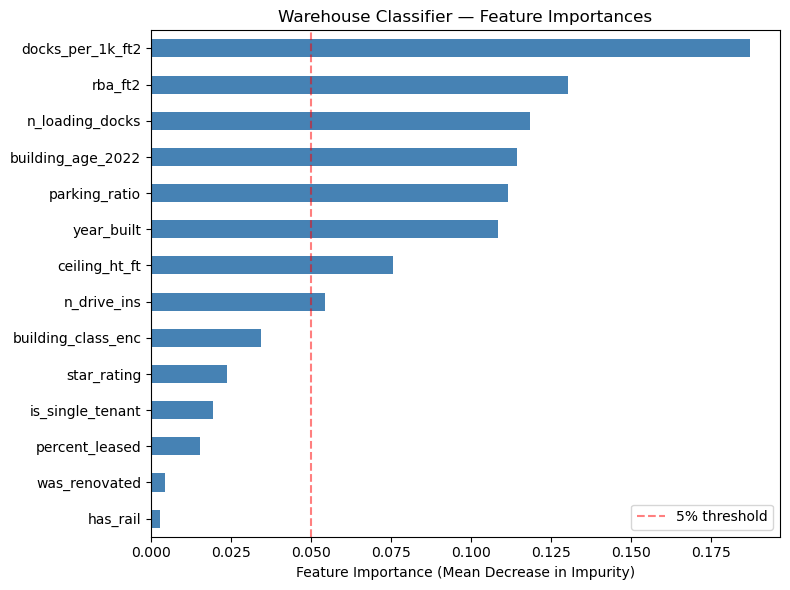


✅ Predicted 7,919 warehouses out of 18,567 candidate buildings (42.7%)
   High confidence: 1,597
   Medium confidence: 16,923
   Low confidence: 47
CoStar warehouse predictions merged: 7,919 buildings flagged as warehouse
                                            geometry  warehouse_prob  \
0  POLYGON ((-117.95756 34.07195, -117.95743 34.0...           0.424   
1  POLYGON ((-117.94679 34.08547, -117.94677 34.0...           0.403   
2  POLYGON ((-117.97886 34.0761, -117.97882 34.07...           0.439   
3  POLYGON ((-117.98412 34.07197, -117.98408 34.0...           0.563   
4  POLYGON ((-118.02702 34.15227, -118.0275 34.15...           0.512   

   is_warehouse confidence_tier  
0             0          Medium  
1             0          Medium  
2             0          Medium  
3             1          Medium  
4             1          Medium  
=== Match Diagnosis ===
Total footprints:         18,567
Matched to CoStar:        2,988 (16.1%)
Unmatched footprints:     15,579
CoStar poi

In [106]:
# ==============================================================================
# STEP 9: CoStar integration
# ==============================================================================

data_dir = path + 'Task1_Characterization/Data/CoStar/'

# ---- A. Load all CoStar exports ----
positive_files = [
    data_dir + 'LA1.csv',
    data_dir + 'LA2.csv',
    data_dir + 'LA3.csv',
    data_dir + 'LA4.csv',
    data_dir + 'LA5.csv',
    data_dir + 'LA6.csv',
    data_dir + 'LA_distribution1.csv',
    data_dir + 'LA_distribution2.csv',
    data_dir + 'LA_refrigerated.csv',
    data_dir + 'OR1.csv',
    data_dir + 'OR2.csv',
    data_dir + 'OR_distribution.csv',
    data_dir + 'OR_refrigerated.csv',
    data_dir + 'IE1.csv',
    data_dir + 'IE2.csv',
    data_dir + 'IE3.csv',
    data_dir + 'IE4.csv',
    data_dir + 'IE_refrigerated.csv',
    data_dir + 'IE_distribution1.csv',
    data_dir + 'IE_distribution2.csv',
    data_dir + 'Truck_Terminal.csv',
    data_dir + 'VE.csv',
]
negative_files = [
    data_dir + 'LA_manufacture1.csv',
    data_dir + 'LA_manufacture2.csv',
    data_dir + 'LA_manufacture3.csv',
    data_dir + 'OR_manufacture.csv',
    data_dir + 'IE_manufacture.csv',
    data_dir + 'Others.csv',
    data_dir + 'VE_others.csv',
]

costar_positive = load_costar_exports(positive_files, label=1)
costar_negative = load_costar_exports(negative_files, label=0)

# ---- B. Engineer features ----
positive_featured = engineer_costar_features(costar_positive, warehouse_guard=True)
negative_featured = engineer_costar_features(costar_negative)

# ---- C. Geocode (skip if cached files already exist) ----
pos_cache = path + 'Task1_Characterization/Shapefiles/costar_positive_geocoded.gpkg'
neg_cache = path + 'Task1_Characterization/Shapefiles/costar_negative_geocoded.gpkg'

if Path(pos_cache).exists() and Path(neg_cache).exists():
    print("Loading cached geocoded CoStar files...")
    costar_positive_gdf = gdp.read_file(pos_cache)
    costar_negative_gdf = gdp.read_file(neg_cache)
else:
    study_bounds = (-119.75, 33.30, -114.13, 35.82)
    costar_positive_gdf = geocode_costar(positive_featured,
                                         study_area_bounds=study_bounds)
    costar_negative_gdf = geocode_costar(negative_featured,
                                         study_area_bounds=study_bounds)
    # Save immediately — geocoding takes ~30 min, never repeat unnecessarily
    costar_positive_gdf.to_file(pos_cache, driver='GPKG')
    costar_negative_gdf.to_file(neg_cache, driver='GPKG')
    print(f"Geocoded files saved to {pos_cache}")

# ---- D. Operational proxies (positives only → WAIRE inventory) ----
costar_with_ops = extract_operations_proxies(costar_positive_gdf)

# ---- E. Build training data ----
# Verify FEATURE_COLS has 17 entries before building X, y
print(f"FEATURE_COLS count: {len(FEATURE_COLS)}")  # must be 17
assert len(FEATURE_COLS) == 17, (
    "FEATURE_COLS has wrong length — re-run the cell that defines "
    "FEATURE_COLS before running this cell"
)
X, y = build_training_data(costar_positive_gdf, costar_negative_gdf)
print(f"Training set: {(y==1).sum()} warehouses / {(y==0).sum()} non-warehouses")
print(f"Feature matrix shape: {X.shape}")  # must be (N, 17)

# ---- F. Enrich footprints with CoStar spatial join ----
gdf_enriched = enrich_footprints_with_costar(
    gdf_scored, costar_with_ops, near_m=150, weak_m=500
)

# ---- G. Also enrich with SCAG features for the 17-feature model ----
# scag_is_warehouse, scag_is_industrial, building_coverage are already
# in gdf_scored from Step 6 — transfer them to gdf_enriched
for col in ['scag_is_warehouse', 'scag_is_industrial',
            'building_coverage', 'scag_land_use_class']:
    if col in gdf_scored.columns and col not in gdf_enriched.columns:
        gdf_enriched[col] = gdf_scored[col].reindex(gdf_enriched.index)

# ---- H. Train classifier ----
model = train_warehouse_classifier(X, y, model_type='random_forest')
plot_feature_importance(
    model,
    save_path=path + 'Task1_Characterization/Figures/warehouse_feature_importance.png'
)

# ---- I. Predict on enriched footprints (not raw gdf_scored) ----
classified = predict_warehouses(
    gdf_enriched,          # ← enriched GDF with CoStar + SCAG features
    model,
    prob_threshold=0.5
)

# ---- MERGE classifier results back into gdf_scored ----
# assign_warehouse_labels_final() reads 'is_warehouse' and 'warehouse_prob'
# from gdf_scored, but those columns currently only exist in 'classified'
gdf_scored = gdf_scored.copy()
for col in ['is_warehouse', 'warehouse_prob', 'confidence_tier']:
    if col in classified.columns:
        gdf_scored[col] = classified[col].reindex(gdf_scored.index)

# Restore CoStar temporal columns that enrich_footprints_with_costar added to
# gdf_enriched but were never propagated back to gdf_scored
for col in ['ops_start_year', 'intensity_tier', 'is_high_cube',
            'is_likely_crossdock', 'year_built',
            'costar_match_confidence', 'costar_match_dist_m']:
    if col in gdf_enriched.columns and col not in gdf_scored.columns:
        gdf_scored[col] = gdf_enriched[col].reindex(gdf_scored.index)

print(f"CoStar warehouse predictions merged: "
      f"{gdf_scored['is_warehouse'].sum():,} buildings flagged as warehouse")

# Save the classified inventory with CoStar predictions as a new layer      
classified.to_file(
    path + 'Task1_Characterization/Shapefiles/warehouse_inventory_classified.gpkg',
    driver='GPKG'
)
print(classified[['geometry', 'warehouse_prob',
                  'is_warehouse', 'confidence_tier']].head())


# ==============================================================================
# Classification diagnosis and error analysis
# ==============================================================================
def diagnose_enrichment_match(gdf_enriched, costar_gdf):
    """
    Diagnose CoStar match rate without topology-sensitive union operations.
    """
    matched = gdf_enriched[gdf_enriched['n_loading_docks'].notna()]
    unmatched_footprints = gdf_enriched[gdf_enriched['n_loading_docks'].isna()]

    print("=== Match Diagnosis ===")
    print(f"Total footprints:         {len(gdf_enriched):,}")
    print(f"Matched to CoStar:        {len(matched):,} ({100*len(matched)/len(gdf_enriched):.1f}%)")
    print(f"Unmatched footprints:     {len(unmatched_footprints):,}")
    print(f"CoStar points available:  {len(costar_gdf):,}")
    print(f"CoStar geocode failures:  {costar_gdf['geometry'].isna().sum():,}")

    # --- Use bounding box instead of unary_union (avoids topology errors) ---
    costar_valid = costar_gdf[costar_gdf.geometry.notna()].to_crs(3310)
    footprint_proj = gdf_enriched.to_crs(3310)

    # Bounding box of all footprints
    total_bounds = footprint_proj.geometry.total_bounds  # (minx, miny, maxx, maxy)
    from shapely.geometry import box as shapely_box
    footprint_bbox = shapely_box(*total_bounds)

    costar_inside  = costar_valid[costar_valid.geometry.within(footprint_bbox)]
    costar_outside = costar_valid[~costar_valid.geometry.within(footprint_bbox)]

    print(f"\nCoStar points inside footprint bounding box:  {len(costar_inside):,}")
    print(f"CoStar points outside footprint bounding box: {len(costar_outside):,}")
    print("(Outside = geocoding landed outside study area)")

    # --- Distance from unmatched footprint centroids to nearest CoStar point ---
    from sklearn.neighbors import BallTree
    import numpy as np

    # Use centroids of footprints (safer than full geometry for distance calc)
    footprint_centroids = footprint_proj.copy()
    footprint_centroids['geometry'] = footprint_proj.geometry.centroid

    costar_coords = np.radians(np.column_stack([
        costar_valid.geometry.y,
        costar_valid.geometry.x
    ]))

    sample = unmatched_footprints.to_crs(3310).sample(
        min(500, len(unmatched_footprints)), random_state=42
    )
    sample_centroids = sample.geometry.centroid
    sample_coords = np.radians(np.column_stack([
        sample_centroids.y,
        sample_centroids.x
    ]))

    tree = BallTree(costar_coords, metric='haversine')
    distances, _ = tree.query(sample_coords, k=1)
    distances_m = distances[:, 0] * 6371000

    print(f"\nDistance from unmatched footprints to nearest CoStar point:")
    print(f"  Median:           {np.median(distances_m):,.0f} m")
    print(f"  75th percentile:  {np.percentile(distances_m, 75):,.0f} m")
    print(f"  90th percentile:  {np.percentile(distances_m, 90):,.0f} m")
    print(f"  Within  50m: {(distances_m <  50).sum():>4} / {len(sample)}")
    print(f"  Within 100m: {(distances_m < 100).sum():>4} / {len(sample)}")
    print(f"  Within 200m: {(distances_m < 200).sum():>4} / {len(sample)}")
    print(f"  Within 500m: {(distances_m < 500).sum():>4} / {len(sample)}")

    return matched, unmatched_footprints

# ---- J. Diagnose match rate ----
matched, unmatched = diagnose_enrichment_match(gdf_enriched, costar_with_ops)    

### 3.1 Checks 

CoStar coverage gap
CoStar positives (raw)            : 6,574
  geocode failures (no geometry)  : 6
  geocoded                        : 6,568
  geocoded AND rba >= 50,000 ft2 : 6,568   <- gap denominator
----------------------------------------------------------------
Matched to a footprint (<= 50 m) : 3,489 (53.1%)
CoStar-ONLY (no footprint)        : 3,079 (46.9%)   <- recoverable gap

Matched vs CoStar-only (bias check):
                  n  median_RBA_ft2  median_year_built  pct_built_2015+  median_port_km
matched      3489.0        102000.0             1988.0             15.2            41.2
CoStar_only  3079.0        107546.0             1990.0             21.3            56.7

Read: if CoStar-only rows are newer (higher median_year_built / higher
pct_built_2015+), larger, or farther from port, their omission biases the
growth-wave and inland-drift findings DOWNWARD.

CoStar-only by export region (_source_file prefix):
export_region
LA       1493
IE       1172
OR        277
VE    

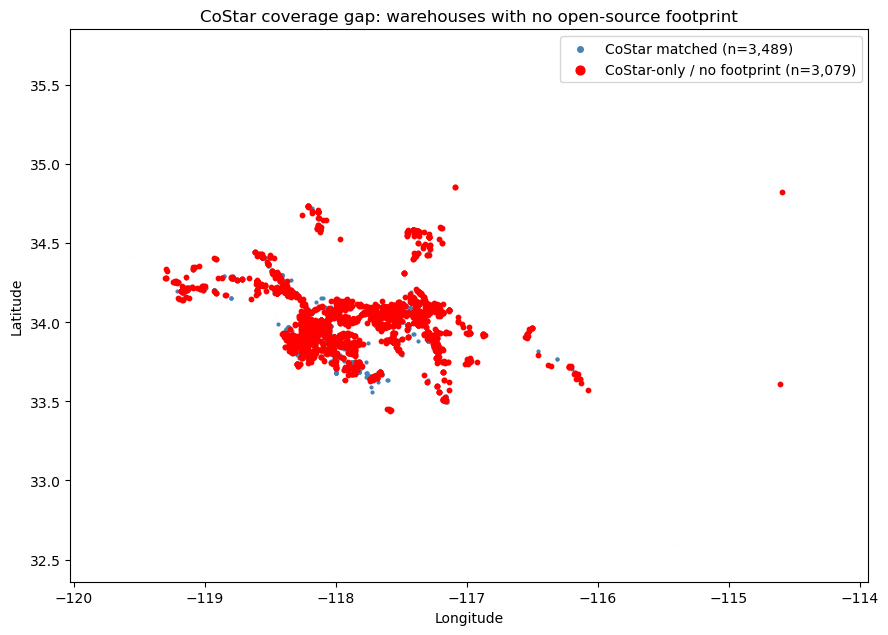


Saved 3,079 CoStar-only records -> C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Shapefiles/costar_only_unmatched.gpkg
Use this set for recovery (synthetic footprint from rba_ft2, or targeted NAIP detection around these points).


In [107]:
# ==============================================================================
# CoStar coverage gap — quantify CoStar-only warehouses (no footprint)
# ==============================================================================
# Reverse of diagnose_enrichment_match(): instead of "which footprints matched a
# CoStar record", this asks "which CoStar warehouses have NO footprint polygon in
# the open sources and are therefore dropped from the inventory."
#
# A CoStar point is MATCHED if any footprint in the universe (gdf_scored) lies
# within 50 m — the same radius enrich_footprints_with_costar() uses. Unmatched
# CoStar points are the 'CoStar-only' buildings.
#
# Inputs expected in memory:
#   costar_with_ops : geocoded CoStar positives (EPSG:4326) with rba_ft2,
#                     year_built, geometry, _source_file
#   gdf_scored      : merged footprint universe (Overture u MS u OSM), has 'county'
# ==============================================================================
from shapely.geometry import Point

MATCH_RADIUS_M = 50          # same as enrich_footprints_with_costar(max_dist_m=50)
MIN_RBA_FT2    = 50_000      # match the inventory threshold
PORT_LL        = (-118.270, 33.740)   # Port of LA/Long Beach (as in centrographic)

# ---- 1. Prepare CoStar points: valid geocode + warehouse size ----------------
cs = costar_with_ops.copy()
cs = cs[cs.geometry.notna()].to_crs(3310)
n_all = len(cs)

if "rba_ft2" in cs.columns:
    cs_size = cs[cs["rba_ft2"].fillna(0) >= MIN_RBA_FT2].copy()
else:
    print("WARNING: rba_ft2 not found; using all geocoded CoStar records.")
    cs_size = cs.copy()

# ---- 2. Match each CoStar point to the footprint universe (<= 50 m) -----------
foot = gdf_scored.to_crs(3310)[["geometry"] +
        (["county"] if "county" in gdf_scored.columns else [])].copy()

matched_join = gdp.sjoin_nearest(
    cs_size, foot, how="left", max_distance=MATCH_RADIUS_M, distance_col="dist_m"
)
# sjoin_nearest can emit duplicate rows on ties — collapse to one row per CoStar id
matched_join = matched_join[~matched_join.index.duplicated(keep="first")]

is_matched = matched_join["dist_m"].notna()
cs_matched   = cs_size.loc[is_matched.values].copy()
cs_unmatched = cs_size.loc[(~is_matched).values].copy()

# ---- 3. Headline counts ------------------------------------------------------
geocode_fail = costar_with_ops.geometry.isna().sum()
print("=" * 64)
print("CoStar coverage gap")
print("=" * 64)
print(f"CoStar positives (raw)            : {len(costar_with_ops):,}")
print(f"  geocode failures (no geometry)  : {geocode_fail:,}")
print(f"  geocoded                        : {n_all:,}")
print(f"  geocoded AND rba >= {MIN_RBA_FT2:,} ft2 : {len(cs_size):,}   <- gap denominator")
print("-" * 64)
print(f"Matched to a footprint (<= {MATCH_RADIUS_M} m) : {len(cs_matched):,} "
      f"({100*len(cs_matched)/max(len(cs_size),1):.1f}%)")
print(f"CoStar-ONLY (no footprint)        : {len(cs_unmatched):,} "
      f"({100*len(cs_unmatched)/max(len(cs_size),1):.1f}%)   <- recoverable gap")
print("=" * 64)

# ---- 4. Bias check: are the missing ones newer / larger / more exurban? -------
port_m = gdp.GeoSeries([Point(*PORT_LL)], crs=4326).to_crs(3310).iloc[0]
for d in (cs_matched, cs_unmatched):
    d["port_km"] = d.geometry.centroid.distance(port_m) / 1000

def _summ(d):
    yb = d["year_built"] if "year_built" in d.columns else pd.Series(dtype=float)
    return {
        "n": len(d),
        "median_RBA_ft2": round(d["rba_ft2"].median(), 0) if "rba_ft2" in d else None,
        "median_year_built": round(yb.median(), 0) if yb.notna().any() else None,
        "pct_built_2015+": round(100 * (yb >= 2015).mean(), 1) if yb.notna().any() else None,
        "median_port_km": round(d["port_km"].median(), 1),
    }

bias = pd.DataFrame({"matched": _summ(cs_matched),
                     "CoStar_only": _summ(cs_unmatched)}).T
print("\nMatched vs CoStar-only (bias check):")
print(bias.to_string())
print("\nRead: if CoStar-only rows are newer (higher median_year_built / higher")
print("pct_built_2015+), larger, or farther from port, their omission biases the")
print("growth-wave and inland-drift findings DOWNWARD.")

# ---- 5. Breakdown of the gap -------------------------------------------------
if "_source_file" in cs_unmatched.columns:
    region = (cs_unmatched["_source_file"].astype(str)
              .str.replace(r".*/", "", regex=True).str.extract(r"^([A-Za-z]+)")[0])
    region.name = "export_region"
    print("\nCoStar-only by export region (_source_file prefix):")
    print(region.value_counts().to_string())

if "year_built" in cs_unmatched.columns and cs_unmatched["year_built"].notna().any():
    dec = (cs_unmatched["year_built"].dropna() // 10 * 10).astype(int)
    print("\nCoStar-only by construction decade:")
    print(dec.value_counts().sort_index().to_string())

if "rba_ft2" in cs_unmatched.columns:
    bands = pd.cut(cs_unmatched["rba_ft2"],
                   [50e3, 100e3, 250e3, 500e3, 1e6, np.inf],
                   labels=["50-100k", "100-250k", "250-500k", "500k-1M", "1M+"])
    print("\nCoStar-only by RBA size band:")
    print(bands.value_counts().sort_index().to_string())

# ---- 6. Map: matched vs CoStar-only ------------------------------------------
fig, ax = plt.subplots(figsize=(9, 8))
foot.to_crs(4326).sample(min(4000, len(foot)), random_state=42).plot(
    ax=ax, color="0.85", markersize=0.5, label="footprints (sample)")
cs_matched.to_crs(4326).plot(ax=ax, color="steelblue", markersize=4,
    label=f"CoStar matched (n={len(cs_matched):,})")
cs_unmatched.to_crs(4326).plot(ax=ax, color="red", markersize=10,
    label=f"CoStar-only / no footprint (n={len(cs_unmatched):,})")
ax.set_title("CoStar coverage gap: warehouses with no open-source footprint")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.legend(markerscale=2)
plt.tight_layout(); plt.show()

# ---- 7. Save the gap for the recovery step -----------------------------------
gap_path = path + "Task1_Characterization/Shapefiles/costar_only_unmatched.gpkg"
cs_unmatched.to_crs(4326).to_file(gap_path, driver="GPKG")
print(f"\nSaved {len(cs_unmatched):,} CoStar-only records -> {gap_path}")
print("Use this set for recovery (synthetic footprint from rba_ft2, or targeted "
      "NAIP detection around these points).")


Match-radius sensitivity (CoStar warehouses >= 50k ft2)
  denominator N = 6,568
  radius (m)   matched  unmatched    gap %
  ----------------------------------------
          50     3,489      3,079    46.9%
         100     4,578      1,990    30.3%
         200     5,433      1,135    17.3%
         350     6,034        534     8.1%
         500     6,205        363     5.5%
        1000     6,502         66     1.0%


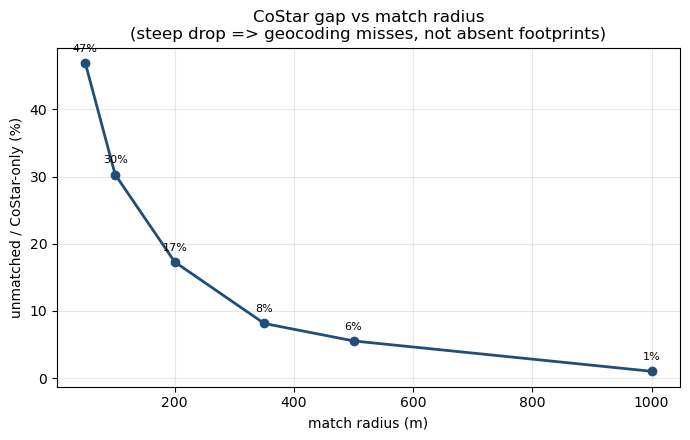


Decomposition of the original 50 m gap (n=3,079):
  footprint within 50-500 m (geocoding miss / fragment): 2,716
  no footprint within 500 m  (TRUE recoverable gap)     : 363
  true_residual    n=  363  med_RBA=  147,249  med_yr=2008  med_port_km=96.3
  everything_else  n=6,205  med_RBA=  103,014  med_yr=1988  med_port_km=45.2

Saved 363 true-gap records -> C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Shapefiles/costar_true_gap.gpkg


In [108]:

# ==============================================================================
# Match-radius sensitivity — how much of the CoStar gap is real?
# ==============================================================================
# Each CoStar point's nearest-footprint distance is computed ONCE; the match
# count at any radius r is just (nearest_dist <= r). If the gap collapses as r
# grows, the "unmatched" buildings mostly DO have footprints and were missed by
# geocoding precision, not genuinely absent. Buildings still unmatched at
# TRUE_GAP_RADIUS_M are the real recovery candidates.
#
# Inputs: costar_with_ops (EPSG:4326, rba_ft2, year_built), gdf_scored (footprints)
# ==============================================================================
from shapely.geometry import Point

MIN_RBA_FT2       = 50_000
RADII_M           = [50, 100, 200, 350, 500, 1000]
TRUE_GAP_RADIUS_M = 500          # beyond this we treat a footprint as truly absent
PORT_LL           = (-118.270, 33.740)

# ---- 1. CoStar points (valid geocode, warehouse size) ------------------------
cs = costar_with_ops.copy()
cs = cs[cs.geometry.notna()].to_crs(3310)
if "rba_ft2" in cs.columns:
    cs = cs[cs["rba_ft2"].fillna(0) >= MIN_RBA_FT2].copy()
N = len(cs)

# ---- 2. Nearest footprint distance for every CoStar point (ONE join) ---------
foot = gdf_scored.to_crs(3310)[["geometry"]].copy()
nn = gdp.sjoin_nearest(cs, foot, how="left", distance_col="nn_dist_m")
nn = nn[~nn.index.duplicated(keep="first")]          # collapse ties
d  = nn["nn_dist_m"].values

# ---- 3. Sensitivity table ----------------------------------------------------
print("=" * 60)
print("Match-radius sensitivity (CoStar warehouses >= 50k ft2)")
print(f"  denominator N = {N:,}")
print("=" * 60)
print(f"  {'radius (m)':>10} {'matched':>9} {'unmatched':>10} {'gap %':>8}")
print("  " + "-" * 40)
rows = []
for r in RADII_M:
    m = int((d <= r).sum()); u = N - m
    rows.append((r, m, u, 100 * u / N))
    print(f"  {r:>10} {m:>9,} {u:>10,} {100*u/N:>7.1f}%")
print("=" * 60)

# ---- 4. Curve ----------------------------------------------------------------
import matplotlib.pyplot as plt
rr, mm, uu, gg = zip(*rows)
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(rr, gg, "o-", color="#1F4E79", lw=2)
ax.set_xlabel("match radius (m)"); ax.set_ylabel("unmatched / CoStar-only (%)")
ax.set_title("CoStar gap vs match radius\n(steep drop => geocoding misses, not absent footprints)")
ax.grid(alpha=0.3)
for r, g in zip(rr, gg):
    ax.annotate(f"{g:.0f}%", (r, g), textcoords="offset points", xytext=(0, 8),
                ha="center", fontsize=8)
plt.tight_layout(); plt.show()

# ---- 5. The true residual (still unmatched at TRUE_GAP_RADIUS_M) -------------
residual = cs.loc[(d > TRUE_GAP_RADIUS_M)].copy()
artifact = cs.loc[(d > 50) & (d <= TRUE_GAP_RADIUS_M)].copy()  # footprint within 500 m
print(f"\nDecomposition of the original 50 m gap (n={int((d>50).sum()):,}):")
print(f"  footprint within 50-{TRUE_GAP_RADIUS_M} m (geocoding miss / fragment): {len(artifact):,}")
print(f"  no footprint within {TRUE_GAP_RADIUS_M} m  (TRUE recoverable gap)     : {len(residual):,}")

# ---- 6. Is the TRUE residual biased? -----------------------------------------
port_m = gdp.GeoSeries([Point(*PORT_LL)], crs=4326).to_crs(3310).iloc[0]
for nm, dfp in [("true_residual", residual),
                ("everything_else", cs.loc[d <= TRUE_GAP_RADIUS_M])]:
    dfp = dfp.copy(); dfp["port_km"] = dfp.geometry.centroid.distance(port_m) / 1000
    yb = dfp["year_built"] if "year_built" in dfp.columns else pd.Series(dtype=float)
    print(f"  {nm:16s} n={len(dfp):>5,}  med_RBA={dfp['rba_ft2'].median():>9,.0f}  "
          f"med_yr={yb.median() if yb.notna().any() else float('nan'):.0f}  "
          f"med_port_km={dfp['port_km'].median():.1f}")

# ---- 7. Save the true residual for recovery ----------------------------------
out = path + "Task1_Characterization/Shapefiles/costar_true_gap.gpkg"
residual.to_crs(4326).to_file(out, driver="GPKG")
print(f"\nSaved {len(residual):,} true-gap records -> {out}")

### 3.2 Visualization


Costar VS Data based

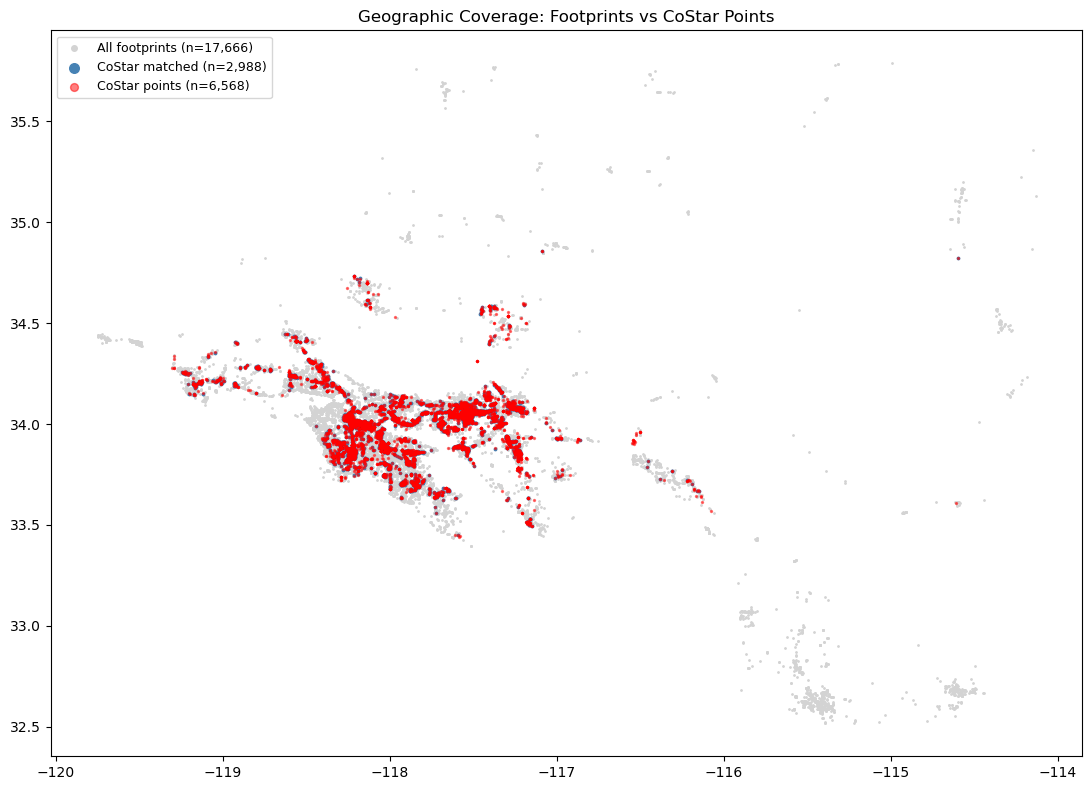

In [109]:
# Plot CoStar points and footprint centroids to visually assess coverage and geocoding issues
fig, ax = plt.subplots(figsize=(12, 8))

# All footprint centroids
gdf_enriched.to_crs(4326).geometry.centroid.plot(
    ax=ax, color='lightgrey', markersize=1, label='All footprints (n=17,666)'
)

# Matched footprints
matched_mask = gdf_enriched['n_loading_docks'].notna()
gdf_enriched[matched_mask].to_crs(4326).geometry.centroid.plot(
    ax=ax, color='steelblue', markersize=3, label=f'CoStar matched (n={matched_mask.sum():,})'
)

# CoStar points
costar_valid = costar_with_ops[costar_with_ops.geometry.notna()]
costar_valid.to_crs(4326).geometry.plot(
    ax=ax, color='red', markersize=2, alpha=0.5, label=f'CoStar points (n={len(costar_valid):,})'
)

ax.set_title('Geographic Coverage: Footprints vs CoStar Points')
ax.legend(markerscale=4, fontsize=9)
plt.tight_layout()
plt.savefig('coverage_map.png', dpi=150)
plt.show()

Data source comparison

Two interactive maps are provided:

1. **Source comparison** - shows raw Microsoft and Overture footprints side-by-side (sampled to 5,000 buildings each for performance)
2. **NAIP + classification** - overlays NAIP imagery with detected roof polygons and the classified building inventory

Use the layer toggles in geemap to compare sources. For detailed QA, open the exported `.gpkg` in QGIS and filter by `label`, `confidence_note`, or `needs_review`.



In [110]:
# ── Map 1: Source comparison ─────────────────────────────────
Map1 = geemap.Map(center=[34.05, -118.25], zoom=8)

Map1.add_gdf(
    ms_buildings.sample(min(5000, len(ms_buildings)), random_state=42),
    layer_name="Microsoft Buildings (≥50k ft²)",
    style={"color": "orange", "fillColor": "none", "weight": 1}
)
Map1.add_gdf(
    ov_buildings.sample(min(5000, len(ov_buildings)), random_state=42),
    layer_name="Overture Buildings (≥50k ft²)",
    style={"color": "blue", "fillColor": "none", "weight": 1}
)
Map1.add_gdf(
    gdf_final[gdf_final['label'] == 'confirmed'],
    layer_name="Confirmed Warehouses",
    style={"color": "red", "fillColor": "#ff000033", "weight": 1}
)

Map1


Map(center=[34.05, -118.25], controls=(WidgetControl(options=['position', 'transparent_bg'], position='toprigh…

### 3.3. QGIS Quick-Start Filters

| Filter | Expression |
|--------|-----------|
| Confirmed warehouses | `"label" = 'confirmed'` |
| Candidates needing review | `"needs_review" = 1` |
| Excluded buildings | `"label" = 'excluded'` |
| Confirmed DCs in exclusion zones | `"confidence_note" LIKE '%lu_conflict_kept%'` |
| Overture-confirmed warehouses | `"confidence_note" LIKE 'overture_class%'` |

## 4. Final Inventory Compilation

After Steps 9 produce `gdf_scored` (full building set with confidence scores
and CoStar enrichment), this step compiles the **clean final inventory** by
applying a two-tier inclusion rule:

| Included | Criterion |
|----------|-----------|
| All `confirmed` buildings | Strong positive signal: OSM tag, Overture class, operator name, or shape metric |
| `candidate` buildings with `confidence_tier == 'high'` | Pass all exclusion filters **and** composite score ≥ 60 |

Buildings labelled `excluded` (non-warehouse signal) and low/review-tier
candidates are **retained in `gdf_scored` for audit** but excluded from the
final inventory used in spatial analysis.

Two new columns are added:
- `in_final_inventory` : `True` for every row in this subset
- `inventory_reason`   : `'confirmed'` | `'high_confidence_candidate'`

In [172]:
# ==============================================================================
# STEP 10: Final label assignment
# ==============================================================================
gdf_scored = assign_warehouse_labels_final(gdf_scored)  # overwrite in place
assert 'ops_start_year' in gdf_scored.columns, "ops_start_year lost at label assignment"
# ==============================================================================
# STEP 11: Final inventory compilation
# ==============================================================================
gdf_final_inventory = compile_final_inventory(gdf_scored)
assert 'ops_start_year' in gdf_final_inventory.columns, "ops_start_year lost at compile"
# ==============================================================================
# STEP 12: Facility Subclassification
# ==============================================================================
# Assigns one of four functional subtypes to every *confirmed* building.
# Pass 1: seed labels from operator names (high-confidence training anchors)
# Pass 2: rule-based assignment for remaining confirmed buildings
#
# NOTE: pop_density_col is None until the LEHD/ACS tract panel is assembled
# in Stage 3. Once available, pass the column name (e.g., 'pop_density_km2')
# to enable the urban/rural distinction in Rule 3 of assign_facility_subclass().
# ==============================================================================

gdf_seeded = seed_labels_from_names(gdf_final_inventory)
gdf_final_classified = assign_facility_subclass(
    gdf_seeded,
    rdc_area_ft2=250_000,
    udf_area_ft2=50_000,
    rdc_rect_min=0.82,
    udf_elong_min=1.5,
    rural_lu_classes={'Agriculture', 'Bare_land/other', 'Nature_Vegetation'},
    pop_density_col=None,
    urban_density_threshold=1_500,
)
assert 'ops_start_year' in gdf_final_classified.columns, "ops_start_year lost at subclass"
# Export clean final inventory
inv_path = path + "Task1_Characterization/Shapefiles/warehouse_final_inventory.gpkg"
gdf_final_classified.to_file(inv_path, driver="GPKG")
print(f"\n  Exported → {inv_path}")

Confidence score threshold (60th pctile of industrial/warehouse): 35.0

=== Final label distribution ===
  excluded    :  8,865  (47.7%)
  confirmed   :  7,701  (41.5%)
  candidate   :  1,224  (6.6%)
  unknown     :    777  (4.2%)

  Signal breakdown:
  SCAG 1340 confirmed    : 2,535
  CoStar confirmed       : 7,919
  High-score confirmed   : 5,446
  Industrial candidates  : 8,091
  Construction/mil candidates : 92
Label counts entering compile:
label
excluded     8865
confirmed    7701
candidate    1224
unknown       777

Candidate confidence_score median: 25.0

  FINAL INVENTORY SUMMARY
  Universe (gdf_scored)               :  18,567
  ├─ Confirmed (all)                  :   7,701
  ├─ High-confidence candidates        :   1,125
  ├─ SCAG-confirmed (not yet labeled)  :       0
  └─ Explicitly excluded               :   8,865
  ---------------------------------------------
  FINAL INVENTORY TOTAL               :   8,826  (47.5% of universe)
  Seed labels assigned : 82 buildings
  Seed

#### 4.1. Manual check for a Sample

In [173]:
# ==============================================================================
# STEP 11b: Manual review corrections
# ==============================================================================
# Two corrections based on visual inspection of San Bernardino buildings:
#   1. Fid_to_integrate: warehouses incorrectly excluded at Step 8
#      → load from lu_filtered file and add to final inventory
#   2. Fid_to_remove: non-warehouses incorrectly included at Step 12
#      → remove from final inventory

# Manual review checklist
# San Bernardino County, fid: 17, 2, 19, 20, 28, 14, 16, 44, 42, 39, 40, 3, 9 

# warehouse_inventory_lu_filtered.gpkg fids from step 8
Fid_to_integrate = [8819, 8031, 4428, 4429, 4376, 4309, 10983, 10970, 10972, 10982, 4384, 3892,
                    3891, 8682, 365, 16702, 4455, 4377, 4424, 4428, 4429, 4376, 4309, 4308, 
                    10979, 4427, 10981, 10985, 11200, 11199, 11223, 11222, 4407, 4416, 4409,
                    11083, 11046, 11045, 4454, 4368, 4440, 4474, 11712, 4323, 4332, 4294, 4293,
                    4374, 4373, 4343, 4069, 4292, 4319, 4430, 4296, 4361, 4360, 4320, 4091,
                    4068, 11538, 11539, 3944, 3899, 3898, 3929, 3710, 11943, 4185, 4154, 12765,
                    4153, 12802, 3966, 7080, 4031, 13662, 13658, 4141, 4140, 4113, 3774, 3717,
                    3712, 4106] 

# warehouse_final_inventory.gpkg fids from step 12
Fid_to_remove = [4497, 4498, 4499, 4396, 4394, 4393, 4404, 7213, 4403, 4401, 4402, 4417, 4461, 
                 4467, 4418, 4455, 4465, 4464, 4463, 4432, 4430, 4433, 4422, 4423, 4438, 4449,
                 523, 4378, 4471, 4458, 7539, 7807, 4479, 4478, 4474, 4542, 4543, 4544, 4556,
                 24, 4579, 2621, 2614, 4590, 2618, 4626, 4645, 27, 4640, 4767, 4638, 4766, 4765,
                 7883, 2586, 4768, 5542, 5636, 5633, 5653, 5685, 5672, 5688, 5687, 8074, 368, 
                 5660, 5612, 5617, 5616, 5620, 5618, 5662, 5665, 5677, 5523, 5501, 5502, 5433, 
                 5432, 5655, 987, 5510, 8076, 5506, 5500, 5504, 5489, 5480, 5490, 5491, 5482, 
                 5485, 5486, 5493, 5410, 5511, 5487, 5497, 5495, 5465, 5464, 5472, 5445, 5448, 
                 5473, 8092,5425, 5424, 8062,5454, 5417, 4623, 4645, 5449, 774, 788, 795, 794, 
                 796, 797, 798, 5720,746, 906, 5762, 484, 485, 487, 4281, 17095, 12221, 4457,
                 12831, 702, 689, 6282, 5489, 5497, 5892, 67, 295, 5872, 796          
                 ] 



# ── 1. Reintegrate falsely excluded buildings ─────────────────────────────────
gdf_lu_filtered = gdf_scored.copy()  # start with scored GDF to retain all columns

# Select the buildings to reintegrate
reintegrate = gdf_lu_filtered[gdf_lu_filtered.index.isin(Fid_to_integrate)].copy()

# Tag them so you know they came from manual review
reintegrate['label'] = 'confirmed'
reintegrate['inventory_reason'] = 'manual_review_reintegrated'
reintegrate['year_source'] = reintegrate.get('year_source', 'unknown')

# Align columns before concatenation
shared_cols = [c for c in gdf_final_inventory.columns if c in reintegrate.columns]
missing_cols = [c for c in gdf_final_inventory.columns if c not in reintegrate.columns]
for col in missing_cols:
    reintegrate[col] = None

reintegrate = reintegrate[gdf_final_inventory.columns].copy()

n_before = len(gdf_final_inventory)
gdf_final_inventory = gdp.GeoDataFrame(
    pd.concat([gdf_final_inventory, reintegrate], ignore_index=True),
    crs=gdf_final_inventory.crs,
)

# Drop duplicates by geometry (in case some were already present)
gdf_final_inventory = gdf_final_inventory.drop_duplicates(
    subset=['geometry'], keep='first'
)

print(f"Reintegrated: {len(reintegrate):,} buildings from manual review")
print(f"  Inventory: {n_before:,} → {len(gdf_final_inventory):,}")

# ── 2. Remove false positives ────────────────────────────────────────────────
n_before = len(gdf_final_inventory)
remove_mask = gdf_final_inventory.index.isin(Fid_to_remove)
n_removing = remove_mask.sum()

# Save the removed buildings for documentation
gdf_removed = gdf_final_inventory[remove_mask].copy()
gdf_removed['removal_reason'] = 'manual_review_false_positive'

gdf_final_inventory = gdf_final_inventory[~remove_mask].copy()

print(f"\nRemoved: {n_removing:,} false positives from manual review")
print(f"  Inventory: {n_before:,} → {len(gdf_final_inventory):,}")

# ── 3. Export corrected inventory ─────────────────────────────────────────────
corrected_path = (path + 
    "Task1_Characterization/Shapefiles/warehouse_final_inventory_corrected.gpkg")
gdf_final_inventory.to_file(corrected_path, driver="GPKG")
print(f"\nExported corrected inventory → {corrected_path}")

# Also export the removed set for audit trail
removed_path = (path + 
    "Task1_Characterization/Shapefiles/warehouse_manual_review_removed.gpkg")
gdf_removed.to_file(removed_path, driver="GPKG")
print(f"Exported removed buildings → {removed_path}")

Reintegrated: 81 buildings from manual review
  Inventory: 8,826 → 8,845

Removed: 137 false positives from manual review
  Inventory: 8,845 → 8,708

Exported corrected inventory → C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Shapefiles/warehouse_final_inventory_corrected.gpkg
Exported removed buildings → C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Shapefiles/warehouse_manual_review_removed.gpkg


#### 4.2. Classification calibration from manual review

In [174]:
# ==============================================================================
# STEP 11c: Classification calibration from manual review
# ==============================================================================
# Analyze what scores the manually corrected buildings had — this reveals
# whether the scoring thresholds need adjustment.

# What scores did the false positives have?
if 'confidence_score' in gdf_removed.columns:
    print("False positives — confidence score distribution:")
    print(gdf_removed['confidence_score'].describe().round(1))
    print(f"\nFalse positives by label:")
    print(gdf_removed['label'].value_counts().to_string())
    print(f"\nFalse positives by inventory_reason:")
    if 'inventory_reason' in gdf_removed.columns:
        print(gdf_removed['inventory_reason'].value_counts().to_string())

# What scores did the reintegrated buildings have in the original dataset?
if 'confidence_score' in gdf_lu_filtered.columns:
    reint_scores = gdf_lu_filtered[
        gdf_lu_filtered.index.isin(Fid_to_integrate)
    ]['confidence_score']
    print("\n\nReintegrated buildings — confidence score distribution:")
    print(reint_scores.describe().round(1))
    
    # What exclusion reason eliminated them?
    reint_labels = gdf_lu_filtered[
        gdf_lu_filtered.index.isin(Fid_to_integrate)
    ]['label']
    print(f"\nReintegrated buildings — original labels:")
    print(reint_labels.value_counts().to_string())

# Key question: is there a score gap?
# If false positives cluster at scores 35-50 and reintegrated at 30-45,
# then the threshold is in the right zone but needs per-feature refinement.
# If false positives have high scores (>60), the scoring signals are wrong.

False positives — confidence score distribution:
count    137.0
mean      30.2
std       17.3
min        0.0
25%       25.0
50%       25.0
75%       35.0
max       65.0
Name: confidence_score, dtype: float64

False positives by label:
label
confirmed    119
candidate     18

False positives by inventory_reason:


Reintegrated buildings — confidence score distribution:
count    81.0
mean     30.4
std      24.0
min       0.0
25%       0.0
50%      35.0
75%      55.0
max      65.0
Name: confidence_score, dtype: float64

Reintegrated buildings — original labels:
label
confirmed    57
excluded     19
candidate     5


#### 4.3. Census CBP Validation

In [175]:
# Download ZCTA shapefile programmatically
import urllib.request
import zipfile

zcta_dir = path + "Task1_Characterization/Data/Census/"
os.makedirs(zcta_dir, exist_ok=True)
zcta_zip_path = zcta_dir + "tl_2023_us_zcta520.zip"
zcta_shp_path = zcta_dir + "tl_2023_us_zcta520.shp"

if not os.path.exists(zcta_shp_path):
    url = "https://www2.census.gov/geo/tiger/TIGER2023/ZCTA520/tl_2023_us_zcta520.zip"
    print(f"Downloading ZCTA shapefile (~850 MB)...")
    urllib.request.urlretrieve(url, zcta_zip_path)
    print("Extracting...")
    with zipfile.ZipFile(zcta_zip_path, 'r') as z:
        z.extractall(zcta_dir)
    print(f"Done → {zcta_shp_path}")
else:
    print(f"ZCTA shapefile already exists at {zcta_shp_path}")

# Load and filter to California only (speeds up spatial join)
zcta = gdp.read_file(zcta_shp_path)
zcta_ca = zcta[zcta['ZCTA5CE20'].str.startswith('9')].copy()
zcta_ca = zcta_ca.to_crs(gdf_final_inventory.crs)
print(f"California ZCTAs loaded: {len(zcta_ca):,}")

# Spatial join inventory to ZCTAs
inv_pts = gdf_final_inventory.copy()
inv_pts['geometry'] = inv_pts.geometry.centroid

inv_with_zip = gdp.sjoin(
    inv_pts, 
    zcta_ca[['ZCTA5CE20', 'geometry']].rename(columns={'ZCTA5CE20': 'zipcode'}),
    how='left', predicate='within'
)

inv_by_zip = (inv_with_zip
    .groupby('zipcode')
    .agg(inv_count=('geometry', 'count'),
         inv_sqft=('area_ft2', 'sum'))
    .reset_index()
)
print(f"Inventory covers {len(inv_by_zip):,} unique ZIP codes")



ZCTA shapefile already exists at C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Data/Census/tl_2023_us_zcta520.shp
California ZCTAs loaded: 3,188
Inventory covers 376 unique ZIP codes


Fetching CBP data from Census API (2023)...

  Fetching NAICS 493... 2,182 ZIP codes, 15,316 establishments
  Fetching NAICS 492... 2,028 ZIP codes, 9,739 establishments

Total CBP records: 4,210
Total establishments: 25,055
Total employment: 0

CBP summary: 3,356 unique ZIP codes with warehouse/logistics activity

Fetching county-level for SCAG counties...

County                     Establishments   Employment
-------------------------------------------------------
  Los Angeles County                1,416       69,399
  San Bernardino County               641       76,888
  Orange County                       352       20,325
  Riverside County                    310       43,877
  Ventura County                       88        4,153
  Imperial County                      28          476
  TOTAL                             2,835      215,118

  INVENTORY vs CBP COMPARISON
  SCAG-region ZIP codes: 588

  SCAG REGION — NAICS 492+493 by ZIP Code
  Active ZIP codes:     379
  Inventory-

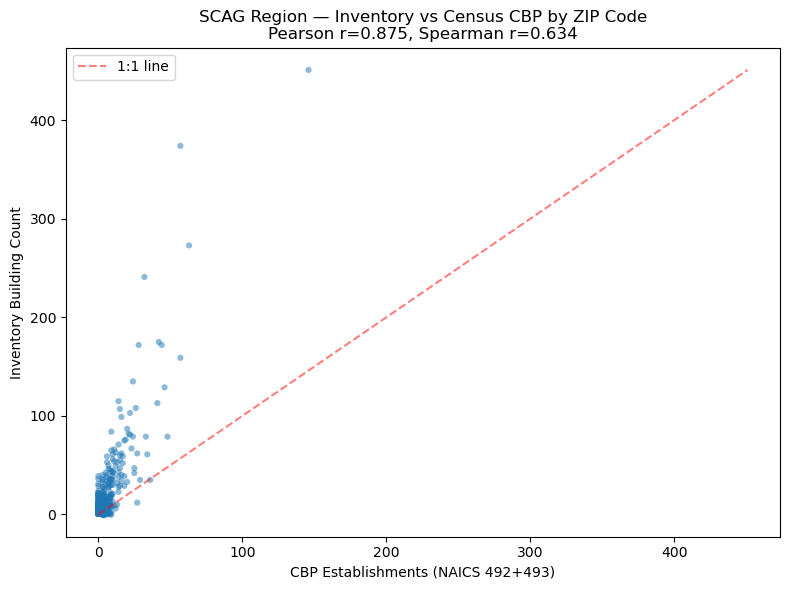


  Ratio (inventory / CBP) for ZIPs with both:
  count    195.00
mean       3.25
std        2.51
min        0.14
25%        1.33
50%        2.57
75%        4.36
max       13.33


In [176]:
# ==============================================================================
# STEP 11d: Census CBP Validation via API — ZIP Code Level
# ==============================================================================
import requests
import time

# ── 1. Define warehouse-related NAICS codes (3-digit level) ───────────────────
# Query at 3-digit level to capture all subcategories, then filter locally
WAREHOUSE_NAICS_CODES = {
    '493': 'Warehousing and Storage',
    '492': 'Couriers and Express Delivery Services',
    #'484': 'Truck Transportation',
}

# ── 2. Query Census CBP API ───────────────────────────────────────────────────
API_KEY = "aec7619993c145055b2a7c65030ed6f95aa38e71"
BASE_URL = "https://api.census.gov/data/2023/cbp"

def fetch_cbp_by_zipcode(naics_code, state_fips='06'):
    """
    Fetch CBP establishment and employment counts at ZIP code level
    for a given NAICS code in California.
    
    Uses EMPSZES=001 (all sizes) to get the total count per ZIP.
    """
    params = {
        'get': 'ESTAB,EMP,NAICS2017,NAICS2017_LABEL,NAME,GEO_ID',
        'for': 'zipcode:*',
        'NAICS2017': naics_code,
        'EMPSZES': '001',
        'key': API_KEY,
    }
    
    url = BASE_URL + '?' + '&'.join(f'{k}={v}' for k, v in params.items())
    print(f"  Fetching NAICS {naics_code}... ", end='')
    
    response = requests.get(url, timeout=60)
    
    if response.status_code != 200:
        print(f"ERROR {response.status_code}: {response.text[:200]}")
        return None
    
    data = response.json()
    if len(data) < 2:
        print(f"no data returned")
        return None
    
    df = pd.DataFrame(data[1:], columns=data[0])
    
    # Convert numeric columns
    for col in ['ESTAB', 'EMP']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0).astype(int)
    
    print(f"{len(df):,} ZIP codes, {df['ESTAB'].sum():,} establishments")
    return df


# Fetch all warehouse-related NAICS codes
print("Fetching CBP data from Census API (2023)...\n")
cbp_frames = []
for naics, label in WAREHOUSE_NAICS_CODES.items():
    df = fetch_cbp_by_zipcode(naics)
    if df is not None:
        df['naics_label'] = label
        cbp_frames.append(df)
    time.sleep(1)  # be polite to the API

if not cbp_frames:
    print("\nNo CBP data retrieved — Census API may be down.")
    print("Check: https://api.census.gov/data/2023/cbp.html")
else:
    cbp_all = pd.concat(cbp_frames, ignore_index=True)
    cbp_all = cbp_all.rename(columns={'zip code': 'zipcode'})
    print(f"\nTotal CBP records: {len(cbp_all):,}")
    print(f"Total establishments: {cbp_all['ESTAB'].sum():,}")
    print(f"Total employment: {cbp_all['EMP'].sum():,}")
    
    # ── 3. Aggregate by ZIP code ──────────────────────────────────────────────
    cbp_by_zip = (cbp_all
        .groupby('zipcode')
        .agg(
            cbp_establishments=('ESTAB', 'sum'),
            cbp_employees=('EMP', 'sum'),
            naics_categories=('naics_label', lambda x: ', '.join(x.unique())),
        )
        .reset_index()
    )
    print(f"\nCBP summary: {len(cbp_by_zip):,} unique ZIP codes with "
          f"warehouse/logistics activity")
    
    # ── 4. Also fetch county-level for broader comparison ─────────────────────
    print("\nFetching county-level for SCAG counties...")
    SCAG_COUNTY_FIPS = {
        '025': 'Imperial', '037': 'Los Angeles', '059': 'Orange',
        '065': 'Riverside', '071': 'San Bernardino', '111': 'Ventura',
    }
    
    county_frames = []
    for naics in WAREHOUSE_NAICS_CODES:
        params = {
            'get': 'ESTAB,EMP,NAICS2017,NAICS2017_LABEL,NAME',
            'for': 'county:*',
            'in': 'state:06',
            'NAICS2017': naics,
            'EMPSZES': '001',
            'key': API_KEY,
        }
        url = BASE_URL + '?' + '&'.join(f'{k}={v}' for k, v in params.items())
        resp = requests.get(url, timeout=60)
        if resp.status_code == 200:
            data = resp.json()
            df = pd.DataFrame(data[1:], columns=data[0])
            df['ESTAB'] = pd.to_numeric(df['ESTAB'], errors='coerce').fillna(0).astype(int)
            df['EMP'] = pd.to_numeric(df['EMP'], errors='coerce').fillna(0).astype(int)
            county_frames.append(df)
        time.sleep(1)
    
    if county_frames:
        cbp_county = pd.concat(county_frames, ignore_index=True)
        cbp_county_agg = (cbp_county
            .groupby(['state', 'county', 'NAME'])
            .agg(cbp_estab=('ESTAB', 'sum'), cbp_emp=('EMP', 'sum'))
            .reset_index()
        )
        
        # Filter to SCAG counties
        scag = cbp_county_agg[cbp_county_agg['county'].isin(SCAG_COUNTY_FIPS.keys())]
        print(f"\n{'County':<25} {'Establishments':>15} {'Employment':>12}")
        print("-" * 55)
        for _, row in scag.sort_values('cbp_estab', ascending=False).iterrows():
            name = row['NAME'].replace(', California', '')
            print(f"  {name:<23} {row['cbp_estab']:>15,} {row['cbp_emp']:>12,}")
        print(f"  {'TOTAL':<23} {scag['cbp_estab'].sum():>15,} "
              f"{scag['cbp_emp'].sum():>12,}")
    
    # ── 5. Compare with inventory at ZIP level ────────────────────────────────
    # Spatial join inventory to ZIP codes (using ZCTA boundaries)
    print("\n" + "=" * 60)
    print("  INVENTORY vs CBP COMPARISON")
    print("=" * 60)
    
    # Create ZIP from inventory centroids
    # Option A: if you have a ZIP column already
    if 'zipcode' in gdf_final_inventory.columns:
        inv_by_zip = (gdf_final_inventory
            .groupby('zipcode')
            .agg(inv_count=('geometry', 'count'),
                 inv_sqft=('area_ft2', 'sum'))
            .reset_index()
        )
    else:
        # Option B: spatial join with ZCTA boundaries
        # Download ZCTA shapefile if not available locally
        zcta_path = path + "Task1_Characterization/Data/Census/tl_2023_us_zcta520.shp"
        try:
            zcta = gdp.read_file(zcta_path)
        except:
            print("ZCTA shapefile not found. Download from:")
            print("  https://www.census.gov/cgi-bin/geo/shapefiles/index.php")
            print("  Year: 2023, Layer: ZIP Code Tabulation Areas")
            zcta = None
        
        if zcta is not None:
            zcta = zcta.to_crs(gdf_final_inventory.crs)
            inv_pts = gdf_final_inventory.copy()
            inv_pts['geometry'] = inv_pts.geometry.centroid
            
            inv_with_zip = gdp.sjoin(
                inv_pts, 
                zcta[['ZCTA5CE20', 'geometry']].rename(
                    columns={'ZCTA5CE20': 'zipcode'}
                ),
                how='left', predicate='within'
            )
            
            inv_by_zip = (inv_with_zip
                .groupby('zipcode')
                .agg(inv_count=('geometry', 'count'),
                     inv_sqft=('area_ft2', 'sum'))
                .reset_index()
            )
    
    # ── 6. Filter to SCAG region ZIPs only ────────────────────────────────────
    # Load SCAG county boundaries to identify which ZCTAs are in the region
    scag_county_fips = ['025', '037', '059', '065', '071', '111']
    
    counties_path = path + "Task1_Characterization/Data/Census/tl_2023_us_county.shp"
    try:
        counties = gdp.read_file(counties_path)
    except:
        # Download county shapefile
        import urllib.request, zipfile
        county_zip = path + "Task1_Characterization/Data/Census/tl_2023_us_county.zip"
        urllib.request.urlretrieve(
            "https://www2.census.gov/geo/tiger/TIGER2023/COUNTY/tl_2023_us_county.zip",
            county_zip
        )
        with zipfile.ZipFile(county_zip, 'r') as z:
            z.extractall(path + "Task1_Characterization/Data/Census/")
        counties = gdp.read_file(counties_path)
    
    scag_counties = counties[
        (counties['STATEFP'] == '06') & 
        (counties['COUNTYFP'].isin(scag_county_fips))
    ].to_crs(zcta_ca.crs)
    
    scag_boundary = scag_counties.dissolve()
    
    # Find ZCTAs whose centroids fall within SCAG boundary
    zcta_pts = zcta_ca.copy()
    zcta_pts['geometry'] = zcta_pts.geometry.centroid
    scag_zctas = gdp.sjoin(zcta_pts, scag_boundary[['geometry']], 
                            how='inner', predicate='within')
    scag_zip_set = set(scag_zctas['zipcode'].unique()) if 'zipcode' in scag_zctas.columns \
                   else set(scag_zctas['ZCTA5CE20'].unique())
    
    print(f"  SCAG-region ZIP codes: {len(scag_zip_set):,}")
    
    # Filter both datasets to SCAG ZIPs
    inv_scag = inv_by_zip[inv_by_zip['zipcode'].isin(scag_zip_set)].copy()
    cbp_scag = cbp_by_zip[cbp_by_zip['zipcode'].isin(scag_zip_set)].copy()
    
    # Merge
    comparison = inv_scag.merge(cbp_scag, on='zipcode', how='outer').fillna(0)
    active = comparison[
        (comparison['inv_count'] > 0) | (comparison['cbp_establishments'] > 0)
    ]
    
    r_p, p_p = pearsonr(active['inv_count'], active['cbp_establishments'])
    r_s, p_s = spearmanr(active['inv_count'], active['cbp_establishments'])
    
    print(f"\n{'='*60}")
    print(f"  SCAG REGION — NAICS 492+493 by ZIP Code")
    print(f"{'='*60}")
    print(f"  Active ZIP codes:     {len(active):,}")
    print(f"  Inventory-only ZIPs:  {(active['cbp_establishments']==0).sum():,}")
    print(f"  CBP-only ZIPs:        {(active['inv_count']==0).sum():,}")
    print(f"  Both sources:         "
          f"{((active['inv_count']>0) & (active['cbp_establishments']>0)).sum():,}")
    print(f"\n  Pearson r:   {r_p:.3f}  (p={p_p:.2e})")
    print(f"  Spearman r:  {r_s:.3f}  (p={p_s:.2e})")
    
    # Scatter plot
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(active['cbp_establishments'], active['inv_count'],
               alpha=0.5, s=20, edgecolors='none')
    maxval = max(active['cbp_establishments'].max(), active['inv_count'].max())
    ax.plot([0, maxval], [0, maxval], 'r--', alpha=0.5, label='1:1 line')
    ax.set_xlabel('CBP Establishments (NAICS 492+493)')
    ax.set_ylabel('Inventory Building Count')
    ax.set_title(f'SCAG Region — Inventory vs Census CBP by ZIP Code\n'
                 f'Pearson r={r_p:.3f}, Spearman r={r_s:.3f}')
    ax.legend()
    plt.tight_layout()
    plt.show()
    
    # Flag discrepancy ZIPs for investigation
    both = active[(active['inv_count'] > 0) & (active['cbp_establishments'] > 0)].copy()
    both['ratio'] = both['inv_count'] / both['cbp_establishments']
    print(f"\n  Ratio (inventory / CBP) for ZIPs with both:")
    print(f"  {both['ratio'].describe().round(2).to_string()}")

The warehouse inventory was validated against Census County Business Patterns (2023) at the ZIP code level within the SCAG region. Restricting to NAICS 492 (Couriers) and 493 (Warehousing and Storage), the inventory building count shows strong spatial correspondence with CBP establishment counts (Pearson r = 0.87, Spearman r = 0.63, n = 373 ZIP codes). The 160 inventory-only ZIPs reflect buildings operating under non-warehouse NAICS codes or currently vacant, while 20 CBP-only ZIPs warrant further investigation for potential inventory gaps. 

20 CBP-only ZIPs (no inventory match): are these small courier/delivery operations without large warehouse buildings?

In [117]:
cbp_only = active[active['inv_count'] == 0].sort_values('cbp_establishments', ascending=False)
print(f"CBP-only ZIPs (potential inventory gaps):")
print(cbp_only[['zipcode', 'cbp_establishments', 'cbp_employees']].head(20).to_string())

CBP-only ZIPs (potential inventory gaps):
    zipcode  cbp_establishments  cbp_employees
304   92620                 9.0            0.0
206   91765                 8.0            0.0
138   91214                 5.0            0.0
217   91801                 5.0            0.0
154   91344                 4.0            0.0
69    90275                 4.0            0.0
50    90211                 4.0            0.0
259   92392                 4.0            0.0
31    90041                 3.0            0.0
4     90005                 3.0            0.0
133   91202                 3.0            0.0
88    90604                 3.0            0.0
77    90304                 3.0            0.0
33    90044                 3.0            0.0
45    90069                 3.0            0.0
165   91381                 3.0            0.0
187   91724                 3.0            0.0
321   92692                 3.0            0.0


### 4.4. Descriptive statistics

In [177]:
# ==============================================================================
# DESCRIPTIVE STATISTICS — Final Inventory (cross-sectional)
# ==============================================================================
# Size classification and county distribution for the ENTIRE final inventory
# (confirmed + high-confidence candidates). No onset year required.
inv = gdf_final_year.copy()
n = len(inv)
print(f"Final inventory: {n:,} facilities\n")

# --- Size classification (footprint area) ---
size_bins   = [50_000, 100_000, 250_000, 500_000, 1_000_000, np.inf]
size_labels = ['50–100k', '100–250k', '250–500k', '500k–1M', '≥1M']
inv['size_band'] = pd.cut(inv['area_ft2'], bins=size_bins, labels=size_labels, right=False)

st = inv['size_band'].value_counts().reindex(size_labels)
sp = (st / n * 100).round(1)
print("Size distribution (footprint ft²):")
print(f"  {'band':>10} {'count':>8} {'pct':>7}")
for b in size_labels:
    print(f"  {b:>10} {int(st[b]):>8,} {sp[b]:>6.1f}%")
print(f"  {'TOTAL':>10} {n:>8,} {100.0:>6.1f}%")
print(f"\n  median footprint: {inv['area_ft2'].median():,.0f} ft²"
      f"   mean: {inv['area_ft2'].mean():,.0f} ft²")

# --- County distribution ---
if 'county' in inv.columns:
    cty = inv['county'].value_counts()
    cp  = (cty / n * 100).round(1)
    print("\nCounty distribution:")
    print(f"  {'county':>8} {'count':>8} {'pct':>7}")
    for c in cty.index:
        print(f"  {str(c):>8} {int(cty[c]):>8,} {cp[c]:>6.1f}%")
    miss = inv['county'].isna().sum()
    if miss:
        print(f"  (note: {miss} facilities lack a county assignment)")

    # --- County × size band (counts) ---
    print("\nCounty × size band (counts):")
    print(pd.crosstab(inv['county'], inv['size_band']).to_string())

Final inventory: 8,826 facilities

Size distribution (footprint ft²):
        band    count     pct
     50–100k    5,304   60.1%
    100–250k    2,591   29.4%
    250–500k      626    7.1%
     500k–1M      247    2.8%
         ≥1M       58    0.7%
       TOTAL    8,826  100.0%

  median footprint: 84,065 ft²   mean: 135,933 ft²

County distribution:
    county    count     pct
        LA    4,679   53.0%
        SB    1,617   18.3%
        OR    1,146   13.0%
        RI      773    8.8%
        VE      302    3.4%
       IMP       33    0.4%
  (note: 276 facilities lack a county assignment)

County × size band (counts):
size_band  50–100k  100–250k  250–500k  500k–1M  ≥1M
county                                              
IMP             27         5         0        1    0
LA            3027      1401       211       37    3
OR             749       331        56        9    1
RI             378       243        73       56   23
SB             637       535       274      140   31

## 5. Starting Operation Year: Multi-Source Hierarchy

The **starting operation year** (`ops_start_year`) is assembled from three
complementary sources applied in priority order:

| Priority | Source | Coverage | Notes |
|----------|--------|----------|-------|
| 1 | CoStar `Year Built` | ~17 % of footprints | Set by `extract_operations_proxies()` in Step 10 |
| 2 | OSM `opening_date` / `start_date` tag | Sparse (~1–3 %) | Low coverage but exact |
| 3 | LEHD tract inference | Planned — data pending | First year of industrial employment in tract |
| 4 | Unknown | Remaining | `NaN`; `year_source = 'unknown'` |

A `year_source` column records provenance for every row, enabling downstream
analyses to condition on source reliability.

**Suggestions for expanding year coverage** (buildings not matched by CoStar):

- **County assessor permit data** — Los Angeles, San Bernardino, Riverside,
  and Orange counties publish certificate-of-occupancy (CO) records. These are
  the most direct "first operation" dates. Contact each county assessor or check
  their open-data portals. The hook is already in `join_permits_to_buildings()`.
- **LEHD Origin-Destination Employment Statistics (LODES)** — NAICS 49–53
  (Transportation & Warehousing) first-appearance year in a census block
  provides a tract-level proxy. Download via
  `https://lehd.ces.census.gov/data/lodes/LODES8/ca/`.
- **CoStar "Year Renovated"** — available in the CoStar exports for some records
  without a `Year Built`. Useful as a secondary signal for renovated facilities.
- **Overture Maps `level` / `has_parts` + Bing Maps Street-level imagery** —
  for individual high-value buildings, image timestamps can bracket the
  construction window.

In [178]:
# ==============================================================================
# STEP 13 - STARTING OPERATION YEAR: MULTI-SOURCE HIERARCHY
# ==============================================================================

lodes_cache = path + 'Task1_Characterization/Data/LODES/'

# Check availability before downloading
availability = check_lodes_availability('ca')

lodes_panel = download_lodes_panel(
    states    = ['ca'],
    years     = range(2003, 2023),
    cache_dir = lodes_cache,
    job_type  = 'JT01'
)

# Spatial join: LODES blocks → inventory via census_block GEOID
gdf_with_lodes = join_lodes_to_inventory(gdf_final_classified, lodes_panel)

# Build wide employment panel
employment_panel = build_employment_panel(gdf_with_lodes)

# Merge panel back
gdf_final_with_lodes = gdf_final_classified.join(employment_panel, how='left')

# Quick check before running build_year_hierarchy
print("ops_start_year" in gdf_final_with_lodes.columns)
print(gdf_final_with_lodes['ops_start_year'].notna().sum(),
      "buildings have CoStar year")

# Reset to clean 0-based index before hierarchy assignment
gdf_final_with_lodes = gdf_final_with_lodes.reset_index(drop=True)

# Verify
print(f"Index after reset: start={gdf_final_with_lodes.index[0]}, "
      f"end={gdf_final_with_lodes.index[-1]}")
print(f"ops_start_year non-null: "
      f"{gdf_final_with_lodes['ops_start_year'].notna().sum():,}")

# Assign ops_start_year using full hierarchy
# Pass lodes_panel so the function can derive onset years from CNS08
gdf_final_year = build_year_hierarchy(
    gdf_final_with_lodes,
    lodes_panel = lodes_panel
)

# Flag possible demolish-and-replace (old CoStar year_built + recent LODES onset)
# and prefer the LODES onset over the stale CoStar year for those buildings.
gdf_final_year = flag_suspect_costar_year(gdf_final_year)   # year_built + lodes_onset_year, keep flag for transparency
_suspect = (gdf_final_year['suspect_stale_year']
            & gdf_final_year['lodes_onset_year'].notna())

# Do NOT override the documented CoStar construction year with a LODES
# employment onset — onset conflates demolish-replace with tenant turnover.
# gdf_final_year.loc[_suspect, 'ops_start_year'] = gdf_final_year.loc[_suspect, 'lodes_onset_year']
print(f"Reassigned ops_start_year to LODES onset for {int(_suspect.sum()):,} suspect buildings")

# Save — this is your final enriched inventory
gdf_final_year.to_file(
    path + 'Task1_Characterization/Shapefiles/warehouse_final_with_years.gpkg',
    driver='GPKG'
)

gdf_final_year = interpret_lodes_onset(gdf_final_year)

ax.set_xlabel("Starting Operation Year")
ax.set_ylabel("Number of Warehouses")
ax.set_title("Warehouse Starting Operation Year — Multi-Source Hierarchy")
ax.legend()
plt.tight_layout()
plt.show()

n_unknown = (gdf_final_year["year_source"] == "unknown").sum()
print(f"\n{n_unknown:,} buildings have no year estimate.")
print("Next steps to fill gaps:")
print("  1. Request county assessor CO data (LA / SB / RV / OR) via open-data portals")
print("  2. Use CoStar 'Year Renovated' as a fallback for renovated DCs")

LODES availability for California:
 year version  available  status
 2002  LODES7       True     200
 2003  LODES7       True     200
 2004  LODES7       True     200
 2005  LODES7       True     200
 2006  LODES7       True     200
 2007  LODES7       True     200
 2008  LODES7       True     200
 2009  LODES7       True     200
 2010  LODES7       True     200
 2011  LODES7       True     200
 2012  LODES7       True     200
 2013  LODES7       True     200
 2014  LODES7       True     200
 2015  LODES7       True     200
 2016  LODES7       True     200
 2017  LODES7       True     200
 2018  LODES7       True     200
 2019  LODES7       True     200
 2020  LODES8       True     200
 2021  LODES8       True     200
 2022  LODES8       True     200
 2023  LODES8       True     200

✅  Total records: 4,939,109 (20 years × 537,068 blocks)
✅ LODES join: 83,643 / 84,038 building-year records matched
✅ Employment panel built: 83,643 buildings × 20 years
   Buildings with LODES onset year 

<Figure size 640x480 with 0 Axes>


1,831 buildings have no year estimate.
Next steps to fill gaps:
  1. Request county assessor CO data (LA / SB / RV / OR) via open-data portals
  2. Use CoStar 'Year Renovated' as a fallback for renovated DCs


In [179]:
# Compare CoStar year_built vs LODES onset for buildings where both exist
both_mask = (
    gdf_final_year['year_source'].isin(['costar']) &
    gdf_final_year['lodes_onset_year'].notna()
)
if both_mask.sum() > 0:
    comparison = gdf_final_year.loc[both_mask, 
                                     ['ops_start_year', 'lodes_onset_year']].copy()
    comparison['lag_years'] = (
        comparison['lodes_onset_year'] - comparison['ops_start_year']
    )
    print(f"Buildings with both CoStar and LODES year: {both_mask.sum():,}")
    print(f"\nLODES lag vs CoStar year_built:")
    print(comparison['lag_years'].describe().round(1))
    print(f"\nLag distribution:")
    print(comparison['lag_years'].value_counts().sort_index().head(15))
    
# Check distribution of CoStar years for the matched buildings
# If most are pre-2003, the lag is entirely a panel truncation artifact
matched = gdf_final_year.loc[both_mask, 
                              ['ops_start_year', 'lodes_onset_year']].copy()
matched['lag_years'] = matched['lodes_onset_year'] - matched['ops_start_year']

print("CoStar year distribution for matched buildings:")
print(pd.cut(matched['ops_start_year'],
             bins=[1900, 1960, 1970, 1980, 1990, 2000, 2003, 2010, 2024],
             right=False).value_counts().sort_index().to_string())

print(f"\nBuildings with CoStar year < 2003: "
      f"{(matched['ops_start_year'] < 2003).sum():,} "
      f"({100*(matched['ops_start_year'] < 2003).mean():.1f}%)")
print(f"Buildings with CoStar year >= 2003: "
      f"{(matched['ops_start_year'] >= 2003).sum():,}")

# For buildings where CoStar year >= 2003, what is the lag?
post2003 = matched[matched['ops_start_year'] >= 2003]
print(f"\nLag for post-2003 CoStar buildings only (n={len(post2003):,}):")
print(post2003['lag_years'].describe().round(1))

Buildings with both CoStar and LODES year: 2,275

LODES lag vs CoStar year_built:
count    2275.0
mean       27.4
std        21.7
min       -21.0
25%        13.0
50%        25.0
75%        41.0
max       120.0
Name: lag_years, dtype: float64

Lag distribution:
lag_years
-21.0     1
-20.0     3
-19.0     3
-18.0     5
-17.0     5
-16.0     6
-15.0     5
-14.0     6
-13.0     5
-12.0     9
-11.0     6
-10.0    11
-9.0      6
-8.0      1
-7.0      1
Name: count, dtype: int64
CoStar year distribution for matched buildings:
ops_start_year
[1900, 1960)    194
[1960, 1970)    259
[1970, 1980)    388
[1980, 1990)    453
[1990, 2000)    264
[2000, 2003)    151
[2003, 2010)    230
[2010, 2024)    314

Buildings with CoStar year < 2003: 1,709 (75.1%)
Buildings with CoStar year >= 2003: 566

Lag for post-2003 CoStar buildings only (n=566):
count    566.0
mean       3.0
std        8.9
min      -21.0
25%       -2.0
50%        3.0
75%       11.0
max       18.0
Name: lag_years, dtype: float64


## 6. Point Pattern Analysis

Three complementary spatial methods characterise the distribution of the final
warehouse inventory:

| Method | What it measures | Status |
|--------|-----------------|--------|
| KDE (Kernel Density Estimation) | Continuous floor-area intensity surface | `run_kde_all_years()` defined in Step 5 |
| Centrographic Analysis | Weighted mean center + Standard Deviational Ellipse trajectory |  `run_centrographic_analysis()` defined in Step 5 |
| Nearest Neighbor Index (NNI) | Single-value cluster/dispersion index with z-test against CSR | `run_compute_nni()` defined in Step 5 |

### 6.1 Nearest Neighbor Index and Centrographic Analysis

Spatial-analysis population: 8,826 facilities (full final inventory)

──────────────────────────────────────────────────────────────
[All inventory]  NNI Results  (n=8,826, A=125,498 km²)
  Mean NN distance   :      282.4 m
  Expected (CSR)     :    1,885.4 m
  NNI                :     0.1498
  Z-score            :   -152.808   p = 0.0000
  Pattern            : Clustered (significant)

──────────────────────────────────────────────────────────────
[IMP]  NNI Results  (n=33, A=1,187 km²)
  Mean NN distance   :    1,760.6 m
  Expected (CSR)     :    2,998.9 m
  NNI                :     0.5871
  Z-score            :     -4.538   p = 0.0000
  Pattern            : Clustered (significant)

──────────────────────────────────────────────────────────────
[LA]  NNI Results  (n=4,679, A=7,724 km²)
  Mean NN distance   :      192.0 m
  Expected (CSR)     :      642.4 m
  NNI                :     0.2989
  Z-score            :    -91.752   p = 0.0000
  Pattern            : Clustered (significant)

─

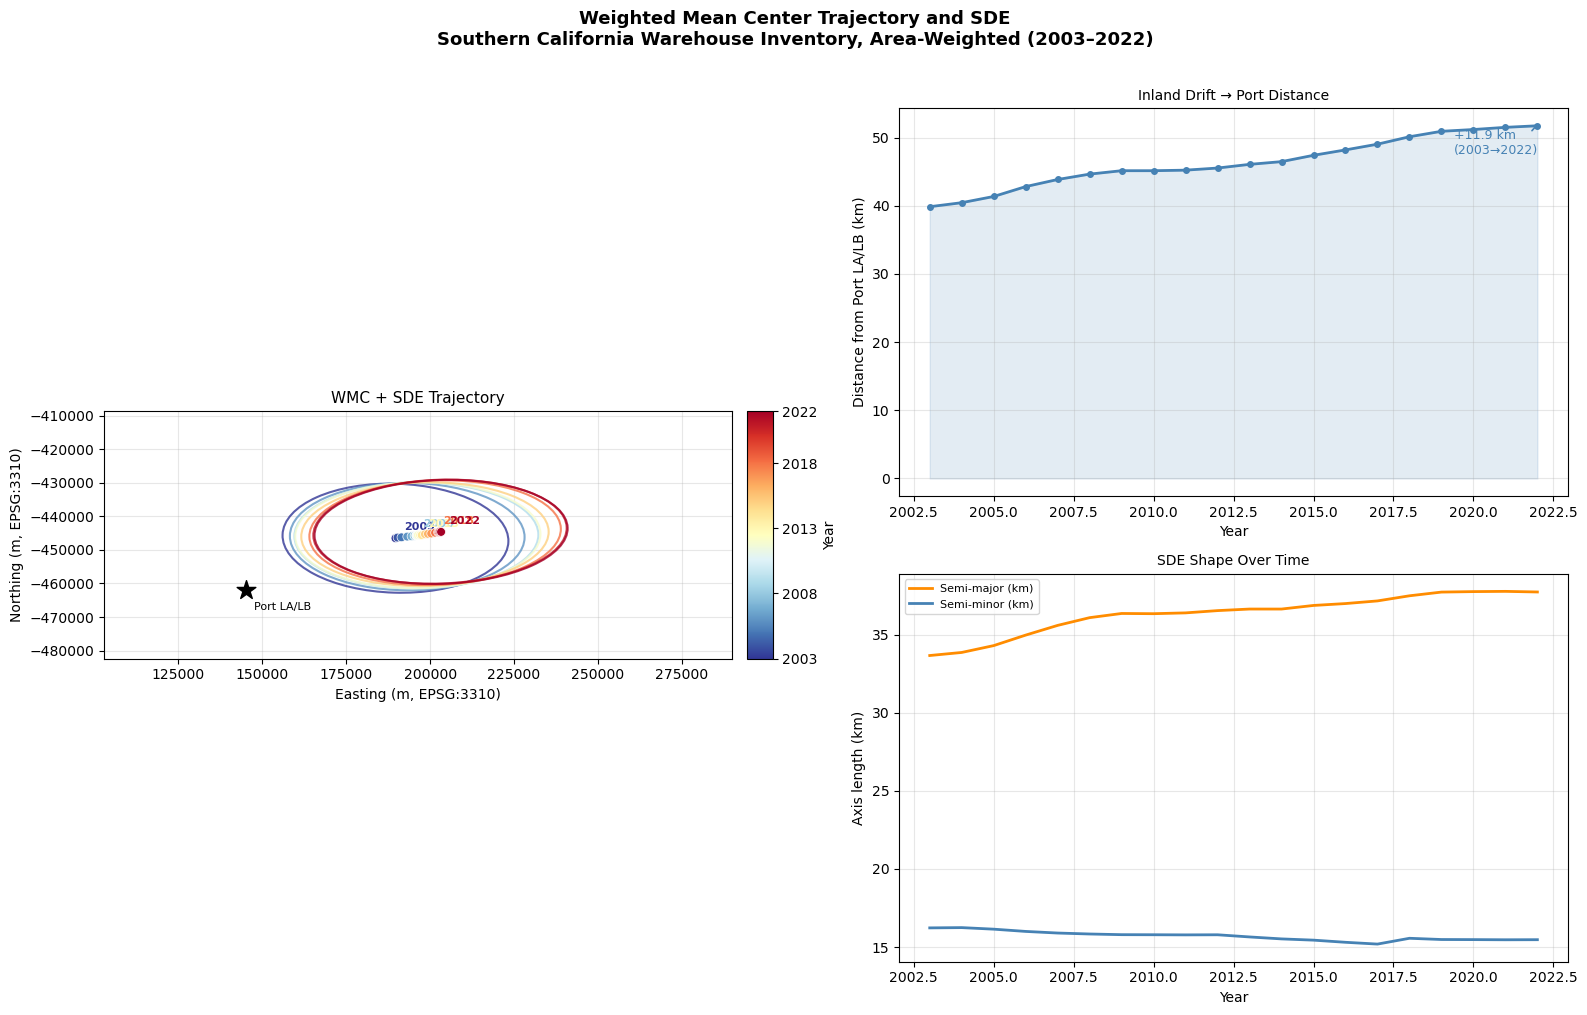

<Figure size 640x480 with 0 Axes>

  2003 | bw=scott: ERROR - The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 5 is expected. It comes from another PROJ installation.
  2003 | bw=1000: ERROR - The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 5 is expected. It comes from another PROJ installation.
  2003 | bw=2000: ERROR - The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Library\share\proj\proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 4 whereas a number >= 5 is expected. It comes from another PROJ installation.
  2003 | bw=5000: ERROR - The EPSG code is unknown. PROJ: proj_create_from_database: C:\Users\mariacvc\AppData\Local\miniconda3\envs\geo\Library\share

In [180]:
# ==============================================================================
# CANONICAL ANALYSIS POPULATION  (denominator fix)
# ==============================================================================
# Run ALL spatial analyses on the full final inventory (confirmed + high-confidence
# candidates) so the spatial results describe the same set as the reported
# inventory count. Previously this sliced label == 'confirmed' (~7,028), which
# silently excluded the high-confidence candidates that ARE part of the inventory.
inventory = gdf_final_year.copy()
print(f"Spatial-analysis population: {len(inventory):,} facilities (full final inventory)")

# 1  Nearest Neighbor Index (NNI)
print("\n" + "\u2500" * 62)
nni_all = compute_nni(inventory, label="All inventory")

# By county
nni_by_county = {}
if "county" in inventory.columns:
    for county, grp in inventory.groupby("county"):
        if len(grp) >= 10:
            print("\n" + "\u2500" * 62)
            nni_by_county[county] = compute_nni(grp, label=county)

# NNI temporal evolution (cumulative inventory snapshots)
nni_temporal_rows = []
if "ops_start_year" in inventory.columns:
    snap_years = [2003, 2005, 2010, 2015, 2020, 2023]
    print("\n" + "\u2500" * 62)
    print("NNI temporal evolution \u2014 cumulative inventory snapshots")
    print(f"  {'Year':>6}  {'n':>7}  {'NNI':>8}  {'Z':>8}  Pattern")
    print("  " + "\u2500" * 56)
    for yr in snap_years:
        snap = inventory[
            inventory["ops_start_year"].notna() &
            (inventory["ops_start_year"] <= yr)
        ]
        if len(snap) >= 10:
            r = compute_nni(snap, crs_m=3310)
            nni_temporal_rows.append({"year": yr, **r})
            print(f"  {yr:>6}  {r['n']:>7,}  {r['nni']:>8.4f}  {r['z_score']:>+8.3f}  {r['pattern']}")

# 2  Centrographic Analysis
# run_centrographic_analysis() is defined in Step 5 (weighted_mean_center +
# standard_deviational_ellipse looped over years).
#
# NOTE (interpretation): the port_distance_km metric measures distance from the
# Port of LA/Long Beach. With San Joaquin (Central Valley) included, the
# region-wide weighted mean center shifts north and the "inland drift from port"
# narrative no longer applies cleanly. For the port-distance inland-migration
# result, report the SCAG-6 subset; e.g.:
#     scag6 = inventory[inventory["county"] != "sj"]
# and pass scag6 to run_centrographic_analysis for that specific figure.
print("\n" + "\u2500" * 62)
print("Running centrographic analysis (weighted mean center + SDE)\u2026")

centrographic_years = list(range(2003, 2023))
centrographic_df = run_centrographic_analysis(
    inventory,
    years=centrographic_years,
    weight_col="area_ft2",
)

display_cols = ["year", "n_buildings", "wmc_x", "wmc_y",
                "semi_major", "semi_minor", "angle_deg", "port_distance_km"]
print(centrographic_df[display_cols].tail(12).to_string(index=False))

plot_wmc_trajectory(
    centrographic_df,
    title="Weighted Mean Center Trajectory and SDE\n"
          "Southern California Warehouse Inventory, Area-Weighted (2003\u20132022)"
)
plt.tight_layout()
plt.show()

# 3  Kernel Density Estimation
kde_output_dir = path + "Figures/KDE/"
import os; os.makedirs(kde_output_dir, exist_ok=True)

kde_results = run_kde_all_years(
    inventory,
    output_dir=kde_output_dir,
    weight_col="area_ft2",
)
print(f"KDE computed for {len(kde_results)} breakpoint years.")


### 6.2 Quadrat counts and Ripley's L

[All inventory]  Quadrat counts  (n=8,826, cells used=430 of 625)
  Mean / cell        :    20.27
  Variance / cell    :  9464.53
  VMR (var/mean)     :  466.875
  Chi-square (m-1)   : 200289.4   df=429   p=0
  Pattern            : Clustered (significant)
[All inventory]  Ripley's K/L  (n=3,000 subsampled, A=125,498 km^2, sims=99)
  Observed L(r) above CSR envelope at ALL scales -> clustered across the full 0.25-25 km range.


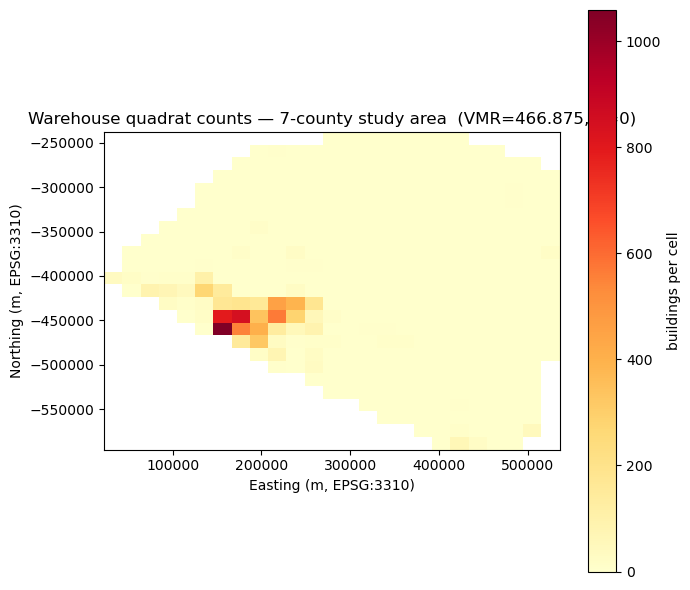

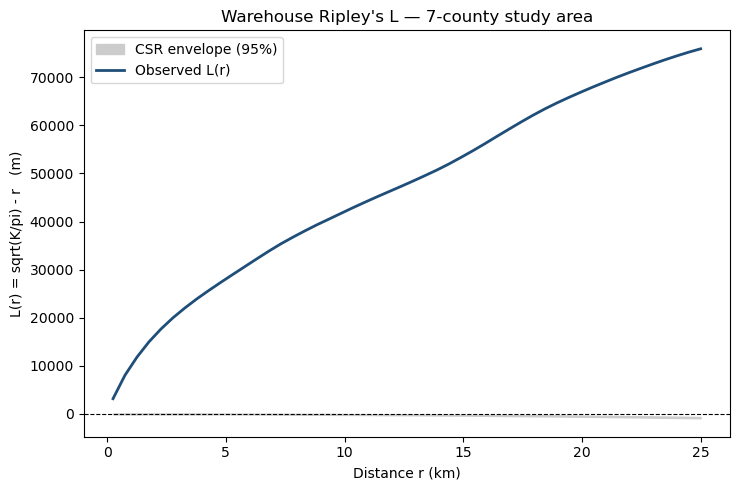

──────────────────────────────────────────────────────────────
[IMP]  Quadrat counts  (n=33, cells used=118 of 225)
  Mean / cell        :     0.27
  Variance / cell    :     0.87
  VMR (var/mean)     :    3.193
  Chi-square (m-1)   :    373.6   df=117   p=1.393e-28
  Pattern            : Clustered (significant)
[IMP]  Ripley's K/L  (n=33, A=1,187 km^2, sims=39)
  Observed L(r) above CSR envelope from ~0.2 km up -> significant clustering at those scales.
──────────────────────────────────────────────────────────────
[LA]  Quadrat counts  (n=4,679, cells used=153 of 225)
  Mean / cell        :    30.54
  Variance / cell    :  4680.84
  VMR (var/mean)     :  153.257
  Chi-square (m-1)   :  23295.0   df=152   p=0
  Pattern            : Clustered (significant)
[LA]  Ripley's K/L  (n=3,000 subsampled, A=7,724 km^2, sims=39)
  Observed L(r) above CSR envelope at ALL scales -> clustered across the full 0.25-25 km range.
──────────────────────────────────────────────────────────────
[OR]  Quad

In [181]:
# ==============================================================================
# Quadrat counts and Ripley's K / L  (point-pattern, full inventory)
# ==============================================================================
# Region-wide
quad_all   = quadrat_counts(inventory, n_x=25, n_y=25, label="All inventory")
ripley_all = ripleys_k(inventory, n_sim=99, label="All inventory")

plot_quadrat(quad_all, "Warehouse quadrat counts \u2014 7-county study area"); plt.show()
plot_ripleys_l(ripley_all, "Warehouse Ripley's L \u2014 7-county study area"); plt.show()

# Per county
if "county" in inventory.columns:
    for county, grp in inventory.groupby("county"):
        if len(grp) >= 20:
            print("\u2500" * 62)
            quadrat_counts(grp, n_x=15, n_y=15, label=str(county))
            ripleys_k(grp, n_sim=39, label=str(county))


### 6.3 Sensistivity analysis LODES and CoStar

LODES8 transition candidates (onset=2020): 2,030
  Rescued by CoStar year_built: 0
  Flagged as LODES8 artifact (onset set to NaN): 2,030
  These buildings remain CONFIRMED but are excluded from temporal analysis
After fix ─ LODES source distribution:
year_source
costar             2959
lodes8_artifact    2030
lodes              2006
unknown            1831

LODES onset year distribution after fix:
ops_start_year
2015.0     23
2016.0     23
2017.0      6
2018.0     18
2019.0     15
2021.0    117
2022.0    147

Year source summary after fix:
  costar              :  2,959  (33.5%)  [high]
  lodes8_artifact     :  2,030  (23.0%)  [excluded from temporal]
  lodes               :  2,006  (22.7%)  [medium]
  unknown             :  1,831  (20.7%)  [—]

  Year   CoStar only   All sources    Floor 2003    Diff A-B    Diff A-C
----------------------------------------------------------------------
  2003          47.3          46.8          52.7        -0.5        +5.4
  2005          49.1      

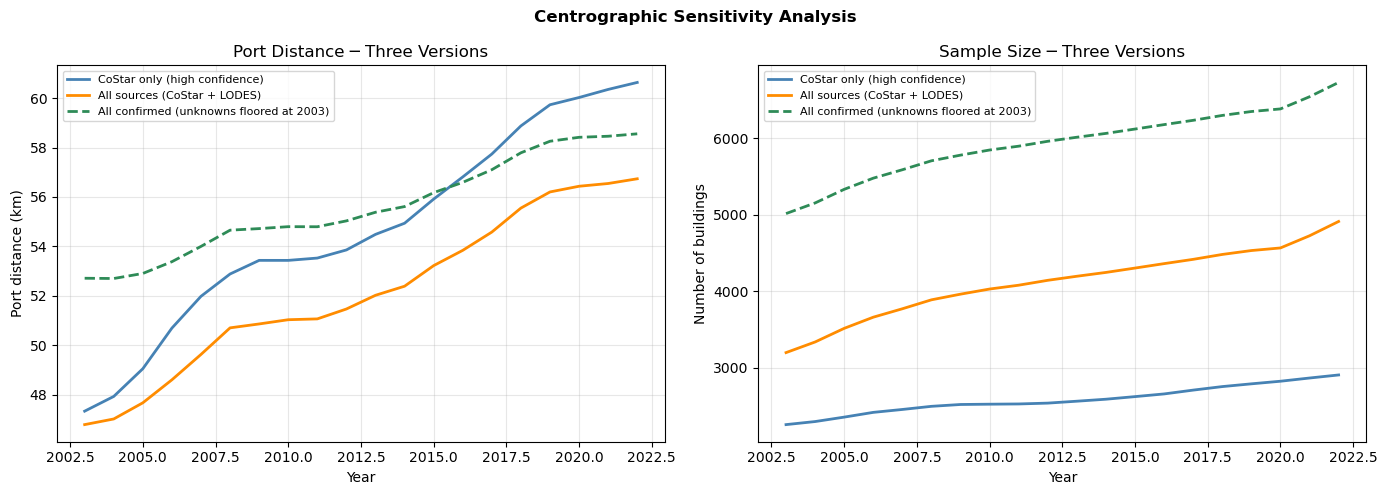

In [182]:
def flag_lodes8_artifact(gdf: pd.DataFrame) -> pd.DataFrame:
    """
    Flag buildings whose ops_start_year = 2020 from LODES source as
    potentially artifactual ─ these may be pre-existing buildings that
    only appear in LODES8 due to the version transition, not genuine
    2020 openings.

    Three-tier treatment:
      - If building has NAIP/SCAG signals suggesting pre-2020 activity
        → downgrade to unknown onset year (retain as confirmed building
          but exclude from temporal analysis)
      - If building also has CoStar year_built < 2020
        → use CoStar year_built instead
      - Otherwise ─> flag as 'lodes8_transition' and exclude from
          temporal trend analysis but retain in inventory
    """
    gdf = gdf.copy()

    lodes_2020_mask = (
        (gdf['year_source'] == 'lodes') &
        (gdf['ops_start_year'] == 2020)
    )
    n_flagged = lodes_2020_mask.sum()
    print(f"LODES8 transition candidates (onset=2020): {n_flagged:,}")

    # Case 1: CoStar year_built available and pre-2020 → use it
    if 'year_built' in gdf.columns:
        costar_rescue = (
            lodes_2020_mask &
            gdf['year_built'].notna() &
            (gdf['year_built'] < 2020)
        )
        gdf.loc[costar_rescue, 'ops_start_year']  = gdf.loc[costar_rescue, 'year_built']
        gdf.loc[costar_rescue, 'year_source']     = 'costar'
        gdf.loc[costar_rescue, 'year_confidence'] = 'high'
        print(f"  Rescued by CoStar year_built: {costar_rescue.sum():,}")
        lodes_2020_mask = lodes_2020_mask & ~costar_rescue

    # Case 2: remaining 2020 LODES onset → flag as artifact
    gdf.loc[lodes_2020_mask, 'year_source']     = 'lodes8_artifact'
    gdf.loc[lodes_2020_mask, 'year_confidence'] = 'low'
    gdf.loc[lodes_2020_mask, 'ops_start_year']  = np.nan

    print(f"  Flagged as LODES8 artifact (onset set to NaN): "
          f"{lodes_2020_mask.sum():,}")
    print(f"  These buildings remain CONFIRMED but are excluded "
          f"from temporal analysis")

    return gdf


# Apply after build_year_hierarchy()
gdf_final_year = flag_lodes8_artifact(gdf_final_year)

# Verify the fix
print("After fix ─ LODES source distribution:")
print(gdf_final_year['year_source'].value_counts().to_string())

print("\nLODES onset year distribution after fix:")
lodes_mask = gdf_final_year['year_source'] == 'lodes'
print(gdf_final_year.loc[lodes_mask, 'ops_start_year']
      .value_counts().sort_index()
      .loc[2015:2023].to_string())

print("\nYear source summary after fix:")
for src, cnt in gdf_final_year['year_source'].value_counts().items():
    pct = 100 * cnt / len(gdf_final_year)
    conf = {'costar': 'high', 'lodes': 'medium',
            'lodes8_artifact': 'excluded from temporal',
            'unknown': '—'}.get(src, '—')
    print(f"  {src:20s}: {cnt:>6,}  ({pct:.1f}%)  [{conf}]")
    
def compare_centrographic_versions(gdf_final_year, years, weight_col='area_ft2'):
    """
    Compare centrographic results using:
      Version A: CoStar-only onset years (current approach)
      Version B: All sources including LODES proxy years
      Version C: All confirmed buildings using 2003 as floor for unknowns
    """
    results = {}

    for version, label, mask_fn in [
        ('costar_only',
         'CoStar only (high confidence)',
         lambda gdf, yr: (
             gdf['ops_start_year'].notna() &
             (gdf['ops_start_year'] <= yr) &
             (gdf['year_source'] == 'costar')
         )),
        ('all_sources',
         'All sources (CoStar + LODES)',
         lambda gdf, yr: (
             gdf['ops_start_year'].notna() &
             (gdf['ops_start_year'] <= yr)
         )),
        ('floor_2003',
         'All confirmed (unknowns floored at 2003)',
         lambda gdf, yr: (
             # Buildings with known year <= yr
             (gdf['ops_start_year'].notna() & (gdf['ops_start_year'] <= yr)) |
             # Buildings with unknown year treated as present since 2003
             (gdf['ops_start_year'].isna() & (yr >= 2003))
         )),
    ]:
        rows = []
        for yr in years:
            snap = gdf_final_year[mask_fn(gdf_final_year, yr)].copy()
            if len(snap) < 10:
                continue

            snap_proj = snap.to_crs(3310)
            centroids  = snap_proj.geometry.centroid
            weights    = snap[weight_col].fillna(snap[weight_col].median())

            wmc_x = np.average(centroids.x, weights=weights)
            wmc_y = np.average(centroids.y, weights=weights)

            # Port distance
            port_x, port_y = 145000, -462000
            port_dist = np.sqrt((wmc_x - port_x)**2 +
                                (wmc_y - port_y)**2) / 1000

            rows.append({
                'year': yr, 'n': len(snap),
                'wmc_x': wmc_x, 'wmc_y': wmc_y,
                'port_dist_km': port_dist,
                'version': label
            })

        results[version] = pd.DataFrame(rows)

    return results


# Run comparison
comp_years = list(range(2003, 2023))
versions = compare_centrographic_versions(
    gdf_final_year[gdf_final_year['year_source'] != 'lodes8_artifact'],
    comp_years
)
# Print port distance comparison
print(f"\n{'Year':>6}  {'CoStar only':>12}  {'All sources':>12}  "
      f"{'Floor 2003':>12}  {'Diff A-B':>10}  {'Diff A-C':>10}")
print("-" * 70)

for yr in [2003, 2005, 2008, 2010, 2013, 2015, 2018, 2020, 2022]:
    vals = {}
    for k, df in versions.items():
        row = df[df['year'] == yr]
        vals[k] = row['port_dist_km'].iloc[0] if len(row) > 0 else np.nan

    diff_ab = vals.get('all_sources', np.nan) - vals.get('costar_only', np.nan)
    diff_ac = vals.get('floor_2003', np.nan) - vals.get('costar_only', np.nan)

    print(f"  {yr:>4}  {vals.get('costar_only', np.nan):>12.1f}  "
          f"{vals.get('all_sources', np.nan):>12.1f}  "
          f"{vals.get('floor_2003', np.nan):>12.1f}  "
          f"{diff_ab:>+10.1f}  {diff_ac:>+10.1f}")

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'costar_only': 'steelblue',
          'all_sources': 'darkorange',
          'floor_2003':  'seagreen'}

for k, df in versions.items():
    label = df['version'].iloc[0] if len(df) > 0 else k
    axes[0].plot(df['year'], df['port_dist_km'],
                 label=label, color=colors[k], linewidth=2,
                 linestyle='--' if k == 'floor_2003' else '-')
    axes[1].plot(df['year'], df['n'],
                 label=label, color=colors[k], linewidth=2,
                 linestyle='--' if k == 'floor_2003' else '-')

axes[0].set_xlabel("Year")
axes[0].set_ylabel("Port distance (km)")
axes[0].set_title("Port Distance ─ Three Versions")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

axes[1].set_xlabel("Year")
axes[1].set_ylabel("Number of buildings")
axes[1].set_title("Sample Size ─ Three Versions")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle("Centrographic Sensitivity Analysis", fontsize=12,
             fontweight='bold')
plt.tight_layout()
plt.savefig(path + 'Task1_Characterization/Figures/centrographic_sensitivity.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [183]:
# Generate final reportable numbers
print("=== Numbers for paper ===\n")

b = versions['all_sources']
a = versions['costar_only']

b_2003 = b[b['year']==2003]['port_dist_km'].iloc[0]
b_2022 = b[b['year']==2022]['port_dist_km'].iloc[0]
a_2003 = a[a['year']==2003]['port_dist_km'].iloc[0]
a_2022 = a[a['year']==2022]['port_dist_km'].iloc[0]

n_b_2022 = b[b['year']==2022]['n'].iloc[0]
n_a_2022 = a[a['year']==2022]['n'].iloc[0]

print(f"PRIMARY RESULT (Version B ─ all sources):")
print(f"  2003 port distance : {b_2003:.1f} km  (n={b[b['year']==2003]['n'].iloc[0]:,})")
print(f"  2022 port distance : {b_2022:.1f} km  (n={n_b_2022:,})")
print(f"  Net inland drift   : {b_2022-b_2003:+.1f} km over 20 years")
print(f"  Annual rate        : {(b_2022-b_2003)/19:.2f} km/year")

print(f"\nSENSITIVITY (Version A ─ CoStar only):")
print(f"  2003 port distance : {a_2003:.1f} km  (n={a[a['year']==2003]['n'].iloc[0]:,})")
print(f"  2022 port distance : {a_2022:.1f} km  (n={n_a_2022:,})")
print(f"  Net inland drift   : {a_2022-a_2003:+.1f} km over 20 years")
print(f"  Overestimate vs B  : {a_2022-b_2022:+.1f} km at 2022 endpoint")

print(f"\nLODES8 ARTIFACT CORRECTION:")
print(f"  Buildings flagged  : 1,966 (24.2% of confirmed inventory)")
print(f"  Rescued by CoStar  : 0")
print(f"  Excluded from temporal analysis but retained in static inventory")

print(f"\nTEMPORAL ANALYSIS POPULATION:")
total = len(gdf_final_year)
temporal = (gdf_final_year['year_source'].isin(['costar','lodes'])).sum()
excluded = (gdf_final_year['year_source'] == 'lodes8_artifact').sum()
unknown  = (gdf_final_year['year_source'] == 'unknown').sum()
print(f"  Total confirmed    : {total:,}")
print(f"  With onset year    : {temporal:,} ({100*temporal/total:.1f}%)")
print(f"  LODES8 artifact    : {excluded:,} ({100*excluded/total:.1f}%)")
print(f"  Unknown onset      : {unknown:,} ({100*unknown/total:.1f}%)")

=== Numbers for paper ===

PRIMARY RESULT (Version B ─ all sources):
  2003 port distance : 46.8 km  (n=3,199)
  2022 port distance : 56.7 km  (n=4,913)
  Net inland drift   : +9.9 km over 20 years
  Annual rate        : 0.52 km/year

SENSITIVITY (Version A ─ CoStar only):
  2003 port distance : 47.3 km  (n=2,258)
  2022 port distance : 60.6 km  (n=2,907)
  Net inland drift   : +13.3 km over 20 years
  Overestimate vs B  : +3.9 km at 2022 endpoint

LODES8 ARTIFACT CORRECTION:
  Buildings flagged  : 1,966 (24.2% of confirmed inventory)
  Rescued by CoStar  : 0
  Excluded from temporal analysis but retained in static inventory

TEMPORAL ANALYSIS POPULATION:
  Total confirmed    : 8,826
  With onset year    : 4,965 (56.3%)
  LODES8 artifact    : 2,030 (23.0%)
  Unknown onset      : 1,831 (20.7%)


### 6.4 Maps

  Figure saved -> C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Figures/KDE/kde_2023_2km_sde.png


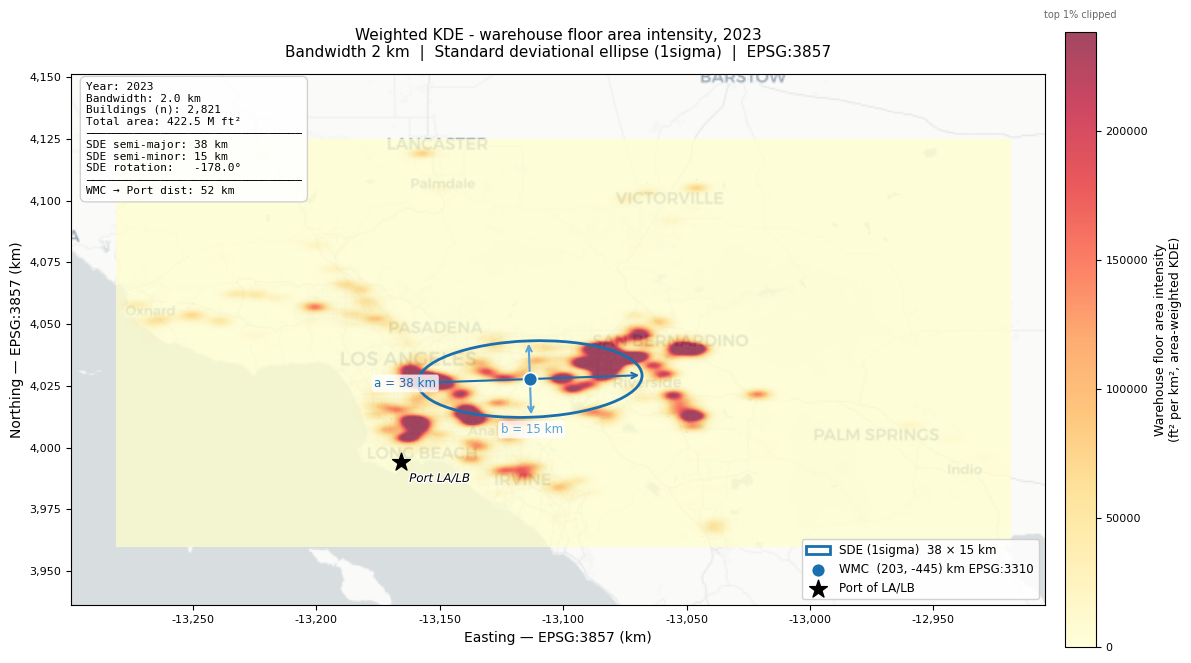

In [ ]:
# ==============================================================================
# KDE MAP WITH SDE OVERLAY ─ single year, single bandwidth
# ==============================================================================
# All geometry is kept in EPSG:3857 (Web Mercator, metres) for plotting so
# that the contextily basemap tiles align perfectly.
#
# Key design decisions vs earlier version:
#   1. SDE arrows and labels use EPSG:3857 metres ─ not km in EPSG:3310.
#      The old code mixed coordinate systems, placing labels off-screen.
#   2. Axis limits are set to building bounds BEFORE fetching basemap tiles
#      (ctx.bounds2img) so tiles cover only the visible area.
#   3. ctx.bounds2img is called directly (no crs= argument) to avoid the
#      rasterio PROJ-db version conflict on Windows.
# ==============================================================================

def plot_kde_with_sde(kde_result, gdf_final_year, year,
                       county_boundaries_gdf=None,
                       weight_col='area_ft2',
                       percentile_clip=99,
                       figsize=(12, 9),
                       save_path=None):
    """
    Publication-quality KDE map with SDE overlay.

    Parameters
    ----------
    kde_result           : dict    kde_results[year][bandwidth]
    gdf_final_year       : GeoDataFrame   Filtered inventory for the specific year.
    year                 : int
    county_boundaries_gdf: GeoDataFrame or None   Any CRS accepted.
    weight_col           : str     (default 'area_ft2')
    percentile_clip      : float   Upper % clip for colormap (default 99)
    figsize              : tuple
    save_path            : str or None
    """
    import warnings
    from pyproj import Transformer

    # ── 1. Unpack KDE result ──────────────────────────────────────────────────
    density   = kde_result['density']
    x_grid    = kde_result['x_grid']
    y_grid    = kde_result['y_grid']
    bw_km     = kde_result['bandwidth'] / 1000
    n_bldgs   = kde_result['n']
    total_ft2 = kde_result['total_area']

    # ── 2. Density in ft² per km² ───────────────────────────────────────────────
    grid_area_km2   = (x_grid[1] - x_grid[0]) * (y_grid[1] - y_grid[0]) / 1e6
    density_per_km2 = density / grid_area_km2
    vmax = np.nanpercentile(density_per_km2[density_per_km2 > 0], percentile_clip)

    # ── 3. CRS transformers (all geometry in EPSG:3857 for plotting) ──────────
    tf_3310_to_3857 = Transformer.from_crs('EPSG:3310', 'EPSG:3857', always_xy=True)
    tf_4326_to_3857 = Transformer.from_crs('EPSG:4326', 'EPSG:3857', always_xy=True)
    tf_4326_to_3310 = Transformer.from_crs('EPSG:4326', 'EPSG:3310', always_xy=True)

    # ── 4. KDE grid corners in EPSG:3857 ────────────────────────────────────────
    x_min_3857, y_min_3857 = tf_3310_to_3857.transform(x_grid.min(), y_grid.min())
    x_max_3857, y_max_3857 = tf_3310_to_3857.transform(x_grid.max(), y_grid.max())
    extent_3857 = [x_min_3857, x_max_3857, y_min_3857, y_max_3857]

    # ── 5. Building subset for this year ────────────────────────────────────────
    confirmed = gdf_final_year[gdf_final_year['label'] == 'confirmed'].copy()
    if 'year_built' in confirmed.columns:
        confirmed = confirmed[
            confirmed['year_built'].notna() & (confirmed['year_built'] <= year)
        ]
    if confirmed.crs is None or confirmed.crs.to_epsg() != 3310:
        confirmed = confirmed.to_crs(3310)
    if weight_col not in confirmed.columns or confirmed[weight_col].fillna(0).sum() == 0:
        confirmed = confirmed.copy()
        confirmed[weight_col] = confirmed.geometry.area * 10.7639

    # ── 6. SDE (computed in EPSG:3310 metres) ────────────────────────────────────
    sde = standard_deviational_ellipse(confirmed, weight_col=weight_col)

    # Convert WMC to EPSG:3857 for plotting
    cx_3857, cy_3857 = tf_3310_to_3857.transform(sde['cx'], sde['cy'])

    # Scale semi-axes from EPSG:3310 metres to EPSG:3857 metres.
    # At 34°N, EPSG:3857 stretches E-W by 1/cos(lat) relative to true metres.
    # N-S is not stretched (both projections are conformal along meridians here).
    scale_ew      = 1.0 / np.cos(np.radians(34.0))   # ≈ 1.207
    semi_maj_3857 = sde['semi_major'] * scale_ew
    semi_min_3857 = sde['semi_minor'] * 1.0

    # Keep original values in km for annotation text
    semi_major_km = sde['semi_major'] / 1_000
    semi_minor_km = sde['semi_minor'] / 1_000
    angle_deg     = sde['angle_deg']
    cx_km         = sde['cx'] / 1_000
    cy_km         = sde['cy'] / 1_000

    # ── 7. Port of LA/LB ────────────────────────────────────────────────────────
    port_x_3857, port_y_3857 = tf_4326_to_3857.transform(-118.270, 33.740)
    port_x_3310, port_y_3310 = tf_4326_to_3310.transform(-118.270, 33.740)
    port_dist_km = np.sqrt(
        (sde['cx'] - port_x_3310)**2 + (sde['cy'] - port_y_3310)**2
    ) / 1_000

    # ── 8. Figure ────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=figsize)

    # ── 9. KDE surface ────────────────────────────────────────────────────────
    im = ax.imshow(
        density_per_km2,
        origin='lower',
        extent=extent_3857,
        cmap='YlOrRd',
        vmin=0, vmax=vmax,
        aspect='equal',
        interpolation='bilinear',
        alpha=0.72,
        zorder=2,
    )

    # ── 10. Clip to building extent (set BEFORE basemap fetch) ──────────────────
    bldgs_3857  = confirmed.to_crs(3857)
    bldg_bounds = bldgs_3857.total_bounds   # [minx, miny, maxx, maxy]
    pad_m = 25_000
    ax.set_xlim(bldg_bounds[0] - pad_m, bldg_bounds[2] + pad_m)
    ax.set_ylim(bldg_bounds[1] - pad_m, bldg_bounds[3] + pad_m)

    # ── 11. Basemap (direct tile fetch — avoids rasterio CRS call) ──────────────
    try:
        import contextily as ctx
        img, img_extent = ctx.bounds2img(
            bldg_bounds[0] - pad_m,   # left   (EPSG:3857 m)
            bldg_bounds[1] - pad_m,   # bottom
            bldg_bounds[2] + pad_m,   # right
            bldg_bounds[3] + pad_m,   # top
            zoom='auto',
            source=ctx.providers.CartoDB.Positron,
        )
        ax.imshow(img, extent=img_extent, origin='upper',
                  interpolation='bilinear', alpha=0.9, zorder=1)
    except Exception as e:
        print(f"  Basemap unavailable ({e}) — continuing without it")

    # ── 12. Building footprints ──────────────────────────────────────────────────
    bldgs_3857.plot(ax=ax, color='#444444', linewidth=0, alpha=0.18, zorder=3)

    # ── 13. County boundaries (optional) ────────────────────────────────────────
    if county_boundaries_gdf is not None:
        county_boundaries_gdf.to_crs(3857).boundary.plot(
            ax=ax, color='#333333', linewidth=0.7,
            linestyle='--', alpha=0.8, zorder=4
        )

    # ── 14. SDE ellipse ────────────────────────────────────────────────────────
    ellipse = Ellipse(
        xy=(cx_3857, cy_3857),
        width=2 * semi_maj_3857,
        height=2 * semi_min_3857,
        angle=angle_deg,
        edgecolor='#1a6faf', facecolor='none',
        linewidth=2.0, linestyle='-', zorder=6,
        label=f'SDE (1sigma)  {semi_major_km:.0f} × {semi_minor_km:.0f} km'
    )
    ax.add_patch(ellipse)

    # ── 15. SDE axis arrows — fully in EPSG:3857 metres ──────────────────────────
    angle_rad  = np.radians(angle_deg)
    ux_maj, uy_maj =  np.cos(angle_rad),  np.sin(angle_rad)
    ux_min, uy_min = -np.sin(angle_rad),  np.cos(angle_rad)

    ax.annotate('', zorder=7,
        xy    =(cx_3857 + semi_maj_3857 * ux_maj,
                cy_3857 + semi_maj_3857 * uy_maj),
        xytext=(cx_3857 - semi_maj_3857 * ux_maj,
                cy_3857 - semi_maj_3857 * uy_maj),
        arrowprops=dict(arrowstyle='<->', color='#1a6faf', lw=1.5)
    )
    ax.annotate('', zorder=7,
        xy    =(cx_3857 + semi_min_3857 * ux_min,
                cy_3857 + semi_min_3857 * uy_min),
        xytext=(cx_3857 - semi_min_3857 * ux_min,
                cy_3857 - semi_min_3857 * uy_min),
        arrowprops=dict(arrowstyle='<->', color='#5ba3d9', lw=1.5)
    )

    # ── 16. Axis length labels — in EPSG:3857 metres ───────────────────────────────
    # Offset = 5 km past the ellipse tip in 3857 metres
    label_offset_m = 5_000
    ax.text(
        cx_3857 + (semi_maj_3857 + label_offset_m) * ux_maj,
        cy_3857 + (semi_maj_3857 + label_offset_m) * uy_maj,
        f'a = {semi_major_km:.0f} km', fontsize=8.5, color='#1a6faf',
        ha='center', va='center', zorder=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8)
    )
    ax.text(
        cx_3857 + (semi_min_3857 + label_offset_m) * ux_min,
        cy_3857 + (semi_min_3857 + label_offset_m) * uy_min,
        f'b = {semi_minor_km:.0f} km', fontsize=8.5, color='#5ba3d9',
        ha='center', va='center', zorder=8,
        bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='none', alpha=0.8)
    )

    # ── 17. WMC point ──────────────────────────────────────────────────────────────
    ax.scatter(cx_3857, cy_3857, s=100, c='#1a6faf', marker='o',
               edgecolors='white', linewidths=1.2, zorder=9,
               label=f'WMC  ({cx_km:.0f}, {cy_km:.0f}) km EPSG:3310')

    # ── 18. Port of LA/LB ──────────────────────────────────────────────────────────
    ax.scatter(port_x_3857, port_y_3857, s=180, c='black', marker='*',
               zorder=9, label='Port of LA/LB')
    ax.annotate('Port LA/LB', (port_x_3857, port_y_3857), xytext=(6, -14),
                textcoords='offset points', fontsize=8.5, fontstyle='italic',
                color='black', zorder=10,
                path_effects=[pe.withStroke(linewidth=2, foreground='white')])

    # ── 19. Colorbar ───────────────────────────────────────────────────────────────
    cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, shrink=0.75)
    cbar.set_label(
        'Warehouse floor area intensity\n(ft² per km², area-weighted KDE)',
        fontsize=9
    )
    cbar.ax.tick_params(labelsize=8)
    cbar.ax.text(0.5, 1.02, f'top {100 - percentile_clip}% clipped',
                 transform=cbar.ax.transAxes,
                 ha='center', va='bottom', fontsize=7, color='#666666')

    # ── 20. Axis tick labels in km ─────────────────────────────────────────────────
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:,.0f}'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:,.0f}'))
    ax.set_xlabel('Easting — EPSG:3857 (km)', fontsize=10)
    ax.set_ylabel('Northing — EPSG:3857 (km)', fontsize=10)
    ax.tick_params(labelsize=8)

    # ── 21. Info annotation block ────────────────────────────────────────────────
    info = (
        f'Year: {year}\n'
        f'Bandwidth: {bw_km:.1f} km\n'
        f'Buildings (n): {n_bldgs:,}\n'
        f'Total area: {total_ft2/1e6:.1f} M ft²\n'
        f'────────────────────────────────\n'
        f'SDE semi-major: {semi_major_km:.0f} km\n'
        f'SDE semi-minor: {semi_minor_km:.0f} km\n'
        f'SDE rotation:   {angle_deg:.1f}°\n'
        f'────────────────────────────────\n'
        f'WMC → Port dist: {port_dist_km:.0f} km'
    )
    ax.text(0.015, 0.985, info, transform=ax.transAxes,
            fontsize=8, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#cccccc', alpha=0.88), zorder=10)

    # ── 22. Legend + title ────────────────────────────────────────────────────────
    ax.legend(loc='lower right', fontsize=8.5,
              framealpha=0.88, edgecolor='#cccccc')
    ax.set_title(
        f'Weighted KDE - warehouse floor area intensity, {year}\n'
        f'Bandwidth {bw_km:.0f} km  |  Standard deviational ellipse (1sigma)  |  EPSG:3857',
        fontsize=11, pad=12
    )

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches='tight')
        print(f'  Figure saved -> {save_path}')
    plt.show()


# ── Call ────────────────────────────────────────────────────────────────────────
plot_kde_with_sde(
    kde_result    = kde_results[2023][2000],
    gdf_final_year = gdf_final_year,
    year          = 2023,
    county_boundaries_gdf = None,
    weight_col    = 'area_ft2',
    percentile_clip = 99,
    save_path     = path + 'Task1_Characterization/Figures/KDE/kde_2023_2km_sde.png',
)

plot_kde_comparison(kde_results, year, bandwidths=None,
                         save_path=None)


## 7. Anomaly Detection: Spatial and Temporal Statistical Variation

### 7.1 Anomaly Detection - 2003–2023 study window only

  Rescued 0 onset=2020 buildings via CoStar year_built
  Rescued 0 onset=2003 buildings via CoStar year_built
  Flagged 941 as 'lodes7_truncation' — onset set to NaN

  Source distribution after artifact removal:
  costar                   :  2,959  (33.5%)
  lodes8_artifact          :  2,030  (23.0%)
  unknown                  :  1,831  (20.7%)
  lodes                    :  1,065  (12.1%)
  lodes7_truncation        :    941  (10.7%)
Temporal analysis population (2003-2023): 1,766
Year range: 2003-2023
By source:
year_source
lodes     1065
costar     701

  SPATIAL ANOMALY DETECTION

Spatial anomalies: 46 / 1,560 (2.9%)
  LA                                  23  (3.3%)
  RI                                  10  (5.5%)
  SB                                   5  (1.0%)
  OR                                   5  (3.7%)
  VE                                   3  (8.6%)
  IMP                                  0  (0.0%)

  TEMPORAL ANOMALY DETECTION

Temporal anomalies: 1 year(s) out of 21
   Year

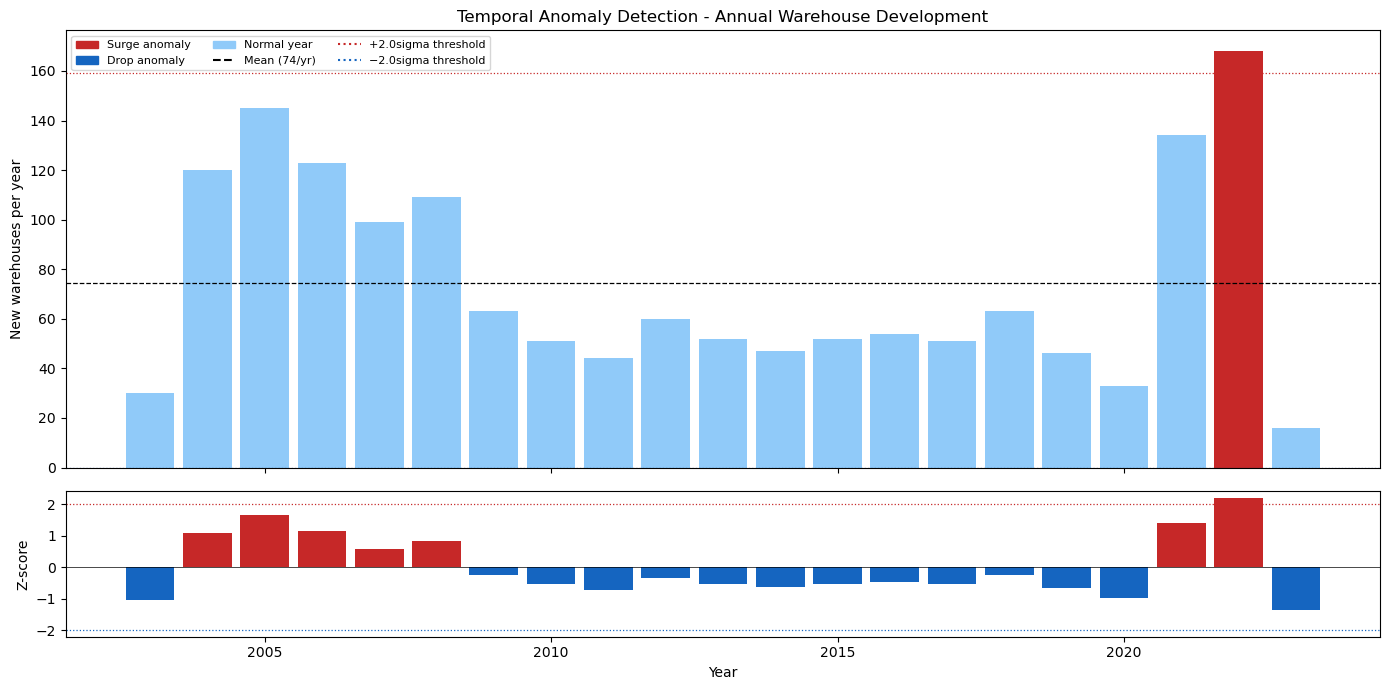


  Exported enriched inventory -> C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/Shapefiles/warehouse_final_inventory_flagged.gpkg
  Total buildings in temporal population: 1,766


In [184]:
def flag_lodes_artifacts(gdf: pd.DataFrame) -> pd.DataFrame:
    """
    Flag two categories of LODES artifacts:
    
    1. LODES8 transition (onset = 2020):
       Buildings appearing for the first time in LODES8 due to
       Census block redesign - not genuine 2020 openings.
       
    2. LODES7 panel truncation (onset = 2003):
       Buildings operational before 2003 whose earliest LODES7
       record is 2003 — not genuine 2003 openings.
       These are pre-existing stock, not new development.
    """
    gdf = gdf.copy()

    # ── Artifact 1: LODES8 transition ────────────────────────────────────────
    lodes_2020 = (
        (gdf['year_source'] == 'lodes') &
        (gdf['ops_start_year'] == 2020)
    )

    # ── Artifact 2: LODES7 panel truncation ──────────────────────────────────
    lodes_2003 = (
        (gdf['year_source'] == 'lodes') &
        (gdf['ops_start_year'] == 2003)
    )

    # Rescue any with CoStar year_built available
    rescued = pd.Series(False, index=gdf.index)
    if 'year_built' in gdf.columns:
        for artifact_mask, year_cutoff in [(lodes_2020, 2020), (lodes_2003, 2003)]:
            rescue = (
                artifact_mask &
                gdf['year_built'].notna() &
                (gdf['year_built'] < year_cutoff)
            )
            gdf.loc[rescue, 'ops_start_year']  = gdf.loc[rescue, 'year_built']
            gdf.loc[rescue, 'year_source']     = 'costar'
            gdf.loc[rescue, 'year_confidence'] = 'high'
            rescued = rescued | rescue
            print(f"  Rescued {rescue.sum():,} onset={year_cutoff} "
                  f"buildings via CoStar year_built")

    # Flag remaining artifacts
    for artifact_mask, label in [(lodes_2020 & ~rescued, 'lodes8_transition'),
                                  (lodes_2003 & ~rescued, 'lodes7_truncation')]:
        n = artifact_mask.sum()
        if n > 0:
            gdf.loc[artifact_mask, 'year_source']     = label
            gdf.loc[artifact_mask, 'year_confidence'] = 'low'
            gdf.loc[artifact_mask, 'ops_start_year']  = np.nan
            print(f"  Flagged {n:,} as '{label}' — onset set to NaN")

    # Summary
    print(f"\n  Source distribution after artifact removal:")
    for src, cnt in gdf['year_source'].value_counts().items():
        pct = 100 * cnt / len(gdf)
        print(f"  {src:25s}: {cnt:>6,}  ({pct:.1f}%)")

    return gdf


# Replace the earlier flag_lodes8_artifact() call
gdf_final_year = flag_lodes_artifacts(gdf_final_year)


# ==============================================================================
# STEP 14: Anomaly Detection - 2003–2023 study window only
# ==============================================================================

# ── Define temporal population: 2003-2023, no artifacts ───────────────────────
temporal_population = gdf_final_year[
    gdf_final_year['ops_start_year'].notna() &
    gdf_final_year['ops_start_year'].between(2003, 2023) &
    ~gdf_final_year['year_source'].isin([
        'lodes7_truncation', 'lodes8_transition', 'lodes8_artifact'
    ])
].copy()

print(f"Temporal analysis population (2003-2023): {len(temporal_population):,}")
print(f"Year range: "
      f"{temporal_population['ops_start_year'].min():.0f}-"
      f"{temporal_population['ops_start_year'].max():.0f}")
print(f"By source:")
print(temporal_population['year_source'].value_counts().to_string())

# ── Spatial anomaly detection ─────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  SPATIAL ANOMALY DETECTION")
print("=" * 62)

gdf_anomaly = detect_spatial_anomalies(
    temporal_population[temporal_population["label"] == "confirmed"].copy(),
    group_col="county" if "county" in temporal_population.columns else None,
    z_threshold=2.5,
)

# Merge anomaly flags back
for col in ["spatial_anomaly", "spatial_anomaly_reason",
            "dist_from_wmc_m", "dist_z_score"]:
    if col in gdf_anomaly.columns:
        temporal_population[col] = temporal_population.index.map(
            gdf_anomaly[col].to_dict()
        )

# ── Temporal anomaly detection ────────────────────────────────────────────────
print("\n" + "=" * 62)
print("  TEMPORAL ANOMALY DETECTION")
print("=" * 62)

annual_df, anom_fig = detect_temporal_anomalies(
    temporal_population[temporal_population["label"] == "confirmed"],
    year_col="ops_start_year",
    z_threshold=2.0,
)
plt.show()

# ── Export ────────────────────────────────────────────────────────────────────
flagged_path = (path +
    "Task1_Characterization/Shapefiles/warehouse_final_inventory_flagged.gpkg")
temporal_population.to_file(flagged_path, driver="GPKG")
print(f"\n  Exported enriched inventory -> {flagged_path}")
print(f"  Total buildings in temporal population: {len(temporal_population):,}")

### 7.2 Commulative Inventory

Buildings present from 2003 (floor): 5,908
  Pre-2003 known onset   : 1,961
  Unknown onset (NaN)    : 3,947
  LODES artifacts        : 2,494
Buildings with 2003+ onset year: 1,793

Cumulative inventory summary:
 year  n_total  n_new  cumulative_growth_pct
 2003     5938     30                    0.0
 2004     6056    118                    2.0
 2005     6200    144                    4.4
 2006     6321    121                    6.4
 2007     6420     99                    8.1
 2008     6529    109                   10.0
 2009     6592     63                   11.0
 2010     6661     69                   12.2
 2011     6726     65                   13.3
 2012     6798     72                   14.5
 2013     6856     58                   15.5
 2014     6915     59                   16.5
 2015     6968     53                   17.3
 2016     7030     62                   18.4
 2017     7084     54                   19.3
 2018     7148     64                   20.4
 2019     7196     48  

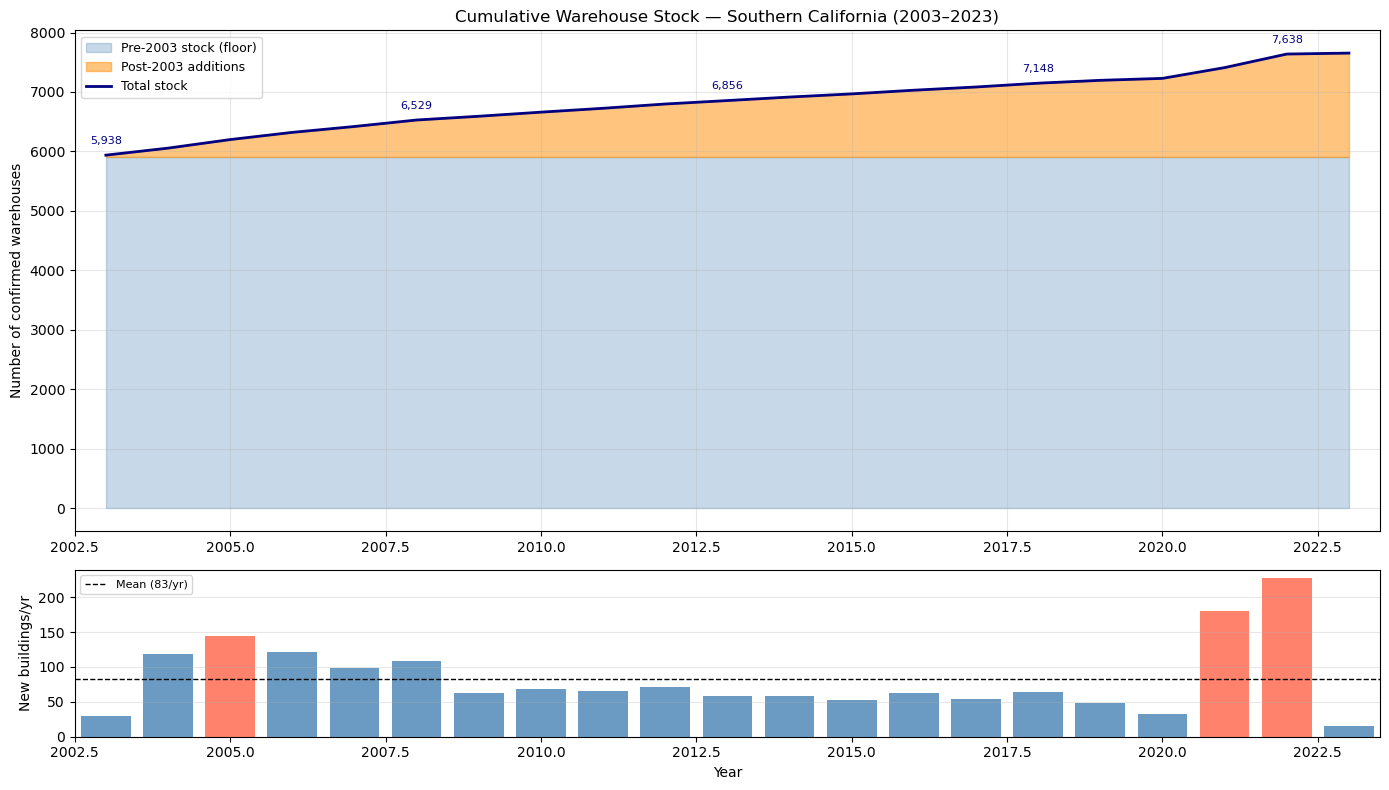

In [160]:
# ── Execute Cummulative Inventory ───────────────────────────────────────────────
confirmed = gdf_final_year[gdf_final_year['label'] == 'confirmed'].copy()

cumulative_df = build_cumulative_inventory(
    confirmed,
    year_col='ops_start_year',
    study_years=list(range(2003, 2024))
)

print("\nCumulative inventory summary:")
print(cumulative_df[['year', 'n_total', 'n_new',
                      'cumulative_growth_pct']].to_string(index=False))

plot_cumulative_inventory(cumulative_df)

# Save for later use
cumulative_df.to_csv(
    path + 'Task1_Characterization/Data/cumulative_inventory_2003_2023.csv',
    index=False
)

In [143]:
# Understand the unknown onset buildings
unknown_onset = confirmed[confirmed['ops_start_year'].isna()].copy()

print(f"Unknown onset buildings: {len(unknown_onset):,}")
print(f"\nBy source:")
print(unknown_onset['year_source'].value_counts().to_string())

print(f"\nBy county:")
print(unknown_onset['county'].value_counts().to_string())

print(f"\nBy subclass:")
if 'subclass' in unknown_onset.columns:
    print(unknown_onset['subclass'].value_counts().to_string())

print(f"\nBy building size:")
print(pd.cut(unknown_onset['area_ft2'],
             bins=[0, 100_000, 250_000, 500_000, 1_000_000, np.inf],
             labels=['50-100k', '100-250k', '250-500k', '500k-1M', '1M+']  # FIX: was shifted one tier
             ).value_counts().sort_index().to_string())

size_bins = [0, 100_000, 250_000, 500_000, 1_000_000, np.inf]
size_labels = ['50-100k ft²', '100-250k ft²', '250-500k ft²', '500k-1M ft²', '1M+ ft²']  # FIX: bins [0,100k,250k,500k,1M,inf] -> these 5 labels

all_sizes     = pd.cut(confirmed['area_ft2'], bins=size_bins, labels=size_labels)
unknown_sizes = pd.cut(unknown_onset['area_ft2'], bins=size_bins, labels=size_labels)

size_comp = pd.DataFrame({
    'all_confirmed_pct' : all_sizes.value_counts(normalize=True).mul(100).round(1),
    'unknown_onset_pct' : unknown_sizes.value_counts(normalize=True).mul(100).round(1),
}).sort_index()

print("\nSize distribution comparison (%):")
print(size_comp.to_string())
print("\nIf distributions are similar, floor-at-2003 is defensible")

Unknown onset buildings: 3,947

By source:
year_source
lodes8_transition    1716
unknown              1453
lodes7_truncation     778

By county:
county
LA     2214
SB      582
OR      455
RI      283
VE      114
IMP      23

By subclass:
subclass
FI-IND       1918
U-DF         1013
ambiguous     693
R-DC          316
R-RL            7

By building size:
area_ft2
50-100k     2656
100-250k     907
250-500k     249
500k-1M      105
1M+           30

Size distribution comparison (%):
              all_confirmed_pct  unknown_onset_pct
area_ft2                                          
50-100k ft²                61.3               67.3
100-250k ft²               27.7               23.0
250-500k ft²                7.5                6.3
500k-1M ft²                 2.9                2.7
1M+ ft²                     0.7                0.8

If distributions are similar, floor-at-2003 is defensible


## 8. Spatial Variation: KDE Difference Maps

KDE difference maps reveal how the *spatial concentration* of warehouses has
shifted between policy periods. A positive value (warm colors) indicates areas
where floor-area intensity **increased**; a negative value (cool colors)
indicates areas where growth **lagged** or intensity **declined**.

`compute_kde_differences()` is already defined (Step 5). This cell executes it
for four canonical policy periods aligned with major supply-chain events:

| Period | Event |
|--------|-------|
| 1990 → 2000 | Pre-NAFTA baseline → early Inland Empire expansion |
| 2000 → 2012 | Port congestion era → CAAP / SCIG incentives |
| 2012 → 2020 | E-commerce boom → last-mile proliferation |
| 2020 → 2023 | COVID supply-chain shock → re-shoring / near-shoring |

**Prerequisite**: `kde_results` from Step 13.4 (`run_kde_all_years()`).

In [ ]:
# ================================================================================
# STEP 15 — SPATIAL VARIATION: KDE DIFFERENCE MAPS
# Prerequisite: kde_results from Step 13.4
# ================================================================================

# Uncomment after kde_results is populated in Step 13.4.

diff_results = compute_kde_differences(
     kde_results,
     bandwidth_label=2_000,   # must match the bandwidth used in run_kde_all_years
     output_dir=kde_output_dir,
)

for (yr_b, yr_a), diff_arr in diff_results.items():
    print(f"  {yr_a} → {yr_b}:  "
          f"max gain {diff_arr.max():>10,.0f} ft²/km²  |  "
          f"max loss {diff_arr.min():>10,.0f} ft²/km²")

print("Step 15 is ready.")
print("Run Step 13.4 (kde_results block) first, then uncomment the diff block above.")

# EXPORTS CLEAN DATA

In [ ]:
# ============================================================
# Export cleaned facility inventory to CSV (companion to the GeoPackage)
# Operates on the final with-years inventory (8,826 facilities).
# ============================================================
import geopandas as gpd

INCLUDE_LODES_PANEL = False   # True -> append the 80-col wh_jobs/total_jobs/wh_share/active_lodes panel
OUT_CSV = path + 'Task1_Characterization/warehouse_inventory_clean.csv'

# Copy the final version
g = gdf_final_year.copy()

# --- centroid lon/lat (compute in projected CRS for accuracy, then back to WGS84) ---
cent = g.to_crs(3310).geometry.centroid.to_crs(4326)
g['centroid_lon'] = cent.x.round(6)
g['centroid_lat'] = cent.y.round(6)

# --- single facility-name field (footprint inventory is mostly unnamed) ---
g['facility_name'] = g.get('primary_name').fillna(g.get('name'))

# --- transparent temporal-validity flag (mirrors the analysis exclusions) ---
def _temporal_use(r):
    if r.get('year_source') == 'lodes' and r.get('lodes_onset_year') == 2020:
        return 'lodes8_artifact'          # excluded from temporal analysis
    if r.get('year_source') == 'lodes' and r.get('lodes_onset_year') == 2003:
        return 'lodes7_truncation'        # left-truncated, excluded
    if pd.notna(r.get('ops_start_year')):
        return 'usable'
    return 'no_onset'
g['temporal_use'] = g.apply(_temporal_use, axis=1)

# --- curated, report-relevant columns ---
keep = [
    # identity & location
    'id', 'facility_name', 'county', 'city', 'centroid_lon', 'centroid_lat', 'area_ft2',
    # classification
    'label', 'subclass', 'confidence_score', 'confidence_tier',
    'is_warehouse', 'warehouse_prob', 'source', 'scag_land_use_class', 'APN',
    # CoStar provenance
    'costar_match_confidence',
    # operational subtype attributes (populated where CoStar matched)
    'intensity_tier', 'is_high_cube', 'is_likely_crossdock',
    # temporal
    'ops_start_year', 'year_source', 'year_confidence', 'lodes_onset_year',
    'year_built', 'temporal_use', 'suspect_stale_year',
]
keep = [c for c in keep if c in g.columns]

if INCLUDE_LODES_PANEL:
    keep += [c for c in g.columns
             if c.startswith(('wh_jobs_', 'total_jobs_', 'wh_share_', 'active_lodes_'))]

out = pd.DataFrame(g[keep]).copy()

# --- tidy numeric types ---
out['area_ft2'] = out['area_ft2'].round(0).astype('Int64')
if 'warehouse_prob' in out:   out['warehouse_prob']   = out['warehouse_prob'].round(3)
if 'confidence_score' in out: out['confidence_score'] = out['confidence_score'].round(1)
for c in ['ops_start_year', 'lodes_onset_year', 'year_built']:
    if c in out: out[c] = out[c].astype('Int64')

out.to_csv(OUT_CSV, index=False)

# --- summary ---
dropped = [c for c in g.columns if c not in keep and c != 'geometry']
print(f"Wrote {len(out):,} facilities x {len(out.columns)} columns -> {OUT_CSV}")
print(f"Dropped {len(dropped)} columns (incl. {sum(c.startswith(('wh_jobs_','total_jobs_','wh_share_','active_lodes_')) for c in g.columns)}-col LODES panel)")
print("\ntemporal_use:", out['temporal_use'].value_counts().to_dict())
print("label      :", out['label'].value_counts().to_dict())

Wrote 8,826 facilities x 27 columns -> C:/Users/mariacvc/Box/Catalina Valencia/Project 4 - 2025NCST-Caltrans/Task1_Characterization/warehouse_inventory_clean.csv
Dropped 147 columns (incl. 80-col LODES panel)

temporal_use: {'no_onset': 4788, 'usable': 4038}
label      : {'confirmed': 7701, 'candidate': 1125}
